# PRISM Complete Experiment

**Platform-Robust In-Field Sequential Monitoring for Silicon Lifecycle Management**

This is the canonical executable notebook for the reported PRISM study.
The current paper uses 208 validated runs: 192 for declared development
revisions, including calibration, and 16 for independent benign confirmation.
The selected v3 monitor satisfied G3 during development but exceeded the
confirmation false alert limit. The 92 planned reserved runs remain sealed.

For paper reproduction, leave collection, fitting, search, confirmation, and
reserved access switches `False` and use **Run All Cells**. Setup, embedded
tests, synthetic checks, and saved paper displays run automatically. Section
17D contains figure cells; Section 17E verifies the reported summaries and
exports manuscript tables. See [the paper artifact map](../docs/paper-artifacts.md)
because notebook numbers differ from paper numbers.

Source cells rebuild a disposable `.prism_runtime/` tree for subprocesses.
Edit this notebook, not that generated directory. Raw telemetry is not in Git;
set `PRISM_DATA_ROOT` before launch to use an existing data volume. Some plots
display bundled images when their local cache is absent. This saved-result
workflow is not raw data revalidation or a new independent experiment.

Production collection requires its recorded clean revision and explicit
authorization. Notebook outputs and documented run switches are execution
state; other source changes still block collection. Do not change historical
plans or open reserved data to reproduce the paper.


## Reported workflow and navigation

1. Preserve native measurements, metadata, and availability on both hosts.
2. Align compatible measurements and fit benign behavioral references.
3. Compare monitoring rules using complete development runs. The selected v3
   method adds supervised contextual/residual classifiers and guarded offsets.
4. Fix the candidate and evaluate fresh independent benign runs.
5. Preserve the confirmation result and keep reserved evaluation closed when
   its reliability requirement is not met.

The original plan declares 252 runs, including 92 reserved runs. The reported
208-run inventory consists of 160 original admitted runs and 48 documented
additions. It does not mean the full original plan was completed.

Sections 7–13 retain acquisition controls; 14–17B.8 retain the recorded v1–v3
analyses. Later searches and diagnostic metrics are explicitly supporting
analyses, not replacements for independent confirmation. Start with Sections
17D–17E for the current paper's tables and figures.


## 1. Locate the repository and create the disposable runtime


In [1]:

from __future__ import annotations

import json
import os
import platform
import shutil
import subprocess
import sys
from pathlib import Path


MINIMUM_PYTHON = (3, 10)
if sys.version_info < MINIMUM_PYTHON:
    raise RuntimeError(
        "PRISM requires Python 3.10 or newer; detected "
        + platform.python_version()
    )


def find_repository_root(start: Path) -> Path:
    candidates: list[Path] = []
    override = os.environ.get("PRISM_REPO_ROOT")
    if override:
        candidates.append(Path(override).expanduser())
    resolved_start = start.expanduser().resolve()
    candidates.extend((resolved_start, *resolved_start.parents))
    seen: set[Path] = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (
            (candidate / ".git").exists()
            and (candidate / "configs" / "experiment-matrix.toml").is_file()
        ):
            return candidate
    raise RuntimeError(
        "The PRISM repository root could not be located. Start Jupyter "
        "inside the checkout or set PRISM_REPO_ROOT to its absolute path."
    )


REPO_ROOT = find_repository_root(Path.cwd())
DATA_ROOT = Path(
    os.environ.get("PRISM_DATA_ROOT", str(REPO_ROOT / "data"))
).expanduser().resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
RUNTIME_ROOT = REPO_ROOT / ".prism_runtime"
RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)
analysis_threads = os.environ.get("PRISM_NUM_THREADS", "1")
if not analysis_threads.isdigit() or int(analysis_threads) < 1:
    raise RuntimeError("PRISM_NUM_THREADS must be a positive integer")
os.environ["PRISM_NUM_THREADS"] = analysis_threads
os.environ.setdefault("PRISM_STRESS_MB", "128")
os.environ["PYTHONHASHSEED"] = "0"
for thread_variable in (
    "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS",
    "BLIS_NUM_THREADS",
):
    os.environ[thread_variable] = analysis_threads
os.environ.setdefault(
    "MPLCONFIGDIR", str(RUNTIME_ROOT / "mplconfig")
)
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
for runtime_directory in ("src/prism_slm", "scripts", "tests"):
    (RUNTIME_ROOT / runtime_directory).mkdir(parents=True, exist_ok=True)
os.chdir(REPO_ROOT)
os.environ["PRISM_REPO_ROOT"] = str(REPO_ROOT)
os.environ["PRISM_DATA_ROOT"] = str(DATA_ROOT)

runtime_src = str(RUNTIME_ROOT / "src")
existing_pythonpath = os.environ.get("PYTHONPATH", "")
os.environ["PYTHONPATH"] = (
    runtime_src
    if not existing_pythonpath
    else runtime_src + os.pathsep + existing_pythonpath
)

print(f"Repository: {REPO_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Disposable runtime: {RUNTIME_ROOT}")
print(
    "Host: "
    f"{platform.system()} {platform.machine()} | "
    f"Python {platform.python_version()} | {sys.executable}"
)


Repository: /private/tmp/prism-paper-alignment.ONKLYU/repo
Data root: /private/tmp/prism-paper-alignment.ONKLYU/repo/data
Disposable runtime: /private/tmp/prism-paper-alignment.ONKLYU/repo/.prism_runtime
Host: Darwin arm64 | Python 3.13.5 | /opt/anaconda3/bin/python


## 2. Embedded source

Each cell below is a complete former Python file. Running the cell writes that
source into `.prism_runtime/` without changing tracked repository files.


### `src/prism_slm/__init__.py`


In [2]:
%%writefile .prism_runtime/src/prism_slm/__init__.py
"""PRISM-SLM research scaffolding."""

from .contracts import ChannelSpec, PlatformSpec, SemanticGroup

__all__ = ["ChannelSpec", "PlatformSpec", "SemanticGroup"]


Overwriting .prism_runtime/src/prism_slm/__init__.py


### `src/prism_slm/contracts.py`


In [3]:
%%writefile .prism_runtime/src/prism_slm/contracts.py
"""Typed contracts for heterogeneous host telemetry."""

from __future__ import annotations

from dataclasses import dataclass, field
from enum import Enum
from typing import Iterable


class SemanticGroup(str, Enum):
    COMPUTE = "compute"
    MEMORY = "memory"
    IO = "io"
    THERMAL_POWER = "thermal_power"
    ACCELERATOR = "accelerator"
    AVAILABILITY = "availability"


@dataclass(frozen=True)
class ChannelSpec:
    native_name: str
    unit: str
    semantic_group: SemanticGroup
    source: str
    sampling_period_seconds: float
    cumulative: bool = False
    description: str = ""

    def __post_init__(self) -> None:
        if not self.native_name.strip():
            raise ValueError("native_name must be non-empty")
        if not self.unit.strip():
            raise ValueError("unit must be non-empty")
        if not self.source.strip():
            raise ValueError("source must be non-empty")
        if self.sampling_period_seconds <= 0:
            raise ValueError("sampling_period_seconds must be positive")


@dataclass(frozen=True)
class PlatformSpec:
    platform_id: str
    architecture: str
    operating_system: str
    observability: str
    channels: tuple[ChannelSpec, ...] = field(default_factory=tuple)

    @classmethod
    def from_channels(
        cls,
        *,
        platform_id: str,
        architecture: str,
        operating_system: str,
        observability: str,
        channels: Iterable[ChannelSpec],
    ) -> "PlatformSpec":
        return cls(
            platform_id=platform_id,
            architecture=architecture,
            operating_system=operating_system,
            observability=observability,
            channels=tuple(channels),
        )

    def __post_init__(self) -> None:
        values = {
            "platform_id": self.platform_id,
            "architecture": self.architecture,
            "operating_system": self.operating_system,
            "observability": self.observability,
        }
        for name, value in values.items():
            if not value.strip():
                raise ValueError(f"{name} must be non-empty")

        names = [channel.native_name for channel in self.channels]
        if len(names) != len(set(names)):
            raise ValueError("channel native_name values must be unique per platform")

    @property
    def available_groups(self) -> frozenset[SemanticGroup]:
        return frozenset(channel.semantic_group for channel in self.channels)


Overwriting .prism_runtime/src/prism_slm/contracts.py


### `src/prism_slm/workload_harness.py`


In [4]:
%%writefile .prism_runtime/src/prism_slm/workload_harness.py
"""Cross-platform workload and pressure harness for PRISM collection.

The harness is intentionally a separate process. Terminating a collector does
not leave a compute loop running, and every independent run starts fresh state.
"""

from __future__ import annotations

import argparse
import hashlib
import os
import random
import signal
import threading
import time
import urllib.parse
import zlib

import numpy as np


SEED = 830616
WORKLOADS = ("PY_STATS", "PY_AI", "BROWSER", "VIDEO_SW")
STRESSORS = (
    "NOMINAL",
    "ATOMIC",
    "BRANCH",
    "CACHE",
    "MEMBW",
    "TLB",
    "THERMAL_SHIFT",
    "POWER_SHIFT",
    "DEGRADATION_PROXY",
)
CONTROL_SCENARIOS = ("CONTROLLED_CRASH", "TELEMETRY_INTERRUPTION")
SCENARIOS = STRESSORS + CONTROL_SCENARIOS


def _stop_event() -> threading.Event:
    event = threading.Event()

    def stop(_signum: int, _frame: object) -> None:
        event.set()

    signal.signal(signal.SIGTERM, stop)
    signal.signal(signal.SIGINT, stop)
    return event


def _memory_mb() -> int:
    value = int(os.environ.get("PRISM_STRESS_MB", "128"))
    return min(max(value, 16), 1024)


def workload_py_stats(stop: threading.Event) -> None:
    rng = np.random.default_rng(SEED)
    values = rng.standard_normal(8_000_000, dtype=np.float32)
    while not stop.is_set():
        _ = (
            float(values.mean()),
            float(values.std()),
            float(np.percentile(values[::16], 95)),
        )
        values[::1024] += np.float32(0.0001)


def workload_py_ai(stop: threading.Event) -> None:
    rng = np.random.default_rng(SEED)
    left = rng.standard_normal((768, 768), dtype=np.float32)
    right = rng.standard_normal((768, 768), dtype=np.float32)
    while not stop.is_set():
        result = left @ right
        left, right = right, np.tanh(result).astype(np.float32, copy=False)


def workload_browser(stop: threading.Event) -> None:
    # A network-free, deterministic web-processing workload. It avoids making
    # Internet availability a hidden experimental variable.
    blocks = [
        (
            f"<article id='{idx}'><a href='/paper/{idx}?view=full'>"
            f"Telemetry article {idx}</a><p>{'silicon ' * 200}</p></article>"
        )
        for idx in range(512)
    ]
    document = ("<html><body>" + "".join(blocks) + "</body></html>").encode()
    while not stop.is_set():
        compressed = zlib.compress(document, level=3)
        restored = zlib.decompress(compressed).decode()
        for token in restored.split("href='")[1::32]:
            urllib.parse.urlparse(token.split("'", 1)[0])
        hashlib.sha256(compressed).digest()


def workload_video_sw(stop: threading.Event) -> None:
    rng = np.random.default_rng(SEED)
    frame = rng.integers(0, 256, size=(720, 1280, 3), dtype=np.uint8)
    while not stop.is_set():
        gray = (
            0.299 * frame[:, :, 0]
            + 0.587 * frame[:, :, 1]
            + 0.114 * frame[:, :, 2]
        ).astype(np.uint8)
        compressed = zlib.compress(gray[::2, ::2].tobytes(), level=1)
        zlib.decompress(compressed)
        frame = np.roll(frame, 1, axis=1)


def stress_nominal(stop: threading.Event) -> None:
    stop.wait()


def stress_atomic(stop: threading.Event) -> None:
    lock = threading.Lock()
    counter = [0]

    def worker() -> None:
        while not stop.is_set():
            with lock:
                counter[0] += 1

    count = max(2, (os.cpu_count() or 2) // 2)
    threads = [threading.Thread(target=worker, daemon=True) for _ in range(count)]
    for thread in threads:
        thread.start()
    while not stop.wait(0.1):
        pass


def stress_branch(stop: threading.Event) -> None:
    rng = random.Random(SEED)
    value = 0
    while not stop.is_set():
        bits = rng.getrandbits(32)
        if bits & 1:
            value += 3
        elif bits & 2:
            value -= 2
        elif bits & 4:
            value ^= bits
        else:
            value += 1


def stress_cache(stop: threading.Event) -> None:
    rng = np.random.default_rng(SEED)
    count = _memory_mb() * 1024 * 1024 // np.dtype(np.float32).itemsize
    values = rng.standard_normal(count, dtype=np.float32)
    indices = rng.integers(0, count, size=min(count, 1_000_000), dtype=np.int64)
    while not stop.is_set():
        _ = float(values[indices].sum())
        indices = np.roll(indices, 1024)


def stress_membw(stop: threading.Event) -> None:
    size = _memory_mb() * 1024 * 1024
    source = np.zeros(size, dtype=np.uint8)
    target = np.ones(size, dtype=np.uint8)
    while not stop.is_set():
        np.copyto(source, target)
        source += np.uint8(1)
        source, target = target, source


def stress_tlb(stop: threading.Event) -> None:
    rng = np.random.default_rng(SEED)
    size = _memory_mb() * 1024 * 1024
    values = np.zeros(size, dtype=np.uint8)
    pages = np.arange(0, size, 4096, dtype=np.int64)
    while not stop.is_set():
        rng.shuffle(pages)
        for start in range(0, len(pages), 4096):
            if stop.is_set():
                return
            block = pages[start : start + 4096]
            values[block] = values[block] + np.uint8(1)


def _matrix_burst(
    stop: threading.Event,
    *,
    active_seconds: float,
    idle_seconds: float,
) -> None:
    rng = np.random.default_rng(SEED)
    left = rng.standard_normal((512, 512), dtype=np.float32)
    right = rng.standard_normal((512, 512), dtype=np.float32)
    while not stop.is_set():
        deadline = time.monotonic() + active_seconds
        while time.monotonic() < deadline and not stop.is_set():
            result = left @ right
            left, right = right, np.tanh(result).astype(np.float32, copy=False)
        if idle_seconds > 0:
            stop.wait(idle_seconds)


def stress_thermal_shift(stop: threading.Event) -> None:
    """Sustained compute-load change used as a portable thermal-condition proxy."""

    _matrix_burst(stop, active_seconds=2.0, idle_seconds=0.02)


def stress_power_shift(stop: threading.Event) -> None:
    """Repeatable duty-cycled compute used as a portable power-demand shift."""

    _matrix_burst(stop, active_seconds=0.35, idle_seconds=0.15)


def stress_degradation_proxy(stop: threading.Event) -> None:
    """Progressively increase compute duty cycle without claiming physical aging."""

    rng = np.random.default_rng(SEED)
    left = rng.standard_normal((512, 512), dtype=np.float32)
    right = rng.standard_normal((512, 512), dtype=np.float32)
    stage = 0
    stage_started = time.monotonic()
    while not stop.is_set():
        active_seconds = min(0.10 + 0.08 * stage, 0.90)
        idle_seconds = max(1.0 - active_seconds, 0.10)
        deadline = time.monotonic() + active_seconds
        while time.monotonic() < deadline and not stop.is_set():
            result = left @ right
            left, right = right, np.tanh(result).astype(np.float32, copy=False)
        stop.wait(idle_seconds)
        if time.monotonic() - stage_started >= 30:
            stage = min(stage + 1, 10)
            stage_started = time.monotonic()


WORKLOAD_FUNCTIONS = {
    "PY_STATS": workload_py_stats,
    "PY_AI": workload_py_ai,
    "BROWSER": workload_browser,
    "VIDEO_SW": workload_video_sw,
}
STRESSOR_FUNCTIONS = {
    "NOMINAL": stress_nominal,
    "ATOMIC": stress_atomic,
    "BRANCH": stress_branch,
    "CACHE": stress_cache,
    "MEMBW": stress_membw,
    "TLB": stress_tlb,
    "THERMAL_SHIFT": stress_thermal_shift,
    "POWER_SHIFT": stress_power_shift,
    "DEGRADATION_PROXY": stress_degradation_proxy,
}


def main() -> int:
    parser = argparse.ArgumentParser()
    parser.add_argument("--role", choices=("workload", "stressor"), required=True)
    parser.add_argument("--name", required=True)
    args = parser.parse_args()

    name = args.name.upper()
    functions = WORKLOAD_FUNCTIONS if args.role == "workload" else STRESSOR_FUNCTIONS
    if name not in functions:
        raise SystemExit(f"Unsupported {args.role}: {name}")

    stop = _stop_event()
    functions[name](stop)
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/src/prism_slm/workload_harness.py


### `src/prism_slm/collection.py`


In [5]:
%%writefile .prism_runtime/src/prism_slm/collection.py
"""Synchronized, provenance-safe telemetry collection for PRISM."""

from __future__ import annotations

import csv
import hashlib
import json
import math
import os
import platform
import re
import shutil
import statistics
import subprocess
import sys
import threading
import time
import traceback
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import psutil

from .contracts import SemanticGroup
from .workload_harness import SCENARIOS, STRESSORS, WORKLOADS


QUALITY_CONTRACT = {
    "primary_channel_minimum_fraction": 0.95,
    "apple_temperature_minimum_fraction": 0.70,
    "apple_temperature_min_celsius": 15.0,
    "apple_temperature_max_celsius": 125.0,
    "maximum_quality_flag_fraction": 0.25,
}


def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat().replace("+00:00", "Z")


def utc_date() -> str:
    return datetime.now(timezone.utc).date().isoformat()


def safe_json(value: Any) -> Any:
    if isinstance(value, float) and not math.isfinite(value):
        return None
    if isinstance(value, dict):
        return {str(key): safe_json(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [safe_json(item) for item in value]
    return value


def dump_json(path: Path, value: Any) -> None:
    path.write_text(
        json.dumps(safe_json(value), indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )


def append_jsonl(stream: Any, value: dict[str, Any]) -> None:
    stream.write(json.dumps(safe_json(value), sort_keys=True) + "\n")
    stream.flush()


def _rate(current: float | None, previous: float | None, elapsed: float) -> float | None:
    if current is None or previous is None or elapsed <= 0:
        return None
    delta = current - previous
    return delta / elapsed if delta >= 0 else None


def _mean_cpu_percent(per_logical: Iterable[float | int]) -> float | None:
    values = [
        float(value)
        for value in per_logical
        if isinstance(value, (int, float))
    ]
    return statistics.fmean(values) if values else None


class HostSampler:
    """Portable host telemetry backed by psutil."""

    def __init__(self) -> None:
        psutil.cpu_percent(interval=None)
        psutil.cpu_times_percent(interval=None)
        self.previous_time: float | None = None
        self.previous_cpu_times: Any = None
        self.previous_disk: Any = None
        self.previous_net: Any = None

    def sample(self) -> dict[str, Any]:
        now = time.monotonic()
        elapsed = now - self.previous_time if self.previous_time is not None else 0.0
        output: dict[str, Any] = {}

        output["cpu_percent_psutil"] = psutil.cpu_percent(interval=None)
        per_logical_cpu = psutil.cpu_percent(interval=None, percpu=True)
        output["cpu_percent_per_logical"] = per_logical_cpu
        try:
            cumulative_cpu = psutil.cpu_times()
        except (OSError, PermissionError):
            cumulative_cpu = None
        derived_utilization = None
        if cumulative_cpu is not None and self.previous_cpu_times is not None:
            fields = (
                "user",
                "nice",
                "system",
                "idle",
                "iowait",
                "irq",
                "softirq",
                "steal",
            )
            total_delta = sum(
                max(
                    0.0,
                    float(getattr(cumulative_cpu, field, 0.0))
                    - float(getattr(self.previous_cpu_times, field, 0.0)),
                )
                for field in fields
            )
            idle_delta = max(
                0.0,
                float(getattr(cumulative_cpu, "idle", 0.0))
                - float(getattr(self.previous_cpu_times, "idle", 0.0)),
            ) + max(
                0.0,
                float(getattr(cumulative_cpu, "iowait", 0.0))
                - float(getattr(self.previous_cpu_times, "iowait", 0.0)),
            )
            if total_delta > 0:
                derived_utilization = 100.0 * (1.0 - min(idle_delta, total_delta) / total_delta)
        # The interval=None aggregate from psutil is retained as a raw audit
        # channel, but it can collapse to repeated zeroes on macOS. Averaging
        # the simultaneously sampled logical-CPU percentages is complete at
        # 5 Hz on both platforms and is the canonical portable utilization.
        output["cpu_percent"] = _mean_cpu_percent(per_logical_cpu)
        output["cpu_utilization_derived_percent"] = derived_utilization
        cpu_times = psutil.cpu_times_percent(interval=None)
        output["cpu_times_percent"] = {
            name: getattr(cpu_times, name, None)
            for name in (
                "user",
                "system",
                "idle",
                "nice",
                "iowait",
                "irq",
                "softirq",
                "steal",
            )
        }
        try:
            output["load_average"] = list(psutil.getloadavg())
        except (AttributeError, OSError):
            output["load_average"] = None

        try:
            stats = psutil.cpu_stats()
        except (OSError, PermissionError):
            stats = None
        output["context_switches_total"] = getattr(stats, "ctx_switches", None)
        output["interrupts_total"] = getattr(stats, "interrupts", None)
        output["soft_interrupts_total"] = getattr(stats, "soft_interrupts", None)
        output["syscalls_total"] = getattr(stats, "syscalls", None)

        # psutil.cpu_freq() serially opens every scaling_cur_freq file on
        # Linux. On high-core-count EPYC hosts that alone can exceed one
        # second, so Linux frequency is collected once through the bounded
        # representative sysfs sampler below.
        if platform.system() == "Linux":
            frequency = None
        else:
            try:
                frequency = psutil.cpu_freq()
            except (OSError, PermissionError):
                frequency = None
        output["cpu_frequency_mhz"] = (
            {
                "current": frequency.current,
                "minimum": frequency.min,
                "maximum": frequency.max,
            }
            if frequency is not None
            else None
        )

        try:
            memory = psutil.virtual_memory()
        except (OSError, PermissionError):
            memory = None
        output["memory"] = (
            {
                name: getattr(memory, name, None)
                for name in (
                    "total",
                    "available",
                    "used",
                    "free",
                    "active",
                    "inactive",
                    "wired",
                    "cached",
                    "percent",
                )
            }
            if memory is not None
            else None
        )
        try:
            swap = psutil.swap_memory()
        except (OSError, PermissionError):
            swap = None
        output["swap"] = (
            {
                name: getattr(swap, name, None)
                for name in ("total", "used", "free", "percent", "sin", "sout")
            }
            if swap is not None
            else None
        )

        try:
            disk = psutil.disk_io_counters(perdisk=False)
        except (OSError, PermissionError):
            disk = None
        if disk is not None:
            output["disk"] = {
                "read_bytes_total": disk.read_bytes,
                "write_bytes_total": disk.write_bytes,
                "read_count_total": disk.read_count,
                "write_count_total": disk.write_count,
                "read_bytes_per_second": _rate(
                    disk.read_bytes,
                    self.previous_disk.read_bytes if self.previous_disk else None,
                    elapsed,
                ),
                "write_bytes_per_second": _rate(
                    disk.write_bytes,
                    self.previous_disk.write_bytes if self.previous_disk else None,
                    elapsed,
                ),
            }
        else:
            output["disk"] = None

        try:
            net = psutil.net_io_counters(pernic=False)
        except (OSError, PermissionError):
            net = None
        if net is not None:
            output["network"] = {
                "bytes_sent_total": net.bytes_sent,
                "bytes_received_total": net.bytes_recv,
                "packets_sent_total": net.packets_sent,
                "packets_received_total": net.packets_recv,
                "bytes_sent_per_second": _rate(
                    net.bytes_sent,
                    self.previous_net.bytes_sent if self.previous_net else None,
                    elapsed,
                ),
                "bytes_received_per_second": _rate(
                    net.bytes_recv,
                    self.previous_net.bytes_recv if self.previous_net else None,
                    elapsed,
                ),
            }
        else:
            output["network"] = None

        try:
            output["process_count"] = len(psutil.pids())
        except (OSError, PermissionError):
            output["process_count"] = None
        try:
            output["uptime_seconds"] = time.time() - psutil.boot_time()
        except (OSError, PermissionError):
            output["uptime_seconds"] = None
        self.previous_time = now
        self.previous_cpu_times = cumulative_cpu
        self.previous_disk = disk
        self.previous_net = net
        return safe_json(output)


class MacmonStream:
    def __init__(
        self,
        executable: str,
        interval_ms: int,
        log_path: Path,
        raw_path: Path,
    ) -> None:
        self.executable = executable
        self.interval_ms = interval_ms
        self.log_handle = log_path.open("w", encoding="utf-8")
        self.raw_handle = raw_path.open("w", encoding="utf-8")
        self.process: subprocess.Popen[str] | None = None
        self.thread: threading.Thread | None = None
        self.lock = threading.Lock()
        self.latest_sample: dict[str, Any] | None = None
        self.sample_count = 0

    def start(self, timeout_seconds: float = 10.0) -> None:
        self.process = subprocess.Popen(
            [self.executable, "pipe", "-i", str(self.interval_ms)],
            stdout=subprocess.PIPE,
            stderr=self.log_handle,
            text=True,
            bufsize=1,
        )

        def read() -> None:
            assert self.process is not None and self.process.stdout is not None
            for line in self.process.stdout:
                self.raw_handle.write(line)
                self.raw_handle.flush()
                try:
                    sample = json.loads(line)
                except json.JSONDecodeError:
                    continue
                if isinstance(sample, dict):
                    with self.lock:
                        self.latest_sample = sample
                        self.sample_count += 1

        self.thread = threading.Thread(target=read, daemon=True)
        self.thread.start()
        deadline = time.monotonic() + timeout_seconds
        while time.monotonic() < deadline:
            with self.lock:
                if self.latest_sample is not None:
                    return
            if self.process.poll() is not None:
                break
            time.sleep(0.05)
        self.stop()
        raise RuntimeError("macmon produced no JSON telemetry during its startup probe")

    def latest(self) -> dict[str, Any] | None:
        with self.lock:
            return safe_json(dict(self.latest_sample)) if self.latest_sample else None

    def stop(self) -> None:
        if self.process is not None and self.process.poll() is None:
            self.process.terminate()
            try:
                self.process.wait(timeout=5)
            except subprocess.TimeoutExpired:
                self.process.kill()
                self.process.wait(timeout=5)
        if self.thread is not None:
            self.thread.join(timeout=2)
        if not self.log_handle.closed:
            self.log_handle.close()
        if not self.raw_handle.closed:
            self.raw_handle.close()


@dataclass(frozen=True)
class SysfsChannel:
    key: str
    path: Path
    unit: str
    divisor: float


def _slug(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", value.lower()).strip("_") or "unknown"


def _representative_frequency_paths(
    paths: list[Path],
    limit: int = 4,
) -> list[Path]:
    """Select bounded, evenly distributed CPU-frequency paths."""
    if limit <= 0:
        raise ValueError("frequency path limit must be positive")
    if len(paths) <= limit:
        return list(paths)
    if limit == 1:
        return [paths[0]]
    indices = {
        round(position * (len(paths) - 1) / (limit - 1))
        for position in range(limit)
    }
    return [paths[index] for index in sorted(indices)]


class LinuxSysfsSampler:
    def __init__(self) -> None:
        self.channels = self._discover()
        discovered_frequency_paths = sorted(
            Path("/sys/devices/system/cpu").glob(
                "cpu[0-9]*/cpufreq/scaling_cur_freq"
            ),
            key=lambda path: int(path.parent.parent.name.removeprefix("cpu")),
        )
        self.frequency_path_count_discovered = len(discovered_frequency_paths)
        self.frequency_paths = _representative_frequency_paths(
            discovered_frequency_paths
        )

    @staticmethod
    def _discover() -> list[SysfsChannel]:
        result: list[SysfsChannel] = []
        seen: set[str] = set()

        def add_channel(
            *,
            base: str,
            path: Path,
            unit: str,
            divisor: float,
        ) -> None:
            key = base
            suffix = 2
            while key in seen:
                key = f"{base}_{suffix}"
                suffix += 1
            seen.add(key)
            result.append(SysfsChannel(key, path, unit, divisor))

        specifications = (
            ("temp", "celsius", 1000.0),
            ("power", "watts", 1_000_000.0),
            ("energy", "joules", 1_000_000.0),
            ("fan", "rpm", 1.0),
        )
        for hwmon in sorted(Path("/sys/class/hwmon").glob("hwmon*")):
            try:
                chip = (hwmon / "name").read_text().strip()
            except OSError:
                chip = hwmon.name
            for prefix, unit, divisor in specifications:
                for path in sorted(hwmon.glob(f"{prefix}[0-9]*_input")):
                    stem = path.name.removesuffix("_input")
                    label_path = path.with_name(f"{stem}_label")
                    try:
                        label = label_path.read_text().strip()
                    except OSError:
                        label = stem
                    add_channel(
                        base=f"hwmon.{_slug(chip)}.{_slug(label)}",
                        path=path,
                        unit=unit,
                        divisor=divisor,
                    )
        powercap = Path("/sys/class/powercap")
        if powercap.is_dir():
            for path in sorted(powercap.rglob("energy_uj")):
                try:
                    zone = (path.parent / "name").read_text().strip()
                except OSError:
                    zone = path.parent.name
                add_channel(
                    base=f"powercap.{_slug(zone)}.energy",
                    path=path,
                    unit="joules",
                    divisor=1_000_000.0,
                )
            for path in sorted(powercap.rglob("power_uw")):
                try:
                    zone = (path.parent / "name").read_text().strip()
                except OSError:
                    zone = path.parent.name
                add_channel(
                    base=f"powercap.{_slug(zone)}.power",
                    path=path,
                    unit="watts",
                    divisor=1_000_000.0,
                )
        return result

    def sample(self) -> dict[str, Any]:
        values: dict[str, Any] = {}
        for channel in self.channels:
            try:
                values[channel.key] = float(channel.path.read_text().strip()) / channel.divisor
            except (OSError, ValueError):
                values[channel.key] = None
        frequencies: list[float] = []
        for path in self.frequency_paths:
            try:
                frequencies.append(float(path.read_text().strip()) / 1000.0)
            except (OSError, ValueError):
                continue
        values["cpu_frequency_average_mhz"] = (
            statistics.fmean(frequencies) if frequencies else None
        )
        values["cpu_frequency_paths_sampled"] = len(self.frequency_paths)
        values["cpu_frequency_paths_discovered"] = (
            self.frequency_path_count_discovered
        )
        return values

    def metadata(self) -> list[dict[str, str]]:
        metadata = [
            {
                "native_name": channel.key,
                "unit": channel.unit,
                "source": str(channel.path),
            }
            for channel in self.channels
        ]
        metadata.append(
            {
                "native_name": "cpu_frequency_average_mhz",
                "unit": "megahertz",
                "source": (
                    "representative scaling_cur_freq paths: "
                    + ", ".join(str(path) for path in self.frequency_paths)
                ),
            }
        )
        return metadata


def _command_version(command: list[str]) -> str | None:
    try:
        result = subprocess.run(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            timeout=15,
            check=False,
        )
    except (OSError, subprocess.TimeoutExpired):
        return None
    text = (result.stdout or "").strip()
    return text.splitlines()[0] if text else None


_NOTEBOOK_PATH = Path("notebooks/PRISM_Complete_Experiment.ipynb")
_NOTEBOOK_EXECUTION_GUARDS = frozenset(
    {
        "RUN_DICE_IMPORT",
        "RUN_CAPABILITY_PROBE",
        "RUN_SMOKE_PAIR",
        "VALIDATE_RUN",
        "COMPARE_SMOKE_PAIR",
        "PREVIEW_NEXT_RUN",
        "EXECUTE_PRODUCTION",
        "UNLOCK_LOCKED_TEST",
        "RUN_DAILY_REPORT",
        "PREVIEW_DEVELOPMENT_SUPPLEMENT",
        "EXECUTE_DEVELOPMENT_SUPPLEMENT",
        "ADVISOR_APPROVED_DEVELOPMENT_SUPPLEMENT",
        "SUPPLEMENT_BATCH_SIZE",
        "PREVIEW_V2_CONFIRMATION",
        "EXECUTE_V2_CONFIRMATION",
        "V2_CONFIRMATION_PLAN_ACKNOWLEDGED",
        "V2_CONFIRMATION_BATCH_SIZE",
        "RUN_V2_CONFIRMATION_EVALUATION",
        "RUN_V3_DEVELOPMENT_SEARCH",
        "PREVIEW_V3_CONFIRMATION",
        "EXECUTE_V3_CONFIRMATION",
        "V3_CONFIRMATION_PLAN_ACKNOWLEDGED",
        "V3_CONFIRMATION_BATCH_SIZE",
        "RUN_V3_CONFIRMATION_EVALUATION",
    }
)


def _notebook_provenance_view(notebook: dict[str, Any]) -> list[tuple[str, str]]:
    """Return code-relevant notebook content, excluding safe run controls."""
    view: list[tuple[str, str]] = []
    for cell in notebook.get("cells", []):
        source_value = cell.get("source", [])
        source = (
            "".join(source_value)
            if isinstance(source_value, list)
            else str(source_value)
        )
        if cell.get("cell_type") == "code":
            retained: list[str] = []
            for line in source.splitlines(keepends=True):
                name = line.split("=", 1)[0].strip() if "=" in line else ""
                if name in _NOTEBOOK_EXECUTION_GUARDS:
                    continue
                retained.append(line)
            source = "".join(retained)
        view.append((str(cell.get("cell_type")), source))
    return view


def _notebook_change_is_execution_only(root: Path) -> bool:
    current_path = root / _NOTEBOOK_PATH
    if not current_path.is_file():
        return False
    try:
        committed_text = subprocess.check_output(
            ["git", "-C", str(root), "show", f"HEAD:{_NOTEBOOK_PATH.as_posix()}"],
            text=True,
            stderr=subprocess.DEVNULL,
        )
        current = json.loads(current_path.read_text(encoding="utf-8"))
        committed = json.loads(committed_text)
        return _notebook_provenance_view(current) == _notebook_provenance_view(
            committed
        )
    except (OSError, ValueError, subprocess.CalledProcessError):
        return False


def repository_state() -> dict[str, Any]:
    root = Path(
        os.environ.get(
            "PRISM_REPO_ROOT",
            str(Path(__file__).resolve().parents[2]),
        )
    ).resolve()
    try:
        commit = subprocess.check_output(
            ["git", "-C", str(root), "rev-parse", "HEAD"],
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip()
        status = subprocess.check_output(
            ["git", "-C", str(root), "status", "--porcelain", "--untracked-files=normal"],
            text=True,
            stderr=subprocess.DEVNULL,
        )
        status_entries = [line for line in status.splitlines() if line.strip()]
        ignored_execution_state = False
        if _notebook_change_is_execution_only(root):
            relevant_entries: list[str] = []
            for entry in status_entries:
                if entry[3:] == _NOTEBOOK_PATH.as_posix():
                    ignored_execution_state = True
                    continue
                relevant_entries.append(entry)
        else:
            relevant_entries = status_entries
        return {
            "repository": root.name,
            "git_commit": commit,
            "git_dirty": bool(relevant_entries),
            "notebook_execution_state_ignored": ignored_execution_state,
        }
    except (OSError, subprocess.CalledProcessError):
        return {
            "repository": root.name,
            "git_commit": None,
            "git_dirty": None,
        }


def sanitized_platform_snapshot(platform_id: str) -> dict[str, Any]:
    snapshot: dict[str, Any] = {
        "platform_id": platform_id,
        "architecture": platform.machine(),
        "operating_system": platform.system(),
        "operating_system_release": platform.release(),
        "operating_system_version": platform.version(),
        "logical_cpu_count": psutil.cpu_count(logical=True),
        "physical_cpu_count": psutil.cpu_count(logical=False),
        "memory_bytes": psutil.virtual_memory().total,
        "python_version": platform.python_version(),
        "psutil_version": psutil.__version__,
        "capture_utc": utc_now(),
        "privacy": "serial numbers, hardware UUIDs, hostname, and user identity omitted",
    }
    if platform.system() == "Darwin":
        try:
            result = subprocess.run(
                ["system_profiler", "-json", "SPHardwareDataType"],
                stdout=subprocess.PIPE,
                stderr=subprocess.DEVNULL,
                text=True,
                timeout=30,
                check=False,
            )
            payload = json.loads(result.stdout)
            hardware = payload.get("SPHardwareDataType", [{}])[0]
            snapshot["hardware"] = {
                "model_name": hardware.get("machine_name"),
                "model_identifier": hardware.get("machine_model"),
                "chip": hardware.get("chip_type"),
                "physical_memory": hardware.get("physical_memory"),
            }
        except (OSError, ValueError, subprocess.TimeoutExpired):
            snapshot["hardware"] = {}
        snapshot["tools"] = {
            "macmon": _command_version(["macmon", "--version"]),
            "xctrace": _command_version(["xcrun", "xctrace", "version"]),
        }
    elif platform.system() == "Linux":
        model = None
        try:
            for line in Path("/proc/cpuinfo").read_text().splitlines():
                if line.lower().startswith("model name"):
                    model = line.split(":", 1)[1].strip()
                    break
        except OSError:
            pass
        os_release: dict[str, str] = {}
        try:
            for line in Path("/etc/os-release").read_text().splitlines():
                if "=" in line:
                    key, value = line.split("=", 1)
                    if key in {"ID", "VERSION_ID", "PRETTY_NAME"}:
                        os_release[key.lower()] = value.strip().strip('"')
        except OSError:
            pass
        snapshot["hardware"] = {"cpu_model": model}
        snapshot["linux_distribution"] = os_release
        snapshot["tools"] = {
            "perf": _command_version(["perf", "--version"]),
            "sensors": _command_version(["sensors", "--version"]),
        }
    return safe_json(snapshot)


def flatten_leaves(value: Any, prefix: str = "") -> dict[str, Any]:
    output: dict[str, Any] = {}
    if isinstance(value, dict):
        for key, item in value.items():
            child = f"{prefix}.{key}" if prefix else str(key)
            output.update(flatten_leaves(item, child))
    elif isinstance(value, list):
        for index, item in enumerate(value):
            child = f"{prefix}.{index}" if prefix else str(index)
            output.update(flatten_leaves(item, child))
    else:
        output[prefix] = value
    return output


def sanitize_enriched_sample(
    platform_id: str,
    value: dict[str, Any] | None,
) -> tuple[dict[str, Any] | None, list[str]]:
    """Preserve raw collector output separately and null impossible derived values."""

    if value is None:
        return None, []
    sample = safe_json(value)
    flags: list[str] = []
    if platform_id == "M2_MACOS":
        temperatures = sample.get("temp")
        if isinstance(temperatures, dict):
            for name, raw in list(temperatures.items()):
                if isinstance(raw, (int, float)) and not (
                    QUALITY_CONTRACT["apple_temperature_min_celsius"]
                    <= float(raw)
                    <= QUALITY_CONTRACT["apple_temperature_max_celsius"]
                ):
                    temperatures[name] = None
                    flags.append(f"out_of_range:enriched.temp.{name}")
        for name in (
            "all_power",
            "ane_power",
            "cpu_power",
            "gpu_power",
            "gpu_ram_power",
            "ram_power",
            "sys_power",
        ):
            raw = sample.get(name)
            if isinstance(raw, (int, float)) and float(raw) < 0:
                sample[name] = None
                flags.append(f"out_of_range:enriched.{name}")
        for name in ("pcpu_usage", "ecpu_usage", "gpu_usage"):
            raw = sample.get(name)
            if (
                isinstance(raw, list)
                and len(raw) > 1
                and isinstance(raw[1], (int, float))
                and not (0.0 <= float(raw[1]) <= 1.0)
            ):
                raw[1] = None
                flags.append(f"out_of_range:enriched.{name}.1")
    return sample, flags


def channel_group(name: str) -> SemanticGroup:
    lower = name.lower()
    if lower.endswith(("frequency_paths_sampled", "frequency_paths_discovered")):
        return SemanticGroup.AVAILABILITY
    if any(token in lower for token in ("gpu", "ane", "accelerator")):
        return SemanticGroup.ACCELERATOR
    if any(token in lower for token in ("temperature", "temp", "power", "energy", "fan")):
        return SemanticGroup.THERMAL_POWER
    if any(token in lower for token in ("memory", "swap", "ram")):
        return SemanticGroup.MEMORY
    if any(token in lower for token in ("disk", "network", "io", "bytes_", "packets_")):
        return SemanticGroup.IO
    if "availability" in lower or "missing" in lower:
        return SemanticGroup.AVAILABILITY
    return SemanticGroup.COMPUTE


def channel_unit(name: str) -> str:
    lower = name.lower()
    if lower.endswith(("frequency_paths_sampled", "frequency_paths_discovered")):
        return "count"
    if lower.endswith("timestamp") or lower.endswith("ts_utc"):
        return "ISO-8601"
    if "temperature" in lower or "_temp" in lower or ".temp" in lower:
        return "celsius"
    if "power" in lower:
        return "watts"
    if "energy" in lower:
        return "joules"
    if "frequency" in lower or lower.endswith("_mhz") or lower.endswith("usage.0"):
        return "megahertz"
    if "percent" in lower:
        return "percent"
    if lower.endswith("usage.1"):
        return "fraction"
    if "bytes_per_second" in lower:
        return "bytes/second"
    if ("memory." in lower or "swap." in lower) and not lower.endswith(".percent"):
        return "bytes"
    if "bytes" in lower or "ram_" in lower:
        return "bytes"
    if "seconds" in lower or lower.endswith("_s"):
        return "seconds"
    if "fan" in lower:
        return "rpm"
    return "count_or_native"


def channel_registry(samples: Iterable[dict[str, Any]], period: float) -> list[dict[str, Any]]:
    names: set[str] = set()
    for sample in samples:
        for branch in ("host", "enriched"):
            value = sample.get(branch)
            if value is not None:
                names.update(f"{branch}.{name}" for name in flatten_leaves(value))
    registry = []
    for name in sorted(names):
        registry.append(
            {
                "native_name": name,
                "unit": channel_unit(name),
                "semantic_group": channel_group(name).value,
                "source": (
                    "derived_psutil_per_cpu_mean"
                    if name == "host.cpu_percent"
                    else "derived_psutil_cpu_times"
                    if name == "host.cpu_utilization_derived_percent"
                    else "psutil"
                    if name.startswith("host.")
                    else "platform_native"
                ),
                "sampling_period_seconds": period,
                "missingness": "null means unavailable or unreadable; never imputed as zero",
            }
        )
    return registry


def apply_native_channel_metadata(
    registry: list[dict[str, Any]],
    native_metadata: Iterable[dict[str, str]],
) -> list[dict[str, Any]]:
    """Apply authoritative sysfs units and semantics to flattened channels."""
    overrides = {
        f"enriched.{item['native_name']}": item
        for item in native_metadata
    }
    result: list[dict[str, Any]] = []
    for original in registry:
        channel = dict(original)
        metadata = overrides.get(str(channel.get("native_name")))
        if metadata is not None:
            unit = metadata.get("unit", channel["unit"])
            channel["unit"] = unit
            channel["source_detail"] = metadata.get("source")
            if unit in {"celsius", "watts", "joules", "rpm"}:
                channel["semantic_group"] = SemanticGroup.THERMAL_POWER.value
            elif unit == "megahertz":
                channel["semantic_group"] = SemanticGroup.COMPUTE.value
        result.append(channel)
    return result


def write_checksums(run_dir: Path) -> None:
    excluded = {"checksums.sha256", "validation.json"}
    lines: list[str] = []
    for path in sorted(item for item in run_dir.rglob("*") if item.is_file()):
        if path.name in excluded:
            continue
        lines.append(f"{file_sha256(path)}  {path.relative_to(run_dir).as_posix()}")
    (run_dir / "checksums.sha256").write_text("\n".join(lines) + "\n", encoding="utf-8")


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def _nested_value(value: Any, dotted_name: str) -> Any:
    current = value
    for part in dotted_name.split("."):
        if isinstance(current, dict):
            current = current.get(part)
        elif isinstance(current, list) and part.isdigit():
            index = int(part)
            current = current[index] if index < len(current) else None
        else:
            return None
    return current


def telemetry_quality_summary(
    samples: list[dict[str, Any]],
    platform_id: str,
    profile: str = "enriched",
    controlled_crash_t_rel_seconds: float | None = None,
) -> dict[str, Any]:
    usable_samples = [
        sample
        for sample in samples
        if not sample.get("availability", {}).get("interruption_injected", False)
    ]
    portable_critical = (
        "host.cpu_percent",
        "host.memory.percent",
        "host.load_average.0",
    )
    apple_enriched_critical = (
        "enriched.cpu_power",
        "enriched.sys_power",
        "enriched.pcpu_usage.1",
        "enriched.temp.cpu_temp_avg",
    )
    critical = (
        portable_critical + apple_enriched_critical
        if platform_id == "M2_MACOS" and profile == "enriched"
        else portable_critical
    )
    channels: dict[str, Any] = {}
    for name in critical:
        eligible = (
            [
                sample
                for sample in usable_samples
                if float(sample.get("t_rel_seconds", float("inf")))
                < controlled_crash_t_rel_seconds
            ]
            if name == "enriched.temp.cpu_temp_avg"
            and controlled_crash_t_rel_seconds is not None
            else usable_samples
        )
        values = [_nested_value(sample, name) for sample in eligible]
        if name == "enriched.temp.cpu_temp_avg":
            valid = [
                isinstance(value, (int, float))
                and QUALITY_CONTRACT["apple_temperature_min_celsius"]
                <= float(value)
                <= QUALITY_CONTRACT["apple_temperature_max_celsius"]
                for value in values
            ]
        elif name in {"enriched.cpu_power", "enriched.sys_power"}:
            valid = [
                isinstance(value, (int, float)) and float(value) >= 0
                for value in values
            ]
        elif name == "enriched.pcpu_usage.1":
            valid = [
                isinstance(value, (int, float)) and 0.0 <= float(value) <= 1.0
                for value in values
            ]
        else:
            valid = [value is not None for value in values]
        count = sum(valid)
        denominator = len(eligible)
        channels[name] = {
            "non_null_samples": count,
            "eligible_samples": denominator,
            "non_null_fraction": count / denominator if denominator else 0.0,
        }
    flag_counts: dict[str, int] = {}
    gating_flag_counts: dict[str, int] = {}
    expected_control_effect_flag_counts: dict[str, int] = {}
    gating_flagged_samples = 0
    for sample in samples:
        gating_flags: list[str] = []
        for flag in sample.get("availability", {}).get("quality_flags", []):
            name = str(flag)
            flag_counts[name] = flag_counts.get(name, 0) + 1
            expected_control_effect = (
                controlled_crash_t_rel_seconds is not None
                and float(sample.get("t_rel_seconds", float("-inf")))
                >= controlled_crash_t_rel_seconds
                and name == "out_of_range:enriched.temp.cpu_temp_avg"
            )
            if expected_control_effect:
                expected_control_effect_flag_counts[name] = (
                    expected_control_effect_flag_counts.get(name, 0) + 1
                )
            else:
                gating_flags.append(name)
                gating_flag_counts[name] = gating_flag_counts.get(name, 0) + 1
        if gating_flags:
            gating_flagged_samples += 1
    if platform_id == "M2_MACOS":
        recorded_temperature_flags = flag_counts.get(
            "out_of_range:enriched.temp.cpu_temp_avg",
            0,
        )
        observed_temperature_flags = sum(
            isinstance(value, (int, float))
            and not (
                QUALITY_CONTRACT["apple_temperature_min_celsius"]
                <= float(value)
                <= QUALITY_CONTRACT["apple_temperature_max_celsius"]
            )
            for value in (
                _nested_value(sample, "enriched.temp.cpu_temp_avg")
                for sample in usable_samples
            )
        )
        if observed_temperature_flags > recorded_temperature_flags:
            flag_counts["out_of_range:enriched.temp.cpu_temp_avg"] = (
                observed_temperature_flags
            )
    return {
        "critical_channels": channels,
        "quality_flag_counts": flag_counts,
        "gating_quality_flag_counts": gating_flag_counts,
        "gating_quality_flagged_samples": gating_flagged_samples,
        "expected_control_effect_flag_counts": expected_control_effect_flag_counts,
        "interruption_masked_samples": len(samples) - len(usable_samples),
    }


def verify_checksums(run_dir: Path) -> list[str]:
    failures: list[str] = []
    manifest = run_dir / "checksums.sha256"
    if not manifest.is_file():
        return ["checksums.sha256 is missing"]
    for line in manifest.read_text().splitlines():
        expected, relative = line.split("  ", 1)
        path = run_dir / relative
        if not path.is_file():
            failures.append(f"missing checksum target: {relative}")
            continue
        actual = file_sha256(path)
        if actual != expected:
            failures.append(f"checksum mismatch: {relative}")
    return failures


def validate_run(run_dir: Path, verify_hashes: bool = True) -> dict[str, Any]:
    failures: list[str] = []
    warnings: list[str] = []
    required = (
        "platform.json",
        "collection.json",
        "telemetry.jsonl",
        "events.jsonl",
        "channels.json",
    )
    for filename in required:
        if not (run_dir / filename).is_file():
            failures.append(f"missing required file: {filename}")
    if failures:
        return {"valid": False, "failures": failures, "validated_utc": utc_now()}

    collection = json.loads((run_dir / "collection.json").read_text())
    samples = [
        json.loads(line)
        for line in (run_dir / "telemetry.jsonl").read_text().splitlines()
        if line.strip()
    ]
    events = [
        json.loads(line)
        for line in (run_dir / "events.jsonl").read_text().splitlines()
        if line.strip()
    ]
    expected = int(collection["expected_samples"])
    if len(samples) != expected:
        failures.append(f"sample count {len(samples)} does not equal expected {expected}")
    relative = [float(sample["t_rel_seconds"]) for sample in samples]
    if any(right <= left for left, right in zip(relative, relative[1:])):
        failures.append("sample relative timestamps are not strictly increasing")
    if len(relative) > 2:
        deltas = [right - left for left, right in zip(relative, relative[1:])]
        median = statistics.median(deltas)
        target = 1.0 / float(collection["sampling_hz"])
        if not (target * 0.5 <= median <= target * 1.5):
            failures.append(
                f"median sampling interval {median:.4f}s is outside tolerance around {target:.4f}s"
            )
        if max(deltas) > target * 3:
            failures.append(
                f"maximum sampling gap {max(deltas):.4f}s exceeds three periods"
            )
        expected_span = (expected - 1) * target
        observed_span = relative[-1] - relative[0]
        span_tolerance = max(0.5, expected_span * 0.05)
        if abs(observed_span - expected_span) > span_tolerance:
            failures.append(
                f"observed sample span {observed_span:.4f}s differs from expected "
                f"{expected_span:.4f}s by more than {span_tolerance:.4f}s"
            )
    event_names = {event.get("event") for event in events}
    if "workload_started" not in event_names:
        failures.append("workload_started event is missing")
    scenario = collection["scenario"]
    if scenario == "CONTROLLED_CRASH":
        if "controlled_crash_injected" not in event_names:
            failures.append("controlled_crash_injected event is missing")
    elif scenario == "TELEMETRY_INTERRUPTION":
        for required_event in (
            "telemetry_interruption_started",
            "telemetry_interruption_ended",
        ):
            if required_event not in event_names:
                failures.append(f"{required_event} event is missing")
        interrupted = [
            sample
            for sample in samples
            if sample.get("availability", {}).get("interruption_injected", False)
        ]
        if not interrupted:
            failures.append("telemetry interruption produced no masked samples")
        if interrupted and len(interrupted) == len(samples):
            failures.append("telemetry interruption never recovered before run end")
    elif scenario != "NOMINAL" and "stressor_started" not in event_names:
        failures.append("stressor_started event is missing")
    if collection.get("status") != "complete":
        failures.append(f"collection status is {collection.get('status')!r}, not 'complete'")
    if verify_hashes:
        failures.extend(verify_checksums(run_dir))
    null_enriched = sum(sample.get("enriched") is None for sample in samples)
    platform_id = str(collection.get("platform_id", ""))
    quality = (
        telemetry_quality_summary(
            samples,
            platform_id,
            str(collection.get("profile", "enriched")),
            min(
                float(event["t_rel_seconds"])
                for event in events
                if event.get("event") == "controlled_crash_injected"
                and isinstance(event.get("t_rel_seconds"), (int, float))
            )
            if scenario == "CONTROLLED_CRASH"
            and any(
                event.get("event") == "controlled_crash_injected"
                and isinstance(event.get("t_rel_seconds"), (int, float))
                for event in events
            )
            else None,
        )
        if platform_id in {"M2_MACOS", "EPYC_LINUX"}
        else {
            "critical_channels": {},
            "quality_flag_counts": {},
            "gating_quality_flag_counts": {},
            "gating_quality_flagged_samples": 0,
            "expected_control_effect_flag_counts": {},
            "interruption_masked_samples": 0,
        }
    )
    for name, metrics in quality["critical_channels"].items():
        fraction = float(metrics["non_null_fraction"])
        if name == "enriched.temp.cpu_temp_avg":
            minimum_fraction = QUALITY_CONTRACT[
                "apple_temperature_minimum_fraction"
            ]
        else:
            minimum_fraction = (
                QUALITY_CONTRACT["primary_channel_minimum_fraction"]
                if collection.get("purpose") == "production"
                else 0.70
            )
        if fraction < minimum_fraction:
            failures.append(
                f"critical channel {name} non-null fraction {fraction:.3f} "
                f"is below {minimum_fraction:.2f}"
            )
        elif fraction < 0.95:
            warnings.append(
                f"critical channel {name} non-null fraction is {fraction:.3f}"
            )
    flagged = int(quality["gating_quality_flagged_samples"])
    flagged_fraction = flagged / len(samples) if samples else 0.0
    if flagged_fraction > QUALITY_CONTRACT["maximum_quality_flag_fraction"]:
        failures.append(
            f"quality flags affect {flagged_fraction:.3f} of samples, above "
            f"{QUALITY_CONTRACT['maximum_quality_flag_fraction']:.2f}"
        )
    elif flagged:
        warnings.append(
            f"detected {flagged} samples with impossible enriched values; they are excluded "
            "from critical-channel quality coverage"
        )
    expected_control_flags = sum(
        quality["expected_control_effect_flag_counts"].values()
    )
    if expected_control_flags:
        warnings.append(
            f"retained {expected_control_flags} post-crash CPU-temperature "
            "availability flags as expected control-effect evidence"
        )
    return {
        "valid": not failures,
        "failures": failures,
        "warnings": warnings,
        "validated_utc": utc_now(),
        "sample_count": len(samples),
        "expected_samples": expected,
        "duration_observed_seconds": relative[-1] - relative[0] if len(relative) > 1 else 0,
        "enriched_missing_samples": null_enriched,
        "quality": quality,
        "checksums_verified": verify_hashes,
    }


def _event(stream: Any, start: float, name: str, **details: Any) -> None:
    append_jsonl(
        stream,
        {
            "event": name,
            "ts_utc": utc_now(),
            "t_rel_seconds": time.monotonic() - start,
            **details,
        },
    )


def _start_harness(role: str, name: str, log_path: Path) -> tuple[subprocess.Popen[str], Any]:
    log_handle = log_path.open("w", encoding="utf-8")
    environment = os.environ.copy()
    threads = environment.get("PRISM_NUM_THREADS", "1")
    environment.update(
        {
            "OMP_NUM_THREADS": threads,
            "OPENBLAS_NUM_THREADS": threads,
            "MKL_NUM_THREADS": threads,
            "VECLIB_MAXIMUM_THREADS": threads,
            "NUMEXPR_NUM_THREADS": threads,
        }
    )
    process = subprocess.Popen(
        [
            sys.executable,
            "-m",
            "prism_slm.workload_harness",
            "--role",
            role,
            "--name",
            name,
        ],
        stdout=log_handle,
        stderr=subprocess.STDOUT,
        text=True,
        env=environment,
    )
    return process, log_handle


def _stop_process(process: subprocess.Popen[str] | None, log_handle: Any = None) -> int | None:
    code = None
    if process is not None:
        if process.poll() is None:
            process.terminate()
            try:
                process.wait(timeout=10)
            except subprocess.TimeoutExpired:
                process.kill()
                process.wait(timeout=10)
        code = process.returncode
    if log_handle is not None:
        log_handle.close()
    return code


@dataclass(frozen=True)
class CollectionRequest:
    platform_id: str
    workload: str
    scenario: str
    repetition: int
    split: str
    duration_seconds: int
    sampling_hz: float
    warmup_seconds: float
    interruption_seconds: float
    purpose: str
    profile: str
    output_root: Path
    run_id: str | None = None
    macmon_executable: str = "macmon"
    enable_xctrace: bool = False
    xctrace_template: str = "Time Profiler"


def collect(request: CollectionRequest) -> Path:
    workload = request.workload.upper()
    scenario = request.scenario.upper()
    current_system = platform.system()
    expected_systems = {"M2_MACOS": "Darwin", "EPYC_LINUX": "Linux"}
    if request.platform_id not in expected_systems:
        raise ValueError(f"unsupported platform_id: {request.platform_id}")
    if current_system != expected_systems[request.platform_id]:
        raise ValueError(
            f"platform_id {request.platform_id} requires {expected_systems[request.platform_id]}, "
            f"but the current system is {current_system}"
        )
    if request.profile not in {"portable", "enriched"}:
        raise ValueError(f"unsupported collection profile: {request.profile}")
    if request.purpose not in {"smoke", "production"}:
        raise ValueError(f"unsupported collection purpose: {request.purpose}")
    if workload not in WORKLOADS:
        raise ValueError(f"unsupported workload: {workload}")
    if scenario not in SCENARIOS:
        raise ValueError(f"unsupported executable scenario: {scenario}")
    if request.duration_seconds < 5:
        raise ValueError("duration_seconds must be at least 5")
    if request.sampling_hz <= 0 or request.sampling_hz > 20:
        raise ValueError("sampling_hz must be in (0, 20]")
    if scenario != "NOMINAL" and not (0 <= request.warmup_seconds < request.duration_seconds):
        raise ValueError("warmup_seconds must be within the run for anomalous scenarios")
    if scenario == "TELEMETRY_INTERRUPTION" and not (
        0 < request.interruption_seconds
        < request.duration_seconds - request.warmup_seconds
    ):
        raise ValueError(
            "interruption_seconds must be positive and leave time for recovery"
        )
    if scenario == "TELEMETRY_INTERRUPTION" and request.profile != "enriched":
        raise ValueError("TELEMETRY_INTERRUPTION requires the enriched profile")
    software_state = repository_state()
    if request.purpose == "production" and software_state.get("git_dirty") is not False:
        raise RuntimeError(
            "production collection requires a clean, committed Git checkout"
        )

    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    run_id = request.run_id or (
        f"{request.purpose}__{request.platform_id.lower()}__{workload.lower()}__"
        f"{scenario.lower()}__r{request.repetition:02d}__{timestamp}"
    )
    run_dir = request.output_root / request.platform_id / utc_date() / run_id
    if run_dir.exists():
        raise FileExistsError(f"run directory already exists: {run_dir}")
    run_dir.mkdir(parents=True)

    period = 1.0 / request.sampling_hz
    expected_samples = int(round(request.duration_seconds * request.sampling_hz))
    collector_process = psutil.Process(os.getpid())
    collector_cpu_start = collector_process.cpu_times()
    collection_record: dict[str, Any] = {
        "run_id": run_id,
        "platform_id": request.platform_id,
        "workload": workload,
        "scenario": scenario,
        "repetition": request.repetition,
        "planned_split": request.split,
        "purpose": request.purpose,
        "profile": request.profile,
        "duration_seconds": request.duration_seconds,
        "sampling_hz": request.sampling_hz,
        "warmup_seconds": request.warmup_seconds,
        "interruption_seconds": request.interruption_seconds,
        "expected_samples": expected_samples,
        "start_utc": utc_now(),
        "status": "collecting",
        "command": sys.argv,
        "software": software_state,
        "workload_protocol": {
            "num_threads": int(os.environ.get("PRISM_NUM_THREADS", "1")),
            "stress_memory_mb": int(os.environ.get("PRISM_STRESS_MB", "128")),
        },
        "quality_contract": QUALITY_CONTRACT,
    }
    dump_json(run_dir / "platform.json", sanitized_platform_snapshot(request.platform_id))
    dump_json(run_dir / "collection.json", collection_record)

    host = HostSampler()
    macmon: MacmonStream | None = None
    linux_sysfs: LinuxSysfsSampler | None = None
    workload_process: subprocess.Popen[str] | None = None
    workload_log: Any = None
    stressor_process: subprocess.Popen[str] | None = None
    stressor_log: Any = None
    trace_process: subprocess.Popen[str] | None = None
    trace_log: Any = None
    samples_for_registry: list[dict[str, Any]] = []
    setup_start = time.monotonic()
    start = setup_start
    collection_error: str | None = None
    controlled_crash_injected = False
    telemetry_interruption_started = False
    telemetry_interruption_ended = False

    with (run_dir / "events.jsonl").open("w", encoding="utf-8") as events, (
        run_dir / "telemetry.jsonl"
    ).open("w", encoding="utf-8") as telemetry:
        try:
            enriched_event: dict[str, Any] | None = None
            if platform.system() == "Darwin" and request.profile == "enriched":
                executable = shutil.which(request.macmon_executable)
                if executable is None:
                    raise RuntimeError(f"macmon not found: {request.macmon_executable}")
                macmon = MacmonStream(
                    executable,
                    int(round(period * 1000)),
                    run_dir / "macmon.log",
                    run_dir / "macmon-raw.jsonl",
                )
                macmon.start()
                enriched_event = {"source": "macmon"}
            elif platform.system() == "Linux" and request.profile == "enriched":
                linux_sysfs = LinuxSysfsSampler()
                enriched_event = {
                    "source": "linux_sysfs",
                    "discovered_channels": len(linux_sysfs.channels),
                    "frequency_paths_discovered": (
                        linux_sysfs.frequency_path_count_discovered
                    ),
                    "frequency_paths_sampled": len(
                        linux_sysfs.frequency_paths
                    ),
                }

            # The research clock begins only after platform collectors are
            # ready. Setup latency must not compress early sample intervals or
            # shift the declared stressor onset.
            start = time.monotonic()
            collection_record["start_utc"] = utc_now()
            _event(events, start, "collector_started", profile=request.profile)
            if enriched_event is not None:
                _event(events, start, "enriched_collector_started", **enriched_event)
            if request.enable_xctrace:
                if platform.system() != "Darwin":
                    raise RuntimeError("xctrace is supported only on macOS")
                trace_log = (run_dir / "xctrace.log").open("w", encoding="utf-8")
                trace_process = subprocess.Popen(
                    [
                        "xcrun",
                        "xctrace",
                        "record",
                        "--template",
                        request.xctrace_template,
                        "--all-processes",
                        "--time-limit",
                        f"{request.duration_seconds}s",
                        "--output",
                        str(run_dir / "xctrace.trace"),
                        "--no-prompt",
                    ],
                    stdout=trace_log,
                    stderr=subprocess.STDOUT,
                    text=True,
                )
                _event(
                    events,
                    start,
                    "trace_collector_started",
                    source="xctrace",
                    template=request.xctrace_template,
                )

            workload_process, workload_log = _start_harness(
                "workload", workload, run_dir / "workload.log"
            )
            _event(events, start, "workload_started", workload=workload)

            next_sample = start
            for sequence in range(expected_samples):
                now = time.monotonic()
                lateness = now - next_sample
                if sequence >= 2 and lateness > period * 5:
                    raise RuntimeError(
                        "collector cannot sustain declared cadence: "
                        f"{lateness:.4f}s behind at sample {sequence} "
                        f"for a {period:.4f}s period"
                    )
                elapsed = now - start
                if (
                    scenario == "CONTROLLED_CRASH"
                    and not controlled_crash_injected
                    and elapsed >= request.warmup_seconds
                ):
                    assert workload_process is not None
                    workload_process.kill()
                    workload_process.wait(timeout=10)
                    controlled_crash_injected = True
                    _event(
                        events,
                        start,
                        "controlled_crash_injected",
                        target="workload_child",
                        signal="SIGKILL",
                        exit_code=workload_process.returncode,
                    )
                elif (
                    scenario == "TELEMETRY_INTERRUPTION"
                    and not telemetry_interruption_started
                    and elapsed >= request.warmup_seconds
                ):
                    telemetry_interruption_started = True
                    _event(
                        events,
                        start,
                        "telemetry_interruption_started",
                        source=(
                            "macmon"
                            if macmon is not None
                            else "linux_sysfs"
                            if linux_sysfs is not None
                            else "enriched"
                        ),
                        planned_duration_seconds=request.interruption_seconds,
                    )
                elif (
                    scenario == "TELEMETRY_INTERRUPTION"
                    and telemetry_interruption_started
                    and not telemetry_interruption_ended
                    and elapsed
                    >= request.warmup_seconds + request.interruption_seconds
                ):
                    telemetry_interruption_ended = True
                    _event(
                        events,
                        start,
                        "telemetry_interruption_ended",
                        planned_duration_seconds=request.interruption_seconds,
                    )
                elif (
                    scenario in STRESSORS
                    and scenario != "NOMINAL"
                    and stressor_process is None
                ):
                    if elapsed >= request.warmup_seconds:
                        stressor_process, stressor_log = _start_harness(
                            "stressor", scenario, run_dir / "stressor.log"
                        )
                        _event(events, start, "stressor_started", scenario=scenario)

                if workload_process.poll() is not None and not (
                    scenario == "CONTROLLED_CRASH" and controlled_crash_injected
                ):
                    raise RuntimeError(
                        f"workload exited before collection ended with code {workload_process.returncode}"
                    )
                if stressor_process is not None and stressor_process.poll() is not None:
                    raise RuntimeError(
                        f"stressor exited before collection ended with code {stressor_process.returncode}"
                    )

                enriched_raw: dict[str, Any] | None = None
                source = None
                if macmon is not None:
                    enriched_raw = macmon.latest()
                    source = "macmon"
                elif linux_sysfs is not None:
                    enriched_raw = linux_sysfs.sample()
                    source = "linux_sysfs"
                enriched, quality_flags = sanitize_enriched_sample(
                    request.platform_id,
                    enriched_raw,
                )
                interruption_active = (
                    scenario == "TELEMETRY_INTERRUPTION"
                    and telemetry_interruption_started
                    and not telemetry_interruption_ended
                )
                if interruption_active:
                    enriched = None

                sample = {
                    "sequence": sequence,
                    "ts_utc": utc_now(),
                    "t_rel_seconds": time.monotonic() - start,
                    "host": host.sample(),
                    "enriched": enriched,
                    "availability": {
                        "host_available": True,
                        "enriched_available": enriched is not None,
                        "enriched_raw_available": enriched_raw is not None,
                        "enriched_source": source,
                        "interruption_injected": interruption_active,
                        "quality_flags": quality_flags,
                    },
                }
                append_jsonl(telemetry, sample)
                if len(samples_for_registry) < 10:
                    samples_for_registry.append(sample)

                next_sample += period
                time.sleep(max(0.0, next_sample - time.monotonic()))

            _event(events, start, "sampling_completed", samples=expected_samples)
        except BaseException as exc:
            collection_error = f"{type(exc).__name__}: {exc}"
            (run_dir / "collector_error.log").write_text(
                traceback.format_exc(), encoding="utf-8"
            )
            _event(events, start, "collection_failed", error=collection_error)
        finally:
            stress_code = _stop_process(stressor_process, stressor_log)
            workload_code = _stop_process(workload_process, workload_log)
            if macmon is not None:
                macmon.stop()
            trace_code = None
            if trace_process is not None:
                try:
                    trace_code = trace_process.wait(timeout=30)
                except subprocess.TimeoutExpired:
                    trace_process.terminate()
                    trace_code = trace_process.wait(timeout=10)
                if trace_code != 0 and collection_error is None:
                    collection_error = f"xctrace exited with code {trace_code}"
            if trace_log is not None:
                trace_log.close()
            _event(
                events,
                start,
                "collectors_stopped",
                workload_exit_code=workload_code,
                stressor_exit_code=stress_code,
                trace_exit_code=trace_code,
            )

    elapsed_seconds = time.monotonic() - start
    collector_cpu_end = collector_process.cpu_times()
    telemetry_bytes = (run_dir / "telemetry.jsonl").stat().st_size
    events_bytes = (run_dir / "events.jsonl").stat().st_size
    native_bytes = sum(
        path.stat().st_size
        for path in run_dir.glob("*-raw.jsonl")
        if path.is_file()
    )
    collection_record.update(
        {
            "end_utc": utc_now(),
            "elapsed_seconds": elapsed_seconds,
            "setup_elapsed_seconds": start - setup_start,
            "status": "failed" if collection_error else "complete",
            "error": collection_error,
            "xctrace_enabled": request.enable_xctrace,
            "xctrace_template": request.xctrace_template if request.enable_xctrace else None,
            "collection_cost": {
                "collector_cpu_seconds": (
                    collector_cpu_end.user
                    + collector_cpu_end.system
                    - collector_cpu_start.user
                    - collector_cpu_start.system
                ),
                "telemetry_bytes": telemetry_bytes,
                "events_bytes": events_bytes,
                "native_raw_bytes": native_bytes,
                "telemetry_bytes_per_second": (
                    telemetry_bytes / elapsed_seconds if elapsed_seconds > 0 else None
                ),
            },
        }
    )
    dump_json(run_dir / "collection.json", collection_record)
    linux_channel_metadata = linux_sysfs.metadata() if linux_sysfs else []
    dump_json(
        run_dir / "channels.json",
        {
            "channels": apply_native_channel_metadata(
                channel_registry(samples_for_registry, period),
                linux_channel_metadata,
            ),
            "linux_sysfs_channels": linux_channel_metadata,
        },
    )
    validation = validate_run(run_dir, verify_hashes=False)
    dump_json(run_dir / "validation.json", validation)
    write_checksums(run_dir)
    validation = validate_run(run_dir, verify_hashes=True)
    dump_json(run_dir / "validation.json", validation)

    if collection_error:
        raise RuntimeError(f"collection failed; preserved run at {run_dir}: {collection_error}")
    if not validation["valid"]:
        raise RuntimeError(f"collection validation failed at {run_dir}: {validation['failures']}")
    return run_dir


def update_collection_plan(plan_path: Path, run_dir: Path) -> None:
    collection = json.loads((run_dir / "collection.json").read_text())
    validation = json.loads((run_dir / "validation.json").read_text())
    rows: list[dict[str, str]]
    with plan_path.open(newline="", encoding="utf-8") as stream:
        reader = csv.DictReader(stream)
        fieldnames = list(reader.fieldnames or [])
        rows = list(reader)
    matched = False
    for row in rows:
        if row["run_id"] == collection["run_id"]:
            row["status"] = "valid" if validation["valid"] else "replacement_required"
            row["start_utc"] = collection["start_utc"]
            row["end_utc"] = collection["end_utc"]
            row["valid_rows"] = str(validation["sample_count"])
            if collection["scenario"] == "NOMINAL" and validation["valid"]:
                row["benign_hours"] = (
                    f"{float(validation['duration_observed_seconds']) / 3600:.6f}"
                )
            row["exclusion_reason"] = "; ".join(validation["failures"])
            warnings = validation.get("warnings", [])
            if warnings:
                prefix = f"{row['notes']}; " if row.get("notes") else ""
                row["notes"] = prefix + "validation warnings: " + "; ".join(warnings)
            matched = True
            break
    if not matched:
        raise ValueError(f"run_id {collection['run_id']} is not present in {plan_path}")
    with plan_path.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=fieldnames, lineterminator="\n")
        writer.writeheader()
        writer.writerows(rows)


Overwriting .prism_runtime/src/prism_slm/collection.py


### `scripts/preflight.py`


In [6]:
%%writefile .prism_runtime/scripts/preflight.py
#!/usr/bin/env python3
"""Validate the PRISM experiment contract before data collection."""

from __future__ import annotations

import argparse
from datetime import date
from pathlib import Path
try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib


REQUIRED_TOP_LEVEL = {
    "study",
    "platforms",
    "matrix",
    "collection",
    "splits",
    "gates",
    "long_benign",
}

EXTENSION_REQUIRED_SCENARIOS = {
    "NOMINAL",
    "ATOMIC",
    "BRANCH",
    "CACHE",
    "MEMBW",
    "TLB",
    "CONTROLLED_CRASH",
    "TELEMETRY_INTERRUPTION",
}
EXTENSION_TARGETED_SCENARIOS = {
    "THERMAL_SHIFT",
    "POWER_SHIFT",
    "DEGRADATION_PROXY",
}


def validate(config: dict) -> list[str]:
    errors: list[str] = []
    missing = sorted(REQUIRED_TOP_LEVEL - set(config))
    if missing:
        errors.append(f"missing top-level keys: {', '.join(missing)}")

    required_platforms = [
        platform for platform in config.get("platforms", []) if platform.get("required")
    ]
    if len(required_platforms) < 2:
        errors.append("at least two platforms must be required")

    required_ids = [platform.get("id") for platform in required_platforms]
    if len(required_ids) != len(set(required_ids)):
        errors.append("required platform IDs must be unique")

    repetitions = config.get("collection", {}).get(
        "minimum_independent_repetitions", 0
    )
    if repetitions < 3:
        errors.append("minimum independent repetitions must be at least 3")

    matrix = config.get("matrix", {})
    required_scenarios = set(matrix.get("required_scenarios", []))
    missing_required = sorted(EXTENSION_REQUIRED_SCENARIOS - required_scenarios)
    if missing_required:
        errors.append(
            "required scenarios do not cover the extension: "
            + ", ".join(missing_required)
        )
    targeted_scenarios = set(matrix.get("targeted_scenarios", []))
    missing_targeted = sorted(EXTENSION_TARGETED_SCENARIOS - targeted_scenarios)
    if missing_targeted:
        errors.append(
            "targeted scenarios do not cover the extension: "
            + ", ".join(missing_targeted)
        )
    if len(matrix.get("targeted_scenario_workloads", [])) < 2:
        errors.append("targeted extension scenarios require at least two workloads")

    collection = config.get("collection", {})
    if collection.get("target_run_duration_seconds", 0) < 720:
        errors.append("production matrix runs must be at least 720 seconds")
    if collection.get("target_benign_hours_per_required_platform", 0) < 12:
        errors.append("benign target must be at least 12 hours per platform")

    long_benign = config.get("long_benign", {})
    if not long_benign.get("required"):
        errors.append("long-benign collection must be required")
    long_workloads = long_benign.get("workloads", [])
    sessions = long_benign.get("sessions_per_workload", 0)
    session_seconds = long_benign.get("session_duration_seconds", 0)
    matrix_benign_hours = (
        len(matrix.get("workloads", []))
        * repetitions
        * collection.get("target_run_duration_seconds", 0)
        / 3600
    )
    supplement_hours = len(long_workloads) * sessions * session_seconds / 3600
    if matrix_benign_hours + supplement_hours < collection.get(
        "target_benign_hours_per_required_platform", 0
    ):
        errors.append(
            "matrix nominal runs plus long-benign sessions do not meet the "
            "per-platform benign-hour target"
        )

    if config.get("splits", {}).get("unit") != "run_id":
        errors.append("split unit must be run_id")
    if not config.get("splits", {}).get("forbid_window_level_split"):
        errors.append("window-level splitting must be forbidden")

    fractions = [
        config.get("splits", {}).get("calibration_fraction", 0),
        config.get("splits", {}).get("development_fraction", 0),
        config.get("splits", {}).get("locked_test_fraction", 0),
    ]
    if abs(sum(fractions) - 1.0) > 1e-9:
        errors.append("split fractions must sum to 1.0")

    gate_dates: list[date] = []
    for gate_name, raw_date in config.get("gates", {}).items():
        try:
            gate_dates.append(date.fromisoformat(str(raw_date)))
        except ValueError:
            errors.append(f"gate {gate_name} has invalid ISO date: {raw_date}")
    if gate_dates != sorted(gate_dates):
        errors.append("gate dates must be chronological")

    return errors


def main() -> int:
    parser = argparse.ArgumentParser()
    parser.add_argument("config", type=Path)
    args = parser.parse_args()

    with args.config.open("rb") as config_file:
        config = tomllib.load(config_file)
    errors = validate(config)
    if errors:
        for error in errors:
            print(f"ERROR: {error}")
        return 1

    required_platforms = [
        platform["id"] for platform in config["platforms"] if platform["required"]
    ]
    print("PRISM experiment contract is valid")
    print(f"required platforms: {', '.join(required_platforms)}")
    print(
        "minimum repetitions: "
        f"{config['collection']['minimum_independent_repetitions']}"
    )
    print(
        "extension scenarios: "
        f"{len(config['matrix']['required_scenarios'])} required + "
        f"{len(config['matrix']['targeted_scenarios'])} targeted"
    )
    matrix_benign_hours = (
        len(config["matrix"]["workloads"])
        * config["collection"]["minimum_independent_repetitions"]
        * config["collection"]["target_run_duration_seconds"]
        / 3600
    )
    long_benign = config["long_benign"]
    supplement_hours = (
        len(long_benign["workloads"])
        * long_benign["sessions_per_workload"]
        * long_benign["session_duration_seconds"]
        / 3600
    )
    print(
        "benign coverage per platform: "
        f"{matrix_benign_hours:.1f} h matrix + "
        f"{supplement_hours:.1f} h supplement = "
        f"{matrix_benign_hours + supplement_hours:.1f} h"
    )
    print(f"submission gate: {config['gates']['submission']}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/preflight.py


### `scripts/make_collection_plan.py`


In [7]:
%%writefile .prism_runtime/scripts/make_collection_plan.py
#!/usr/bin/env python3
"""Generate the predeclared PRISM run-level collection tracker."""

from __future__ import annotations

import argparse
import csv
try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib
from pathlib import Path


FIELDS = (
    "run_id",
    "platform_id",
    "workload",
    "scenario",
    "run_kind",
    "repetition",
    "planned_split",
    "purpose",
    "profile",
    "duration_seconds",
    "sampling_hz",
    "warmup_seconds",
    "interruption_seconds",
    "status",
    "replacement_for",
    "start_utc",
    "end_utc",
    "valid_rows",
    "benign_hours",
    "exclusion_reason",
    "notes",
)


def split_for(scenario: str, repetition: int) -> str:
    if repetition >= 3:
        return "locked_test"
    if scenario == "NOMINAL" and repetition == 1:
        return "calibration"
    return "development"


def _matrix_row(
    *,
    platform: str,
    workload: str,
    scenario: str,
    repetition: int,
    collection: dict,
    run_kind: str,
) -> dict[str, object]:
    run_id = (
        f"{platform.lower()}__{workload.lower()}__"
        f"{scenario.lower()}__r{repetition:02d}"
    )
    return {
        "run_id": run_id,
        "platform_id": platform,
        "workload": workload,
        "scenario": scenario,
        "run_kind": run_kind,
        "repetition": repetition,
        "planned_split": split_for(scenario, repetition),
        "purpose": "production",
        "profile": "enriched",
        "duration_seconds": collection["target_run_duration_seconds"],
        "sampling_hz": collection["sampling_hz"],
        "warmup_seconds": (
            0
            if scenario == "NOMINAL"
            else collection["anomaly_warmup_seconds"]
        ),
        "interruption_seconds": (
            collection["telemetry_interruption_seconds"]
            if scenario == "TELEMETRY_INTERRUPTION"
            else 0
        ),
        "status": "planned",
        "replacement_for": "",
        "start_utc": "",
        "end_utc": "",
        "valid_rows": "",
        "benign_hours": "",
        "exclusion_reason": "",
        "notes": "",
    }


def build_rows(config: dict, repetitions_override: int | None = None) -> list[dict[str, object]]:
    platforms = [
        item["id"] for item in config["platforms"] if item.get("required", False)
    ]
    matrix = config["matrix"]
    collection = config["collection"]
    workloads = matrix["workloads"]
    repetitions = repetitions_override or collection["minimum_independent_repetitions"]
    if repetitions < collection["minimum_independent_repetitions"]:
        raise ValueError("Repetitions cannot be below the declared minimum")

    rows: list[dict[str, object]] = []
    for platform in platforms:
        for workload in workloads:
            for scenario in matrix["required_scenarios"]:
                for repetition in range(1, repetitions + 1):
                    rows.append(
                        _matrix_row(
                            platform=platform,
                            workload=workload,
                            scenario=scenario,
                            repetition=repetition,
                            collection=collection,
                            run_kind="required_matrix",
                        )
                    )

        for workload in matrix["targeted_scenario_workloads"]:
            for scenario in matrix["targeted_scenarios"]:
                for repetition in range(1, repetitions + 1):
                    rows.append(
                        _matrix_row(
                            platform=platform,
                            workload=workload,
                            scenario=scenario,
                            repetition=repetition,
                            collection=collection,
                            run_kind="targeted_extension",
                        )
                    )

        long_benign = config["long_benign"]
        for workload in long_benign["workloads"]:
            for session in range(1, long_benign["sessions_per_workload"] + 1):
                rows.append(
                    {
                        "run_id": (
                            f"{platform.lower()}__{workload.lower()}__"
                            f"long_benign__s{session:02d}"
                        ),
                        "platform_id": platform,
                        "workload": workload,
                        "scenario": "NOMINAL",
                        "run_kind": "long_benign",
                        "repetition": session,
                        "planned_split": (
                            "development" if session == 1 else "locked_test"
                        ),
                        "purpose": "production",
                        "profile": "enriched",
                        "duration_seconds": long_benign["session_duration_seconds"],
                        "sampling_hz": long_benign["sampling_hz"],
                        "warmup_seconds": 0,
                        "interruption_seconds": 0,
                        "status": "planned",
                        "replacement_for": "",
                        "start_utc": "",
                        "end_utc": "",
                        "valid_rows": "",
                        "benign_hours": "",
                        "exclusion_reason": "",
                        "notes": "long-benign supplement toward 12 h/platform",
                    }
                )
    return rows


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--config",
        type=Path,
        default=root / "configs/experiment-matrix.toml",
    )
    parser.add_argument(
        "--output",
        type=Path,
        default=root / "data/collection-plan.csv",
    )
    parser.add_argument(
        "--repetitions",
        type=int,
        help="Override minimum repetitions from the experiment configuration",
    )
    parser.add_argument(
        "--overwrite",
        action="store_true",
        help="Replace an existing plan; never use after collection has started",
    )
    args = parser.parse_args()

    with args.config.open("rb") as stream:
        config = tomllib.load(stream)

    if args.output.exists() and not args.overwrite:
        raise SystemExit(
            f"Plan already exists: {args.output}. Pass --overwrite only before "
            "production collection begins."
        )
    try:
        rows = build_rows(config, args.repetitions)
    except ValueError as exc:
        raise SystemExit(str(exc)) from exc

    args.output.parent.mkdir(parents=True, exist_ok=True)
    with args.output.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=FIELDS, lineterminator="\n")
        writer.writeheader()
        writer.writerows(rows)

    seconds = sum(int(row["duration_seconds"]) for row in rows)
    kinds: dict[str, int] = {}
    for row in rows:
        key = str(row["run_kind"])
        kinds[key] = kinds.get(key, 0) + 1
    print(f"Wrote {len(rows)} planned runs to {args.output}")
    print(
        "Run kinds: "
        + ", ".join(f"{key}={value}" for key, value in sorted(kinds.items()))
    )
    print(f"Declared collection time: {seconds / 3600:.1f} machine-hours")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/make_collection_plan.py


### `scripts/import_dice_baseline.py`


In [8]:
%%writefile .prism_runtime/scripts/import_dice_baseline.py
#!/usr/bin/env python3
"""Import the frozen DICE M2 Pro baseline without bloating PRISM Git history."""

from __future__ import annotations

import argparse
import hashlib
import json
import shutil
import subprocess
from datetime import date
from pathlib import Path


SOURCE_REL = Path("data generation/dataset/ITC_M2Pro_DATA")
RAW_ITEMS = ("tier0", "tier1_alt", "tier2", "no_nan_report.json")
SUMMARY_FILES = (
    "RESULTS_SUMMARY.md",
    "case_inventory.csv",
    "case_predictions.csv",
    "config_runtime_summary.csv",
    "overall_metrics.csv",
    "run_context.json",
    "sequential_metrics.csv",
)


def git_value(repo: Path, *args: str) -> str:
    return subprocess.check_output(
        ("git", "-C", str(repo), *args), text=True
    ).strip()


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def copy_item(source: Path, destination: Path) -> None:
    if source.is_dir():
        shutil.copytree(source, destination, dirs_exist_ok=True, copy_function=shutil.copy2)
    else:
        destination.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source, destination)


def copy_summaries(source_root: Path, destination_root: Path) -> list[str]:
    copied: list[str] = []
    profiles = {
        "mixed": ("results_dice_full", "results_dice_full_holdout"),
        "full": ("results_dice_full_full", "results_dice_full_full_holdout"),
    }
    for profile, (headline_dir, holdout_dir) in profiles.items():
        target = destination_root / profile
        target.mkdir(parents=True, exist_ok=True)
        for filename in SUMMARY_FILES:
            source = source_root / headline_dir / filename
            if not source.is_file():
                raise FileNotFoundError(source)
            shutil.copy2(source, target / filename)
            copied.append(str((target / filename).relative_to(destination_root)))
        holdout = source_root / holdout_dir / "holdout_robustness_summary.csv"
        if not holdout.is_file():
            raise FileNotFoundError(holdout)
        shutil.copy2(holdout, target / "holdout_robustness_summary.csv")
        copied.append(str((target / "holdout_robustness_summary.csv").relative_to(destination_root)))
    return copied


def main() -> int:
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--dice-root",
        type=Path,
        default=Path("../DICE"),
        help="Path to the local DICE checkout (default: ../DICE)",
    )
    parser.add_argument(
        "--prism-root",
        type=Path,
        default=Path(__file__).resolve().parents[1],
        help="PRISM repository root",
    )
    args = parser.parse_args()

    dice_root = args.dice_root.resolve()
    prism_root = args.prism_root.resolve()
    source_root = dice_root / SOURCE_REL
    payload_root = prism_root / "data/external/dice_m2pro_itc/payload"
    metadata_root = payload_root.parent
    baseline_root = prism_root / "data/baselines/dice_m2pro_itc"

    if not source_root.is_dir():
        raise SystemExit(f"DICE dataset not found: {source_root}")

    for item in RAW_ITEMS:
        source = source_root / item
        if not source.exists():
            raise SystemExit(f"Required DICE baseline item missing: {source}")
        copy_item(source, payload_root / item)

    copied_summaries = copy_summaries(source_root, baseline_root)

    files = sorted(path for path in payload_root.rglob("*") if path.is_file())
    checksum_lines = [
        f"{sha256(path)}  {path.relative_to(payload_root).as_posix()}" for path in files
    ]
    (metadata_root / "local-files.sha256").write_text(
        "\n".join(checksum_lines) + "\n", encoding="utf-8"
    )

    total_bytes = sum(path.stat().st_size for path in files)
    source_record = {
        "dataset_id": "dice_m2pro_itc",
        "role": "historical_baseline_only",
        "source_remote": git_value(dice_root, "remote", "get-url", "origin"),
        "source_commit": git_value(dice_root, "rev-parse", "HEAD"),
        "source_path": SOURCE_REL.as_posix(),
        "import_date": date.today().isoformat(),
        "payload_file_count": len(files),
        "payload_bytes": total_bytes,
        "payload_sha256_manifest": "local-files.sha256",
        "copied_summary_files": copied_summaries,
        "limitations": [
            "Apple M2 Pro/macOS only",
            "24 workload-scenario cases",
            "one recorded execution per case",
            "not independent PRISM replication",
        ],
    }
    (metadata_root / "source.json").write_text(
        json.dumps(source_record, indent=2) + "\n", encoding="utf-8"
    )

    print(f"Imported {len(files)} payload files ({total_bytes / 1024**2:.1f} MiB)")
    print(f"Source commit: {source_record['source_commit']}")
    print(f"Raw payload: {payload_root} (Git-ignored)")
    print(f"Tracked summaries: {baseline_root}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/import_dice_baseline.py


### `scripts/probe_collection.py`


In [9]:
%%writefile .prism_runtime/scripts/probe_collection.py
#!/usr/bin/env python3
"""Report collection capabilities without recording a research run."""

from __future__ import annotations

import json
import platform
import shutil
import subprocess
from pathlib import Path

from prism_slm.collection import LinuxSysfsSampler, sanitized_platform_snapshot


def command_status(command: list[str]) -> dict[str, object]:
    executable = shutil.which(command[0])
    if executable is None:
        return {"available": False, "executable": None}
    try:
        result = subprocess.run(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            timeout=20,
            check=False,
        )
        return {
            "available": result.returncode == 0,
            "executable": executable,
            "return_code": result.returncode,
            "first_output_line": (result.stdout or "").strip().splitlines()[:1],
        }
    except subprocess.TimeoutExpired:
        return {"available": False, "executable": executable, "error": "timeout"}


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    system = platform.system()
    platform_id = "M2_MACOS" if system == "Darwin" else "EPYC_LINUX"
    result: dict[str, object] = {
        "platform": sanitized_platform_snapshot(platform_id),
        "python": command_status(["python3", "--version"]),
    }
    if system == "Darwin":
        result["macmon"] = command_status(["macmon", "pipe", "-s", "1", "-i", "200"])
        result["xctrace"] = command_status(["xcrun", "xctrace", "version"])
    elif system == "Linux":
        sysfs = LinuxSysfsSampler()
        result["perf"] = command_status(["perf", "--version"])
        result["sensors"] = command_status(["sensors", "--version"])
        result["linux_sysfs"] = {
            "sensor_channels": sysfs.metadata(),
            "frequency_channel_count": len(sysfs.frequency_paths),
        }
        paranoid = Path("/proc/sys/kernel/perf_event_paranoid")
        result["perf_event_paranoid"] = (
            paranoid.read_text().strip() if paranoid.is_file() else None
        )

    destination = root / "data/collection-probes" / f"{platform_id.lower()}.json"
    destination.parent.mkdir(parents=True, exist_ok=True)
    destination.write_text(json.dumps(result, indent=2, sort_keys=True) + "\n")
    print(json.dumps(result, indent=2, sort_keys=True))
    print(f"Probe saved locally: {destination}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/probe_collection.py


### `scripts/collect_run.py`


In [10]:
%%writefile .prism_runtime/scripts/collect_run.py
#!/usr/bin/env python3
"""Collect one synchronized PRISM run."""

from __future__ import annotations

import argparse
from pathlib import Path

from prism_slm.collection import CollectionRequest, collect


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    parser = argparse.ArgumentParser()
    parser.add_argument("--platform-id", required=True)
    parser.add_argument("--workload", required=True)
    parser.add_argument("--scenario", required=True)
    parser.add_argument("--repetition", type=int, required=True)
    parser.add_argument(
        "--split",
        choices=("calibration", "development", "locked_test", "smoke"),
        default="smoke",
    )
    parser.add_argument("--duration-seconds", type=int, default=30)
    parser.add_argument("--sampling-hz", type=float, default=5.0)
    parser.add_argument("--warmup-seconds", type=float, default=5.0)
    parser.add_argument(
        "--interruption-seconds",
        type=float,
        default=10.0,
        help="Masked enriched-telemetry interval for TELEMETRY_INTERRUPTION",
    )
    parser.add_argument("--purpose", choices=("smoke", "production"), default="smoke")
    parser.add_argument("--profile", choices=("portable", "enriched"), default="enriched")
    parser.add_argument("--run-id")
    parser.add_argument("--macmon-executable", default="macmon")
    parser.add_argument("--enable-xctrace", action="store_true")
    parser.add_argument("--xctrace-template", default="Time Profiler")
    parser.add_argument("--output-root", type=Path, default=root / "data/raw")
    args = parser.parse_args()

    run_dir = collect(
        CollectionRequest(
            platform_id=args.platform_id,
            workload=args.workload,
            scenario=args.scenario,
            repetition=args.repetition,
            split=args.split,
            duration_seconds=args.duration_seconds,
            sampling_hz=args.sampling_hz,
            warmup_seconds=args.warmup_seconds,
            interruption_seconds=args.interruption_seconds,
            purpose=args.purpose,
            profile=args.profile,
            output_root=args.output_root,
            run_id=args.run_id,
            macmon_executable=args.macmon_executable,
            enable_xctrace=args.enable_xctrace,
            xctrace_template=args.xctrace_template,
        )
    )
    print(f"Valid PRISM run: {run_dir}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/collect_run.py


### `scripts/validate_run.py`


In [11]:
%%writefile .prism_runtime/scripts/validate_run.py
#!/usr/bin/env python3
"""Validate a completed PRISM run and refresh validation.json."""

from __future__ import annotations

import argparse
import json
from pathlib import Path

from prism_slm.collection import dump_json, validate_run


def main() -> int:
    parser = argparse.ArgumentParser()
    parser.add_argument("run_dir", type=Path)
    args = parser.parse_args()
    result = validate_run(args.run_dir, verify_hashes=True)
    dump_json(args.run_dir / "validation.json", result)
    print(json.dumps(result, indent=2))
    return 0 if result["valid"] else 1


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/validate_run.py


### `scripts/check_collection_readiness.py`


In [12]:
%%writefile .prism_runtime/scripts/check_collection_readiness.py
#!/usr/bin/env python3
"""Gate production collection on a clean revision and current smoke evidence."""

from __future__ import annotations

import argparse
import json
import platform
import shutil
import subprocess
import sys
from pathlib import Path

from prism_slm.collection import repository_state


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--platform-id",
        choices=("M2_MACOS", "EPYC_LINUX"),
        required=True,
    )
    parser.add_argument("--raw-root", type=Path, default=root / "data/raw")
    args = parser.parse_args()

    failures: list[str] = []
    expected_system = {"M2_MACOS": "Darwin", "EPYC_LINUX": "Linux"}[
        args.platform_id
    ]
    if platform.system() != expected_system:
        failures.append(
            f"{args.platform_id} requires {expected_system}, not {platform.system()}"
        )

    state = repository_state()
    if state.get("git_dirty") is not False:
        failures.append("Git checkout is not clean")
    commit = state.get("git_commit")

    preflight = subprocess.run(
        [
            sys.executable,
            str(root / "scripts/preflight.py"),
            str(root / "configs/experiment-matrix.toml"),
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        check=False,
    )
    if preflight.returncode != 0:
        failures.append("experiment preflight failed")

    if args.platform_id == "M2_MACOS" and shutil.which("macmon") is None:
        failures.append("macmon is not installed or not on PATH")

    current_smoke: dict[str, Path] = {}
    platform_root = args.raw_root / args.platform_id
    for collection_path in sorted(
        platform_root.glob("*/*/collection.json"),
        reverse=True,
    ):
        run_dir = collection_path.parent
        validation_path = run_dir / "validation.json"
        if not validation_path.is_file():
            continue
        collection = json.loads(collection_path.read_text())
        validation = json.loads(validation_path.read_text())
        scenario = str(collection.get("scenario", ""))
        if (
            collection.get("purpose") == "smoke"
            and collection.get("platform_id") == args.platform_id
            and collection.get("profile") == "enriched"
            and collection.get("software", {}).get("git_commit") == commit
            and collection.get("software", {}).get("git_dirty") is False
            and validation.get("valid") is True
            and scenario in {"NOMINAL", "ATOMIC"}
            and scenario not in current_smoke
        ):
            current_smoke[scenario] = run_dir

    for scenario in ("NOMINAL", "ATOMIC"):
        if scenario not in current_smoke:
            failures.append(
                f"no valid clean-revision {scenario} smoke run for commit {commit}"
            )

    print(preflight.stdout.rstrip())
    print(f"repository commit: {commit}")
    for scenario, run_dir in sorted(current_smoke.items()):
        print(f"{scenario.lower()} smoke: {run_dir}")
    if failures:
        for failure in failures:
            print(f"ERROR: {failure}")
        return 1
    print(f"{args.platform_id} is ready for predeclared production collection")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/check_collection_readiness.py


### `scripts/summarize_smoke.py`


In [13]:
%%writefile .prism_runtime/scripts/summarize_smoke.py
#!/usr/bin/env python3
"""Compare a valid nominal/anomalous PRISM smoke pair."""

from __future__ import annotations

import argparse
import json
import statistics
from pathlib import Path
from typing import Any


METRICS = {
    "host_cpu_percent": ("host", "cpu_percent"),
    "host_cpu_utilization_derived_percent": (
        "host",
        "cpu_utilization_derived_percent",
    ),
    "cpu_power_w": ("enriched", "cpu_power"),
    "system_power_w": ("enriched", "sys_power"),
    "cpu_temperature_c": ("enriched", "temp", "cpu_temp_avg"),
}


def nested(record: dict[str, Any], path: tuple[str, ...]) -> float | None:
    value: Any = record
    for key in path:
        if not isinstance(value, dict) or key not in value:
            return None
        value = value[key]
    return float(value) if isinstance(value, (int, float)) else None


def rows(run_dir: Path) -> list[dict[str, Any]]:
    validation = json.loads((run_dir / "validation.json").read_text())
    if not validation.get("valid"):
        raise ValueError(f"run is not valid: {run_dir}")
    return [
        json.loads(line)
        for line in (run_dir / "telemetry.jsonl").read_text().splitlines()
        if line.strip()
    ]


def medians(records: list[dict[str, Any]]) -> dict[str, float | None]:
    result: dict[str, float | None] = {}
    for name, path in METRICS.items():
        values = [value for row in records if (value := nested(row, path)) is not None]
        result[name] = statistics.median(values) if values else None
    return result


def main() -> int:
    parser = argparse.ArgumentParser()
    parser.add_argument("nominal_run", type=Path)
    parser.add_argument("anomalous_run", type=Path)
    parser.add_argument("--output", type=Path)
    args = parser.parse_args()

    nominal = rows(args.nominal_run)
    anomalous = rows(args.anomalous_run)
    events = [
        json.loads(line)
        for line in (args.anomalous_run / "events.jsonl").read_text().splitlines()
        if line.strip()
    ]
    onset_events = [event for event in events if event.get("event") == "stressor_started"]
    if len(onset_events) != 1:
        raise ValueError("anomalous run must contain exactly one stressor_started event")
    onset = float(onset_events[0]["t_rel_seconds"])
    before = [row for row in anomalous if float(row["t_rel_seconds"]) < onset]
    after = [row for row in anomalous if float(row["t_rel_seconds"]) >= onset]

    summary = {
        "nominal_run": args.nominal_run.name,
        "anomalous_run": args.anomalous_run.name,
        "stressor_onset_seconds": onset,
        "sample_counts": {
            "nominal": len(nominal),
            "anomalous_pre_onset": len(before),
            "anomalous_post_onset": len(after),
        },
        "nominal_medians": medians(nominal),
        "anomalous_pre_onset_medians": medians(before),
        "anomalous_post_onset_medians": medians(after),
    }
    text = json.dumps(summary, indent=2, sort_keys=True) + "\n"
    if args.output:
        args.output.parent.mkdir(parents=True, exist_ok=True)
        args.output.write_text(text, encoding="utf-8")
    print(text, end="")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/summarize_smoke.py


### `scripts/collect_next.py`


In [14]:
%%writefile .prism_runtime/scripts/collect_next.py
#!/usr/bin/env python3
"""Preview or execute the next predeclared PRISM production run."""

from __future__ import annotations

import argparse
import csv
import platform
import shlex
import shutil
from pathlib import Path

from prism_slm.collection import CollectionRequest, collect, update_collection_plan


def _default_platform() -> str:
    system = platform.system()
    if system == "Darwin":
        return "M2_MACOS"
    if system == "Linux":
        return "EPYC_LINUX"
    raise SystemExit(f"Unsupported collection operating system: {system}")


def _read_rows(path: Path) -> tuple[list[str], list[dict[str, str]]]:
    with path.open(newline="", encoding="utf-8") as stream:
        reader = csv.DictReader(stream)
        return list(reader.fieldnames or []), list(reader)


def _ensure_progress(plan_path: Path, progress_path: Path) -> list[dict[str, str]]:
    _, plan_rows = _read_rows(plan_path)
    if not progress_path.exists():
        progress_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copyfile(plan_path, progress_path)
    _, progress_rows = _read_rows(progress_path)
    if [row["run_id"] for row in progress_rows] != [
        row["run_id"] for row in plan_rows
    ]:
        raise SystemExit(
            "Collection progress does not match the immutable plan. Preserve the "
            "progress file and reconcile it manually; do not overwrite collected state."
        )
    return progress_rows


def _matches(row: dict[str, str], args: argparse.Namespace) -> bool:
    if row["platform_id"] != args.platform_id:
        return False
    if row["status"] != "planned":
        return False
    for field in ("run_id", "run_kind", "workload", "scenario", "planned_split"):
        expected = getattr(args, field)
        if expected and row[field].upper() != expected.upper():
            return False
    if row["planned_split"] == "locked_test" and not args.unlock_locked_test:
        return False
    return True


def _command(row: dict[str, str]) -> list[str]:
    command = [
        "python3",
        "scripts/collect_run.py",
        "--platform-id",
        row["platform_id"],
        "--workload",
        row["workload"],
        "--scenario",
        row["scenario"],
        "--repetition",
        row["repetition"],
        "--split",
        row["planned_split"],
        "--purpose",
        row["purpose"],
        "--profile",
        row["profile"],
        "--run-id",
        row["run_id"],
        "--duration-seconds",
        row["duration_seconds"],
        "--sampling-hz",
        row["sampling_hz"],
        "--warmup-seconds",
        row["warmup_seconds"],
    ]
    if float(row["interruption_seconds"]) > 0:
        command.extend(["--interruption-seconds", row["interruption_seconds"]])
    return command


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    parser = argparse.ArgumentParser()
    parser.add_argument("--platform-id", default=_default_platform())
    parser.add_argument("--run-id")
    parser.add_argument("--run-kind")
    parser.add_argument("--workload")
    parser.add_argument("--scenario")
    parser.add_argument("--planned-split")
    parser.add_argument(
        "--plan",
        type=Path,
        default=root / "data/collection-plan.csv",
    )
    parser.add_argument(
        "--progress",
        type=Path,
        default=root / "data/collection-progress.csv",
    )
    parser.add_argument("--output-root", type=Path, default=root / "data/raw")
    parser.add_argument(
        "--execute",
        action="store_true",
        help="Run the selected production cell; without this flag only preview it",
    )
    parser.add_argument(
        "--unlock-locked-test",
        action="store_true",
        help="Allow a predeclared locked-test row after the method is frozen",
    )
    args = parser.parse_args()

    rows = _ensure_progress(args.plan, args.progress)
    selected = next((row for row in rows if _matches(row, args)), None)
    if selected is None:
        raise SystemExit(
            "No matching planned run is available. Locked-test rows are hidden "
            "unless --unlock-locked-test is supplied."
        )

    print("Selected predeclared run:")
    for field in (
        "run_id",
        "platform_id",
        "run_kind",
        "workload",
        "scenario",
        "planned_split",
        "duration_seconds",
        "sampling_hz",
        "warmup_seconds",
        "interruption_seconds",
    ):
        print(f"  {field}: {selected[field]}")
    print("\nEquivalent low-level command (does not update progress):")
    print(shlex.join(_command(selected)))
    if not args.execute:
        print("\nPreview only. Re-run with --execute after reviewing the selection.")
        return 0

    run_dir = collect(
        CollectionRequest(
            platform_id=selected["platform_id"],
            workload=selected["workload"],
            scenario=selected["scenario"],
            repetition=int(selected["repetition"]),
            split=selected["planned_split"],
            duration_seconds=int(selected["duration_seconds"]),
            sampling_hz=float(selected["sampling_hz"]),
            warmup_seconds=float(selected["warmup_seconds"]),
            interruption_seconds=float(selected["interruption_seconds"]),
            purpose=selected["purpose"],
            profile=selected["profile"],
            output_root=args.output_root,
            run_id=selected["run_id"],
        )
    )
    update_collection_plan(args.progress, run_dir)
    print(f"Valid PRISM run: {run_dir}")
    print(f"Progress updated: {args.progress}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/collect_next.py


### `scripts/collection_status.py`


In [15]:
%%writefile .prism_runtime/scripts/collection_status.py
#!/usr/bin/env python3
"""Summarize immutable plan coverage and local collection progress."""

from __future__ import annotations

import argparse
import csv
from collections import Counter, defaultdict
from pathlib import Path


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--progress",
        type=Path,
        default=root / "data/collection-progress.csv",
    )
    parser.add_argument(
        "--plan",
        type=Path,
        default=root / "data/collection-plan.csv",
    )
    args = parser.parse_args()
    source = args.progress if args.progress.exists() else args.plan
    with source.open(newline="", encoding="utf-8") as stream:
        rows = list(csv.DictReader(stream))

    by_platform: dict[str, Counter[str]] = defaultdict(Counter)
    benign_hours: dict[str, float] = defaultdict(float)
    for row in rows:
        by_platform[row["platform_id"]][row["status"]] += 1
        if row["status"] == "valid" and row["scenario"] == "NOMINAL":
            benign_hours[row["platform_id"]] += float(row["benign_hours"] or 0)

    print(f"Collection tracker: {source}")
    for platform_id in sorted(by_platform):
        statuses = ", ".join(
            f"{name}={count}" for name, count in sorted(by_platform[platform_id].items())
        )
        print(
            f"{platform_id}: {statuses}; valid benign hours={benign_hours[platform_id]:.2f}"
        )
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/collection_status.py


### `scripts/data_quality_report.py`


In [16]:
%%writefile .prism_runtime/scripts/data_quality_report.py
#!/usr/bin/env python3
"""Aggregate per-run validation into a platform data-quality report."""

from __future__ import annotations

import argparse
import json
import statistics
from collections import Counter, defaultdict
from pathlib import Path


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    parser = argparse.ArgumentParser()
    parser.add_argument("--platform-id", required=True)
    parser.add_argument("--raw-root", type=Path, default=root / "data/raw")
    parser.add_argument(
        "--output",
        type=Path,
        default=None,
    )
    parser.add_argument("--include-smoke", action="store_true")
    args = parser.parse_args()

    runs: list[dict] = []
    for validation_path in sorted(
        (args.raw_root / args.platform_id).glob("*/*/validation.json")
    ):
        run_dir = validation_path.parent
        collection_path = run_dir / "collection.json"
        if not collection_path.is_file():
            continue
        collection = json.loads(collection_path.read_text())
        if not args.include_smoke and collection.get("purpose") != "production":
            continue
        validation = json.loads(validation_path.read_text())
        runs.append(
            {
                "run_id": collection.get("run_id"),
                "scenario": collection.get("scenario"),
                "workload": collection.get("workload"),
                "purpose": collection.get("purpose"),
                "valid": validation.get("valid", False),
                "duration_observed_seconds": validation.get(
                    "duration_observed_seconds",
                    0,
                ),
                "warnings": validation.get("warnings", []),
                "failures": validation.get("failures", []),
                "quality": validation.get("quality", {}),
            }
        )

    statuses = Counter("valid" if run["valid"] else "invalid" for run in runs)
    scenario_counts: dict[str, Counter[str]] = defaultdict(Counter)
    channel_fractions: dict[str, list[float]] = defaultdict(list)
    warning_counts: Counter[str] = Counter()
    failure_counts: Counter[str] = Counter()
    benign_hours = 0.0
    for run in runs:
        status = "valid" if run["valid"] else "invalid"
        scenario_counts[str(run["scenario"])][status] += 1
        if run["valid"] and run["scenario"] == "NOMINAL":
            benign_hours += float(run["duration_observed_seconds"]) / 3600
        for warning in run["warnings"]:
            warning_counts[str(warning)] += 1
        for failure in run["failures"]:
            failure_counts[str(failure)] += 1
        for name, metrics in run["quality"].get("critical_channels", {}).items():
            channel_fractions[name].append(float(metrics["non_null_fraction"]))

    report = {
        "platform_id": args.platform_id,
        "run_count": len(runs),
        "statuses": dict(sorted(statuses.items())),
        "valid_benign_hours": benign_hours,
        "scenario_counts": {
            name: dict(sorted(counts.items()))
            for name, counts in sorted(scenario_counts.items())
        },
        "critical_channel_availability": {
            name: {
                "minimum": min(values),
                "median": statistics.median(values),
                "maximum": max(values),
                "run_count": len(values),
            }
            for name, values in sorted(channel_fractions.items())
            if values
        },
        "warning_counts": dict(sorted(warning_counts.items())),
        "failure_counts": dict(sorted(failure_counts.items())),
    }
    destination = args.output or (
        root / "artifacts/data-quality" / f"{args.platform_id.lower()}.json"
    )
    destination.parent.mkdir(parents=True, exist_ok=True)
    destination.write_text(json.dumps(report, indent=2, sort_keys=True) + "\n")
    print(json.dumps(report, indent=2, sort_keys=True))
    print(f"Quality report: {destination}")
    return 0 if statuses.get("invalid", 0) == 0 else 1


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/data_quality_report.py


### `tests/test_contracts.py`


In [17]:
%%writefile .prism_runtime/tests/test_contracts.py
import unittest

from prism_slm.contracts import ChannelSpec, PlatformSpec, SemanticGroup


class ContractTests(unittest.TestCase):
    def test_platform_reports_available_semantic_groups(self) -> None:
        platform = PlatformSpec.from_channels(
            platform_id="EPYC_LINUX",
            architecture="x86_64",
            operating_system="Ubuntu",
            observability="host",
            channels=[
                ChannelSpec(
                    native_name="cpu_utilization",
                    unit="percent",
                    semantic_group=SemanticGroup.COMPUTE,
                    source="procfs",
                    sampling_period_seconds=1.0,
                ),
                ChannelSpec(
                    native_name="memory_available",
                    unit="bytes",
                    semantic_group=SemanticGroup.MEMORY,
                    source="procfs",
                    sampling_period_seconds=1.0,
                ),
            ],
        )
        self.assertEqual(
            platform.available_groups,
            {SemanticGroup.COMPUTE, SemanticGroup.MEMORY},
        )

    def test_duplicate_native_channels_are_rejected(self) -> None:
        channel = ChannelSpec(
            native_name="temperature",
            unit="celsius",
            semantic_group=SemanticGroup.THERMAL_POWER,
            source="lm_sensors",
            sampling_period_seconds=1.0,
        )
        with self.assertRaisesRegex(ValueError, "unique"):
            PlatformSpec.from_channels(
                platform_id="EPYC_LINUX",
                architecture="x86_64",
                operating_system="Ubuntu",
                observability="host",
                channels=[channel, channel],
            )

    def test_nonpositive_sampling_period_is_rejected(self) -> None:
        with self.assertRaisesRegex(ValueError, "positive"):
            ChannelSpec(
                native_name="power",
                unit="watts",
                semantic_group=SemanticGroup.THERMAL_POWER,
                source="collector",
                sampling_period_seconds=0,
            )


if __name__ == "__main__":
    unittest.main()


Overwriting .prism_runtime/tests/test_contracts.py


### `tests/test_collection.py`


In [18]:
%%writefile .prism_runtime/tests/test_collection.py
import tempfile
import unittest
import json
from pathlib import Path

from prism_slm.collection import (
    _mean_cpu_percent,
    _notebook_provenance_view,
    _representative_frequency_paths,
    apply_native_channel_metadata,
    channel_group,
    channel_unit,
    flatten_leaves,
    sanitize_enriched_sample,
    telemetry_quality_summary,
    validate_run,
    verify_checksums,
    write_checksums,
)
from prism_slm.contracts import SemanticGroup


class CollectionTests(unittest.TestCase):
    def test_canonical_cpu_is_mean_of_logical_cpu_samples(self) -> None:
        self.assertEqual(_mean_cpu_percent([0, 25, 75, 100]), 50.0)
        self.assertIsNone(_mean_cpu_percent([]))

    def test_native_metadata_corrects_linux_sensor_semantics(self) -> None:
        registry = [
            {
                "native_name": "enriched.hwmon.nvme.composite",
                "unit": "count_or_native",
                "semantic_group": "compute",
                "source": "platform_native",
            }
        ]
        corrected = apply_native_channel_metadata(
            registry,
            [
                {
                    "native_name": "hwmon.nvme.composite",
                    "unit": "celsius",
                    "source": "/sys/class/hwmon/hwmon0/temp1_input",
                }
            ],
        )
        self.assertEqual(corrected[0]["unit"], "celsius")
        self.assertEqual(corrected[0]["semantic_group"], "thermal_power")
        self.assertIn("/sys/class/hwmon", corrected[0]["source_detail"])
        self.assertEqual(registry[0]["unit"], "count_or_native")

    def test_frequency_path_selection_is_bounded_and_distributed(self) -> None:
        paths = [Path(f"/sys/cpu{index}/freq") for index in range(64)]
        selected = _representative_frequency_paths(paths, limit=4)
        self.assertEqual(len(selected), 4)
        self.assertEqual(selected[0], paths[0])
        self.assertEqual(selected[-1], paths[-1])
        self.assertEqual(len(set(selected)), len(selected))
        with self.assertRaisesRegex(ValueError, "positive"):
            _representative_frequency_paths(paths, limit=0)

    def test_notebook_provenance_ignores_only_execution_state(self) -> None:
        committed = {
            "cells": [
                {
                    "cell_type": "code",
                    "source": [
                        "RUN_SMOKE_PAIR = False\n",
                        "EXECUTE_DEVELOPMENT_SUPPLEMENT = False\n",
                        "ADVISOR_APPROVED_DEVELOPMENT_SUPPLEMENT = False\n",
                        "SUPPLEMENT_BATCH_SIZE = 8\n",
                        "PREVIEW_V2_CONFIRMATION = False\n",
                        "EXECUTE_V2_CONFIRMATION = False\n",
                        "V2_CONFIRMATION_PLAN_ACKNOWLEDGED = False\n",
                        "V2_CONFIRMATION_BATCH_SIZE = 8\n",
                        "RUN_V2_CONFIRMATION_EVALUATION = False\n",
                        "RUN_V3_DEVELOPMENT_SEARCH = False\n",
                        "PREVIEW_V3_CONFIRMATION = False\n",
                        "EXECUTE_V3_CONFIRMATION = False\n",
                        "V3_CONFIRMATION_PLAN_ACKNOWLEDGED = False\n",
                        "V3_CONFIRMATION_BATCH_SIZE = 8\n",
                        "RUN_V3_CONFIRMATION_EVALUATION = False\n",
                        "value = 1\n",
                    ],
                    "execution_count": None,
                    "outputs": [],
                }
            ]
        }
        executed = json.loads(json.dumps(committed))
        executed["cells"][0]["source"][0] = (
            "RUN_SMOKE_PAIR = True\n"
        )
        executed["cells"][0]["source"][1] = (
            "EXECUTE_DEVELOPMENT_SUPPLEMENT = True\n"
        )
        executed["cells"][0]["source"][2] = (
            "ADVISOR_APPROVED_DEVELOPMENT_SUPPLEMENT = True\n"
        )
        executed["cells"][0]["source"][3] = (
            "SUPPLEMENT_BATCH_SIZE = 1\n"
        )
        executed["cells"][0]["source"][4] = (
            "PREVIEW_V2_CONFIRMATION = True\n"
        )
        executed["cells"][0]["source"][5] = (
            "EXECUTE_V2_CONFIRMATION = True\n"
        )
        executed["cells"][0]["source"][6] = (
            "V2_CONFIRMATION_PLAN_ACKNOWLEDGED = True\n"
        )
        executed["cells"][0]["source"][7] = (
            "V2_CONFIRMATION_BATCH_SIZE = 1\n"
        )
        executed["cells"][0]["source"][8] = (
            "RUN_V2_CONFIRMATION_EVALUATION = True\n"
        )
        executed["cells"][0]["source"][9] = (
            "RUN_V3_DEVELOPMENT_SEARCH = True\n"
        )
        executed["cells"][0]["source"][10] = (
            "PREVIEW_V3_CONFIRMATION = True\n"
        )
        executed["cells"][0]["source"][11] = (
            "EXECUTE_V3_CONFIRMATION = True\n"
        )
        executed["cells"][0]["source"][12] = (
            "V3_CONFIRMATION_PLAN_ACKNOWLEDGED = True\n"
        )
        executed["cells"][0]["source"][13] = (
            "V3_CONFIRMATION_BATCH_SIZE = 1\n"
        )
        executed["cells"][0]["source"][14] = (
            "RUN_V3_CONFIRMATION_EVALUATION = True\n"
        )
        executed["cells"][0]["execution_count"] = 25
        executed["cells"][0]["outputs"] = [{"output_type": "stream"}]
        self.assertEqual(
            _notebook_provenance_view(committed),
            _notebook_provenance_view(executed),
        )
        executed["cells"][0]["source"][15] = "value = 2\n"
        self.assertNotEqual(
            _notebook_provenance_view(committed),
            _notebook_provenance_view(executed),
        )

    def test_channel_semantics(self) -> None:
        self.assertEqual(
            channel_group("enriched.temp.cpu_temp_avg"),
            SemanticGroup.THERMAL_POWER,
        )
        self.assertEqual(
            channel_group("enriched.gpu_power"),
            SemanticGroup.ACCELERATOR,
        )
        self.assertEqual(channel_group("host.memory.available"), SemanticGroup.MEMORY)
        self.assertEqual(channel_group("host.network.bytes_sent_total"), SemanticGroup.IO)
        self.assertEqual(
            channel_group("enriched.cpu_frequency_paths_sampled"),
            SemanticGroup.AVAILABILITY,
        )

    def test_channel_units(self) -> None:
        self.assertEqual(channel_unit("enriched.cpu_power"), "watts")
        self.assertEqual(channel_unit("enriched.temp.cpu_temp_avg"), "celsius")
        self.assertEqual(channel_unit("host.memory.available"), "bytes")
        self.assertEqual(channel_unit("enriched.pcpu_usage.0"), "megahertz")
        self.assertEqual(channel_unit("enriched.pcpu_usage.1"), "fraction")
        self.assertEqual(
            channel_unit("host.cpu_utilization_derived_percent"),
            "percent",
        )
        self.assertEqual(
            channel_unit("enriched.cpu_frequency_paths_discovered"),
            "count",
        )

    def test_flatten_and_checksum(self) -> None:
        self.assertEqual(
            flatten_leaves({"cpu": {"usage": [1000, 0.5]}}),
            {"cpu.usage.0": 1000, "cpu.usage.1": 0.5},
        )
        with tempfile.TemporaryDirectory() as directory:
            root = Path(directory)
            (root / "telemetry.jsonl").write_text('{"sample": 1}\n')
            write_checksums(root)
            self.assertEqual(verify_checksums(root), [])
            (root / "telemetry.jsonl").write_text('{"sample": 2}\n')
            self.assertIn("checksum mismatch", verify_checksums(root)[0])

    def test_impossible_apple_temperature_is_nulled_but_input_is_preserved(self) -> None:
        raw = {
            "cpu_power": 8.0,
            "sys_power": 18.0,
            "pcpu_usage": [2400, 0.25],
            "temp": {"cpu_temp_avg": 9.8},
        }
        sanitized, flags = sanitize_enriched_sample("M2_MACOS", raw)
        self.assertEqual(raw["temp"]["cpu_temp_avg"], 9.8)
        self.assertIsNone(sanitized["temp"]["cpu_temp_avg"])
        self.assertIn(
            "out_of_range:enriched.temp.cpu_temp_avg",
            flags,
        )

    def test_quality_summary_excludes_declared_interruption(self) -> None:
        samples = [
            {
                "enriched": {
                    "cpu_power": 8.0,
                    "sys_power": 18.0,
                    "pcpu_usage": [2400, 0.25],
                    "temp": {"cpu_temp_avg": 45.0},
                },
                "availability": {"interruption_injected": False},
            },
            {
                "enriched": None,
                "availability": {"interruption_injected": True},
            },
        ]
        summary = telemetry_quality_summary(samples, "M2_MACOS")
        self.assertEqual(summary["interruption_masked_samples"], 1)
        self.assertEqual(
            summary["critical_channels"]["enriched.cpu_power"]["non_null_fraction"],
            1.0,
        )

    def test_quality_summary_uses_pre_crash_temperature_window(self) -> None:
        samples = []
        for sequence, temperature in enumerate((45.0, 46.0, None, None)):
            post_crash = sequence >= 2
            samples.append(
                {
                    "t_rel_seconds": float(sequence),
                    "host": {
                        "cpu_percent": 10.0,
                        "memory": {"percent": 20.0},
                        "load_average": [1.0],
                    },
                    "enriched": {
                        "cpu_power": 8.0,
                        "sys_power": 18.0,
                        "pcpu_usage": [2400, 0.25],
                        "temp": {"cpu_temp_avg": temperature},
                    },
                    "availability": {
                        "interruption_injected": False,
                        "quality_flags": (
                            ["out_of_range:enriched.temp.cpu_temp_avg"]
                            if post_crash
                            else []
                        ),
                    },
                }
            )
        summary = telemetry_quality_summary(
            samples,
            "M2_MACOS",
            controlled_crash_t_rel_seconds=2.0,
        )
        temperature = summary["critical_channels"][
            "enriched.temp.cpu_temp_avg"
        ]
        self.assertEqual(temperature["eligible_samples"], 2)
        self.assertEqual(temperature["non_null_fraction"], 1.0)
        self.assertEqual(summary["gating_quality_flagged_samples"], 0)
        self.assertEqual(
            summary["expected_control_effect_flag_counts"][
                "out_of_range:enriched.temp.cpu_temp_avg"
            ],
            2,
        )

    def test_validator_rejects_compressed_timeline(self) -> None:
        with tempfile.TemporaryDirectory() as directory:
            root = Path(directory)
            (root / "platform.json").write_text("{}\n")
            (root / "channels.json").write_text('{"channels": []}\n')
            (root / "collection.json").write_text(
                json.dumps(
                    {
                        "expected_samples": 3,
                        "sampling_hz": 1,
                        "scenario": "NOMINAL",
                        "status": "complete",
                    }
                )
                + "\n"
            )
            (root / "events.jsonl").write_text(
                '{"event": "workload_started"}\n'
            )
            (root / "telemetry.jsonl").write_text(
                "\n".join(
                    json.dumps(
                        {
                            "t_rel_seconds": value,
                            "enriched": None,
                        }
                    )
                    for value in (0.0, 0.01, 0.02)
                )
                + "\n"
            )
            result = validate_run(root, verify_hashes=False)
            self.assertFalse(result["valid"])
            self.assertTrue(
                any("observed sample span" in item for item in result["failures"])
            )

    def test_validator_accepts_controlled_crash_event(self) -> None:
        with tempfile.TemporaryDirectory() as directory:
            root = Path(directory)
            (root / "platform.json").write_text("{}\n")
            (root / "channels.json").write_text('{"channels": []}\n')
            (root / "collection.json").write_text(
                json.dumps(
                    {
                        "expected_samples": 3,
                        "sampling_hz": 1,
                        "scenario": "CONTROLLED_CRASH",
                        "status": "complete",
                    }
                )
                + "\n"
            )
            (root / "events.jsonl").write_text(
                '{"event": "workload_started"}\n'
                '{"event": "controlled_crash_injected"}\n'
            )
            (root / "telemetry.jsonl").write_text(
                "\n".join(
                    json.dumps(
                        {
                            "t_rel_seconds": value,
                            "enriched": None,
                        }
                    )
                    for value in (0.0, 1.0, 2.0)
                )
                + "\n"
            )
            result = validate_run(root, verify_hashes=False)
            self.assertTrue(result["valid"], result["failures"])


if __name__ == "__main__":
    unittest.main()


Overwriting .prism_runtime/tests/test_collection.py


### `tests/test_collection_plan.py`


In [19]:
%%writefile .prism_runtime/tests/test_collection_plan.py
import csv
import importlib.util
import os
try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib
import unittest
from collections import Counter
from pathlib import Path

from prism_slm.workload_harness import SCENARIOS


ROOT = Path(__file__).resolve().parents[1]
SOURCE_ROOT = Path(os.environ["PRISM_REPO_ROOT"]).resolve()
SPEC = importlib.util.spec_from_file_location(
    "make_collection_plan",
    ROOT / "scripts/make_collection_plan.py",
)
assert SPEC is not None and SPEC.loader is not None
MODULE = importlib.util.module_from_spec(SPEC)
SPEC.loader.exec_module(MODULE)


class CollectionPlanTests(unittest.TestCase):
    @classmethod
    def setUpClass(cls) -> None:
        with (ROOT / "configs/experiment-matrix.toml").open("rb") as stream:
            cls.config = tomllib.load(stream)
        cls.rows = MODULE.build_rows(cls.config)
        with (SOURCE_ROOT / "data/v2-independent-confirmation-plan.csv").open(
            newline="", encoding="utf-8"
        ) as stream:
            cls.confirmation_rows = list(csv.DictReader(stream))
        with (SOURCE_ROOT / "data/v3-independent-confirmation-plan.csv").open(
            newline="", encoding="utf-8"
        ) as stream:
            cls.v3_confirmation_rows = list(csv.DictReader(stream))
        with (SOURCE_ROOT / "configs/v3-independent-confirmation.toml").open(
            "rb"
        ) as stream:
            cls.v3_confirmation_config = tomllib.load(stream)

    def test_extension_plan_inventory(self) -> None:
        self.assertEqual(len(self.rows), 252)
        self.assertEqual(
            Counter(row["run_kind"] for row in self.rows),
            {
                "required_matrix": 192,
                "targeted_extension": 36,
                "long_benign": 24,
            },
        )
        total_hours = sum(int(row["duration_seconds"]) for row in self.rows) / 3600
        self.assertAlmostEqual(total_hours, 64.8)

    def test_each_platform_has_twelve_planned_benign_hours(self) -> None:
        for platform_id in ("M2_MACOS", "EPYC_LINUX"):
            hours = (
                sum(
                    int(row["duration_seconds"])
                    for row in self.rows
                    if row["platform_id"] == platform_id
                    and row["scenario"] == "NOMINAL"
                )
                / 3600
            )
            self.assertAlmostEqual(hours, 12.0)

    def test_targeted_extension_scenarios_are_repeated(self) -> None:
        targeted = {
            row["scenario"]
            for row in self.rows
            if row["run_kind"] == "targeted_extension"
        }
        self.assertEqual(
            targeted,
            {"THERMAL_SHIFT", "POWER_SHIFT", "DEGRADATION_PROXY"},
        )
        planned_scenarios = {row["scenario"] for row in self.rows}
        self.assertTrue(planned_scenarios.issubset(set(SCENARIOS)))

    def test_v2_confirmation_is_balanced_and_separate(self) -> None:
        rows = self.confirmation_rows
        self.assertEqual(len(rows), 16)
        self.assertEqual(len({row["run_id"] for row in rows}), 16)
        self.assertEqual({row["scenario"] for row in rows}, {"NOMINAL"})
        self.assertEqual(
            {row["run_kind"] for row in rows},
            {"v2_independent_confirmation"},
        )
        self.assertEqual(
            Counter((row["platform_id"], row["workload"]) for row in rows),
            Counter({
                (platform_id, workload): 2
                for platform_id in ("M2_MACOS", "EPYC_LINUX")
                for workload in ("PY_STATS", "PY_AI", "BROWSER", "VIDEO_SW")
            }),
        )
        self.assertEqual(
            Counter(row["run_id"].rsplit("__", 1)[-1] for row in rows),
            Counter({"f0": 8, "f1": 8}),
        )
        self.assertTrue(all(int(row["duration_seconds"]) == 3900 for row in rows))
        self.assertTrue(all(row["planned_split"] == "development" for row in rows))
    def test_v3_confirmation_is_new_balanced_and_separate(self) -> None:
        rows = self.v3_confirmation_rows
        self.assertEqual(len(rows), 16)
        self.assertEqual(len({row["run_id"] for row in rows}), 16)
        self.assertFalse(
            {row["run_id"] for row in rows}.intersection(
                row["run_id"] for row in self.confirmation_rows
            )
        )
        self.assertEqual({row["scenario"] for row in rows}, {"NOMINAL"})
        self.assertEqual(
            {row["run_kind"] for row in rows},
            {"v3_independent_confirmation"},
        )
        self.assertEqual(
            Counter((row["platform_id"], row["workload"]) for row in rows),
            Counter({
                (platform_id, workload): 2
                for platform_id in ("M2_MACOS", "EPYC_LINUX")
                for workload in ("PY_STATS", "PY_AI", "BROWSER", "VIDEO_SW")
            }),
        )
        self.assertEqual(
            Counter(row["run_id"].rsplit("__", 1)[-1] for row in rows),
            Counter({"f0": 8, "f1": 8}),
        )
        self.assertTrue(all(int(row["duration_seconds"]) == 3900 for row in rows))
        self.assertTrue(all(row["planned_split"] == "development" for row in rows))
        self.assertEqual(
            self.v3_confirmation_config["design"]["total_sessions"], 16
        )
        self.assertFalse(
            self.v3_confirmation_config["confirmation"]["locked_test_access"]
        )
        self.assertFalse(
            self.v3_confirmation_config["firewall"]["candidate_search_permitted"]
        )


if __name__ == "__main__":
    unittest.main()


Overwriting .prism_runtime/tests/test_collection_plan.py


## 3. Wire repository data/configuration into the runtime


In [20]:

shutil.copy2(REPO_ROOT / "pyproject.toml", RUNTIME_ROOT / "pyproject.toml")

repository_data = (REPO_ROOT / "data").resolve()
if DATA_ROOT != repository_data:
    for relative in ("collection-plan.csv", "README.md"):
        source = repository_data / relative
        destination = DATA_ROOT / relative
        if source.is_file() and not destination.exists():
            destination.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(source, destination)

runtime_links = {
    "configs": REPO_ROOT / "configs",
    "data": DATA_ROOT,
    "docs": REPO_ROOT / "docs",
    "paper": REPO_ROOT / "paper",
}
for directory_name, destination in runtime_links.items():
    link = RUNTIME_ROOT / directory_name
    if link.is_symlink():
        if link.resolve() != destination.resolve():
            link.unlink()
        else:
            continue
    if link.exists():
        raise RuntimeError(
            f"{link} exists but is not the notebook-managed symlink. "
            "Move it aside, then rerun this cell."
        )
    link.symlink_to(destination, target_is_directory=True)

print("Runtime source, configuration, and selected data root are connected.")


Runtime source, configuration, and selected data root are connected.


## 4. Shared notebook helpers


In [21]:

def run_script(
    script_name: str,
    *arguments: object,
    check: bool = True,
) -> subprocess.CompletedProcess[str]:
    command = [
        sys.executable,
        str(RUNTIME_ROOT / "scripts" / script_name),
        *(str(argument) for argument in arguments),
    ]
    environment = os.environ.copy()
    environment["PRISM_REPO_ROOT"] = str(REPO_ROOT)
    environment["PRISM_DATA_ROOT"] = str(DATA_ROOT)
    environment["PYTHONPATH"] = os.environ["PYTHONPATH"]
    print("$", " ".join(command))
    return subprocess.run(
        command,
        cwd=REPO_ROOT,
        env=environment,
        check=check,
        text=True,
    )


def run_tests() -> subprocess.CompletedProcess[str]:
    command = [
        sys.executable,
        "-m",
        "unittest",
        "discover",
        "-s",
        str(RUNTIME_ROOT / "tests"),
        "-v",
    ]
    print("$", " ".join(command))
    return subprocess.run(
        command,
        cwd=RUNTIME_ROOT,
        env=os.environ.copy(),
        check=True,
        text=True,
    )


## 5. Automatic integrity gates


In [22]:

run_script("preflight.py", REPO_ROOT / "configs" / "experiment-matrix.toml")
run_tests()


def assert_notebook_portability() -> None:
    notebook_path = (
        REPO_ROOT / "notebooks" / "PRISM_Complete_Experiment.ipynb"
    )
    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    code_source = "\n".join(
        "".join(cell.get("source", []))
        for cell in notebook.get("cells", [])
        if cell.get("cell_type") == "code"
    )
    forbidden_fragments = (
        "/" + "Users" + "/",
        "/" + "home" + "/hsiaopin",
        "/" + "opt" + "/anaconda3/bin/python",
    )
    embedded = [
        fragment for fragment in forbidden_fragments if fragment in code_source
    ]
    if embedded:
        raise RuntimeError(f"Machine-specific paths in notebook: {embedded}")
    if find_repository_root(REPO_ROOT / "notebooks") != REPO_ROOT:
        raise RuntimeError("Repository discovery failed outside the launch directory")
    expected_threads = os.environ["PRISM_NUM_THREADS"]
    for thread_variable in (
        "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
        "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS",
        "BLIS_NUM_THREADS",
    ):
        if os.environ.get(thread_variable) != expected_threads:
            raise RuntimeError(
                f"Non-reproducible thread control: {thread_variable}"
            )
    if os.environ.get("PYTHONHASHSEED") != "0":
        raise RuntimeError("PYTHONHASHSEED must be 0")
    runtime_data = RUNTIME_ROOT / "data"
    if not runtime_data.is_symlink() or runtime_data.resolve() != DATA_ROOT:
        raise RuntimeError("Disposable runtime is not linked to PRISM_DATA_ROOT")
    probe = RUNTIME_ROOT / ".portability-write-probe"
    probe.write_text("portable\n", encoding="utf-8")
    probe.unlink()
    print(
        "PASS: portable notebook contract — no embedded host paths; "
        f"Python {platform.python_version()}; data={DATA_ROOT}"
    )


assert_notebook_portability()
print("PASS: experiment configuration and embedded source tests are valid.")


$ /opt/anaconda3/bin/python /private/tmp/prism-paper-alignment.ONKLYU/repo/.prism_runtime/scripts/preflight.py /private/tmp/prism-paper-alignment.ONKLYU/repo/configs/experiment-matrix.toml


PRISM experiment contract is valid
required platforms: M2_MACOS, EPYC_LINUX
minimum repetitions: 3
extension scenarios: 8 required + 3 targeted
benign coverage per platform: 2.4 h matrix + 9.6 h supplement = 12.0 h
submission gate: 2026-08-30
$ /opt/anaconda3/bin/python -m unittest discover -s /private/tmp/prism-paper-alignment.ONKLYU/repo/.prism_runtime/tests -v


test_canonical_cpu_is_mean_of_logical_cpu_samples (test_collection.CollectionTests.test_canonical_cpu_is_mean_of_logical_cpu_samples) ... ok
test_channel_semantics (test_collection.CollectionTests.test_channel_semantics) ... ok
test_channel_units (test_collection.CollectionTests.test_channel_units) ... ok
test_flatten_and_checksum (test_collection.CollectionTests.test_flatten_and_checksum) ... ok
test_frequency_path_selection_is_bounded_and_distributed (test_collection.CollectionTests.test_frequency_path_selection_is_bounded_and_distributed) ... ok
test_impossible_apple_temperature_is_nulled_but_input_is_preserved (test_collection.CollectionTests.test_impossible_apple_temperature_is_nulled_but_input_is_preserved) ... ok
test_native_metadata_corrects_linux_sensor_semantics (test_collection.CollectionTests.test_native_metadata_corrects_linux_sensor_semantics) ... ok
test_notebook_provenance_ignores_only_execution_state (test_collection.CollectionTests.test_notebook_provenance_ignores_onl

PASS: portable notebook contract — no embedded host paths; Python 3.13.5; data=/private/tmp/prism-paper-alignment.ONKLYU/repo/data
PASS: experiment configuration and embedded source tests are valid.


test_each_platform_has_twelve_planned_benign_hours (test_collection_plan.CollectionPlanTests.test_each_platform_has_twelve_planned_benign_hours) ... ok
test_extension_plan_inventory (test_collection_plan.CollectionPlanTests.test_extension_plan_inventory) ... ok
test_targeted_extension_scenarios_are_repeated (test_collection_plan.CollectionPlanTests.test_targeted_extension_scenarios_are_repeated) ... ok
test_v2_confirmation_is_balanced_and_separate (test_collection_plan.CollectionPlanTests.test_v2_confirmation_is_balanced_and_separate) ... ok
test_v3_confirmation_is_new_balanced_and_separate (test_collection_plan.CollectionPlanTests.test_v3_confirmation_is_new_balanced_and_separate) ... ok
test_duplicate_native_channels_are_rejected (test_contracts.ContractTests.test_duplicate_native_channels_are_rejected) ... ok
test_nonpositive_sampling_period_is_rejected (test_contracts.ContractTests.test_nonpositive_sampling_period_is_rejected) ... ok
test_platform_reports_available_semantic_groups 

## 6. Frozen DICE baseline import (optional)

DICE is retained only for conference-baseline reproduction and retrospective
sequential-scoring comparisons. It does not count as new PRISM replication.
Set the path to your local DICE checkout and change the guard only when needed.


In [23]:

RUN_DICE_IMPORT = False
DICE_ROOT = REPO_ROOT.parent / "DICE"

if RUN_DICE_IMPORT:
    run_script("import_dice_baseline.py", "--dice-root", DICE_ROOT)
else:
    print("Skipped DICE import. Set RUN_DICE_IMPORT=True to enable it.")


Skipped DICE import. Set RUN_DICE_IMPORT=True to enable it.


## 7. Platform capability probe (Apple first, then EPYC/Linux)

Run this notebook on the target machine in a normal terminal-launched Jupyter
session. The same cell detects the current platform and records a local,
Git-ignored capability report.


In [24]:

RUN_CAPABILITY_PROBE = False

if RUN_CAPABILITY_PROBE:
    run_script("probe_collection.py")
else:
    print("Skipped probe. Set RUN_CAPABILITY_PROBE=True on the target machine.")


Skipped probe. Set RUN_CAPABILITY_PROBE=True on the target machine.


## 8. Required platform-aware smoke pair

This single cell detects Apple Silicon/macOS or AMD EPYC/Linux, runs the matched
30-second nominal and atomic-pressure pair, and checks readiness. On Apple,
`macmon` and an idle machine are required. On Linux, run only inside an
authorized compute allocation, never on a shared login node. Missing enriched
Linux sensors are retained as explicit availability results.


In [25]:

import platform as host_platform

RUN_SMOKE_PAIR = False

if RUN_SMOKE_PAIR:
    system_name = host_platform.system()
    platform_id_by_system = {
        "Darwin": "M2_MACOS",
        "Linux": "EPYC_LINUX",
    }
    if system_name not in platform_id_by_system:
        raise RuntimeError(
            f"PRISM smoke collection does not support {system_name!r}"
        )
    platform_id = platform_id_by_system[system_name]
    print(f"Detected {system_name}; collecting {platform_id} smoke pair.")
    common = (
        "--platform-id", platform_id,
        "--workload", "PY_STATS",
        "--repetition", 0,
        "--split", "smoke",
        "--purpose", "smoke",
        "--profile", "enriched",
        "--duration-seconds", 30,
        "--sampling-hz", 5,
    )
    run_script("collect_run.py", *common, "--scenario", "NOMINAL")
    run_script(
        "collect_run.py",
        *common,
        "--scenario", "ATOMIC",
        "--warmup-seconds", 10,
    )
    run_script("check_collection_readiness.py", "--platform-id", platform_id)
else:
    print("Skipped smoke pair. Set RUN_SMOKE_PAIR=True on the target machine.")


Skipped smoke pair. Set RUN_SMOKE_PAIR=True on the target machine.


## 9. Automatic cross-platform smoke comparison

Run this section on the Mac after copying the EPYC `data/raw/EPYC_LINUX/`
directory into the repository. It selects the newest valid Apple and Linux
nominal/atomic pairs that share one clean collection commit, compares cadence,
availability, semantic groups, and portable CPU response, and writes an ignored
JSON review artifact under `data/processed/smoke-gate/`.


In [26]:

VALIDATE_RUN = False
RUN_DIRECTORY = DATA_ROOT / "raw" / "<platform>/<date>/<run_id>"

if VALIDATE_RUN:
    run_script("validate_run.py", RUN_DIRECTORY)
else:
    print("Set RUN_DIRECTORY and VALIDATE_RUN=True to revalidate one run.")


Set RUN_DIRECTORY and VALIDATE_RUN=True to revalidate one run.


In [27]:

import json as smoke_json
import statistics as smoke_statistics
from IPython.display import Markdown as SmokeMarkdown, display as smoke_display

COMPARE_SMOKE_PAIR = False
SMOKE_PLATFORMS = ("M2_MACOS", "EPYC_LINUX")
SMOKE_RAW_ROOT = DATA_ROOT / "raw"


def _smoke_json(path: Path):
    return smoke_json.loads(path.read_text(encoding="utf-8"))


def _smoke_jsonl(path: Path) -> list[dict]:
    return [
        smoke_json.loads(line)
        for line in path.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]


def _smoke_nested(row: dict, *keys: str):
    value = row
    for key in keys:
        if not isinstance(value, dict):
            return None
        value = value.get(key)
    return value


def _smoke_median(values) -> float | None:
    numeric = [float(value) for value in values if isinstance(value, (int, float))]
    return smoke_statistics.median(numeric) if numeric else None


def _smoke_pair_candidates(platform_id: str) -> dict[tuple, dict[str, dict]]:
    grouped: dict[tuple, dict[str, dict]] = {}
    platform_root = SMOKE_RAW_ROOT / platform_id
    for collection_path in platform_root.glob("*/*/collection.json"):
        run_dir = collection_path.parent
        validation_path = run_dir / "validation.json"
        if not validation_path.is_file():
            continue
        collection = _smoke_json(collection_path)
        validation = _smoke_json(validation_path)
        scenario = collection.get("scenario")
        software = collection.get("software", {})
        if not (
            collection.get("purpose") == "smoke"
            and collection.get("profile") == "enriched"
            and collection.get("platform_id") == platform_id
            and scenario in {"NOMINAL", "ATOMIC"}
            and software.get("git_commit")
            and software.get("git_dirty") is False
            and validation.get("valid") is True
        ):
            continue
        key = (
            software["git_commit"],
            collection.get("workload"),
            collection.get("repetition"),
            collection.get("duration_seconds"),
            collection.get("sampling_hz"),
        )
        record = {
            "run_dir": run_dir,
            "collection": collection,
            "validation": validation,
        }
        existing = grouped.setdefault(key, {}).get(scenario)
        if existing is None or collection.get("start_utc", "") > existing["collection"].get("start_utc", ""):
            grouped[key][scenario] = record
    return {
        key: runs
        for key, runs in grouped.items()
        if set(runs) == {"NOMINAL", "ATOMIC"}
    }


def _smoke_cadence(rows: list[dict]) -> tuple[float | None, float | None]:
    times = [float(row["t_rel_seconds"]) for row in rows]
    intervals = [later - earlier for earlier, later in zip(times, times[1:])]
    return _smoke_median(intervals), max(intervals) if intervals else None


def _smoke_cpu_metrics(nominal_rows: list[dict], atomic_rows: list[dict], onset: float) -> dict:
    before = [row for row in atomic_rows if float(row["t_rel_seconds"]) < onset]
    after = [row for row in atomic_rows if float(row["t_rel_seconds"]) >= onset]

    def total_cpu(rows):
        values = []
        for row in rows:
            per_cpu = _smoke_nested(row, "host", "cpu_percent_per_logical")
            if isinstance(per_cpu, list):
                numeric = [
                    float(value)
                    for value in per_cpu
                    if isinstance(value, (int, float))
                ]
                if numeric:
                    values.append(smoke_statistics.fmean(numeric))
        if values:
            return _smoke_median(values)
        derived = [
            _smoke_nested(row, "host", "cpu_utilization_derived_percent")
            for row in rows
        ]
        return _smoke_median(derived)

    def busiest_cpu(rows):
        values = []
        for row in rows:
            per_cpu = _smoke_nested(row, "host", "cpu_percent_per_logical")
            if isinstance(per_cpu, list):
                numeric = [float(value) for value in per_cpu if isinstance(value, (int, float))]
                if numeric:
                    values.append(max(numeric))
        return _smoke_median(values)

    return {
        "nominal_total_cpu_percent": total_cpu(nominal_rows),
        "atomic_pre_total_cpu_percent": total_cpu(before),
        "atomic_post_total_cpu_percent": total_cpu(after),
        "nominal_busiest_logical_cpu_percent": busiest_cpu(nominal_rows),
        "atomic_post_busiest_logical_cpu_percent": busiest_cpu(after),
        "atomic_onset_seconds": onset,
    }


def _smoke_format(value, digits: int = 3) -> str:
    return "n/a" if value is None else f"{float(value):.{digits}f}"


def _smoke_channel_inventory(payload: dict) -> dict:
    channels = [dict(channel) for channel in payload.get("channels", [])]
    metadata = {
        f"enriched.{item['native_name']}": item
        for item in payload.get("linux_sysfs_channels", [])
    }
    for channel in channels:
        override = metadata.get(channel.get("native_name"))
        if override is not None:
            channel["unit"] = override.get("unit", channel.get("unit"))
            if channel["unit"] in {"celsius", "watts", "joules", "rpm"}:
                channel["semantic_group"] = "thermal_power"
    portable = [
        channel
        for channel in channels
        if str(channel.get("source", "")).startswith(("psutil", "derived_psutil"))
    ]
    native = [channel for channel in channels if channel not in portable]
    cpu_temperature = any(
        channel.get("unit") == "celsius"
        and "cpu" in str(channel.get("native_name", "")).lower()
        for channel in native
    )
    cpu_power = any(
        channel.get("unit") == "watts"
        and "cpu" in str(channel.get("native_name", "")).lower()
        for channel in native
    )
    peripheral_temperatures = sum(
        channel.get("unit") == "celsius"
        and "cpu" not in str(channel.get("native_name", "")).lower()
        for channel in native
    )
    return {
        "channels": channels,
        "groups": {str(channel["semantic_group"]) for channel in channels},
        "names": {str(channel["native_name"]) for channel in channels},
        "portable_channel_count": len(portable),
        "native_channel_count": len(native),
        "cpu_temperature_available": cpu_temperature,
        "cpu_power_available": cpu_power,
        "peripheral_temperature_channel_count": peripheral_temperatures,
    }


if COMPARE_SMOKE_PAIR:
    pairs_by_platform = {
        platform_id: _smoke_pair_candidates(platform_id)
        for platform_id in SMOKE_PLATFORMS
    }
    common_keys = set.intersection(
        *(set(pairs) for pairs in pairs_by_platform.values())
    )
    if not common_keys:
        missing = [
            platform_id
            for platform_id, pairs in pairs_by_platform.items()
            if not pairs
        ]
        raise FileNotFoundError(
            "No matched clean-revision Apple/Linux smoke evidence was found. "
            f"Missing or unmatched: {', '.join(missing) or 'common commit'}. "
            "Copy data/raw/EPYC_LINUX from ASU to this repository, then rerun."
        )

    def newest_timestamp(key: tuple) -> str:
        return max(
            pairs_by_platform[platform_id][key][scenario]["collection"].get("start_utc", "")
            for platform_id in SMOKE_PLATFORMS
            for scenario in ("NOMINAL", "ATOMIC")
        )

    selected_key = max(common_keys, key=newest_timestamp)
    selected_commit, workload, repetition, duration_seconds, sampling_hz = selected_key
    summaries: dict[str, dict] = {}
    channel_groups: dict[str, set[str]] = {}
    channel_names: dict[str, set[str]] = {}

    for platform_id in SMOKE_PLATFORMS:
        pair = pairs_by_platform[platform_id][selected_key]
        nominal_rows = _smoke_jsonl(pair["NOMINAL"]["run_dir"] / "telemetry.jsonl")
        atomic_rows = _smoke_jsonl(pair["ATOMIC"]["run_dir"] / "telemetry.jsonl")
        events = _smoke_jsonl(pair["ATOMIC"]["run_dir"] / "events.jsonl")
        onset_events = [event for event in events if event.get("event") == "stressor_started"]
        if len(onset_events) != 1:
            raise ValueError(f"{platform_id} atomic run does not have exactly one onset event")
        nominal_interval, nominal_gap = _smoke_cadence(nominal_rows)
        atomic_interval, atomic_gap = _smoke_cadence(atomic_rows)
        channels_payload = _smoke_json(
            pair["NOMINAL"]["run_dir"] / "channels.json"
        )
        inventory = _smoke_channel_inventory(channels_payload)
        channel_groups[platform_id] = inventory["groups"]
        channel_names[platform_id] = inventory["names"]
        critical_fractions = [
            metrics.get("non_null_fraction")
            for scenario in ("NOMINAL", "ATOMIC")
            for metrics in pair[scenario]["validation"].get("quality", {}).get("critical_channels", {}).values()
            if isinstance(metrics.get("non_null_fraction"), (int, float))
        ]
        summaries[platform_id] = {
            "nominal_run": pair["NOMINAL"]["run_dir"].name,
            "atomic_run": pair["ATOMIC"]["run_dir"].name,
            "nominal_samples": len(nominal_rows),
            "atomic_samples": len(atomic_rows),
            "nominal_median_interval_seconds": nominal_interval,
            "atomic_median_interval_seconds": atomic_interval,
            "nominal_max_gap_seconds": nominal_gap,
            "atomic_max_gap_seconds": atomic_gap,
            "nominal_enriched_fraction": sum(bool(row.get("availability", {}).get("enriched_available")) for row in nominal_rows) / len(nominal_rows),
            "atomic_enriched_fraction": sum(bool(row.get("availability", {}).get("enriched_available")) for row in atomic_rows) / len(atomic_rows),
            "minimum_critical_non_null_fraction": min(critical_fractions) if critical_fractions else None,
            "channel_count": len(inventory["channels"]),
            "portable_channel_count": inventory["portable_channel_count"],
            "native_channel_count": inventory["native_channel_count"],
            "cpu_temperature_available": inventory["cpu_temperature_available"],
            "cpu_power_available": inventory["cpu_power_available"],
            "peripheral_temperature_channel_count": inventory["peripheral_temperature_channel_count"],
            "semantic_groups": sorted(channel_groups[platform_id]),
            "cpu": _smoke_cpu_metrics(nominal_rows, atomic_rows, float(onset_events[0]["t_rel_seconds"])),
        }

    shared_groups = sorted(set.intersection(*(channel_groups[p] for p in SMOKE_PLATFORMS)))
    shared_channels = sorted(set.intersection(*(channel_names[p] for p in SMOKE_PLATFORMS)))
    current_commit = subprocess.check_output(
        ["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"],
        text=True,
    ).strip()
    final_smoke_required = selected_commit != current_commit
    gate_status = (
        "final_smoke_required"
        if final_smoke_required
        else "ready_for_calibration_collection"
    )
    report = {
        "status": gate_status,
        "current_commit": current_commit,
        "collection_commit": selected_commit,
        "workload": workload,
        "repetition": repetition,
        "duration_seconds": duration_seconds,
        "sampling_hz": sampling_hz,
        "platforms": summaries,
        "shared_semantic_groups": shared_groups,
        "shared_native_channels": shared_channels,
        "platform_specific_semantic_groups": {
            platform_id: sorted(channel_groups[platform_id] - set(shared_groups))
            for platform_id in SMOKE_PLATFORMS
        },
        "interpretation": (
            "Schema review is complete, but both final smoke pairs must match "
            "the current notebook revision before calibration collection."
            if final_smoke_required
            else "Final smoke evidence matches the current notebook revision; "
            "calibration/development collection may begin after operational authorization."
        ),
    }
    report_path = (
        DATA_ROOT / "processed" / "smoke-gate"
        / selected_commit[:12] / "comparison.json"
    )
    report_path.parent.mkdir(parents=True, exist_ok=True)
    report_path.write_text(
        smoke_json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )

    table = [
        "### Matched smoke evidence",
        f"Collection commit: `{selected_commit}`  ",
        f"Protocol: `{workload}`, repetition {repetition}, {duration_seconds}s at {sampling_hz} Hz",
        "",
        "| Platform | Samples N/A | Median interval N/A (s) | Max gap N/A (s) | Enriched N/A | Min critical coverage | Portable/native channels |",
        "|---|---:|---:|---:|---:|---:|---:|",
    ]
    for platform_id in SMOKE_PLATFORMS:
        summary = summaries[platform_id]
        table.append(
            f"| {platform_id} | {summary['nominal_samples']}/{summary['atomic_samples']} "
            f"| {_smoke_format(summary['nominal_median_interval_seconds'])}/{_smoke_format(summary['atomic_median_interval_seconds'])} "
            f"| {_smoke_format(summary['nominal_max_gap_seconds'])}/{_smoke_format(summary['atomic_max_gap_seconds'])} "
            f"| {_smoke_format(summary['nominal_enriched_fraction'])}/{_smoke_format(summary['atomic_enriched_fraction'])} "
            f"| {_smoke_format(summary['minimum_critical_non_null_fraction'])} "
            f"| {summary['portable_channel_count']}/{summary['native_channel_count']} |"
        )
    table.extend([
        "",
        "### Portable CPU response",
        "",
        "| Platform | Nominal canonical CPU % | Atomic pre-onset % | Atomic post-onset % | Nominal busiest logical CPU % | Atomic post busiest logical CPU % |",
        "|---|---:|---:|---:|---:|---:|",
    ])
    for platform_id in SMOKE_PLATFORMS:
        cpu = summaries[platform_id]["cpu"]
        table.append(
            f"| {platform_id} | {_smoke_format(cpu['nominal_total_cpu_percent'])} "
            f"| {_smoke_format(cpu['atomic_pre_total_cpu_percent'])} "
            f"| {_smoke_format(cpu['atomic_post_total_cpu_percent'])} "
            f"| {_smoke_format(cpu['nominal_busiest_logical_cpu_percent'])} "
            f"| {_smoke_format(cpu['atomic_post_busiest_logical_cpu_percent'])} |"
        )
    table.extend([
        "",
        "### Native sensor capability (not channel count)",
        "",
        "| Platform | CPU temperature | CPU power | Peripheral temperature channels |",
        "|---|---:|---:|---:|",
    ])
    for platform_id in SMOKE_PLATFORMS:
        summary = summaries[platform_id]
        table.append(
            f"| {platform_id} | {'yes' if summary['cpu_temperature_available'] else 'no'} "
            f"| {'yes' if summary['cpu_power_available'] else 'no'} "
            f"| {summary['peripheral_temperature_channel_count']} |"
        )
    gate_message = (
        "FINAL SMOKE REQUIRED — schema review is complete, but collect a new "
        "pair on both platforms for the current notebook revision before production."
        if final_smoke_required
        else "PASS — final smoke matches this revision; calibration/development "
        "collection may begin, but locked-test collection remains closed."
    )
    table.extend([
        "",
        f"**Shared semantic groups:** {', '.join(shared_groups) or 'none'}",
        f"**Exact shared native channels:** {len(shared_channels)}",
        f"**Saved report:** `{report_path}`",
        "",
        f"**Gate:** {gate_message}",
    ])
    smoke_display(SmokeMarkdown("\n".join(table)))
else:
    print("Set COMPARE_SMOKE_PAIR=True after both platform smoke directories are on this machine.")


Set COMPARE_SMOKE_PAIR=True after both platform smoke directories are on this machine.


## 10. Preview the next predeclared production row

Preview is non-collecting. Change the platform when this notebook is running on
EPYC/Linux. Reserved rows remain hidden until the method is frozen.


In [28]:

PREVIEW_NEXT_RUN = False
PLATFORM_ID = "M2_MACOS"  # change to "EPYC_LINUX" on the ASU server
RUN_KIND = None           # e.g. "required_matrix" or "long_benign"
WORKLOAD = None           # e.g. "PY_STATS"
SCENARIO = None           # e.g. "NOMINAL"

if PREVIEW_NEXT_RUN:
    filters: list[object] = ["--platform-id", PLATFORM_ID]
    for flag, value in (
        ("--run-kind", RUN_KIND),
        ("--workload", WORKLOAD),
        ("--scenario", SCENARIO),
    ):
        if value:
            filters.extend((flag, value))
    run_script("collect_next.py", *filters)
else:
    print("Set PREVIEW_NEXT_RUN=True to inspect the next eligible plan row.")


Set PREVIEW_NEXT_RUN=True to inspect the next eligible plan row.


## 11. Execute one production row (explicitly guarded)

This is the only production execution cell. It refuses dirty Git state and
requires matching smoke evidence from the exact commit. Review the preview
first. Do not unlock held-out test rows until the method-freeze decision has
been recorded.


In [29]:

EXECUTE_PRODUCTION = False
UNLOCK_LOCKED_TEST = False

if EXECUTE_PRODUCTION:
    arguments: list[object] = ["--platform-id", PLATFORM_ID, "--execute"]
    if RUN_KIND:
        arguments.extend(("--run-kind", RUN_KIND))
    if WORKLOAD:
        arguments.extend(("--workload", WORKLOAD))
    if SCENARIO:
        arguments.extend(("--scenario", SCENARIO))
    if UNLOCK_LOCKED_TEST:
        arguments.append("--unlock-locked-test")
    run_script("collect_next.py", *arguments)
else:
    print(
        "Production collection is OFF. Preview first, then set "
        "EXECUTE_PRODUCTION=True for exactly one row."
    )


Production collection is OFF. Preview first, then set EXECUTE_PRODUCTION=True for exactly one row.


## 12. Daily progress and channel-quality gates


In [30]:

RUN_DAILY_REPORT = False

if RUN_DAILY_REPORT:
    run_script("collection_status.py")
    run_script(
        "data_quality_report.py",
        "--platform-id", PLATFORM_ID,
        "--include-smoke",
    )
else:
    print("Set RUN_DAILY_REPORT=True at the end of each collection day.")


Set RUN_DAILY_REPORT=True at the end of each collection day.


## 13. Original acquisition completion criteria

The original full collection contract required all matrix, extension, and long
benign rows, validated provenance, and a final method freeze before reserved
evaluation. That full contract is not claimed complete in this paper.

The reported study instead preserves 208 validated runs outside the reserved
partition and the completed v3 independent confirmation. Its outcome did not
authorize final evaluation. Keep the 92 reserved rows unopened; use the
[current evidence guide](../docs/paper-results.md) for inventory and denominators.
Historical acquisition procedures remain under `docs/` for provenance.


## 14. Pre-freeze dual-platform analysis gate

This section begins the journal analysis. It reads immutable raw files and
machine-local progress trackers; it never edits raw data. Only `calibration`
and `development` run IDs are admitted before method freeze. Reserved
rows are rejected even if they already exist on disk.

Run this section on the Mac after the EPYC folders and audit tracker have
been copied into the repository. The expected before method freeze inventory is 80
valid production runs per platform: 4 calibration and 76 development.
The remaining 46 rows per platform stay locked.


In [31]:
import csv
import hashlib
import json
import math
import os
import shutil
import subprocess
import tempfile
try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib
from collections import Counter
from pathlib import Path
from typing import Any, Callable, Iterable

import numpy as np

ANALYSIS_REVISION = "prism-analysis-v1"
BLOCK_SECONDS = 5.0
FALSE_ALERT_BUDGET_PER_HOUR = 0.25
EXPECTED_PREFREEZE_RUNS_PER_PLATFORM = 80
ALLOWED_PREFREEZE_SPLITS = frozenset({"calibration", "development"})
REQUIRED_PLATFORMS = ("M2_MACOS", "EPYC_LINUX")
SUPPLEMENT_PLAN_PATH = REPO_ROOT / "data" / "development-benign-supplement-plan.csv"
SUPPLEMENT_PROGRESS_PATH = DATA_ROOT / "development-benign-supplement-progress.csv"
EPYC_SUPPLEMENT_AUDIT_TRACKER = (
    DATA_ROOT / "processed" / "epyc-linux-audit"
    / "development-benign-supplement-progress-EPYC_LINUX.csv"
)
SUPPLEMENT_TRACKER_BY_PLATFORM = {
    "M2_MACOS": SUPPLEMENT_PROGRESS_PATH,
    "EPYC_LINUX": (
        EPYC_SUPPLEMENT_AUDIT_TRACKER
        if EPYC_SUPPLEMENT_AUDIT_TRACKER.exists()
        else SUPPLEMENT_PROGRESS_PATH
    ),
}

RUN_PREFREEZE_AUDIT = False
VERIFY_ALL_RAW_CHECKSUMS = False

ANALYSIS_ROOT = DATA_ROOT / "processed" / ANALYSIS_REVISION
RAW_ROOT = DATA_ROOT / "raw"
DICE_BASELINE_ROOT = DATA_ROOT / "baselines" / "dice_m2pro_itc"
EPYC_AUDIT_TRACKER = (
    DATA_ROOT
    / "processed"
    / "epyc-linux-audit"
    / "collection-progress-EPYC_LINUX.csv"
)
TRACKER_BY_PLATFORM = {
    "M2_MACOS": DATA_ROOT / "collection-progress.csv",
    "EPYC_LINUX": (
        EPYC_AUDIT_TRACKER
        if EPYC_AUDIT_TRACKER.exists()
        else DATA_ROOT / "collection-progress.csv"
    ),
}


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_tracker(platform_id: str) -> list[dict[str, str]]:
    tracker_path = TRACKER_BY_PLATFORM[platform_id]
    if not tracker_path.exists():
        raise FileNotFoundError(
            f"Missing tracker for {platform_id}: {tracker_path}. "
            "Copy the EPYC audit tracker to the Mac first."
        )
    with tracker_path.open(newline="", encoding="utf-8") as stream:
        return [
            row
            for row in csv.DictReader(stream)
            if row["platform_id"] == platform_id
        ]


def index_raw_runs(platform_id: str) -> dict[str, Path]:
    result: dict[str, Path] = {}
    for collection_path in sorted(
        (RAW_ROOT / platform_id).glob("*/*/collection.json")
    ):
        record = json.loads(collection_path.read_text(encoding="utf-8"))
        if record.get("purpose") != "production":
            continue
        run_id = str(record["run_id"])
        if run_id in result:
            raise RuntimeError(f"Duplicate raw run_id: {run_id}")
        result[run_id] = collection_path.parent
    return result


def read_complete_development_supplement() -> dict[str, list[dict[str, str]]]:
    """Admit only the complete predeclared supplement; never a favorable subset."""
    result = {platform_id: [] for platform_id in REQUIRED_PLATFORMS}
    if not any(path.exists() for path in SUPPLEMENT_TRACKER_BY_PLATFORM.values()):
        return result
    if not SUPPLEMENT_PLAN_PATH.exists():
        raise FileNotFoundError(f"Missing supplement plan: {SUPPLEMENT_PLAN_PATH}")
    with SUPPLEMENT_PLAN_PATH.open(newline="", encoding="utf-8") as stream:
        plan = list(csv.DictReader(stream))
    plan_ids = [row["run_id"] for row in plan]
    for platform_id, tracker_path in SUPPLEMENT_TRACKER_BY_PLATFORM.items():
        if not tracker_path.exists():
            raise FileNotFoundError(
                f"Supplement started, but {platform_id} tracker is missing: {tracker_path}"
            )
        with tracker_path.open(newline="", encoding="utf-8") as stream:
            progress = list(csv.DictReader(stream))
        if [row["run_id"] for row in progress] != plan_ids:
            raise RuntimeError(
                f"{platform_id} supplement tracker does not match the plan."
            )
        platform_rows = [
            row for row in progress if row["platform_id"] == platform_id
        ]
        incomplete = [
            row["run_id"] for row in platform_rows if row["status"] != "valid"
        ]
        if incomplete:
            raise RuntimeError(
                "The balanced supplement is incomplete; do not analyze a subset. "
                f"{platform_id} has {len(incomplete)} rows remaining."
            )
        for row in platform_rows:
            if row["planned_split"] != "development" or row["scenario"] != "NOMINAL":
                raise RuntimeError(f"Invalid supplement contract row: {row['run_id']}")
        result[platform_id] = platform_rows
    if any(len(rows) != 8 for rows in result.values()):
        raise RuntimeError("Supplement must contain eight valid rows per platform.")
    return result


def verify_manifest(run_dir: Path) -> list[str]:
    manifest = run_dir / "checksums.sha256"
    if not manifest.exists():
        return ["missing checksums.sha256"]
    failures: list[str] = []
    for line in manifest.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        expected, relative = line.split(maxsplit=1)
        target = run_dir / relative.strip().lstrip("*")
        if not target.exists():
            failures.append(f"missing {target.name}")
        elif sha256_file(target) != expected:
            failures.append(f"checksum mismatch: {target.name}")
    return failures


def audit_prefreeze_dataset(
    verify_checksums: bool = False,
) -> dict[str, Any]:
    inventory: dict[str, Any] = {
        "analysis_revision": ANALYSIS_REVISION,
        "platforms": {},
        "runs": [],
    }
    fingerprint_rows: list[str] = []
    supplement_by_platform = read_complete_development_supplement()
    for platform_id in REQUIRED_PLATFORMS:
        tracker = read_tracker(platform_id)
        raw_index = index_raw_runs(platform_id)
        admitted = [
            row
            for row in tracker
            if row["status"] == "valid"
            and row["planned_split"] in ALLOWED_PREFREEZE_SPLITS
        ]
        locked_valid = [
            row
            for row in tracker
            if row["status"] == "valid"
            and row["planned_split"] == "locked_test"
        ]
        planned = [row for row in tracker if row["status"] == "planned"]
        if locked_valid:
            raise RuntimeError(
                f"{platform_id} already has {len(locked_valid)} valid locked-test "
                "rows. Method selection must use a pre-lock snapshot."
            )
        if len(admitted) != EXPECTED_PREFREEZE_RUNS_PER_PLATFORM:
            raise RuntimeError(
                f"{platform_id} has {len(admitted)} admitted runs; expected "
                f"{EXPECTED_PREFREEZE_RUNS_PER_PLATFORM}."
            )
        split_counts = Counter(row["planned_split"] for row in admitted)
        if split_counts != Counter({"calibration": 4, "development": 76}):
            raise RuntimeError(
                f"Unexpected {platform_id} split inventory: {dict(split_counts)}"
            )
        supplement = supplement_by_platform[platform_id]
        if supplement:
            admitted = admitted + supplement
            split_counts = Counter(row["planned_split"] for row in admitted)
            if split_counts != Counter({"calibration": 4, "development": 84}):
                raise RuntimeError(
                    f"Unexpected amended {platform_id} inventory: {dict(split_counts)}"
                )
        missing = sorted({row["run_id"] for row in admitted} - raw_index.keys())
        if missing:
            raise FileNotFoundError(
                f"Missing {platform_id} raw folders: {missing[:5]}"
            )
        commits: Counter[str] = Counter()
        manifest_failures: dict[str, list[str]] = {}
        for row in admitted:
            run_id = row["run_id"]
            run_dir = raw_index[run_id]
            collection = json.loads(
                (run_dir / "collection.json").read_text(encoding="utf-8")
            )
            validation = json.loads(
                (run_dir / "validation.json").read_text(encoding="utf-8")
            )
            if validation.get("valid") is not True:
                raise RuntimeError(f"Invalid admitted run: {run_id}")
            if collection.get("planned_split") != row["planned_split"]:
                raise RuntimeError(f"Split mismatch for {run_id}")
            if (collection.get("software") or {}).get("git_dirty") is not False:
                raise RuntimeError(f"Dirty collection provenance for {run_id}")
            commit = str(
                (collection.get("software") or {}).get("git_commit", "missing")
            )
            commits[commit] += 1
            manifest_hash = sha256_file(run_dir / "checksums.sha256")
            fingerprint_rows.append(
                "|".join(
                    [
                        platform_id,
                        run_id,
                        row["planned_split"],
                        commit,
                        manifest_hash,
                    ]
                )
            )
            if verify_checksums:
                failures = verify_manifest(run_dir)
                if failures:
                    manifest_failures[run_id] = failures
            inventory["runs"].append(
                {
                    **row,
                    "run_dir": str(run_dir.relative_to(DATA_ROOT)),
                    "collection_commit": commit,
                }
            )
        if manifest_failures:
            raise RuntimeError(
                f"Checksum failures for {platform_id}: {manifest_failures}"
            )
        inventory["platforms"][platform_id] = {
            "admitted_runs": len(admitted),
            "supplement_runs": len(supplement),
            "split_counts": dict(split_counts),
            "run_kind_counts": dict(
                Counter(row["run_kind"] for row in admitted)
            ),
            "scenario_counts": dict(
                Counter(row["scenario"] for row in admitted)
            ),
            "planned_locked_rows": sum(
                row["planned_split"] == "locked_test" for row in planned
            ),
            "collection_commit_counts": dict(commits),
        }
    inventory["dataset_fingerprint"] = hashlib.sha256(
        "\n".join(sorted(fingerprint_rows)).encode("utf-8")
    ).hexdigest()
    dice_required = [
        DICE_BASELINE_ROOT / "full" / "overall_metrics.csv",
        DICE_BASELINE_ROOT / "mixed" / "overall_metrics.csv",
    ]
    inventory["dice_baseline_available"] = all(
        path.exists() for path in dice_required
    )
    return inventory


PREFREEZE_AUDIT = None
if RUN_PREFREEZE_AUDIT:
    PREFREEZE_AUDIT = audit_prefreeze_dataset(VERIFY_ALL_RAW_CHECKSUMS)
    print(json.dumps(PREFREEZE_AUDIT["platforms"], indent=2))
    print("dataset fingerprint:", PREFREEZE_AUDIT["dataset_fingerprint"])
    print("frozen DICE baseline:", PREFREEZE_AUDIT["dice_baseline_available"])
else:
    print(
        "Set RUN_PREFREEZE_AUDIT=True on the Mac after both platform "
        "datasets are present. Locked-test rows remain inaccessible."
    )


Set RUN_PREFREEZE_AUDIT=True on the Mac after both platform datasets are present. Locked-test rows remain inaccessible.


## 15. Platform-semantic block construction

Native files remain unchanged. The adapter constructs 5-second,
nonoverlapping decision blocks from portable host semantics. It normalizes
quantities by capacity where needed, derives counter rates, represents
missingness explicitly, and separates declared telemetry interruptions from
behavioral evidence. Platform-native temperature, power, and accelerator
channels remain available for diagnosis but are not silently substituted
across platforms.

The processed cache is fingerprinted from the per-run checksum manifests.
Re-windowing does not create a new independent experiment: every block keeps
its original `run_id` and frozen split.


In [32]:
BASE_FEATURES = (
    "compute.cpu_busy_fraction",
    "compute.user_fraction",
    "compute.system_fraction",
    "compute.max_logical_fraction",
    "compute.load1_per_logical",
    "compute.context_switches_per_s_per_logical",
    "compute.interrupts_per_s_per_logical",
    "memory.used_fraction",
    "memory.available_fraction",
    "memory.swap_used_fraction",
    "io.log1p_disk_read_Bps",
    "io.log1p_disk_write_Bps",
    "io.log1p_network_receive_Bps",
    "io.log1p_network_send_Bps",
)
BLOCK_FEATURES = tuple(
    [f"{name}.mean" for name in BASE_FEATURES]
    + [f"{name}.std" for name in BASE_FEATURES]
    + [f"{name}.missing_fraction" for name in BASE_FEATURES]
)
CACHE_PATH = ANALYSIS_ROOT / "semantic-blocks.npz"
RUN_PREPARE_ANALYSIS = False


def nested(record: dict[str, Any], *path: str, default: Any = None) -> Any:
    value: Any = record
    for key in path:
        if not isinstance(value, dict) or key not in value:
            return default
        value = value[key]
    return value


def number(value: Any) -> float:
    if isinstance(value, (int, float)) and math.isfinite(float(value)):
        return float(value)
    return float("nan")


def fraction(value: Any) -> float:
    value = number(value)
    return value / 100.0 if math.isfinite(value) else value


def log_rate(value: Any) -> float:
    value = number(value)
    if not math.isfinite(value) or value < 0:
        return float("nan")
    return math.log1p(value)


def counter_rate(
    current: Any,
    previous: Any,
    elapsed_seconds: float,
    capacity: int,
) -> float:
    current_value = number(current)
    previous_value = number(previous)
    if (
        not math.isfinite(current_value)
        or not math.isfinite(previous_value)
        or elapsed_seconds <= 0
        or current_value < previous_value
    ):
        return float("nan")
    return (current_value - previous_value) / elapsed_seconds / max(capacity, 1)


def semantic_sample(
    sample: dict[str, Any],
    previous: dict[str, Any] | None,
    logical_cpus: int,
) -> np.ndarray:
    host = sample.get("host") or {}
    previous_host = (previous or {}).get("host") or {}
    current_t = number(sample.get("t_rel_seconds"))
    previous_t = number((previous or {}).get("t_rel_seconds"))
    elapsed = current_t - previous_t
    per_cpu = host.get("cpu_percent_per_logical") or []
    max_logical = max(
        (number(item) for item in per_cpu if math.isfinite(number(item))),
        default=float("nan"),
    )
    load = host.get("load_average") or []
    load1 = number(load[0]) if load else float("nan")
    memory = host.get("memory") or {}
    total_memory = number(memory.get("total"))
    available_memory = number(memory.get("available"))
    available_fraction = (
        available_memory / total_memory
        if math.isfinite(available_memory)
        and math.isfinite(total_memory)
        and total_memory > 0
        else float("nan")
    )
    return np.asarray(
        [
            fraction(host.get("cpu_percent")),
            fraction(nested(host, "cpu_times_percent", "user")),
            fraction(nested(host, "cpu_times_percent", "system")),
            max_logical / 100.0 if math.isfinite(max_logical) else max_logical,
            load1 / max(logical_cpus, 1),
            counter_rate(
                host.get("context_switches_total"),
                previous_host.get("context_switches_total"),
                elapsed,
                logical_cpus,
            ),
            counter_rate(
                host.get("interrupts_total"),
                previous_host.get("interrupts_total"),
                elapsed,
                logical_cpus,
            ),
            fraction(memory.get("percent")),
            available_fraction,
            fraction(nested(host, "swap", "percent")),
            log_rate(nested(host, "disk", "read_bytes_per_second")),
            log_rate(nested(host, "disk", "write_bytes_per_second")),
            log_rate(nested(host, "network", "bytes_received_per_second")),
            log_rate(nested(host, "network", "bytes_sent_per_second")),
        ],
        dtype=float,
    )


def aggregate_block(values: list[np.ndarray]) -> np.ndarray:
    matrix = np.asarray(values, dtype=float)
    means = np.empty(matrix.shape[1], dtype=float)
    standard_deviations = np.empty(matrix.shape[1], dtype=float)
    missing = np.mean(~np.isfinite(matrix), axis=0)
    for column in range(matrix.shape[1]):
        valid = matrix[np.isfinite(matrix[:, column]), column]
        means[column] = np.mean(valid) if valid.size else np.nan
        standard_deviations[column] = np.std(valid) if valid.size else np.nan
    return np.concatenate([means, standard_deviations, missing])


ONSET_EVENTS = frozenset(
    {
        "stressor_started",
        "controlled_crash_injected",
        "telemetry_interruption_started",
    }
)


def event_onset(run_dir: Path, collection: dict[str, Any]) -> float | None:
    onset: list[float] = []
    with (run_dir / "events.jsonl").open(encoding="utf-8") as stream:
        for line in stream:
            event = json.loads(line)
            if event.get("event") in ONSET_EVENTS:
                value = number(event.get("t_rel_seconds"))
                if math.isfinite(value):
                    onset.append(value)
    if onset:
        return min(onset)
    if collection.get("scenario") != "NOMINAL":
        fallback = number(collection.get("warmup_seconds"))
        return fallback if math.isfinite(fallback) and fallback > 0 else None
    return None


def build_run_blocks(run: dict[str, str]) -> tuple[dict[str, Any], dict[str, np.ndarray]]:
    run_dir = DATA_ROOT / run["run_dir"]
    collection = json.loads(
        (run_dir / "collection.json").read_text(encoding="utf-8")
    )
    platform = json.loads(
        (run_dir / "platform.json").read_text(encoding="utf-8")
    )
    logical_cpus = int(platform["logical_cpu_count"])
    block_values: dict[int, list[np.ndarray]] = {}
    block_host: dict[int, list[bool]] = {}
    block_interruption: dict[int, list[bool]] = {}
    previous: dict[str, Any] | None = None
    with (run_dir / "telemetry.jsonl").open(encoding="utf-8") as stream:
        for line in stream:
            sample = json.loads(line)
            t_rel = number(sample.get("t_rel_seconds"))
            if not math.isfinite(t_rel):
                continue
            block_index = int(t_rel // BLOCK_SECONDS)
            block_values.setdefault(block_index, []).append(
                semantic_sample(sample, previous, logical_cpus)
            )
            availability = sample.get("availability") or {}
            block_host.setdefault(block_index, []).append(
                bool(availability.get("host_available", False))
            )
            block_interruption.setdefault(block_index, []).append(
                bool(availability.get("interruption_injected", False))
            )
            previous = sample
    indices = sorted(block_values)
    x_rows: list[np.ndarray] = []
    t_rows: list[float] = []
    fault_rows: list[bool] = []
    for index in indices:
        values = block_values[index]
        if len(values) < max(2, int(collection["sampling_hz"] * BLOCK_SECONDS * 0.8)):
            continue
        aggregate = aggregate_block(values)
        host_fraction = np.mean(block_host[index])
        interruption_fraction = np.mean(block_interruption[index])
        coverage = 1.0 - aggregate[-len(BASE_FEATURES):]
        insufficient = np.mean(coverage >= 0.80) < 0.80
        fault = bool(
            host_fraction < 0.95
            or interruption_fraction > 0.0
            or insufficient
        )
        x_rows.append(aggregate)
        t_rows.append((index + 0.5) * BLOCK_SECONDS)
        fault_rows.append(fault)
    metadata = {
        "run_id": run["run_id"],
        "platform_id": run["platform_id"],
        "workload": run["workload"],
        "scenario": run["scenario"],
        "run_kind": run["run_kind"],
        "planned_split": run["planned_split"],
        "duration_seconds": float(run["duration_seconds"]),
        "sampling_hz": float(run["sampling_hz"]),
        "onset_seconds": event_onset(run_dir, collection),
        "run_dir": run["run_dir"],
    }
    arrays = {
        "x": np.asarray(x_rows, dtype=np.float64),
        "t": np.asarray(t_rows, dtype=np.float64),
        "fault": np.asarray(fault_rows, dtype=np.bool_),
    }
    return metadata, arrays


def save_semantic_cache(audit: dict[str, Any], path: Path = CACHE_PATH) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    metadata: dict[str, Any] = {
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": audit["dataset_fingerprint"],
        "block_seconds": BLOCK_SECONDS,
        "base_features": BASE_FEATURES,
        "block_features": BLOCK_FEATURES,
        "runs": {},
    }
    arrays: dict[str, np.ndarray] = {}
    for index, run in enumerate(audit["runs"], start=1):
        run_metadata, run_arrays = build_run_blocks(run)
        run_id = run["run_id"]
        metadata["runs"][run_id] = run_metadata
        for name, value in run_arrays.items():
            arrays[f"{run_id}__{name}"] = value
        if index % 10 == 0 or index == len(audit["runs"]):
            print(f"prepared {index}/{len(audit['runs'])} runs", flush=True)
    with tempfile.NamedTemporaryFile(
        dir=path.parent, suffix=".npz", delete=False
    ) as temporary:
        temporary_path = Path(temporary.name)
    try:
        np.savez_compressed(
            temporary_path,
            metadata=np.asarray(json.dumps(metadata, sort_keys=True)),
            **arrays,
        )
        temporary_path.replace(path)
    finally:
        temporary_path.unlink(missing_ok=True)
    return path


def load_semantic_cache(
    path: Path = CACHE_PATH,
    expected_fingerprint: str | None = None,
) -> dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing semantic cache: {path}. Set RUN_PREPARE_ANALYSIS=True."
        )
    with np.load(path, allow_pickle=False) as archive:
        metadata = json.loads(str(archive["metadata"].item()))
        if (
            expected_fingerprint is not None
            and metadata["dataset_fingerprint"] != expected_fingerprint
        ):
            raise RuntimeError("Semantic cache fingerprint does not match raw manifests")
        runs = {
            run_id: {
                **record,
                "x": np.asarray(archive[f"{run_id}__x"]),
                "t": np.asarray(archive[f"{run_id}__t"]),
                "fault": np.asarray(archive[f"{run_id}__fault"]),
            }
            for run_id, record in metadata["runs"].items()
        }
    return {"metadata": metadata, "runs": runs}


SEMANTIC_CACHE = None
if RUN_PREPARE_ANALYSIS:
    if PREFREEZE_AUDIT is None:
        PREFREEZE_AUDIT = audit_prefreeze_dataset(VERIFY_ALL_RAW_CHECKSUMS)
    save_semantic_cache(PREFREEZE_AUDIT)
    SEMANTIC_CACHE = load_semantic_cache(
        expected_fingerprint=PREFREEZE_AUDIT["dataset_fingerprint"]
    )
    print("semantic runs:", len(SEMANTIC_CACHE["runs"]))
    print("cache:", CACHE_PATH)
else:
    print(
        "Set RUN_PREPARE_ANALYSIS=True after the pre-freeze audit. "
        "This creates only a fingerprinted processed cache."
    )


Set RUN_PREPARE_ANALYSIS=True after the pre-freeze audit. This creates only a fingerprinted processed cache.


## 16. Ridge and VAR behavioral micro-twins

Calibration nominal runs are divided chronologically: the first half fits
robust scaling and the behavioral model, and the second half constructs the
residual-score calibration distribution. Transitions never cross run
boundaries. Development runs select model and detector settings; the locked
test is not loaded.

`ridge` is the DICE-style synchronized first-order transition. `var` is a
regularized three-lag static VAR reference. These are compact baselines, not
claims of a new forecasting algorithm.


In [33]:
RIDGE_PENALTY = 1.0
VAR_PENALTY = 10.0
VAR_LAGS = 3
DICE_SYNC_GAIN = 0.20


def robust_location_scale(sequences: Iterable[np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    matrix = np.concatenate(list(sequences), axis=0)
    location = np.nanmedian(matrix, axis=0)
    location = np.where(np.isfinite(location), location, 0.0)
    absolute = np.abs(matrix - location)
    scale = 1.4826 * np.nanmedian(absolute, axis=0)
    fallback = np.nanstd(matrix, axis=0)
    scale = np.where(np.isfinite(scale) & (scale > 1e-8), scale, fallback)
    scale = np.where(np.isfinite(scale) & (scale > 1e-8), scale, 1.0)
    return location, scale


def normalize_sequence(
    sequence: np.ndarray,
    location: np.ndarray,
    scale: np.ndarray,
) -> np.ndarray:
    filled = np.where(np.isfinite(sequence), sequence, location)
    return (filled - location) / scale


def lagged_design(
    sequences: Iterable[np.ndarray],
    lags: int,
) -> tuple[np.ndarray, np.ndarray]:
    x_rows: list[np.ndarray] = []
    y_rows: list[np.ndarray] = []
    for sequence in sequences:
        for index in range(lags, len(sequence)):
            x_rows.append(sequence[index - lags:index].reshape(-1))
            y_rows.append(sequence[index])
    if not x_rows:
        raise ValueError("Insufficient blocks for the requested history length")
    return np.asarray(x_rows), np.asarray(y_rows)


def fit_micro_twin(
    fit_sequences: Iterable[np.ndarray],
    family: str,
) -> dict[str, Any]:
    raw_sequences = [np.asarray(sequence, dtype=float) for sequence in fit_sequences]
    location, feature_scale = robust_location_scale(raw_sequences)
    normalized = [
        normalize_sequence(sequence, location, feature_scale)
        for sequence in raw_sequences
    ]
    if family == "ridge":
        lags = 1
        penalty = RIDGE_PENALTY
        sync_gain = DICE_SYNC_GAIN
    elif family == "var":
        lags = VAR_LAGS
        penalty = VAR_PENALTY
        sync_gain = 0.0
    else:
        raise ValueError(f"Unknown micro-twin family: {family}")
    design, target = lagged_design(normalized, lags)
    design = np.column_stack([np.ones(len(design)), design])
    regularizer = np.eye(design.shape[1]) * penalty
    regularizer[0, 0] = 0.0
    coefficients = np.linalg.solve(
        design.T @ design + regularizer,
        design.T @ target,
    )
    model = {
        "family": family,
        "lags": lags,
        "penalty": penalty,
        "sync_gain": sync_gain,
        "location": location,
        "feature_scale": feature_scale,
        "coefficients": coefficients,
    }
    residuals = [
        residual_matrix(model, sequence)
        for sequence in raw_sequences
    ]
    stacked = np.concatenate(
        [row[np.all(np.isfinite(row), axis=1)] for row in residuals],
        axis=0,
    )
    residual_scale = 1.4826 * np.median(
        np.abs(stacked - np.median(stacked, axis=0)), axis=0
    )
    residual_fallback = np.std(stacked, axis=0)
    residual_scale = np.where(
        np.isfinite(residual_scale) & (residual_scale > 1e-8),
        residual_scale,
        residual_fallback,
    )
    model["residual_scale"] = np.where(
        np.isfinite(residual_scale) & (residual_scale > 1e-8),
        residual_scale,
        1.0,
    )
    return model


def residual_matrix(model: dict[str, Any], sequence: np.ndarray) -> np.ndarray:
    normalized = normalize_sequence(
        np.asarray(sequence, dtype=float),
        model["location"],
        model["feature_scale"],
    )
    residuals = np.full_like(normalized, np.nan)
    lags = int(model["lags"])
    coefficients = model["coefficients"]
    if model["family"] == "ridge":
        state = normalized[0].copy()
        for index in range(1, len(normalized)):
            design = np.concatenate([[1.0], state])
            prediction = design @ coefficients
            residuals[index] = normalized[index] - prediction
            state = prediction + model["sync_gain"] * residuals[index]
    else:
        for index in range(lags, len(normalized)):
            design = np.concatenate(
                [[1.0], normalized[index - lags:index].reshape(-1)]
            )
            prediction = design @ coefficients
            residuals[index] = normalized[index] - prediction
    return residuals


def score_sequence(model: dict[str, Any], sequence: np.ndarray) -> np.ndarray:
    residuals = residual_matrix(model, sequence)
    standardized = residuals / model["residual_scale"]
    scores = np.full(len(standardized), np.nan, dtype=float)
    valid = np.any(np.isfinite(standardized), axis=1)
    scores[valid] = np.sqrt(
        np.nanmean(np.square(standardized[valid]), axis=1)
    )
    return scores


def fit_bundle_from_run(
    run: dict[str, Any],
    family: str,
    usable_blocks: int | None = None,
) -> dict[str, Any]:
    limit = len(run["x"]) if usable_blocks is None else min(usable_blocks, len(run["x"]))
    if limit < 2 * (VAR_LAGS + 3):
        raise ValueError(
            f"Too few calibration blocks for {run['run_id']}: {limit}"
        )
    midpoint = limit // 2
    fit_sequence = run["x"][:midpoint]
    model = fit_micro_twin([fit_sequence], family)
    all_scores = score_sequence(model, run["x"][:limit])
    calibration_mask = (
        np.arange(limit) >= midpoint
    ) & (~run["fault"][:limit]) & np.isfinite(all_scores)
    calibration_scores = all_scores[calibration_mask]
    if calibration_scores.size < 3:
        raise ValueError(f"Insufficient calibration scores for {run['run_id']}")
    score_center = float(np.median(calibration_scores))
    score_scale = float(
        1.4826 * np.median(np.abs(calibration_scores - score_center))
    )
    if not math.isfinite(score_scale) or score_scale <= 1e-8:
        score_scale = float(np.std(calibration_scores) or 1.0)
    return {
        "model": model,
        "calibration_scores": calibration_scores,
        "score_center": score_center,
        "score_scale": score_scale,
        "calibration_run_id": run["run_id"],
        "calibration_blocks": int(limit),
    }


def fit_platform_bundles(cache: dict[str, Any]) -> dict[tuple[str, str, str], dict[str, Any]]:
    bundles: dict[tuple[str, str, str], dict[str, Any]] = {}
    calibration_runs = [
        run
        for run in cache["runs"].values()
        if run["planned_split"] == "calibration"
        and run["scenario"] == "NOMINAL"
    ]
    for run in calibration_runs:
        for family in ("ridge", "var"):
            key = (run["platform_id"], run["workload"], family)
            if key in bundles:
                raise RuntimeError(f"Duplicate calibration bundle: {key}")
            bundles[key] = fit_bundle_from_run(run, family)
    expected = len(REQUIRED_PLATFORMS) * 4 * 2
    if len(bundles) != expected:
        raise RuntimeError(
            f"Expected {expected} platform/workload/model bundles; found {len(bundles)}"
        )
    return bundles


## 17. Exploratory sequential method selection

The baseline search implements persistence, EWMA, CUSUM, and empirical
sequential evidence under development false alert limits. Score definitions
and evidence snapshots differ across later revisions. The paper's checkpoint
table is not a matched benchmark of every rule on the final v3 dataset.
Saved searches remain available; no superiority claim is inferred from the
absence of a baseline in the main paper.

Alerts count episode starts, not every threshold crossing. Telemetry
interruptions reset behavioral monitoring and are evaluated through the fault
state. Empirical rank evidence does not supply an unconditional guarantee
under dependent host telemetry.


In [34]:
RUN_METHOD_SELECTION = False
MINIMUM_DEVELOPMENT_DETECTION_RATE = 0.50
METHOD_RESULTS_CSV = ANALYSIS_ROOT / "development-method-selection.csv"
METHOD_RESULTS_JSON = ANALYSIS_ROOT / "development-method-selection.json"


def conformal_tail_pvalues(scores: np.ndarray, calibration: np.ndarray) -> np.ndarray:
    calibration = np.asarray(calibration, dtype=float)
    return np.asarray(
        [
            (1.0 + np.sum(calibration >= score)) / (len(calibration) + 1.0)
            if math.isfinite(float(score))
            else np.nan
            for score in scores
        ],
        dtype=float,
    )


def sequential_alerts(
    detector: str,
    scores: np.ndarray,
    pvalues: np.ndarray,
    faults: np.ndarray,
    parameters: dict[str, float | int],
    score_center: float,
    score_scale: float,
) -> np.ndarray:
    alerts = np.zeros(len(scores), dtype=bool)
    cooldown = int(parameters.get("cooldown_blocks", 6))
    cooldown_left = 0
    persistence_count = 0
    ewma = 0.0
    cusum = 0.0
    log_evidence = 0.0
    for index, (score, pvalue, fault) in enumerate(
        zip(scores, pvalues, faults)
    ):
        if cooldown_left:
            cooldown_left -= 1
        if fault or not math.isfinite(float(score)):
            persistence_count = 0
            ewma = 0.0
            cusum = 0.0
            log_evidence = 0.0
            continue
        standardized = max(
            0.0,
            (float(score) - score_center) / max(score_scale, 1e-8),
        )
        fired = False
        if detector == "persistence":
            persistence_count = (
                persistence_count + 1
                if pvalue <= float(parameters["alpha"])
                else 0
            )
            fired = persistence_count >= int(parameters["consecutive"])
        elif detector == "ewma":
            weight = float(parameters["lambda"])
            ewma = weight * standardized + (1.0 - weight) * ewma
            fired = ewma >= float(parameters["threshold"])
        elif detector == "cusum":
            cusum = max(
                0.0,
                cusum + standardized - float(parameters["reference"]),
            )
            fired = cusum >= float(parameters["threshold"])
        elif detector == "eprocess":
            eta = float(parameters["eta"])
            bounded_p = min(max(float(pvalue), 1e-12), 1.0)
            log_increment = math.log(eta) + (eta - 1.0) * math.log(bounded_p)
            log_evidence = max(0.0, log_evidence + log_increment)
            fired = log_evidence >= float(parameters["log_threshold"])
        else:
            raise ValueError(f"Unknown detector: {detector}")
        if fired and cooldown_left == 0:
            alerts[index] = True
            cooldown_left = cooldown
            persistence_count = 0
            ewma = 0.0
            cusum = 0.0
            log_evidence = 0.0
    return alerts


def method_candidates() -> list[dict[str, Any]]:
    candidates: list[dict[str, Any]] = []
    for family, label in (("ridge", "DICE_RIDGE"), ("var", "STATIC_VAR")):
        for alpha in (0.10, 0.05, 0.02, 0.01):
            for consecutive in (2, 3, 5):
                candidates.append(
                    {
                        "name": f"{label}_PERSISTENCE",
                        "family": family,
                        "detector": "persistence",
                        "parameters": {
                            "alpha": alpha,
                            "consecutive": consecutive,
                            "cooldown_blocks": 6,
                        },
                    }
                )
    for smoothing in (0.10, 0.20, 0.40):
        for threshold in (3.0, 4.0, 5.0, 6.0):
            candidates.append(
                {
                    "name": "STATIC_VAR_EWMA",
                    "family": "var",
                    "detector": "ewma",
                    "parameters": {
                        "lambda": smoothing,
                        "threshold": threshold,
                        "cooldown_blocks": 6,
                    },
                }
            )
    for reference in (0.25, 0.50, 1.0):
        for threshold in (4.0, 6.0, 9.0, 12.0):
            candidates.append(
                {
                    "name": "STATIC_VAR_CUSUM",
                    "family": "var",
                    "detector": "cusum",
                    "parameters": {
                        "reference": reference,
                        "threshold": threshold,
                        "cooldown_blocks": 6,
                    },
                }
            )
    for eta in (0.50, 0.70, 0.90):
        for threshold in (20.0, 100.0, 500.0):
            candidates.append(
                {
                    "name": "STATIC_VAR_SEQUENTIAL_CONFORMAL",
                    "family": "var",
                    "detector": "eprocess",
                    "parameters": {
                        "eta": eta,
                        "log_threshold": math.log(threshold),
                        "cooldown_blocks": 6,
                    },
                }
            )
    return candidates


def evaluate_candidate(
    candidate: dict[str, Any],
    cache: dict[str, Any],
    bundle_resolver: Callable[[dict[str, Any], str], dict[str, Any]],
    platforms: set[str] | None = None,
) -> dict[str, Any]:
    false_alerts = 0
    benign_seconds = 0.0
    detected = 0
    anomaly_runs = 0
    delays: list[float] = []
    interruption_runs = 0
    interruption_identified = 0
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        if platforms is not None and run["platform_id"] not in platforms:
            continue
        bundle = bundle_resolver(run, candidate["family"])
        scores = score_sequence(bundle["model"], run["x"])
        pvalues = conformal_tail_pvalues(
            scores, bundle["calibration_scores"]
        )
        alerts = sequential_alerts(
            candidate["detector"],
            scores,
            pvalues,
            run["fault"],
            candidate["parameters"],
            bundle["score_center"],
            bundle["score_scale"],
        )
        onset = run["onset_seconds"]
        if onset is None:
            benign_mask = ~run["fault"]
        else:
            benign_mask = (run["t"] < onset) & (~run["fault"])
        benign_seconds += float(np.sum(benign_mask) * BLOCK_SECONDS)
        false_alerts += int(np.sum(alerts & benign_mask))
        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            interruption_runs += 1
            if onset is not None and np.any(
                run["fault"] & (run["t"] >= onset)
            ):
                interruption_identified += 1
            continue
        if onset is None:
            continue
        anomaly_runs += 1
        post = np.flatnonzero(alerts & (run["t"] >= onset))
        if post.size:
            detected += 1
            delays.append(float(run["t"][post[0]] - onset))
    benign_hours = benign_seconds / 3600.0
    return {
        "method": candidate["name"],
        "family": candidate["family"],
        "detector": candidate["detector"],
        "parameters": candidate["parameters"],
        "false_alerts": false_alerts,
        "benign_hours": benign_hours,
        "false_alerts_per_hour": (
            false_alerts / benign_hours if benign_hours else math.inf
        ),
        "anomaly_runs": anomaly_runs,
        "detected_runs": detected,
        "anomaly_run_detection_rate": (
            detected / anomaly_runs if anomaly_runs else float("nan")
        ),
        "median_time_to_detect_seconds": (
            float(np.median(delays)) if delays else float("nan")
        ),
        "interruption_runs": interruption_runs,
        "telemetry_fault_identification_rate": (
            interruption_identified / interruption_runs
            if interruption_runs
            else float("nan")
        ),
    }


def default_bundle_resolver(
    bundles: dict[tuple[str, str, str], dict[str, Any]]
) -> Callable[[dict[str, Any], str], dict[str, Any]]:
    return lambda run, family: bundles[
        (run["platform_id"], run["workload"], family)
    ]


def select_development_method(
    cache: dict[str, Any],
    dataset_fingerprint: str,
) -> dict[str, Any]:
    bundles = fit_platform_bundles(cache)
    resolver = default_bundle_resolver(bundles)
    results = [
        evaluate_candidate(candidate, cache, resolver)
        for candidate in method_candidates()
    ]
    feasible = [
        result
        for result in results
        if result["false_alerts_per_hour"]
        <= FALSE_ALERT_BUDGET_PER_HOUR
        and result["anomaly_run_detection_rate"]
        >= MINIMUM_DEVELOPMENT_DETECTION_RATE
    ]
    ranking_key = lambda result: (
        -result["anomaly_run_detection_rate"],
        result["median_time_to_detect_seconds"]
        if math.isfinite(result["median_time_to_detect_seconds"])
        else math.inf,
        result["false_alerts_per_hour"],
        result["method"],
        json.dumps(result["parameters"], sort_keys=True),
    )
    selected = sorted(feasible, key=ranking_key)[0] if feasible else None
    detecting = [
        result
        for result in results
        if result["anomaly_run_detection_rate"] > 0
    ]
    lowest_fah_detecting = (
        sorted(
            detecting,
            key=lambda result: (
                result["false_alerts_per_hour"],
                -result["anomaly_run_detection_rate"],
            ),
        )[0]
        if detecting
        else None
    )
    ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
    fieldnames = [
        "method",
        "family",
        "detector",
        "parameters",
        "false_alerts",
        "benign_hours",
        "false_alerts_per_hour",
        "anomaly_runs",
        "detected_runs",
        "anomaly_run_detection_rate",
        "median_time_to_detect_seconds",
        "interruption_runs",
        "telemetry_fault_identification_rate",
    ]
    with METHOD_RESULTS_CSV.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=fieldnames)
        writer.writeheader()
        for result in results:
            writer.writerow(
                {
                    **result,
                    "parameters": json.dumps(
                        result["parameters"], sort_keys=True
                    ),
                }
            )
    report = {
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": dataset_fingerprint,
        "selection_partition": "development",
        "false_alert_budget_per_hour": FALSE_ALERT_BUDGET_PER_HOUR,
        "minimum_development_detection_rate": (
            MINIMUM_DEVELOPMENT_DETECTION_RATE
        ),
        "gate_passed": bool(feasible),
        "selected": selected,
        "lowest_false_alert_detecting_candidate": lowest_fah_detecting,
        "candidate_count": len(results),
    }
    METHOD_RESULTS_JSON.write_text(
        json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return report


METHOD_SELECTION = None
if RUN_METHOD_SELECTION:
    if PREFREEZE_AUDIT is None:
        PREFREEZE_AUDIT = audit_prefreeze_dataset(VERIFY_ALL_RAW_CHECKSUMS)
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache(
            expected_fingerprint=PREFREEZE_AUDIT["dataset_fingerprint"]
        )
    METHOD_SELECTION = select_development_method(
        SEMANTIC_CACHE,
        PREFREEZE_AUDIT["dataset_fingerprint"],
    )
    print(json.dumps(METHOD_SELECTION, indent=2))
    if not METHOD_SELECTION["gate_passed"]:
        print(
            "GATE G3: FAIL — no candidate meets both the false-alert "
            "budget and minimum development detection rate. Keep locked "
            "test closed; revise the predeclared method on development data."
        )
else:
    print(
        "Set RUN_METHOD_SELECTION=True only after the semantic cache is "
        "fingerprinted. This reads calibration/development runs only."
    )


Set RUN_METHOD_SELECTION=True only after the semantic cache is fingerprinted. This reads calibration/development runs only.


## 17A. Guarded drift-aware VAR and robust residual calibration

This development-only ablation adds a causal startup calibration window,
rolling robust score normalization, bounded normalized-LMS VAR updates,
promotion checks against a clean rolling buffer, and automatic rollback.
Updates freeze on telemetry faults or warning evidence. The original static
methods in Section 17 remain unchanged as reproducible controls.

The predeclared collection protocol gives every anomalous run a 120-second
clean pre-onset interval. This method uses only the first 60 seconds for
run-local calibration, leaving a 60-second safety margin before onset.
Reserved rows are inaccessible here.


In [35]:
RUN_GUARDED_METHOD_SELECTION = False
GUARDED_RESULTS_CSV = ANALYSIS_ROOT / "development-guarded-method-selection.csv"
GUARDED_RESULTS_JSON = ANALYSIS_ROOT / "development-guarded-method-selection.json"

GUARDED_UPDATE_POLICY = {
    "startup_calibration_seconds": 60.0,
    "reference_window_blocks": 144,
    "reference_winsor_z": 3.0,
    "update_z_max": 2.5,
    "update_p_min": 0.05,
    "learning_rate": 0.05,
    "promotion_interval_updates": 12,
    "validation_window_blocks": 24,
    "promotion_loss_tolerance": 0.02,
    "max_relative_coefficient_drift": 0.15,
    "rollback_z": 8.0,
    "rollback_consecutive": 3,
    "rollback_watch_blocks": 12,
}


def robust_scalar_location_scale(values: Iterable[float]) -> tuple[float, float]:
    array = np.asarray(list(values), dtype=float)
    array = array[np.isfinite(array)]
    if array.size == 0:
        return 0.0, 1.0
    center = float(np.median(array))
    scale = float(1.4826 * np.median(np.abs(array - center)))
    if not math.isfinite(scale) or scale <= 1e-8:
        scale = float(np.std(array))
    if not math.isfinite(scale) or scale <= 1e-8:
        scale = 1.0
    return center, scale


def scalar_tail_pvalue(score: float, reference: Iterable[float]) -> float:
    array = np.asarray(list(reference), dtype=float)
    array = array[np.isfinite(array)]
    if not math.isfinite(score) or array.size == 0:
        return float("nan")
    return float((1.0 + np.sum(array >= score)) / (array.size + 1.0))


def var_design(normalized: np.ndarray, index: int, lags: int) -> np.ndarray:
    return np.concatenate(
        [[1.0], normalized[index - lags:index].reshape(-1)]
    )


def standardized_residual_score(
    residual: np.ndarray,
    residual_scale: np.ndarray,
) -> float:
    standardized = residual / residual_scale
    valid = standardized[np.isfinite(standardized)]
    if valid.size == 0:
        return float("nan")
    return float(np.sqrt(np.mean(np.square(valid))))


def coefficient_loss(
    coefficients: np.ndarray,
    validation_rows: list[tuple[np.ndarray, np.ndarray]],
    residual_scale: np.ndarray,
) -> float:
    if not validation_rows:
        return math.inf
    losses = [
        standardized_residual_score(
            target - design @ coefficients,
            residual_scale,
        )
        for design, target in validation_rows
    ]
    finite = [loss for loss in losses if math.isfinite(loss)]
    return float(np.mean(finite)) if finite else math.inf


def guarded_var_trace(
    bundle: dict[str, Any],
    run: dict[str, Any],
    policy: dict[str, float | int] = GUARDED_UPDATE_POLICY,
) -> dict[str, Any]:
    model = bundle["model"]
    if model["family"] != "var":
        raise ValueError("Guarded adaptation is defined only for VAR")
    normalized = normalize_sequence(
        np.asarray(run["x"], dtype=float),
        model["location"],
        model["feature_scale"],
    )
    lags = int(model["lags"])
    active = np.asarray(model["coefficients"], dtype=float).copy()
    shadow = active.copy()
    checkpoint = active.copy()
    residual_scale = np.asarray(model["residual_scale"], dtype=float)
    calibration_reference = [
        math.log1p(float(value))
        for value in np.asarray(bundle["calibration_scores"], dtype=float)
        if math.isfinite(float(value))
    ]
    reference = list(calibration_reference)
    reference_limit = int(policy["reference_window_blocks"])
    startup_seconds = float(policy["startup_calibration_seconds"])
    validation_limit = int(policy["validation_window_blocks"])
    validation_rows: list[tuple[np.ndarray, np.ndarray]] = []
    scores = np.full(len(normalized), np.nan, dtype=float)
    robust_z = np.full(len(normalized), np.nan, dtype=float)
    pvalues = np.full(len(normalized), np.nan, dtype=float)
    startup_mask = np.asarray(run["t"] < startup_seconds, dtype=bool)
    detector_fault = np.asarray(run["fault"], dtype=bool) | startup_mask
    accepted_updates = 0
    rejected_updates = 0
    fault_freezes = 0
    promotions = 0
    rollbacks = 0
    updates_since_promotion = 0
    rollback_watch = 0
    rollback_streak = 0
    events: list[dict[str, Any]] = []

    for index in range(lags, len(normalized)):
        design = var_design(normalized, index, lags)
        target = normalized[index]
        active_residual = target - design @ active
        score = standardized_residual_score(active_residual, residual_scale)
        scores[index] = score
        log_score = math.log1p(max(score, 0.0))
        center, scale = robust_scalar_location_scale(reference)
        z_value = max(0.0, (log_score - center) / max(scale, 1e-8))
        robust_z[index] = z_value
        pvalue = scalar_tail_pvalue(log_score, reference)
        pvalues[index] = pvalue

        if rollback_watch > 0:
            rollback_watch -= 1
            rollback_streak = (
                rollback_streak + 1
                if z_value >= float(policy["rollback_z"])
                else 0
            )
            if rollback_streak >= int(policy["rollback_consecutive"]):
                active = checkpoint.copy()
                shadow = active.copy()
                validation_rows.clear()
                rollback_watch = 0
                rollback_streak = 0
                rollbacks += 1
                events.append(
                    {
                        "block": index,
                        "event": "rollback",
                        "z": z_value,
                    }
                )

        if bool(run["fault"][index]):
            fault_freezes += 1
            continue
        trusted_startup = bool(startup_mask[index])
        guarded_nominal = (
            z_value <= float(policy["update_z_max"])
            and pvalue >= float(policy["update_p_min"])
        )
        if trusted_startup:
            reference_value = log_score
        else:
            winsor = float(policy["reference_winsor_z"]) * scale
            reference_value = min(
                max(log_score, center - winsor),
                center + winsor,
            )
        reference.append(reference_value)
        if len(reference) > reference_limit:
            reference = reference[-reference_limit:]
        if not (trusted_startup or guarded_nominal):
            rejected_updates += 1
            continue

        validation_rows.append((design.copy(), target.copy()))
        if len(validation_rows) > validation_limit:
            validation_rows = validation_rows[-validation_limit:]

        shadow_residual = target - design @ shadow
        denominator = 1.0 + float(design @ design)
        update = (
            float(policy["learning_rate"])
            * np.outer(design, shadow_residual)
            / denominator
        )
        proposed = shadow + update
        relative_drift = float(
            np.linalg.norm(proposed - active)
            / max(np.linalg.norm(active), 1e-8)
        )
        if relative_drift <= float(policy["max_relative_coefficient_drift"]):
            shadow = proposed
            accepted_updates += 1
            updates_since_promotion += 1
        else:
            rejected_updates += 1

        if (
            updates_since_promotion
            >= int(policy["promotion_interval_updates"])
            and len(validation_rows) >= int(policy["promotion_interval_updates"])
        ):
            active_loss = coefficient_loss(
                active, validation_rows, residual_scale
            )
            shadow_loss = coefficient_loss(
                shadow, validation_rows, residual_scale
            )
            if shadow_loss <= active_loss * (
                1.0 + float(policy["promotion_loss_tolerance"])
            ):
                checkpoint = active.copy()
                active = shadow.copy()
                promotions += 1
                rollback_watch = int(policy["rollback_watch_blocks"])
                rollback_streak = 0
                events.append(
                    {
                        "block": index,
                        "event": "promotion",
                        "active_loss": active_loss,
                        "shadow_loss": shadow_loss,
                    }
                )
            else:
                shadow = active.copy()
                events.append(
                    {
                        "block": index,
                        "event": "promotion_rejected",
                        "active_loss": active_loss,
                        "shadow_loss": shadow_loss,
                    }
                )
            updates_since_promotion = 0

    return {
        "scores": scores,
        "robust_z": robust_z,
        "pvalues": pvalues,
        "detector_fault": detector_fault,
        "audit": {
            "accepted_updates": accepted_updates,
            "rejected_updates": rejected_updates,
            "fault_freezes": fault_freezes,
            "promotions": promotions,
            "rollbacks": rollbacks,
            "events": events,
        },
    }


def guarded_sequential_alerts(
    detector: str,
    scores: np.ndarray,
    pvalues: np.ndarray,
    faults: np.ndarray,
    parameters: dict[str, float | int],
) -> np.ndarray:
    if detector != "z_persistence":
        return sequential_alerts(
            detector,
            scores,
            pvalues,
            faults,
            parameters,
            0.0,
            1.0,
        )
    alerts = np.zeros(len(scores), dtype=bool)
    consecutive = 0
    cooldown_left = 0
    threshold = float(parameters["threshold"])
    required = int(parameters["consecutive"])
    cooldown = int(parameters.get("cooldown_blocks", 12))
    for index, (score, fault) in enumerate(zip(scores, faults)):
        if cooldown_left:
            cooldown_left -= 1
        if fault or not math.isfinite(float(score)):
            consecutive = 0
            continue
        consecutive = consecutive + 1 if score >= threshold else 0
        if consecutive >= required and cooldown_left == 0:
            alerts[index] = True
            cooldown_left = cooldown
            consecutive = 0
    return alerts


def guarded_method_candidates() -> list[dict[str, Any]]:
    candidates: list[dict[str, Any]] = []
    for threshold in (3.0, 4.0, 5.0, 6.0, 8.0, 10.0):
        for consecutive in (2, 3, 5, 8):
            candidates.append(
                {
                    "name": "GUARDED_VAR_ROBUST_Z_PERSISTENCE",
                    "family": "guarded_var",
                    "detector": "z_persistence",
                    "parameters": {
                        "threshold": threshold,
                        "consecutive": consecutive,
                        "cooldown_blocks": 12,
                    },
                }
            )
    for alpha in (0.02, 0.01, 0.005, 0.001):
        for consecutive in (3, 5, 8, 12):
            candidates.append(
                {
                    "name": "GUARDED_VAR_PERSISTENCE",
                    "family": "guarded_var",
                    "detector": "persistence",
                    "parameters": {
                        "alpha": alpha,
                        "consecutive": consecutive,
                        "cooldown_blocks": 12,
                    },
                }
            )
    for smoothing in (0.10, 0.20, 0.40):
        for threshold in (4.0, 6.0, 8.0, 10.0, 12.0):
            candidates.append(
                {
                    "name": "GUARDED_VAR_EWMA",
                    "family": "guarded_var",
                    "detector": "ewma",
                    "parameters": {
                        "lambda": smoothing,
                        "threshold": threshold,
                        "cooldown_blocks": 12,
                    },
                }
            )
    for reference_value in (0.50, 1.0, 2.0):
        for threshold in (9.0, 12.0, 18.0, 24.0, 36.0, 48.0):
            candidates.append(
                {
                    "name": "GUARDED_VAR_CUSUM",
                    "family": "guarded_var",
                    "detector": "cusum",
                    "parameters": {
                        "reference": reference_value,
                        "threshold": threshold,
                        "cooldown_blocks": 12,
                    },
                }
            )
    for eta in (0.50, 0.70, 0.90):
        for threshold in (100.0, 500.0, 2500.0, 10000.0, 1000000.0):
            candidates.append(
                {
                    "name": "GUARDED_VAR_SEQUENTIAL_CONFORMAL",
                    "family": "guarded_var",
                    "detector": "eprocess",
                    "parameters": {
                        "eta": eta,
                        "log_threshold": math.log(threshold),
                        "cooldown_blocks": 12,
                    },
                }
            )
    return candidates


def prepare_guarded_traces(
    cache: dict[str, Any],
) -> dict[str, dict[str, Any]]:
    bundles = fit_platform_bundles(cache)
    traces: dict[str, dict[str, Any]] = {}
    development_runs = [
        run
        for run in cache["runs"].values()
        if run["planned_split"] == "development"
    ]
    for index, run in enumerate(development_runs, start=1):
        bundle = bundles[(run["platform_id"], run["workload"], "var")]
        traces[run["run_id"]] = guarded_var_trace(bundle, run)
        if index % 20 == 0 or index == len(development_runs):
            print(
                f"guarded traces {index}/{len(development_runs)}",
                flush=True,
            )
    return traces


def evaluate_guarded_candidate(
    candidate: dict[str, Any],
    cache: dict[str, Any],
    traces: dict[str, dict[str, Any]],
) -> dict[str, Any]:
    false_alerts = 0
    benign_seconds = 0.0
    detected = 0
    anomaly_runs = 0
    delays: list[float] = []
    interruption_runs = 0
    interruption_identified = 0
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        alerts = guarded_sequential_alerts(
            candidate["detector"],
            trace["robust_z"],
            trace["pvalues"],
            trace["detector_fault"],
            candidate["parameters"],
        )
        onset = run["onset_seconds"]
        startup_complete = run["t"] >= float(
            GUARDED_UPDATE_POLICY["startup_calibration_seconds"]
        )
        if onset is None:
            benign_mask = (~run["fault"]) & startup_complete
        else:
            benign_mask = (
                (run["t"] < onset)
                & (~run["fault"])
                & startup_complete
            )
        benign_seconds += float(np.sum(benign_mask) * BLOCK_SECONDS)
        false_alerts += int(np.sum(alerts & benign_mask))
        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            interruption_runs += 1
            if onset is not None and np.any(
                run["fault"] & (run["t"] >= onset)
            ):
                interruption_identified += 1
            continue
        if onset is None:
            continue
        anomaly_runs += 1
        post = np.flatnonzero(alerts & (run["t"] >= onset))
        if post.size:
            detected += 1
            delays.append(float(run["t"][post[0]] - onset))
    benign_hours = benign_seconds / 3600.0
    return {
        "method": candidate["name"],
        "family": candidate["family"],
        "detector": candidate["detector"],
        "parameters": candidate["parameters"],
        "false_alerts": false_alerts,
        "benign_hours": benign_hours,
        "false_alerts_per_hour": (
            false_alerts / benign_hours if benign_hours else math.inf
        ),
        "anomaly_runs": anomaly_runs,
        "detected_runs": detected,
        "anomaly_run_detection_rate": (
            detected / anomaly_runs if anomaly_runs else float("nan")
        ),
        "median_time_to_detect_seconds": (
            float(np.median(delays)) if delays else float("nan")
        ),
        "interruption_runs": interruption_runs,
        "telemetry_fault_identification_rate": (
            interruption_identified / interruption_runs
            if interruption_runs
            else float("nan")
        ),
    }


def select_guarded_development_method(
    cache: dict[str, Any],
    dataset_fingerprint: str,
) -> dict[str, Any]:
    traces = prepare_guarded_traces(cache)
    results = [
        evaluate_guarded_candidate(candidate, cache, traces)
        for candidate in guarded_method_candidates()
    ]
    feasible = [
        result
        for result in results
        if result["false_alerts_per_hour"]
        <= FALSE_ALERT_BUDGET_PER_HOUR
        and result["anomaly_run_detection_rate"]
        >= MINIMUM_DEVELOPMENT_DETECTION_RATE
    ]
    ranking_key = lambda result: (
        -result["anomaly_run_detection_rate"],
        result["median_time_to_detect_seconds"]
        if math.isfinite(result["median_time_to_detect_seconds"])
        else math.inf,
        result["false_alerts_per_hour"],
        result["method"],
        json.dumps(result["parameters"], sort_keys=True),
    )
    selected = sorted(feasible, key=ranking_key)[0] if feasible else None
    detecting = [
        result
        for result in results
        if result["anomaly_run_detection_rate"] > 0
    ]
    lowest_fah_detecting = (
        sorted(
            detecting,
            key=lambda result: (
                result["false_alerts_per_hour"],
                -result["anomaly_run_detection_rate"],
            ),
        )[0]
        if detecting
        else None
    )
    audit_totals = Counter()
    for trace in traces.values():
        for key in (
            "accepted_updates",
            "rejected_updates",
            "fault_freezes",
            "promotions",
            "rollbacks",
        ):
            audit_totals[key] += int(trace["audit"][key])
    GUARDED_RESULTS_CSV.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = [
        "method",
        "family",
        "detector",
        "parameters",
        "false_alerts",
        "benign_hours",
        "false_alerts_per_hour",
        "anomaly_runs",
        "detected_runs",
        "anomaly_run_detection_rate",
        "median_time_to_detect_seconds",
        "interruption_runs",
        "telemetry_fault_identification_rate",
    ]
    with GUARDED_RESULTS_CSV.open(
        "w", newline="", encoding="utf-8"
    ) as stream:
        writer = csv.DictWriter(stream, fieldnames=fieldnames)
        writer.writeheader()
        for result in results:
            writer.writerow(
                {
                    **result,
                    "parameters": json.dumps(
                        result["parameters"], sort_keys=True
                    ),
                }
            )
    report = {
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": dataset_fingerprint,
        "selection_partition": "development",
        "method_scope": "guarded_drift_aware_var",
        "false_alert_budget_per_hour": FALSE_ALERT_BUDGET_PER_HOUR,
        "minimum_development_detection_rate": (
            MINIMUM_DEVELOPMENT_DETECTION_RATE
        ),
        "guarded_update_policy": GUARDED_UPDATE_POLICY,
        "guarded_update_audit_totals": dict(audit_totals),
        "gate_passed": bool(feasible),
        "selected": selected,
        "lowest_false_alert_detecting_candidate": lowest_fah_detecting,
        "candidate_count": len(results),
        "ready_for_method_freeze": False,
        "freeze_blocker": (
            "Complete transfer, diagnosis, and advisor review after G3."
            if feasible
            else "Gate G3 has no feasible guarded candidate."
        ),
    }
    GUARDED_RESULTS_JSON.write_text(
        json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return report


GUARDED_METHOD_SELECTION = None
if RUN_GUARDED_METHOD_SELECTION:
    if PREFREEZE_AUDIT is None:
        PREFREEZE_AUDIT = audit_prefreeze_dataset(
            VERIFY_ALL_RAW_CHECKSUMS
        )
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache(
            expected_fingerprint=PREFREEZE_AUDIT[
                "dataset_fingerprint"
            ]
        )
    GUARDED_METHOD_SELECTION = select_guarded_development_method(
        SEMANTIC_CACHE,
        PREFREEZE_AUDIT["dataset_fingerprint"],
    )
    print(json.dumps(GUARDED_METHOD_SELECTION, indent=2))
    if GUARDED_METHOD_SELECTION["gate_passed"]:
        print(
            "GATE G3: PASS for guarded development selection. "
            "Keep locked test closed until transfer, diagnosis, "
            "advisor review, and method freeze are complete."
        )
    else:
        print(
            "GATE G3: FAIL for guarded development selection. "
            "Keep locked test closed and revise only on development data."
        )
else:
    print(
        "Set RUN_GUARDED_METHOD_SELECTION=True after running the "
        "pre-freeze audit and loading the semantic cache."
    )


Set RUN_GUARDED_METHOD_SELECTION=True after running the pre-freeze audit and loading the semantic cache.


## 17B. Development-only G3 refinement and false-alert diagnosis

This bounded refinement stage addresses the observed G3 gap without touching
the reserved partition. It reduces the 42 diagnostic block features to
nine semantic monitoring states, fits compact guarded VAR models with explicit
lag and regularization settings, and evaluates complete development runs by
stable run-grouped cross-fitting. One sustained excursion counts as one alert
episode; the reset rule is part of the candidate definition.

When enabled, the cell writes the full candidate surface, a row-level
attribution of the selected (or best detection-qualified) false alerts, and
one authoritative development-selection artifact. The attribution records
platform, workload, scenario, time, leading residual state, and the nearest
guarded-update event. A passing result still does **not** open locked data:
transfer, diagnosis, advisor review, source commit, and method freeze remain
mandatory.


In [36]:
RUN_G3_REFINEMENT = False
G3_REFINEMENT_RESULTS_CSV = (
    ANALYSIS_ROOT / "development-g3-refinement-candidates.csv"
)
G3_REFINEMENT_RESULTS_JSON = (
    ANALYSIS_ROOT / "development-g3-refinement-selection.json"
)
G3_FALSE_ALERT_AUDIT_CSV = (
    ANALYSIS_ROOT / "development-false-alert-attribution.csv"
)
DEVELOPMENT_SELECTION_JSON = (
    ANALYSIS_ROOT / "development-selected-method.json"
)

COMPACT_STATE_NAMES = (
    "compute_activity",
    "scheduler_pressure",
    "memory_pressure",
    "storage_activity",
    "network_activity",
    "compute_variability",
    "memory_variability",
    "io_variability",
    "availability_loss",
)
COMPACT_CONFIGURATIONS = (
    {"lags": 1, "penalty": 10.0},
    {"lags": 2, "penalty": 10.0},
    {"lags": 2, "penalty": 100.0},
)
G3_FOLDS = 3
G3_RESET_BLOCKS = 6
G3_RESET_RATIO = 0.25


def stable_development_fold(run_id: str, folds: int = G3_FOLDS) -> int:
    digest = hashlib.sha256(run_id.encode("utf-8")).hexdigest()
    return int(digest[:8], 16) % folds


def _feature_columns(names: Iterable[str]) -> list[int]:
    lookup = {name: index for index, name in enumerate(BLOCK_FEATURES)}
    return [lookup[name] for name in names]


def _row_median(matrix: np.ndarray) -> np.ndarray:
    with np.errstate(all="ignore"):
        return np.nanmedian(matrix, axis=1)


def compact_semantic_sequence(sequence: np.ndarray) -> np.ndarray:
    """Map the 42 diagnostic features to nine shared monitoring states."""
    sequence = np.asarray(sequence, dtype=float)

    def values(names: Iterable[str]) -> np.ndarray:
        return sequence[:, _feature_columns(names)]

    compute_mean = _row_median(
        values(
            f"{name}.mean"
            for name in (
                "compute.cpu_busy_fraction",
                "compute.user_fraction",
                "compute.system_fraction",
                "compute.max_logical_fraction",
            )
        )
    )
    scheduler_raw = values(
        f"{name}.mean"
        for name in (
            "compute.load1_per_logical",
            "compute.context_switches_per_s_per_logical",
            "compute.interrupts_per_s_per_logical",
        )
    )
    scheduler = _row_median(np.log1p(np.maximum(scheduler_raw, 0.0)))
    memory = _row_median(
        np.column_stack(
            [
                values(["memory.used_fraction.mean"])[:, 0],
                1.0 - values(["memory.available_fraction.mean"])[:, 0],
                values(["memory.swap_used_fraction.mean"])[:, 0],
            ]
        )
    )
    storage = _row_median(
        values(
            [
                "io.log1p_disk_read_Bps.mean",
                "io.log1p_disk_write_Bps.mean",
            ]
        )
    )
    network = _row_median(
        values(
            [
                "io.log1p_network_receive_Bps.mean",
                "io.log1p_network_send_Bps.mean",
            ]
        )
    )
    compute_variability = _row_median(
        values(
            f"{name}.std"
            for name in (
                "compute.cpu_busy_fraction",
                "compute.user_fraction",
                "compute.system_fraction",
                "compute.max_logical_fraction",
                "compute.load1_per_logical",
            )
        )
    )
    memory_variability = _row_median(
        values(
            f"{name}.std"
            for name in (
                "memory.used_fraction",
                "memory.available_fraction",
                "memory.swap_used_fraction",
            )
        )
    )
    io_variability = _row_median(
        values(
            f"{name}.std"
            for name in (
                "io.log1p_disk_read_Bps",
                "io.log1p_disk_write_Bps",
                "io.log1p_network_receive_Bps",
                "io.log1p_network_send_Bps",
            )
        )
    )
    availability_loss = _row_median(
        values(f"{name}.missing_fraction" for name in BASE_FEATURES)
    )
    return np.column_stack(
        [
            compute_mean,
            scheduler,
            memory,
            storage,
            network,
            compute_variability,
            memory_variability,
            io_variability,
            availability_loss,
        ]
    )


def fit_compact_var(
    sequences: Iterable[np.ndarray],
    lags: int,
    penalty: float,
) -> dict[str, Any]:
    raw = [np.asarray(sequence, dtype=float) for sequence in sequences]
    location, feature_scale = robust_location_scale(raw)
    normalized = [
        normalize_sequence(sequence, location, feature_scale)
        for sequence in raw
    ]
    design, target = lagged_design(normalized, lags)
    design = np.column_stack([np.ones(len(design)), design])
    regularizer = np.eye(design.shape[1]) * penalty
    regularizer[0, 0] = 0.0
    coefficients = np.linalg.solve(
        design.T @ design + regularizer,
        design.T @ target,
    )
    model = {
        "family": "var",
        "monitoring_family": "compact_guarded_var",
        "state_names": COMPACT_STATE_NAMES,
        "lags": int(lags),
        "penalty": float(penalty),
        "sync_gain": 0.0,
        "location": location,
        "feature_scale": feature_scale,
        "coefficients": coefficients,
    }
    residuals = [residual_matrix(model, sequence) for sequence in raw]
    stacked = np.concatenate(
        [row[np.all(np.isfinite(row), axis=1)] for row in residuals],
        axis=0,
    )
    center = np.median(stacked, axis=0)
    robust_scale = 1.4826 * np.median(
        np.abs(stacked - center), axis=0
    )
    fallback = np.std(stacked, axis=0)
    # A calibration-derived scale floor prevents nearly constant states from
    # dominating the multivariate score through numerical division.
    scale_floor = np.maximum(0.5 * fallback, 1e-3)
    model["residual_scale"] = np.maximum(
        np.where(
            np.isfinite(robust_scale) & (robust_scale > 0.0),
            robust_scale,
            fallback,
        ),
        scale_floor,
    )
    model["residual_scale_floor"] = scale_floor
    return model


def compact_benign_segment(run: dict[str, Any]) -> np.ndarray:
    sequence = compact_semantic_sequence(run["x"])
    onset = run["onset_seconds"]
    mask = ~np.asarray(run["fault"], dtype=bool)
    if onset is not None:
        mask &= np.asarray(run["t"], dtype=float) < float(onset)
    return sequence[mask]


def fit_compact_crossfit_bundles(
    cache: dict[str, Any],
    configuration: dict[str, Any],
) -> dict[tuple[int, str, str], dict[str, Any]]:
    bundles: dict[tuple[int, str, str], dict[str, Any]] = {}
    runs = list(cache["runs"].values())
    for fold in range(G3_FOLDS):
        for platform_id in REQUIRED_PLATFORMS:
            for workload in ("PY_STATS", "PY_AI", "BROWSER", "VIDEO_SW"):
                fitting: list[np.ndarray] = []
                calibration: list[np.ndarray] = []
                eligible = [
                    run
                    for run in runs
                    if run["platform_id"] == platform_id
                    and run["workload"] == workload
                    and (
                        run["planned_split"] == "calibration"
                        or (
                            run["planned_split"] == "development"
                            and stable_development_fold(run["run_id"]) != fold
                        )
                    )
                ]
                for run in eligible:
                    benign = compact_benign_segment(run)
                    if len(benign) < 2 * (int(configuration["lags"]) + 3):
                        continue
                    boundary = max(
                        int(configuration["lags"]) + 3,
                        int(0.70 * len(benign)),
                    )
                    fitting.append(benign[:boundary])
                    if len(benign[boundary:]) > int(configuration["lags"]):
                        calibration.append(benign[boundary:])
                model = fit_compact_var(
                    fitting,
                    int(configuration["lags"]),
                    float(configuration["penalty"]),
                )
                calibration_scores = np.concatenate(
                    [score_sequence(model, sequence) for sequence in calibration]
                )
                calibration_scores = calibration_scores[
                    np.isfinite(calibration_scores)
                ]
                if calibration_scores.size < 20:
                    raise RuntimeError(
                        "Insufficient run-grouped calibration scores for "
                        f"fold={fold}, platform={platform_id}, "
                        f"workload={workload}."
                    )
                bundles[(fold, platform_id, workload)] = {
                    "model": model,
                    "calibration_scores": calibration_scores,
                    "score_center": float(np.median(calibration_scores)),
                    "score_scale": float(
                        1.4826
                        * np.median(
                            np.abs(
                                calibration_scores
                                - np.median(calibration_scores)
                            )
                        )
                    ),
                    "training_run_count": len(eligible),
                }
    return bundles


def episode_alerts(
    detector: str,
    scores: np.ndarray,
    pvalues: np.ndarray,
    faults: np.ndarray,
    parameters: dict[str, float | int],
) -> tuple[np.ndarray, np.ndarray]:
    """Return one alert per episode and the detector evidence trace."""
    alerts = np.zeros(len(scores), dtype=bool)
    evidence = np.zeros(len(scores), dtype=float)
    active = False
    reset_count = 0
    persistence = 0
    ewma = 0.0
    cusum = 0.0
    log_evidence = 0.0
    reset_blocks = int(parameters.get("reset_blocks", G3_RESET_BLOCKS))
    reset_ratio = float(parameters.get("reset_ratio", G3_RESET_RATIO))
    threshold = float(parameters["threshold"])

    for index, (score, pvalue, fault) in enumerate(
        zip(scores, pvalues, faults)
    ):
        if fault or not math.isfinite(float(score)):
            persistence = 0
            ewma = 0.0
            cusum = 0.0
            log_evidence = 0.0
            active = False
            reset_count = 0
            continue
        if detector == "z_persistence":
            persistence = (
                persistence + 1
                if float(score) >= float(parameters["z_threshold"])
                else 0
            )
            value = float(persistence)
            fired = value >= threshold
        elif detector == "p_persistence":
            persistence = (
                persistence + 1
                if float(pvalue) <= float(parameters["alpha"])
                else 0
            )
            value = float(persistence)
            fired = value >= threshold
        elif detector == "ewma":
            weight = float(parameters["lambda"])
            ewma = weight * float(score) + (1.0 - weight) * ewma
            value = ewma
            fired = value >= threshold
        elif detector == "cusum":
            cusum = max(
                0.0,
                cusum + float(score) - float(parameters["reference"]),
            )
            value = cusum
            fired = value >= threshold
        elif detector == "eprocess":
            eta = float(parameters["eta"])
            bounded = min(max(float(pvalue), 1e-12), 1.0)
            increment = math.log(eta) + (eta - 1.0) * math.log(bounded)
            log_evidence = max(0.0, log_evidence + increment)
            value = log_evidence
            fired = value >= threshold
        else:
            raise ValueError(f"Unknown compact detector: {detector}")
        evidence[index] = value
        if not active and fired:
            alerts[index] = True
            active = True
            reset_count = 0
        elif active:
            reset_count = reset_count + 1 if value <= threshold * reset_ratio else 0
            if reset_count >= reset_blocks:
                active = False
                reset_count = 0
                persistence = 0
                ewma = 0.0
                cusum = 0.0
                log_evidence = 0.0
    return alerts, evidence


def compact_detector_candidates() -> list[dict[str, Any]]:
    candidates: list[dict[str, Any]] = []
    for eta in (0.90, 0.95, 0.98):
        for threshold in (3.0, 5.0, 7.0, 9.0, 11.0, 13.0):
            candidates.append(
                {
                    "detector": "eprocess",
                    "parameters": {
                        "eta": eta,
                        "threshold": threshold,
                        "reset_ratio": G3_RESET_RATIO,
                        "reset_blocks": G3_RESET_BLOCKS,
                    },
                }
            )
    for z_threshold in (3.0, 4.0, 5.0, 6.0, 8.0, 10.0):
        for consecutive in (2, 3, 5):
            candidates.append(
                {
                    "detector": "z_persistence",
                    "parameters": {
                        "z_threshold": z_threshold,
                        "threshold": consecutive,
                        "reset_ratio": 0.5,
                        "reset_blocks": G3_RESET_BLOCKS,
                    },
                }
            )
    for alpha in (0.10, 0.05, 0.02, 0.01):
        for consecutive in (2, 3, 5, 8):
            candidates.append(
                {
                    "detector": "p_persistence",
                    "parameters": {
                        "alpha": alpha,
                        "threshold": consecutive,
                        "reset_ratio": 0.5,
                        "reset_blocks": G3_RESET_BLOCKS,
                    },
                }
            )
    for smoothing in (0.10, 0.20):
        for threshold in (3.0, 5.0, 7.0, 9.0):
            candidates.append(
                {
                    "detector": "ewma",
                    "parameters": {
                        "lambda": smoothing,
                        "threshold": threshold,
                        "reset_ratio": G3_RESET_RATIO,
                        "reset_blocks": G3_RESET_BLOCKS,
                    },
                }
            )
    for reference in (0.5, 1.0, 2.0):
        for threshold in (6.0, 12.0, 24.0):
            candidates.append(
                {
                    "detector": "cusum",
                    "parameters": {
                        "reference": reference,
                        "threshold": threshold,
                        "reset_ratio": G3_RESET_RATIO,
                        "reset_blocks": G3_RESET_BLOCKS,
                    },
                }
            )
    return candidates


def prepare_compact_crossfit_traces(
    cache: dict[str, Any],
    configuration: dict[str, Any],
) -> dict[str, dict[str, Any]]:
    bundles = fit_compact_crossfit_bundles(cache, configuration)
    traces: dict[str, dict[str, Any]] = {}
    development = [
        run
        for run in cache["runs"].values()
        if run["planned_split"] == "development"
    ]
    for run in development:
        fold = stable_development_fold(run["run_id"])
        bundle = bundles[(fold, run["platform_id"], run["workload"])]
        compact_run = {
            **run,
            "x": compact_semantic_sequence(run["x"]),
        }
        traces[run["run_id"]] = {
            **guarded_var_trace(bundle, compact_run),
            "bundle": bundle,
            "compact_x": compact_run["x"],
            "fold": fold,
        }
    return traces


def evaluate_compact_candidate(
    cache: dict[str, Any],
    traces: dict[str, dict[str, Any]],
    configuration: dict[str, Any],
    candidate: dict[str, Any],
    collect_alerts: bool = False,
) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    false_alerts = 0
    benign_seconds = 0.0
    detected = 0
    anomaly_runs = 0
    delays: list[float] = []
    interruption_runs = 0
    interruption_identified = 0
    per_fold: dict[int, dict[str, float]] = {
        fold: {"false_alerts": 0, "benign_seconds": 0.0, "detected": 0, "runs": 0}
        for fold in range(G3_FOLDS)
    }
    alert_rows: list[dict[str, Any]] = []

    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        alerts, evidence = episode_alerts(
            candidate["detector"],
            trace["robust_z"],
            trace["pvalues"],
            trace["detector_fault"],
            candidate["parameters"],
        )
        onset = run["onset_seconds"]
        if onset is None:
            benign = ~trace["detector_fault"]
        else:
            benign = (
                (run["t"] < onset)
                & (~trace["detector_fault"])
            )
        fold = int(trace["fold"])
        fold_false = int(np.sum(alerts & benign))
        fold_seconds = float(np.sum(benign) * BLOCK_SECONDS)
        false_alerts += fold_false
        benign_seconds += fold_seconds
        per_fold[fold]["false_alerts"] += fold_false
        per_fold[fold]["benign_seconds"] += fold_seconds

        if collect_alerts:
            residuals = residual_matrix(
                trace["bundle"]["model"], trace["compact_x"]
            )
            standardized = np.abs(
                residuals / trace["bundle"]["model"]["residual_scale"]
            )
            events = trace["audit"].get("events", [])
            for index in np.flatnonzero(alerts):
                top_index = int(
                    np.nanargmax(standardized[index])
                    if np.any(np.isfinite(standardized[index]))
                    else 0
                )
                nearest = (
                    min(
                        events,
                        key=lambda event: abs(
                            int(event["block"]) - int(index)
                        ),
                    )
                    if events
                    else None
                )
                alert_rows.append(
                    {
                        "run_id": run["run_id"],
                        "platform_id": run["platform_id"],
                        "workload": run["workload"],
                        "scenario": run["scenario"],
                        "fold": fold,
                        "alert_seconds": float(run["t"][index]),
                        "period": (
                            "benign"
                            if bool(benign[index])
                            else "post_onset_or_nonbenign"
                        ),
                        "evidence_name": candidate["detector"],
                        "decision_threshold": float(
                            candidate["parameters"]["threshold"]
                        ),
                        "leading_state": COMPACT_STATE_NAMES[top_index],
                        "leading_standardized_residual": float(
                            standardized[index, top_index]
                        ),
                        "nearest_update_event": (
                            nearest.get("event") if nearest else "none"
                        ),
                        "nearest_update_block_distance": (
                            abs(int(nearest["block"]) - int(index))
                            if nearest
                            else ""
                        ),
                    }
                )

        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            interruption_runs += 1
            if onset is not None and np.any(
                run["fault"] & (run["t"] >= onset)
            ):
                interruption_identified += 1
            continue
        if onset is None:
            continue
        anomaly_runs += 1
        per_fold[fold]["runs"] += 1
        post = np.flatnonzero(alerts & (run["t"] >= onset))
        if post.size:
            detected += 1
            per_fold[fold]["detected"] += 1
            delays.append(float(run["t"][post[0]] - onset))

    benign_hours = benign_seconds / 3600.0
    fold_metrics = {}
    for fold, values in per_fold.items():
        hours = values["benign_seconds"] / 3600.0
        fold_metrics[str(fold)] = {
            "false_alerts_per_hour": (
                values["false_alerts"] / hours if hours else math.inf
            ),
            "detection_rate": (
                values["detected"] / values["runs"]
                if values["runs"]
                else float("nan")
            ),
            "false_alerts": int(values["false_alerts"]),
            "benign_hours": hours,
            "detected_runs": int(values["detected"]),
            "anomaly_runs": int(values["runs"]),
        }
    result = {
        "method": "COMPACT_GUARDED_VAR_EPISODE",
        "family": "compact_guarded_var",
        "detector": candidate["detector"],
        "parameters": candidate["parameters"],
        "model_configuration": configuration,
        "false_alerts": false_alerts,
        "benign_hours": benign_hours,
        "false_alerts_per_hour": (
            false_alerts / benign_hours if benign_hours else math.inf
        ),
        "anomaly_runs": anomaly_runs,
        "detected_runs": detected,
        "anomaly_run_detection_rate": (
            detected / anomaly_runs if anomaly_runs else float("nan")
        ),
        "median_time_to_detect_seconds": (
            float(np.median(delays)) if delays else float("nan")
        ),
        "interruption_runs": interruption_runs,
        "telemetry_fault_identification_rate": (
            interruption_identified / interruption_runs
            if interruption_runs
            else float("nan")
        ),
        "fold_metrics": fold_metrics,
    }
    return result, alert_rows


def write_csv_records(path: Path, records: list[dict[str, Any]]) -> None:
    if not records:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = list(records[0])
    with path.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=fieldnames)
        writer.writeheader()
        for record in records:
            writer.writerow(
                {
                    key: (
                        json.dumps(value, sort_keys=True)
                        if isinstance(value, (dict, list))
                        else value
                    )
                    for key, value in record.items()
                }
            )


def select_g3_refinement(
    cache: dict[str, Any], dataset_fingerprint: str
) -> dict[str, Any]:
    results: list[dict[str, Any]] = []
    trace_cache: dict[str, dict[str, dict[str, Any]]] = {}
    for configuration in COMPACT_CONFIGURATIONS:
        key = json.dumps(configuration, sort_keys=True)
        traces = prepare_compact_crossfit_traces(cache, configuration)
        trace_cache[key] = traces
        for candidate in compact_detector_candidates():
            result, _ = evaluate_compact_candidate(
                cache, traces, configuration, candidate
            )
            results.append(result)

    feasible = [
        result
        for result in results
        if result["false_alerts_per_hour"] <= FALSE_ALERT_BUDGET_PER_HOUR
        and result["anomaly_run_detection_rate"]
        >= MINIMUM_DEVELOPMENT_DETECTION_RATE
    ]
    selected = (
        sorted(
            feasible,
            key=lambda result: (
                -result["anomaly_run_detection_rate"],
                result["false_alerts_per_hour"],
                result["median_time_to_detect_seconds"],
                json.dumps(result["model_configuration"], sort_keys=True),
                json.dumps(result["parameters"], sort_keys=True),
            ),
        )[0]
        if feasible
        else None
    )
    detection_qualified = [
        result
        for result in results
        if result["anomaly_run_detection_rate"]
        >= MINIMUM_DEVELOPMENT_DETECTION_RATE
    ]
    fallback = (
        sorted(
            detection_qualified,
            key=lambda result: (
                result["false_alerts_per_hour"],
                -result["anomaly_run_detection_rate"],
            ),
        )[0]
        if detection_qualified
        else None
    )
    audit_target = selected or fallback
    alert_rows: list[dict[str, Any]] = []
    if selected is not None and audit_target is not None:
        trace_key = json.dumps(
            audit_target["model_configuration"], sort_keys=True
        )
        _, alert_rows = evaluate_compact_candidate(
            cache,
            trace_cache[trace_key],
            audit_target["model_configuration"],
            {
                "detector": audit_target["detector"],
                "parameters": audit_target["parameters"],
            },
            collect_alerts=True,
        )
        write_csv_records(G3_FALSE_ALERT_AUDIT_CSV, alert_rows)
    csv_rows = [
        {**result, "fold_metrics": result["fold_metrics"]}
        for result in results
    ]
    write_csv_records(G3_REFINEMENT_RESULTS_CSV, csv_rows)
    report = {
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": dataset_fingerprint,
        "selection_partition": "development",
        "method_scope": "run_grouped_compact_guarded_var",
        "false_alert_budget_per_hour": FALSE_ALERT_BUDGET_PER_HOUR,
        "minimum_development_detection_rate": (
            MINIMUM_DEVELOPMENT_DETECTION_RATE
        ),
        "candidate_count": len(results),
        "crossfit_folds": G3_FOLDS,
        "complete_run_grouping": True,
        "episode_reset_blocks": G3_RESET_BLOCKS,
        "gate_passed": selected is not None,
        "operational_robustness": (
            operational_robustness_audit(selected)
            if selected is not None else None
        ),
        "selected": selected,
        "lowest_fah_detection_qualified_candidate": fallback,
        "false_alert_attribution_path": str(G3_FALSE_ALERT_AUDIT_CSV),
    }
    G3_REFINEMENT_RESULTS_JSON.write_text(
        json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return report


def subgroup_passes_g3(metrics):
    return bool(
        metrics["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
        and metrics["detection"]
        >= MINIMUM_DEVELOPMENT_DETECTION_RATE
    )


def operational_robustness_audit(selected):
    """Secondary audit; it does not redefine the pooled G3 contract."""
    platform_pass = {
        key: subgroup_passes_g3(value)
        for key, value in selected["platform_metrics"].items()
    }
    fold_pass = {
        key: subgroup_passes_g3(value)
        for key, value in selected["fold_metrics"].items()
    }
    return {
        "pooled_g3_passed": subgroup_passes_g3(selected),
        "platform_pass": platform_pass,
        "fold_pass": fold_pass,
        "all_platforms_passed": all(platform_pass.values()),
        "all_folds_passed": all(fold_pass.values()),
        "ready_for_method_freeze": bool(
            all(platform_pass.values()) and all(fold_pass.values())
        ),
        "note": (
            "Pooled G3 is the predeclared primary gate. Platform and "
            "fold checks are secondary operational robustness guards."
        ),
    }


def write_authoritative_development_selection(
    dataset_fingerprint: str,
) -> dict[str, Any]:
    report_paths = (
        METHOD_RESULTS_JSON,
        GUARDED_RESULTS_JSON,
        G3_REFINEMENT_RESULTS_JSON,
    )
    reports = [
        json.loads(path.read_text(encoding="utf-8"))
        for path in report_paths
        if path.exists()
    ]
    mismatched = [
        report.get("dataset_fingerprint")
        for report in reports
        if report.get("dataset_fingerprint") != dataset_fingerprint
    ]
    if mismatched:
        raise RuntimeError(
            "Development reports use a different dataset fingerprint."
        )
    feasible = [
        report["selected"]
        for report in reports
        if report.get("gate_passed") and report.get("selected") is not None
    ]
    selected = (
        sorted(
            feasible,
            key=lambda result: (
                -result["anomaly_run_detection_rate"],
                result["false_alerts_per_hour"],
                result["median_time_to_detect_seconds"],
                result["method"],
            ),
        )[0]
        if feasible
        else None
    )
    artifact = {
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": dataset_fingerprint,
        "selection_partition": "development",
        "gate_passed": selected is not None,
        "selected": selected,
        "source_reports": [str(path) for path in report_paths if path.exists()],
        "locked_test_used": False,
        "freeze_blocker": (
            None
            if selected is not None
            else "No development configuration passes Gate G3."
        ),
    }
    DEVELOPMENT_SELECTION_JSON.write_text(
        json.dumps(artifact, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return artifact


def write_guarded_false_alert_attribution(
    cache: dict[str, Any],
    guarded_report: dict[str, Any],
) -> list[dict[str, Any]]:
    """Attribute the published guarded fallback's benign alert events."""
    selected = guarded_report.get("selected") or guarded_report.get(
        "lowest_false_alert_detecting_candidate"
    )
    if selected is None:
        return []
    if selected["detector"] == "eprocess":
        evidence_name = "log_evidence"
        decision_threshold = float(
            selected["parameters"]["log_threshold"]
        )
    elif selected["detector"] == "persistence":
        evidence_name = "consecutive_small_pvalues"
        decision_threshold = float(
            selected["parameters"]["consecutive"]
        )
    else:
        evidence_name = selected["detector"]
        decision_threshold = float(
            selected["parameters"].get("threshold", 0.0)
        )
    traces = prepare_guarded_traces(cache)
    bundles = fit_platform_bundles(cache)
    rows: list[dict[str, Any]] = []
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        alerts = guarded_sequential_alerts(
            selected["detector"],
            trace["robust_z"],
            trace["pvalues"],
            trace["detector_fault"],
            selected["parameters"],
        )
        onset = run["onset_seconds"]
        startup = run["t"] >= float(
            GUARDED_UPDATE_POLICY["startup_calibration_seconds"]
        )
        benign = (~run["fault"]) & startup
        if onset is not None:
            benign &= run["t"] < onset
        bundle = bundles[(run["platform_id"], run["workload"], "var")]
        residuals = residual_matrix(bundle["model"], run["x"])
        standardized = np.abs(
            residuals / bundle["model"]["residual_scale"]
        )
        events = trace["audit"].get("events", [])
        for index in np.flatnonzero(alerts & benign):
            feature_index = int(
                np.nanargmax(standardized[index])
                if np.any(np.isfinite(standardized[index]))
                else 0
            )
            nearest = (
                min(
                    events,
                    key=lambda event: abs(
                        int(event["block"]) - int(index)
                    ),
                )
                if events
                else None
            )
            rows.append(
                {
                    "run_id": run["run_id"],
                    "platform_id": run["platform_id"],
                    "workload": run["workload"],
                    "scenario": run["scenario"],
                    "fold": stable_development_fold(run["run_id"]),
                    "alert_seconds": float(run["t"][index]),
                    "period": "benign",
                    "evidence_name": evidence_name,
                    "decision_threshold": decision_threshold,
                    "leading_state": BLOCK_FEATURES[feature_index],
                    "leading_standardized_residual": float(
                        standardized[index, feature_index]
                    ),
                    "nearest_update_event": (
                        nearest.get("event") if nearest else "none"
                    ),
                    "nearest_update_block_distance": (
                        abs(int(nearest["block"]) - int(index))
                        if nearest
                        else ""
                    ),
                }
            )
    write_csv_records(G3_FALSE_ALERT_AUDIT_CSV, rows)
    return rows


def fit_compact_bundle_from_run(
    run: dict[str, Any],
    configuration: dict[str, Any],
    usable_blocks: int | None = None,
) -> dict[str, Any]:
    """Fit the frozen compact model from one nominal calibration run."""
    compact = compact_semantic_sequence(run["x"])
    limit = (
        len(compact)
        if usable_blocks is None
        else min(int(usable_blocks), len(compact))
    )
    lags = int(configuration["lags"])
    if limit < 2 * (lags + 3):
        raise ValueError(
            f"Too few compact calibration blocks for {run['run_id']}: "
            f"{limit}"
        )
    midpoint = limit // 2
    model = fit_compact_var(
        [compact[:midpoint]],
        lags,
        float(configuration["penalty"]),
    )
    scores = score_sequence(model, compact[:limit])
    calibration_mask = (
        (np.arange(limit) >= midpoint)
        & (~run["fault"][:limit])
        & np.isfinite(scores)
    )
    calibration_scores = scores[calibration_mask]
    if calibration_scores.size < 3:
        raise ValueError(
            f"Insufficient compact calibration scores for {run['run_id']}"
        )
    center = float(np.median(calibration_scores))
    scale = float(
        1.4826 * np.median(np.abs(calibration_scores - center))
    )
    if not math.isfinite(scale) or scale <= 1e-8:
        scale = float(np.std(calibration_scores) or 1.0)
    return {
        "model": model,
        "calibration_scores": calibration_scores,
        "score_center": center,
        "score_scale": scale,
        "calibration_run_id": run["run_id"],
        "calibration_blocks": int(limit),
    }


G3_REFINEMENT = None
if RUN_G3_REFINEMENT:
    if PREFREEZE_AUDIT is None:
        PREFREEZE_AUDIT = audit_prefreeze_dataset(
            VERIFY_ALL_RAW_CHECKSUMS
        )
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache(
            expected_fingerprint=PREFREEZE_AUDIT["dataset_fingerprint"]
        )
    G3_REFINEMENT = select_g3_refinement(
        SEMANTIC_CACHE,
        PREFREEZE_AUDIT["dataset_fingerprint"],
    )
    authoritative = write_authoritative_development_selection(
        PREFREEZE_AUDIT["dataset_fingerprint"]
    )
    if not G3_REFINEMENT["gate_passed"]:
        guarded_report = json.loads(
            GUARDED_RESULTS_JSON.read_text(encoding="utf-8")
        )
        attributed = write_guarded_false_alert_attribution(
            SEMANTIC_CACHE, guarded_report
        )
        G3_REFINEMENT["false_alert_attribution_method"] = (
            "published_guarded_fallback"
        )
        G3_REFINEMENT["false_alert_attribution_count"] = len(attributed)
        G3_REFINEMENT_RESULTS_JSON.write_text(
            json.dumps(G3_REFINEMENT, indent=2, sort_keys=True) + "\n",
            encoding="utf-8",
        )
    print(json.dumps(G3_REFINEMENT, indent=2))
    print("authoritative selection:", DEVELOPMENT_SELECTION_JSON)
    if authoritative["gate_passed"]:
        print(
            "GATE G3: PASS on development evidence. Keep locked test "
            "closed until transfer, diagnosis, advisor review, and freeze."
        )
    else:
        print(
            "GATE G3: FAIL. Inspect the false-alert attribution CSV and "
            "revise only on development evidence."
        )
else:
    print(
        "Set RUN_G3_REFINEMENT=True only after Sections 14-17A. "
        "This is development-only and cannot access locked-test rows."
    )


Set RUN_G3_REFINEMENT=True only after Sections 14-17A. This is development-only and cannot access locked-test rows.


### 17B.1. Are benign alerts caused by model updates?

Before adding a stabilization window, this diagnostic tests whether the nine
benign alerts from the published guarded fallback occur disproportionately
after an active-model promotion or rollback. The primary window is the
predeclared 12-block rollback-watch interval (60 seconds); 15-, 30-, 120-, and
180-second windows are reported only as sensitivity checks.

The analysis compares the fraction of benign monitoring time exposed to an
update window with the fraction of false alerts inside those windows. Its
exact upper-tail test conditions on each complete run's benign duration and
alert count, so runs are never split into independent pseudo-experiments. A
stabilization rule is pursued only if the primary rate ratio is at least two
and the conditional p-value is at most 0.05. This is a development-only
diagnostic; it cannot open or inspect locked-test rows.


In [37]:
RUN_UPDATE_ALERT_DIAGNOSIS = False
UPDATE_ALERT_ASSOCIATION_CSV = (
    ANALYSIS_ROOT / "development-update-alert-association.csv"
)
UPDATE_ALERT_ASSOCIATION_JSON = (
    ANALYSIS_ROOT / "development-update-alert-association.json"
)
PRIMARY_UPDATE_WINDOW_BLOCKS = int(
    GUARDED_UPDATE_POLICY["rollback_watch_blocks"]
)
# The primary window was fixed before this diagnostic ran; the remaining
# windows are sensitivity checks and cannot replace it after results are seen.
UPDATE_WINDOW_SENSITIVITY_BLOCKS = (3, 6, 12, 24, 36)
MATERIAL_UPDATE_EVENTS = frozenset(("promotion", "rollback"))


def hypergeometric_pmf(
    population: int,
    successes: int,
    draws: int,
) -> dict[int, float]:
    """Exact null distribution for alerts placed within one run."""
    if population <= 0 or draws <= 0:
        return {0: 1.0}
    lower = max(0, draws - (population - successes))
    upper = min(draws, successes)
    denominator = math.comb(population, draws)
    return {
        count: (
            math.comb(successes, count)
            * math.comb(population - successes, draws - count)
            / denominator
        )
        for count in range(lower, upper + 1)
    }


def convolve_count_distributions(
    left: dict[int, float],
    right: dict[int, float],
) -> dict[int, float]:
    combined: dict[int, float] = {}
    for left_count, left_probability in left.items():
        for right_count, right_probability in right.items():
            total = left_count + right_count
            combined[total] = (
                combined.get(total, 0.0)
                + left_probability * right_probability
            )
    return combined


def conditional_alert_pvalue(
    run_exposures: list[dict[str, int]],
    observed_alerts: int,
) -> float:
    """Condition on each run's alert count and valid benign duration."""
    distribution = {0: 1.0}
    for exposure in run_exposures:
        per_run = hypergeometric_pmf(
            exposure["benign_blocks"],
            exposure["exposed_blocks"],
            exposure["false_alerts"],
        )
        distribution = convolve_count_distributions(
            distribution, per_run
        )
    return float(
        min(
            1.0,
            sum(
                probability
                for count, probability in distribution.items()
                if count >= observed_alerts
            ),
        )
    )


def post_event_mask(
    length: int,
    event_blocks: Iterable[int],
    window_blocks: int,
) -> np.ndarray:
    mask = np.zeros(length, dtype=bool)
    for event_block in event_blocks:
        start = max(0, int(event_block))
        stop = min(length, start + int(window_blocks) + 1)
        mask[start:stop] = True
    return mask


def guarded_fallback_candidate(
    guarded_report: dict[str, Any],
) -> dict[str, Any]:
    selected = guarded_report.get("selected") or guarded_report.get(
        "lowest_false_alert_detecting_candidate"
    )
    if selected is None:
        raise RuntimeError(
            "The guarded report has no candidate to diagnose."
        )
    return selected


def diagnose_update_alert_association(
    cache: dict[str, Any],
    guarded_report: dict[str, Any],
) -> dict[str, Any]:
    """Test whether benign alerts concentrate after active-model changes."""
    candidate = guarded_fallback_candidate(guarded_report)
    traces = prepare_guarded_traces(cache)
    bundles = fit_platform_bundles(cache)
    contexts: list[dict[str, Any]] = []
    alert_rows: list[dict[str, Any]] = []

    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        alerts = guarded_sequential_alerts(
            candidate["detector"],
            trace["robust_z"],
            trace["pvalues"],
            trace["detector_fault"],
            candidate["parameters"],
        )
        onset = run["onset_seconds"]
        startup_complete = run["t"] >= float(
            GUARDED_UPDATE_POLICY["startup_calibration_seconds"]
        )
        benign = (~run["fault"]) & startup_complete
        if onset is not None:
            benign &= run["t"] < onset
        events = [
            event
            for event in trace["audit"].get("events", [])
            if event.get("event") in MATERIAL_UPDATE_EVENTS
        ]
        event_blocks = [int(event["block"]) for event in events]
        contexts.append(
            {
                "run": run,
                "trace": trace,
                "alerts": alerts,
                "benign": benign,
                "events": events,
                "event_blocks": event_blocks,
            }
        )

        bundle = bundles[(run["platform_id"], run["workload"], "var")]
        residuals = residual_matrix(bundle["model"], run["x"])
        standardized = np.abs(
            residuals / bundle["model"]["residual_scale"]
        )
        for index in np.flatnonzero(alerts & benign):
            preceding = [
                event
                for event in events
                if int(event["block"]) <= int(index)
            ]
            following = [
                event
                for event in events
                if int(event["block"]) > int(index)
            ]
            previous = preceding[-1] if preceding else None
            next_event = following[0] if following else None
            feature_index = int(
                np.nanargmax(standardized[index])
                if np.any(np.isfinite(standardized[index]))
                else 0
            )
            blocks_since = (
                int(index) - int(previous["block"])
                if previous is not None
                else None
            )
            blocks_until = (
                int(next_event["block"]) - int(index)
                if next_event is not None
                else None
            )
            alert_rows.append(
                {
                    "run_id": run["run_id"],
                    "platform_id": run["platform_id"],
                    "workload": run["workload"],
                    "scenario": run["scenario"],
                    "alert_seconds": float(run["t"][index]),
                    "leading_residual_feature": BLOCK_FEATURES[
                        feature_index
                    ],
                    "leading_standardized_residual": float(
                        standardized[index, feature_index]
                    ),
                    "previous_material_event": (
                        previous["event"] if previous else "none"
                    ),
                    "blocks_since_previous_event": (
                        blocks_since if blocks_since is not None else ""
                    ),
                    "seconds_since_previous_event": (
                        blocks_since * BLOCK_SECONDS
                        if blocks_since is not None
                        else ""
                    ),
                    "next_material_event": (
                        next_event["event"] if next_event else "none"
                    ),
                    "blocks_until_next_event": (
                        blocks_until if blocks_until is not None else ""
                    ),
                    "within_primary_post_update_window": bool(
                        blocks_since is not None
                        and blocks_since <= PRIMARY_UPDATE_WINDOW_BLOCKS
                    ),
                }
            )

    total_alerts = sum(
        int(np.sum(context["alerts"] & context["benign"]))
        for context in contexts
    )
    total_benign_blocks = sum(
        int(np.sum(context["benign"])) for context in contexts
    )
    association_rows: list[dict[str, Any]] = []
    for event_scope, allowed_events in (
        ("promotion_or_rollback", MATERIAL_UPDATE_EVENTS),
        ("promotion", frozenset(("promotion",))),
        ("rollback", frozenset(("rollback",))),
    ):
        for window_blocks in UPDATE_WINDOW_SENSITIVITY_BLOCKS:
            run_exposures: list[dict[str, int]] = []
            alerts_inside = 0
            exposed_blocks = 0
            for context in contexts:
                event_blocks = [
                    int(event["block"])
                    for event in context["events"]
                    if event["event"] in allowed_events
                ]
                exposed = post_event_mask(
                    len(context["benign"]),
                    event_blocks,
                    window_blocks,
                ) & context["benign"]
                run_alerts = int(
                    np.sum(context["alerts"] & context["benign"])
                )
                run_inside = int(
                    np.sum(context["alerts"] & exposed)
                )
                run_exposures.append(
                    {
                        "benign_blocks": int(
                            np.sum(context["benign"])
                        ),
                        "exposed_blocks": int(np.sum(exposed)),
                        "false_alerts": run_alerts,
                    }
                )
                alerts_inside += run_inside
                exposed_blocks += int(np.sum(exposed))
            outside_alerts = total_alerts - alerts_inside
            outside_blocks = total_benign_blocks - exposed_blocks
            exposure_fraction = (
                exposed_blocks / total_benign_blocks
                if total_benign_blocks
                else float("nan")
            )
            inside_hours = exposed_blocks * BLOCK_SECONDS / 3600.0
            outside_hours = outside_blocks * BLOCK_SECONDS / 3600.0
            inside_fah = (
                alerts_inside / inside_hours
                if inside_hours
                else float("nan")
            )
            outside_fah = (
                outside_alerts / outside_hours
                if outside_hours
                else float("nan")
            )
            smoothed_inside_rate = (alerts_inside + 0.5) / (
                exposed_blocks + 1.0
            )
            smoothed_outside_rate = (outside_alerts + 0.5) / (
                outside_blocks + 1.0
            )
            association_rows.append(
                {
                    "event_scope": event_scope,
                    "window_blocks": window_blocks,
                    "window_seconds": window_blocks * BLOCK_SECONDS,
                    "primary_analysis": bool(
                        event_scope == "promotion_or_rollback"
                        and window_blocks == PRIMARY_UPDATE_WINDOW_BLOCKS
                    ),
                    "total_false_alerts": total_alerts,
                    "false_alerts_in_window": alerts_inside,
                    "false_alert_fraction": (
                        alerts_inside / total_alerts
                        if total_alerts
                        else float("nan")
                    ),
                    "benign_blocks_in_window": exposed_blocks,
                    "exposure_fraction": exposure_fraction,
                    "expected_alerts_under_time_exposure": (
                        total_alerts * exposure_fraction
                    ),
                    "inside_false_alerts_per_hour": inside_fah,
                    "outside_false_alerts_per_hour": outside_fah,
                    "smoothed_rate_ratio": (
                        smoothed_inside_rate / smoothed_outside_rate
                    ),
                    "conditional_upper_tail_pvalue": (
                        conditional_alert_pvalue(
                            run_exposures, alerts_inside
                        )
                    ),
                }
            )

    primary = next(
        row for row in association_rows if row["primary_analysis"]
    )
    association_supported = bool(
        primary["smoothed_rate_ratio"] >= 2.0
        and primary["conditional_upper_tail_pvalue"] <= 0.05
    )
    write_csv_records(UPDATE_ALERT_ASSOCIATION_CSV, association_rows)
    write_csv_records(G3_FALSE_ALERT_AUDIT_CSV, alert_rows)
    report = {
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": guarded_report["dataset_fingerprint"],
        "selection_partition": "development",
        "candidate": candidate,
        "material_update_events": sorted(MATERIAL_UPDATE_EVENTS),
        "primary_window_blocks": PRIMARY_UPDATE_WINDOW_BLOCKS,
        "primary_window_seconds": (
            PRIMARY_UPDATE_WINDOW_BLOCKS * BLOCK_SECONDS
        ),
        "total_false_alerts": total_alerts,
        "primary_result": primary,
        "association_supported": association_supported,
        "decision_rule": (
            "Support post-update association only when the primary "
            "smoothed rate ratio is at least 2 and the run-conditioned "
            "upper-tail p-value is at most 0.05."
        ),
        "recommended_action": (
            "Evaluate a predeclared post-update stabilization/abstention "
            "rule on run-grouped development folds."
            if association_supported
            else "Do not add a post-update stabilization window; diagnose "
            "the dominant residual features and workload-specific drift."
        ),
        "association_table": str(UPDATE_ALERT_ASSOCIATION_CSV),
        "alert_attribution_table": str(G3_FALSE_ALERT_AUDIT_CSV),
        "locked_test_used": False,
    }
    UPDATE_ALERT_ASSOCIATION_JSON.write_text(
        json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return report


UPDATE_ALERT_DIAGNOSIS = None
if RUN_UPDATE_ALERT_DIAGNOSIS:
    if PREFREEZE_AUDIT is None:
        PREFREEZE_AUDIT = audit_prefreeze_dataset(
            VERIFY_ALL_RAW_CHECKSUMS
        )
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache(
            expected_fingerprint=PREFREEZE_AUDIT[
                "dataset_fingerprint"
            ]
        )
    guarded_report = json.loads(
        GUARDED_RESULTS_JSON.read_text(encoding="utf-8")
    )
    UPDATE_ALERT_DIAGNOSIS = diagnose_update_alert_association(
        SEMANTIC_CACHE, guarded_report
    )
    print(json.dumps(UPDATE_ALERT_DIAGNOSIS, indent=2))
else:
    print(
        "Set RUN_UPDATE_ALERT_DIAGNOSIS=True to test whether the nine "
        "development false alerts cluster after promotions or rollbacks."
    )


Set RUN_UPDATE_ALERT_DIAGNOSIS=True to test whether the nine development false alerts cluster after promotions or rollbacks.


### 17B.2. Robust residual normalization for unstable channels

This development-only stage keeps a compact one-lag VAR micro-twin while
replacing its unstable global residual scale with a 120-second run-local robust
reference. Median/MAD scaling (with a standard-deviation fallback) is applied
to both the nine semantic states and their prediction residuals, including swap
and load inside memory/scheduler pressure and the three variability states.
Signed level, magnitude, signed first difference, and change magnitude are
fused by a compact L2-regularized logistic head fitted separately for each
platform/workload pair.

Validation is cross-fitted by complete run: two deterministic folds each
contain 76 runs, eight benign runs, 60 controlled-event runs, and 3.733 benign
monitoring hours. All thresholds, persistence lengths, and regularization
values are retained in the candidate CSV. Selection uses pooled development
evidence only and follows the existing ranking rule: among G3-feasible
candidates, maximize detection, then minimize FAH and median delay.

The 120-second startup is an explicit abstention, not silently counted as
benign monitoring. This stage does not inspect reserved rows. A pooled development
pass alone does not satisfy the required robustness and confirmation reviews; it is not a locked-
test performance claim.


In [38]:
RUN_ROBUST_NORMALIZATION_G3 = False

from collections import defaultdict
from sklearn.linear_model import LogisticRegression


BALANCED_FOLDS = 2
SELF_REFERENCE_STARTUP_BLOCKS = int(120.0 / BLOCK_SECONDS)
LOCAL_C_VALUES = (0.003, 0.01, 0.03, 0.1, 0.3, 1.0)
ROBUST_MICRO_TWIN_CONFIG = {"lags": 1, "penalty": 100.0}
NEGATIVE_BLOCKS_PER_RUN = 360
POSITIVE_BLOCKS_PER_RUN = 48
ROBUST_NORMALIZATION_RESULTS_CSV = (
    ANALYSIS_ROOT / "development-robust-normalization-candidates.csv"
)
ROBUST_NORMALIZATION_RESULTS_JSON = (
    ANALYSIS_ROOT / "development-robust-normalization-selection.json"
)
ROBUST_NORMALIZATION_FALSE_ALERTS_CSV = (
    ANALYSIS_ROOT / "development-robust-normalization-false-alerts.csv"
)


def balanced_development_folds(cache):
    """Two run-grouped folds with one nominal and one long-benign run per host/workload."""
    mapping = {}
    groups = defaultdict(list)
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        groups[(run["platform_id"], run["workload"], run["scenario"])].append(run)
    benign_keys = sorted(key for key in groups if key[2] == "NOMINAL")
    long_benign_fold = {
        key: index % BALANCED_FOLDS for index, key in enumerate(benign_keys)
    }
    for key, runs in groups.items():
        runs = sorted(runs, key=lambda item: (item.get("run_kind", ""), item["run_id"]))
        if key[2] == "NOMINAL":
            required = [r for r in runs if r.get("run_kind") == "required_matrix"]
            long_benign = [r for r in runs if r.get("run_kind") == "long_benign"]
            supplement = [
                r for r in runs
                if r.get("run_kind") == "development_benign_supplement"
            ]
            if len(required) != 1 or len(long_benign) != 1 or len(supplement) not in {0, 2}:
                raise RuntimeError(f"unexpected benign stratum {key}: {len(runs)} runs")
            destination = long_benign_fold[key]
            mapping[long_benign[0]["run_id"]] = destination
            mapping[required[0]["run_id"]] = 1 - destination
            for run in supplement:
                if run["run_id"].endswith("__f0"):
                    mapping[run["run_id"]] = 0
                elif run["run_id"].endswith("__f1"):
                    mapping[run["run_id"]] = 1
                else:
                    raise RuntimeError(
                        f"Supplement run lacks preassigned fold suffix: {run['run_id']}"
                    )
        else:
            if len(runs) != BALANCED_FOLDS:
                raise RuntimeError(f"unexpected controlled stratum {key}: {len(runs)} runs")
            for fold, run in enumerate(runs):
                mapping[run["run_id"]] = fold
    return mapping


def fit_balanced_micro_twins(cache, folds, holdout_fold):
    sequences = defaultdict(list)
    for run in cache["runs"].values():
        if run["planned_split"] == "locked_test":
            continue
        if run.get("run_kind") == "development_benign_supplement":
            continue
        if (
            run["planned_split"] == "development"
            and folds[run["run_id"]] == holdout_fold
        ):
            continue
        sequences[(run["platform_id"], run["workload"])].append(
            compact_benign_segment(run)
        )
    return {
        key: fit_compact_var(
            benign_sequences,
            ROBUST_MICRO_TWIN_CONFIG["lags"],
            ROBUST_MICRO_TWIN_CONFIG["penalty"],
        )
        for key, benign_sequences in sequences.items()
    }


def robust_matrix_features(matrix):
    """Robust signed/magnitude level and change evidence for one matrix."""
    baseline = matrix[:SELF_REFERENCE_STARTUP_BLOCKS]

    center = np.nanmedian(baseline, axis=0)
    mad = 1.4826 * np.nanmedian(np.abs(baseline - center), axis=0)
    fallback = np.nanstd(baseline, axis=0)
    scale = np.maximum(np.where(np.isfinite(mad) & (mad > 1e-6), mad, fallback), 1e-3)
    signed = np.clip((matrix - center) / scale, -20.0, 20.0)

    differences = np.diff(matrix, axis=0, prepend=matrix[[0]])
    base_diff = np.diff(baseline, axis=0)
    diff_center = np.nanmedian(base_diff, axis=0)
    diff_mad = 1.4826 * np.nanmedian(np.abs(base_diff - diff_center), axis=0)
    diff_fallback = np.nanstd(base_diff, axis=0)
    diff_scale = np.maximum(
        np.where(np.isfinite(diff_mad) & (diff_mad > 1e-6), diff_mad, diff_fallback),
        1e-3,
    )
    change = np.clip((differences - diff_center) / diff_scale, -20.0, 20.0)

    return np.column_stack([signed, np.abs(signed), change, np.abs(change)])


def robust_local_features(run, micro_twin):
    """Combine normalized semantic context and micro-twin residual evidence."""
    states = compact_semantic_sequence(run["x"])
    residuals = residual_matrix(micro_twin, states)
    return np.column_stack(
        [robust_matrix_features(states), robust_matrix_features(residuals)]
    )


def deterministic_run_sample(indices, run_id, cap, salt):
    indices = np.asarray(indices, dtype=int)
    if len(indices) <= cap:
        return indices
    seed = int(hashlib.sha256(f"{run_id}:{salt}".encode()).hexdigest()[:8], 16)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(indices, size=cap, replace=False))


def fit_local_fusion_models(cache, folds, holdout_fold, C, micro_twins):
    samples = defaultdict(lambda: [[], []])
    for run in cache["runs"].values():
        if run["planned_split"] != "development" or folds[run["run_id"]] == holdout_fold:
            continue
        features = robust_local_features(
            run, micro_twins[(run["platform_id"], run["workload"])]
        )
        indices = np.arange(len(features))
        valid = ~np.asarray(run["fault"], dtype=bool)
        after_startup = indices >= SELF_REFERENCE_STARTUP_BLOCKS
        onset = run["onset_seconds"]
        if onset is None:
            negative = np.flatnonzero(valid & after_startup)
            negative = deterministic_run_sample(
                negative, run["run_id"], NEGATIVE_BLOCKS_PER_RUN, "negative"
            )
            samples[(run["platform_id"], run["workload"])][0].append(features[negative])
        elif run["scenario"] != "TELEMETRY_INTERRUPTION":
            positive = np.flatnonzero(
                valid
                & (run["t"] >= onset)
                & (run["t"] < onset + POSITIVE_BLOCKS_PER_RUN * BLOCK_SECONDS)
            )
            positive = deterministic_run_sample(
                positive, run["run_id"], POSITIVE_BLOCKS_PER_RUN, "positive"
            )
            samples[(run["platform_id"], run["workload"])][1].append(features[positive])

    models = {}
    for key, (negative_blocks, positive_blocks) in samples.items():
        if not negative_blocks or not positive_blocks:
            raise RuntimeError(f"incomplete local training evidence for {key}")
        negative = np.concatenate(negative_blocks)
        positive = np.concatenate(positive_blocks)
        X = np.concatenate([negative, positive])
        y = np.concatenate([
            np.zeros(len(negative), dtype=int),
            np.ones(len(positive), dtype=int),
        ])
        finite = np.all(np.isfinite(X), axis=1)
        model = LogisticRegression(
            C=C,
            class_weight="balanced",
            max_iter=2000,
            solver="liblinear",
            random_state=123,
        )
        model.fit(X[finite], y[finite])
        models[key] = model
    return models


def local_fusion_traces(cache, folds, C):
    fold_micro_twins = [
        fit_balanced_micro_twins(cache, folds, fold)
        for fold in range(BALANCED_FOLDS)
    ]
    fold_models = [
        fit_local_fusion_models(
            cache, folds, fold, C, fold_micro_twins[fold]
        )
        for fold in range(BALANCED_FOLDS)
    ]
    traces = {}
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        fold = folds[run["run_id"]]
        model = fold_models[fold][(run["platform_id"], run["workload"])]
        features = robust_local_features(
            run,
            fold_micro_twins[fold][
                (run["platform_id"], run["workload"])
            ],
        )
        score = np.full(len(features), np.nan)
        finite = np.all(np.isfinite(features), axis=1)
        score[finite] = model.predict_proba(features[finite])[:, 1]
        traces[run["run_id"]] = {
            "score": score,
            "fault": np.asarray(run["fault"], dtype=bool),
            "fold": fold,
            "features": features,
            "model": model,
        }
    return traces


def evaluate_local_fusion(cache, traces, threshold, consecutive):
    pooled = {"false_alerts": 0, "seconds": 0.0, "detected": 0, "runs": 0, "delays": [], "fault_runs": 0, "fault_identified": 0}
    by_fold = {
        fold: {"false_alerts": 0, "seconds": 0.0, "detected": 0, "runs": 0, "fault_runs": 0, "fault_identified": 0}
        for fold in range(BALANCED_FOLDS)
    }
    by_scenario = defaultdict(lambda: {"detected": 0, "runs": 0})
    by_platform = defaultdict(lambda: {"false_alerts": 0, "seconds": 0.0, "detected": 0, "runs": 0, "fault_runs": 0, "fault_identified": 0})

    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        indices = np.arange(len(trace["score"]))
        fault = trace["fault"] | (indices < SELF_REFERENCE_STARTUP_BLOCKS)
        alerts, _ = episode_alerts(
            "z_persistence",
            trace["score"],
            np.ones(len(trace["score"])),
            fault,
            {
                "z_threshold": threshold,
                "threshold": consecutive,
                "reset_ratio": 0.8,
                "reset_blocks": 6,
            },
        )
        onset = run["onset_seconds"]
        benign = (~fault) if onset is None else ((run["t"] < onset) & (~fault))
        false_alerts = int(np.sum(alerts & benign))
        seconds = float(np.sum(benign) * BLOCK_SECONDS)
        fold = trace["fold"]
        platform_id = run["platform_id"]
        pooled["false_alerts"] += false_alerts
        pooled["seconds"] += seconds
        by_fold[fold]["false_alerts"] += false_alerts
        by_fold[fold]["seconds"] += seconds
        by_platform[platform_id]["false_alerts"] += false_alerts
        by_platform[platform_id]["seconds"] += seconds

        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            identified = int(
                onset is not None
                and np.any(trace["fault"] & (run["t"] >= onset))
            )
            pooled["fault_runs"] += 1
            pooled["fault_identified"] += identified
            by_fold[fold]["fault_runs"] += 1
            by_fold[fold]["fault_identified"] += identified
            by_platform[platform_id]["fault_runs"] += 1
            by_platform[platform_id]["fault_identified"] += identified
            continue
        if onset is None:
            continue
        pooled["runs"] += 1
        by_fold[fold]["runs"] += 1
        by_platform[platform_id]["runs"] += 1
        by_scenario[run["scenario"]]["runs"] += 1
        post = np.flatnonzero(alerts & (run["t"] >= onset))
        if post.size:
            delay = float(run["t"][post[0]] - onset)
            pooled["detected"] += 1
            pooled["delays"].append(delay)
            by_fold[fold]["detected"] += 1
            by_platform[platform_id]["detected"] += 1
            by_scenario[run["scenario"]]["detected"] += 1

    hours = pooled["seconds"] / 3600.0
    result = {
        "threshold": threshold,
        "consecutive": consecutive,
        "false_alerts": pooled["false_alerts"],
        "benign_hours": hours,
        "fah": pooled["false_alerts"] / hours,
        "detected": pooled["detected"],
        "runs": pooled["runs"],
        "detection": pooled["detected"] / pooled["runs"],
        "ttd": float(np.median(pooled["delays"])) if pooled["delays"] else float("nan"),
        "telemetry_fault_identification_rate": (
            pooled["fault_identified"] / pooled["fault_runs"]
            if pooled["fault_runs"] else float("nan")
        ),
    }
    result["fold_metrics"] = {
        str(fold): {
            "false_alerts": values["false_alerts"],
            "benign_hours": values["seconds"] / 3600.0,
            "fah": values["false_alerts"] / (values["seconds"] / 3600.0),
            "detected": values["detected"],
            "runs": values["runs"],
            "detection": values["detected"] / values["runs"],
            "telemetry_fault_identification_rate": (
                values["fault_identified"] / values["fault_runs"]
                if values["fault_runs"] else float("nan")
            ),
        }
        for fold, values in by_fold.items()
    }
    result["platform_metrics"] = {
        platform_id: {
            "false_alerts": values["false_alerts"],
            "benign_hours": values["seconds"] / 3600.0,
            "fah": values["false_alerts"] / (values["seconds"] / 3600.0),
            "detected": values["detected"],
            "runs": values["runs"],
            "detection": values["detected"] / values["runs"],
            "telemetry_fault_identification_rate": (
                values["fault_identified"] / values["fault_runs"]
                if values["fault_runs"] else float("nan")
            ),
        }
        for platform_id, values in by_platform.items()
    }
    result["scenario_metrics"] = {
        scenario: {
            **values,
            "detection": values["detected"] / values["runs"],
        }
        for scenario, values in by_scenario.items()
    }
    return result


def selected_false_alert_rows(cache, traces, selected):
    feature_names = tuple(
        f"{source}.{transformation}.{state}"
        for source in ("context", "residual")
        for transformation in ("signed", "magnitude", "change", "change_magnitude")
        for state in COMPACT_STATE_NAMES
    )
    rows = []
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        indices = np.arange(len(trace["score"]))
        fault = trace["fault"] | (indices < SELF_REFERENCE_STARTUP_BLOCKS)
        alerts, _ = episode_alerts(
            "z_persistence",
            trace["score"],
            np.ones(len(trace["score"])),
            fault,
            {
                "z_threshold": selected["threshold"],
                "threshold": selected["consecutive"],
                "reset_ratio": 0.8,
                "reset_blocks": 6,
            },
        )
        onset = run["onset_seconds"]
        benign = (~fault) if onset is None else ((run["t"] < onset) & (~fault))
        for block in np.flatnonzero(alerts & benign):
            contributions = (
                trace["features"][block]
                * trace["model"].coef_[0]
            )
            leading = int(np.nanargmax(np.abs(contributions)))
            rows.append({
                "run_id": run["run_id"],
                "platform_id": run["platform_id"],
                "workload": run["workload"],
                "scenario": run["scenario"],
                "fold": trace["fold"],
                "alert_time_seconds": float(run["t"][block]),
                "score": float(trace["score"][block]),
                "leading_feature": feature_names[leading],
                "normalized_value": float(trace["features"][block, leading]),
                "weighted_contribution": float(contributions[leading]),
            })
    return rows


def scalar_candidate_row(row):
    return {
        key: value
        for key, value in row.items()
        if key not in {"fold_metrics", "platform_metrics", "scenario_metrics"}
    }


def subgroup_passes_g3(values):
    return bool(
        values["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
        and values["detection"]
        >= MINIMUM_DEVELOPMENT_DETECTION_RATE
    )


def operational_robustness_audit(selected):
    platform_pass = {
        name: subgroup_passes_g3(values)
        for name, values in selected["platform_metrics"].items()
    }
    fold_pass = {
        name: subgroup_passes_g3(values)
        for name, values in selected["fold_metrics"].items()
    }
    return {
        "platform_pass": platform_pass,
        "fold_pass": fold_pass,
        "all_platforms_passed": all(platform_pass.values()),
        "all_folds_passed": all(fold_pass.values()),
        "ready_for_method_freeze": bool(
            all(platform_pass.values())
            and all(fold_pass.values())
        ),
    }


def write_robust_normalization_artifacts(cache, candidates, selected, false_alert_rows):
    ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
    scalar_rows = [scalar_candidate_row(row) for row in candidates]
    with ROBUST_NORMALIZATION_RESULTS_CSV.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=tuple(scalar_rows[0]))
        writer.writeheader()
        writer.writerows(scalar_rows)
    with ROBUST_NORMALIZATION_FALSE_ALERTS_CSV.open("w", newline="", encoding="utf-8") as stream:
        fieldnames = (
            "run_id", "platform_id", "workload", "scenario", "fold",
            "alert_time_seconds", "score", "leading_feature",
            "normalized_value", "weighted_contribution",
        )
        writer = csv.DictWriter(stream, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(false_alert_rows)
    report = {
        "analysis_revision": ANALYSIS_REVISION,
        "stage": "development_only_robust_residual_normalization",
        "dataset_fingerprint": cache["metadata"]["dataset_fingerprint"],
        "locked_test_accessed": False,
        "folds": BALANCED_FOLDS,
        "candidate_count": len(candidates),
        "feasible_candidate_count": sum(
            row["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
            and row["detection"] >= MINIMUM_DEVELOPMENT_DETECTION_RATE
            for row in candidates
        ),
        "selection_policy": (
            "Among pooled G3-feasible candidates, maximize development "
            "detection, then minimize FAH, median delay, C, threshold, "
            "and persistence in that order."
        ),
        "normalization": {
            "startup_seconds": SELF_REFERENCE_STARTUP_BLOCKS * BLOCK_SECONDS,
            "center": "run-local pre-onset median",
            "scale": "run-local pre-onset MAD with standard-deviation fallback",
            "micro_twin": "one-lag ridge-regularized compact VAR",
            "micro_twin_configuration": ROBUST_MICRO_TWIN_CONFIG,
            "evidence": (
                "run-local signed/magnitude micro-twin residual and "
                "semantic-context level/change features"
            ),
            "fusion": "platform/workload-local L2 logistic regression",
            "cross_fitting": "two complete-run folds with equal benign exposure",
        },
        "gate": {
            "scope": "pooled development",
            "maximum_false_alerts_per_hour": FALSE_ALERT_BUDGET_PER_HOUR,
            "minimum_detection_rate": MINIMUM_DEVELOPMENT_DETECTION_RATE,
        },
        "gate_passed": selected is not None,
        "operational_robustness": (
            operational_robustness_audit(selected)
            if selected is not None else None
        ),
        "selected": selected,
        "false_alert_rows": len(false_alert_rows),
        "candidate_table": str(ROBUST_NORMALIZATION_RESULTS_CSV),
        "false_alert_table": str(ROBUST_NORMALIZATION_FALSE_ALERTS_CSV),
    }
    ROBUST_NORMALIZATION_RESULTS_JSON.write_text(
        json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    DEVELOPMENT_SELECTION_JSON.write_text(
        json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return report

ROBUST_NORMALIZATION_G3 = None
if RUN_ROBUST_NORMALIZATION_G3:
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache()
    BALANCED_FOLD_MAP = balanced_development_folds(SEMANTIC_CACHE)
    print("BALANCED FOLD AUDIT")
    for fold in range(BALANCED_FOLDS):
        fold_runs = [
            run for run in SEMANTIC_CACHE["runs"].values()
            if run["planned_split"] == "development"
            and BALANCED_FOLD_MAP[run["run_id"]] == fold
        ]
        benign_runs = [run for run in fold_runs if run["onset_seconds"] is None]
        controlled_runs = [
            run for run in fold_runs
            if run["onset_seconds"] is not None and run["scenario"] != "TELEMETRY_INTERRUPTION"
        ]
        print(f"fold {fold}: {len(fold_runs)} runs, {len(benign_runs)} benign runs, {len(controlled_runs)} controlled runs")
    
    LOCAL_FUSION_RESULTS = []
    for C in LOCAL_C_VALUES:
        print("FIT LOCAL ROBUST NORMALIZATION C", C, flush=True)
        traces = local_fusion_traces(SEMANTIC_CACHE, BALANCED_FOLD_MAP, C)
        thresholds = tuple(sorted(set(
            (0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.93, 0.95, 0.97, 0.98)
            + tuple(float(value) for value in np.linspace(0.9900, 0.9950, 21))
        )))
        for threshold in thresholds:
            for consecutive in (
                1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 22, 24, 26, 28,
                30, 32, 36, 38, 40, 42, 44, 48, 52, 56, 60,
            ):
                LOCAL_FUSION_RESULTS.append({
                    "C": C,
                    **evaluate_local_fusion(SEMANTIC_CACHE, traces, threshold, consecutive),
                })
    
    feasible = [
        row for row in LOCAL_FUSION_RESULTS
        if row["fah"] <= 0.25 and row["detection"] >= 0.50
    ]
    selected = (
        sorted(
            feasible,
            key=lambda item: (
                -item["detection"], item["fah"], item["ttd"], item["C"],
                item["threshold"], item["consecutive"],
            ),
        )[0]
        if feasible
        else None
    )
    if selected is not None:
        selected = {
            **selected,
            "family": "robust_normalized_fusion",
            "model_configuration": {
                "regularization_C": selected["C"],
                "startup_seconds": SELF_REFERENCE_STARTUP_BLOCKS * BLOCK_SECONDS,
                "positive_training_window_seconds": (
                    POSITIVE_BLOCKS_PER_RUN * BLOCK_SECONDS
                ),
            },
            "detector": "probability_persistence",
            "parameters": {
                "probability_threshold": selected["threshold"],
                "consecutive_blocks": selected["consecutive"],
                "reset_ratio": 0.8,
                "reset_blocks": 6,
            },
        }
    selected_traces = (
        local_fusion_traces(SEMANTIC_CACHE, BALANCED_FOLD_MAP, selected["C"])
        if selected is not None
        else None
    )
    false_alert_rows = (
        selected_false_alert_rows(SEMANTIC_CACHE, selected_traces, selected)
        if selected is not None
        else []
    )
    report = write_robust_normalization_artifacts(
        SEMANTIC_CACHE,
        LOCAL_FUSION_RESULTS,
        selected,
        false_alert_rows,
    )
    print("FEASIBLE", len(feasible))
    print(
        "SELECTED",
        json.dumps(scalar_candidate_row(selected), indent=2)
        if selected is not None else "null",
    )
    print("FOLD METRICS", json.dumps(selected["fold_metrics"], indent=2) if selected else "null")
    print("PLATFORM METRICS", json.dumps(selected["platform_metrics"], indent=2) if selected else "null")
    print("SCENARIO METRICS", json.dumps(selected["scenario_metrics"], indent=2) if selected else "null")
    print("FALSE ALERT ATTRIBUTION", json.dumps(false_alert_rows, indent=2))
    print("SELECTION", ROBUST_NORMALIZATION_RESULTS_JSON)
    for row in sorted(feasible, key=lambda item: (-item["detection"], item["fah"], item["ttd"]))[:20]:
        print(row)
    print("BEST DETECTION-QUALIFIED")
    for row in sorted(
        [item for item in LOCAL_FUSION_RESULTS if item["detection"] >= 0.50],
        key=lambda item: (item["fah"], -item["detection"], item["ttd"]),
    )[:20]:
        print(row)
    print("BEST FAH-COMPLIANT")
    for row in sorted(
        [item for item in LOCAL_FUSION_RESULTS if item["fah"] <= 0.25],
        key=lambda item: (-item["detection"], item["fah"], item["ttd"]),
    )[:20]:
        print(row)
    ROBUST_NORMALIZATION_G3 = report
else:
    print(
        "Set RUN_ROBUST_NORMALIZATION_G3=True to reproduce the "
        "development-only robust-normalization G3 sweep. Locked-test "
        "rows remain inaccessible."
    )


Set RUN_ROBUST_NORMALIZATION_G3=True to reproduce the development-only robust-normalization G3 sweep. Locked-test rows remain inaccessible.


### 17B.3. Shared benign-quantile alignment

The local fusion model can meet the pooled gate while learning different decision
surfaces on Apple and EPYC. This development-only remediation maps every
platform/workload feature to its rank within benign calibration evidence and
then fits one shared classifier across both hosts. The transformation preserves
ordering rather than raw scale, so platform-specific units and ranges cannot
dominate the shared decision rule.

All reference distributions and classifier samples exclude the held-out
complete-run fold. The selection report distinguishes: (i) pooled G3,
(ii) detection balance across every platform and fold, and (iii) strict
platform/fold G3. Failure of the strict audit remains a valid result and keeps
the reserved partition closed.

In [39]:
RUN_SHARED_QUANTILE_ALIGNMENT = False

from scipy.special import ndtri


SHARED_QUANTILE_C_VALUES = (0.003, 0.01, 0.03, 0.1, 0.3, 1.0)
SHARED_QUANTILE_RESULTS_CSV = (
    ANALYSIS_ROOT / "development-shared-quantile-candidates.csv"
)
SHARED_QUANTILE_RESULTS_JSON = (
    ANALYSIS_ROOT / "development-shared-quantile-selection.json"
)
PREFROZEN_SHARED_QUANTILE = {
    "C": 0.003,
    "threshold": 0.45,
    "consecutive": 36,
}


def fit_benign_quantile_references(
    cache,
    folds,
    holdout_fold,
    micro_twins,
):
    """Fit marginal maps using benign calibration/training runs only."""
    blocks = defaultdict(list)
    for run in cache["runs"].values():
        if run["planned_split"] == "locked_test":
            continue
        if run.get("run_kind") == "development_benign_supplement":
            continue
        if run["scenario"] != "NOMINAL":
            continue
        if (
            run["planned_split"] == "development"
            and folds[run["run_id"]] == holdout_fold
        ):
            continue
        key = (run["platform_id"], run["workload"])
        features = robust_local_features(run, micro_twins[key])
        indices = np.arange(len(features))
        valid = (
            (indices >= SELF_REFERENCE_STARTUP_BLOCKS)
            & (~np.asarray(run["fault"], dtype=bool))
            & np.all(np.isfinite(features), axis=1)
        )
        if np.any(valid):
            blocks[key].append(features[valid])
    references = {}
    for key, matrices in blocks.items():
        matrix = np.concatenate(matrices)
        references[key] = tuple(
            np.sort(matrix[np.isfinite(matrix[:, column]), column])
            for column in range(matrix.shape[1])
        )
        if any(len(values) < 20 for values in references[key]):
            raise RuntimeError(f"Insufficient benign quantile reference for {key}")
    return references


def benign_normal_scores(matrix, reference):
    """Map feature ranks to clipped standard-normal scores."""
    transformed = np.full_like(matrix, np.nan, dtype=float)
    for column, values in enumerate(reference):
        finite = np.isfinite(matrix[:, column])
        ranks = np.searchsorted(
            values,
            matrix[finite, column],
            side="right",
        )
        probability = (ranks + 0.5) / (len(values) + 1.0)
        transformed[finite, column] = ndtri(
            np.clip(probability, 1e-3, 1.0 - 1e-3)
        )
    return transformed


def fit_shared_quantile_model(
    cache,
    folds,
    holdout_fold,
    C,
    micro_twins,
    references,
):
    negative_blocks = []
    positive_blocks = []
    for run in cache["runs"].values():
        if (
            run["planned_split"] != "development"
            or run.get("run_kind") == "development_benign_supplement"
            or folds[run["run_id"]] == holdout_fold
        ):
            continue
        key = (run["platform_id"], run["workload"])
        raw = robust_local_features(run, micro_twins[key])
        features = benign_normal_scores(raw, references[key])
        indices = np.arange(len(features))
        valid = (
            ~np.asarray(run["fault"], dtype=bool)
            & np.all(np.isfinite(features), axis=1)
        )
        after_startup = indices >= SELF_REFERENCE_STARTUP_BLOCKS
        onset = run["onset_seconds"]
        if onset is None:
            chosen = deterministic_run_sample(
                np.flatnonzero(valid & after_startup),
                run["run_id"],
                NEGATIVE_BLOCKS_PER_RUN,
                "shared-quantile-negative",
            )
            negative_blocks.append(features[chosen])
        elif run["scenario"] != "TELEMETRY_INTERRUPTION":
            chosen = deterministic_run_sample(
                np.flatnonzero(
                    valid
                    & (run["t"] >= onset)
                    & (
                        run["t"]
                        < onset + POSITIVE_BLOCKS_PER_RUN * BLOCK_SECONDS
                    )
                ),
                run["run_id"],
                POSITIVE_BLOCKS_PER_RUN,
                "shared-quantile-positive",
            )
            positive_blocks.append(features[chosen])
    if not negative_blocks or not positive_blocks:
        raise RuntimeError("Incomplete shared-quantile training evidence")
    negative = np.concatenate(negative_blocks)
    positive = np.concatenate(positive_blocks)
    X = np.concatenate([negative, positive])
    y = np.concatenate([
        np.zeros(len(negative), dtype=int),
        np.ones(len(positive), dtype=int),
    ])
    model = LogisticRegression(
        C=C,
        class_weight="balanced",
        max_iter=2000,
        solver="liblinear",
        random_state=123,
    )
    model.fit(X, y)
    return model


def shared_quantile_traces(cache, folds, C):
    micro_twins = [
        fit_balanced_micro_twins(cache, folds, fold)
        for fold in range(BALANCED_FOLDS)
    ]
    references = [
        fit_benign_quantile_references(
            cache, folds, fold, micro_twins[fold]
        )
        for fold in range(BALANCED_FOLDS)
    ]
    models = [
        fit_shared_quantile_model(
            cache,
            folds,
            fold,
            C,
            micro_twins[fold],
            references[fold],
        )
        for fold in range(BALANCED_FOLDS)
    ]
    traces = {}
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        fold = folds[run["run_id"]]
        key = (run["platform_id"], run["workload"])
        raw = robust_local_features(run, micro_twins[fold][key])
        features = benign_normal_scores(raw, references[fold][key])
        score = np.full(len(features), np.nan)
        finite = np.all(np.isfinite(features), axis=1)
        score[finite] = models[fold].predict_proba(features[finite])[:, 1]
        traces[run["run_id"]] = {
            "score": score,
            "fault": np.asarray(run["fault"], dtype=bool),
            "fold": fold,
            "features": features,
            "model": models[fold],
        }
    return traces


def every_subgroup_detection_passes(candidate):
    groups = (
        list(candidate["platform_metrics"].values())
        + list(candidate["fold_metrics"].values())
    )
    return all(
        row["detection"] >= MINIMUM_DEVELOPMENT_DETECTION_RATE
        for row in groups
    )


def every_subgroup_g3_passes(candidate):
    groups = (
        list(candidate["platform_metrics"].values())
        + list(candidate["fold_metrics"].values())
    )
    return all(
        row["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
        and row["detection"] >= MINIMUM_DEVELOPMENT_DETECTION_RATE
        for row in groups
    )


SHARED_QUANTILE_REPORT = None
if RUN_SHARED_QUANTILE_ALIGNMENT:
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache()
    if "BALANCED_FOLD_MAP" not in globals():
        BALANCED_FOLD_MAP = balanced_development_folds(SEMANTIC_CACHE)

    supplement_present = any(
        run.get("run_kind") == "development_benign_supplement"
        for run in SEMANTIC_CACHE["runs"].values()
    )
    C_values = (
        (PREFROZEN_SHARED_QUANTILE["C"],)
        if supplement_present else SHARED_QUANTILE_C_VALUES
    )
    threshold_values = (
        (PREFROZEN_SHARED_QUANTILE["threshold"],)
        if supplement_present else (0.45, 0.50, 0.55, 0.60, 0.70)
    )
    consecutive_values = (
        (PREFROZEN_SHARED_QUANTILE["consecutive"],)
        if supplement_present else (24, 28, 32, 36, 40, 44, 48, 52)
    )
    candidates = []
    trace_cache = {}
    for C in C_values:
        print("FIT SHARED BENIGN-QUANTILE ALIGNMENT C", C, flush=True)
        traces = shared_quantile_traces(
            SEMANTIC_CACHE, BALANCED_FOLD_MAP, C
        )
        trace_cache[C] = traces
        for threshold in threshold_values:
            for consecutive in consecutive_values:
                row = {
                    "C": C,
                    **evaluate_local_fusion(
                        SEMANTIC_CACHE,
                        traces,
                        threshold,
                        consecutive,
                    ),
                }
                row["pooled_g3"] = bool(
                    row["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
                    and row["detection"]
                    >= MINIMUM_DEVELOPMENT_DETECTION_RATE
                )
                row["all_subgroup_detection_pass"] = (
                    every_subgroup_detection_passes(row)
                )
                row["strict_platform_fold_g3"] = (
                    every_subgroup_g3_passes(row)
                )
                candidates.append(row)

    strict = [
        row for row in candidates
        if row["pooled_g3"] and row["strict_platform_fold_g3"]
    ]
    balanced = [
        row for row in candidates
        if row["pooled_g3"] and row["all_subgroup_detection_pass"]
    ]
    eligible = strict or balanced or [
        row for row in candidates if row["pooled_g3"]
    ]
    selected = (
        sorted(
            eligible,
            key=lambda row: (
                -min(
                    metric["detection"]
                    for metric in (
                        list(row["platform_metrics"].values())
                        + list(row["fold_metrics"].values())
                    )
                ),
                -row["detection"],
                row["fah"],
                row["ttd"],
                row["C"],
                row["threshold"],
                row["consecutive"],
            ),
        )[0]
        if eligible else None
    )
    if selected is not None:
        selected = {
            **selected,
            "family": "shared_benign_quantile_fusion",
            "detector": "probability_persistence",
            "parameters": {
                "probability_threshold": selected["threshold"],
                "consecutive_blocks": selected["consecutive"],
                "reset_ratio": 0.8,
                "reset_blocks": 6,
            },
            "model_configuration": {
                "regularization_C": selected["C"],
                "shared_classifier": True,
                "alignment": (
                    "platform/workload benign marginal rank to "
                    "standard-normal score"
                ),
                "startup_seconds": (
                    SELF_REFERENCE_STARTUP_BLOCKS * BLOCK_SECONDS
                ),
            },
        }
    scalar_rows = [scalar_candidate_row(row) for row in candidates]
    write_csv_records(SHARED_QUANTILE_RESULTS_CSV, scalar_rows)
    SHARED_QUANTILE_REPORT = {
        "analysis_revision": ANALYSIS_REVISION,
        "stage": "development_only_shared_benign_quantile_alignment",
        "dataset_fingerprint": (
            SEMANTIC_CACHE["metadata"]["dataset_fingerprint"]
        ),
        "locked_test_accessed": False,
        "supplement_confirmation_only": supplement_present,
        "supplement_used_for_fitting_or_tuning": False,
        "candidate_count": len(candidates),
        "pooled_g3_candidate_count": sum(
            row["pooled_g3"] for row in candidates
        ),
        "balanced_detection_candidate_count": len(balanced),
        "strict_platform_fold_g3_candidate_count": len(strict),
        "selected": selected,
        "interpretation": (
            "A pooled pass is not a platform/fold pass. The selected "
            "remediation is advisory until transfer and subgroup "
            "reliability checks pass."
        ),
    }
    SHARED_QUANTILE_RESULTS_JSON.write_text(
        json.dumps(
            SHARED_QUANTILE_REPORT,
            indent=2,
            sort_keys=True,
        ) + "\n",
        encoding="utf-8",
    )
    if strict and selected is not None:
        authoritative = {
            "analysis_revision": ANALYSIS_REVISION,
            "stage": (
                "strict_g3_confirmed_shared_benign_quantile_alignment"
            ),
            "dataset_fingerprint": (
                SEMANTIC_CACHE["metadata"]["dataset_fingerprint"]
            ),
            "locked_test_accessed": False,
            "gate_passed": True,
            "selected": selected,
            "operational_robustness": (
                operational_robustness_audit(selected)
            ),
            "source_artifact": str(SHARED_QUANTILE_RESULTS_JSON),
            "supplement_confirmation_only": supplement_present,
            "supplement_used_for_fitting_or_tuning": False,
        }
        DEVELOPMENT_SELECTION_JSON.write_text(
            json.dumps(authoritative, indent=2, sort_keys=True) + "\n",
            encoding="utf-8",
        )
        print(
            "STRICT SUBGROUP G3: PASS — authoritative selection "
            "updated for transfer and freeze review."
        )
    print("SHARED-QUANTILE REMEDIATION")
    print(json.dumps(SHARED_QUANTILE_REPORT, indent=2))
    print("candidate table:", SHARED_QUANTILE_RESULTS_CSV)
    if not strict:
        supplement = REPO_ROOT / "configs" / "development-benign-supplement.toml"
        if not supplement.exists():
            raise FileNotFoundError(
                f"Missing declared development supplement: {supplement}"
            )
        print(
            "STRICT SUBGROUP G3: FAIL — do not relax the gate or "
            "use locked data. If advisor-approved, collect the "
            "balanced development-only benign supplement declared "
            "in configs/development-benign-supplement.toml, append "
            "all valid runs, and rerun this selected candidate "
            "without retuning."
        )
else:
    print(
        "Set RUN_SHARED_QUANTILE_ALIGNMENT=True to test the shared "
        "development-only remediation. Locked-test rows remain closed."
    )

Set RUN_SHARED_QUANTILE_ALIGNMENT=True to test the shared development-only remediation. Locked-test rows remain closed.


### 17B.3A. Residual-corroborated guarded adaptation (analysis v2)

The frozen v1 confirmation failed because all five benign alerts were
concentrated in one complete-run fold and were led by raw compute or
storage context rather than micro-twin residuals. Analysis v2 records
that failure, reclassifies the supplement as expanded development
evidence, and prevents context-only phase changes from directly raising
behavioral alerts. One workload-specific classifier retains context for
conditioning, while a second classifier consumes only aligned residual
level and change evidence. Their geometric-mean score therefore requires
residual corroboration. A low-risk shadow offset adapts slowly, freezes on high scores
or telemetry faults, promotes only after sustained stability, and can
roll back after an unsafe promotion.

Complete-run folds remain isolated. Even if development G3 passes, this
revision is not eligible for transfer, method freeze, or reserved partitioning
until a newly predeclared independent confirmation set passes unchanged.


In [40]:
RUN_RESIDUAL_CORROBORATED_V2 = False

V2_ANALYSIS_REVISION = "prism-analysis-v2"
V2_ANALYSIS_ROOT = DATA_ROOT / "processed" / V2_ANALYSIS_REVISION
V2_ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
V2_RESULTS_CSV = V2_ANALYSIS_ROOT / "development-residual-corroborated-candidates.csv"
V2_RESULTS_JSON = V2_ANALYSIS_ROOT / "development-residual-corroborated-selection.json"
V2_FALSE_ALERTS_CSV = V2_ANALYSIS_ROOT / "development-residual-corroborated-false-alerts.csv"
V2_CONTEXT_WIDTH = 4 * len(COMPACT_STATE_NAMES)
V2_C_VALUES = (0.001, 0.003, 0.01, 0.03)
V2_THRESHOLD_VALUES = (0.85, 0.875, 0.90, 0.925, 0.95, 0.975, 0.99, 0.995, 0.9975)
V2_CONSECUTIVE_VALUES = (3, 6, 9, 12, 18, 24, 30, 36, 42, 48, 60)
V2_ADAPTATION = {
    "alpha": 0.001,
    "update_guard": 0.20,
    "promotion_blocks": 24,
    "rollback_probability": 0.45,
    "rollback_window_blocks": 12,
    "maximum_offset": 1.5,
}


def v2_residual_features(matrix):
    """Remove raw context so context-only phase changes cannot trigger alerts."""
    matrix = np.asarray(matrix, dtype=float)
    if matrix.ndim != 2 or matrix.shape[1] != 2 * V2_CONTEXT_WIDTH:
        raise ValueError("Unexpected robust feature width")
    return matrix[:, V2_CONTEXT_WIDTH:]


def v2_all_features(matrix):
    """Validate and retain context for conditioning, never as sole evidence."""
    matrix = np.asarray(matrix, dtype=float)
    if matrix.ndim != 2 or matrix.shape[1] != 2 * V2_CONTEXT_WIDTH:
        raise ValueError("Unexpected robust feature width")
    return matrix


def fit_v2_micro_twins(cache, folds, holdout_fold):
    """Fit only on calibration and the non-held-out development runs."""
    sequences = defaultdict(list)
    for run in cache["runs"].values():
        if run["planned_split"] == "locked_test":
            continue
        if (
            holdout_fold is not None
            and run["planned_split"] == "development"
            and folds[run["run_id"]] == holdout_fold
        ):
            continue
        sequences[(run["platform_id"], run["workload"])].append(
            compact_benign_segment(run)
        )
    return {
        key: fit_compact_var(
            benign_sequences,
            ROBUST_MICRO_TWIN_CONFIG["lags"],
            ROBUST_MICRO_TWIN_CONFIG["penalty"],
        )
        for key, benign_sequences in sequences.items()
    }


def fit_v2_references(cache, folds, holdout_fold, micro_twins):
    """Fit residual marginal maps without using the held-out complete runs."""
    blocks = defaultdict(list)
    for run in cache["runs"].values():
        if run["planned_split"] == "locked_test" or run["scenario"] != "NOMINAL":
            continue
        if (
            holdout_fold is not None
            and run["planned_split"] == "development"
            and folds[run["run_id"]] == holdout_fold
        ):
            continue
        key = (run["platform_id"], run["workload"])
        raw = v2_all_features(robust_local_features(run, micro_twins[key]))
        indices = np.arange(len(raw))
        valid = (
            (indices >= SELF_REFERENCE_STARTUP_BLOCKS)
            & (~np.asarray(run["fault"], dtype=bool))
            & np.all(np.isfinite(raw), axis=1)
        )
        if np.any(valid):
            blocks[key].append(raw[valid])
    references = {}
    for key, matrices in blocks.items():
        matrix = np.concatenate(matrices)
        references[key] = tuple(
            np.sort(matrix[np.isfinite(matrix[:, column]), column])
            for column in range(matrix.shape[1])
        )
        if any(len(values) < 20 for values in references[key]):
            raise RuntimeError(f"Insufficient v2 benign reference for {key}")
    return references


def fit_v2_classifier(
    cache,
    folds,
    holdout_fold,
    C,
    micro_twins,
    references,
):
    """Fit one joint/residual model pair per workload across both hosts."""
    samples = defaultdict(lambda: [[], []])
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        if (
            holdout_fold is not None
            and folds[run["run_id"]] == holdout_fold
        ):
            continue
        key = (run["platform_id"], run["workload"])
        raw = v2_all_features(robust_local_features(run, micro_twins[key]))
        features = benign_normal_scores(raw, references[key])
        indices = np.arange(len(features))
        valid = (
            ~np.asarray(run["fault"], dtype=bool)
            & np.all(np.isfinite(features), axis=1)
        )
        onset = run["onset_seconds"]
        if onset is None:
            chosen = deterministic_run_sample(
                np.flatnonzero(valid & (indices >= SELF_REFERENCE_STARTUP_BLOCKS)),
                run["run_id"],
                NEGATIVE_BLOCKS_PER_RUN,
                "v2-residual-negative",
            )
            samples[run["workload"]][0].append(features[chosen])
        elif run["scenario"] != "TELEMETRY_INTERRUPTION":
            chosen = deterministic_run_sample(
                np.flatnonzero(
                    valid
                    & (run["t"] >= onset)
                    & (run["t"] < onset + POSITIVE_BLOCKS_PER_RUN * BLOCK_SECONDS)
                ),
                run["run_id"],
                POSITIVE_BLOCKS_PER_RUN,
                "v2-residual-positive",
            )
            samples[run["workload"]][1].append(features[chosen])

    models = {}
    for workload in ("PY_STATS", "PY_AI", "BROWSER", "VIDEO_SW"):
        negative_parts, positive_parts = samples[workload]
        if not negative_parts or not positive_parts:
            raise RuntimeError(f"Incomplete v2 evidence for {workload}")
        negative = np.concatenate(negative_parts)
        positive = np.concatenate(positive_parts)
        X = np.concatenate([negative, positive])
        y = np.concatenate([
            np.zeros(len(negative), dtype=int),
            np.ones(len(positive), dtype=int),
        ])

        def fit(values):
            model = LogisticRegression(
                C=C,
                class_weight="balanced",
                max_iter=2000,
                solver="liblinear",
                random_state=123,
            )
            model.fit(values, y)
            return model

        joint = fit(X)
        residual = fit(X[:, V2_CONTEXT_WIDTH:])
        negative_joint = joint.predict_proba(negative)[:, 1]
        negative_residual = residual.predict_proba(
            negative[:, V2_CONTEXT_WIDTH:]
        )[:, 1]
        models[workload] = {
            "joint": joint,
            "residual": residual,
            "score_reference": np.sort(
                np.sqrt(negative_joint * negative_residual)
            ),
        }
    return models


def guarded_residual_probabilities(features, models, faults, configuration=None):
    """Apply a shadow offset only during valid, low-risk residual behavior."""
    configuration = dict(V2_ADAPTATION if configuration is None else configuration)
    features = np.asarray(features, dtype=float)
    faults = np.asarray(faults, dtype=bool)
    scores = np.full(len(features), np.nan)
    active = np.zeros(V2_CONTEXT_WIDTH, dtype=float)
    previous = active.copy()
    shadow = active.copy()
    stable = 0
    rollback_remaining = 0
    audit = Counter()
    events = np.full(len(features), "none", dtype=object)

    for index, row in enumerate(features):
        if faults[index] or not np.all(np.isfinite(row)):
            stable = 0
            shadow = active.copy()
            audit["fault_freezes"] += 1
            events[index] = "telemetry_fault_freeze"
            continue

        corrected = row.copy()
        corrected[V2_CONTEXT_WIDTH:] -= active
        joint_probability = float(
            models["joint"].predict_proba(corrected[None, :])[0, 1]
        )
        residual_probability = float(
            models["residual"].predict_proba(
                corrected[None, V2_CONTEXT_WIDTH:]
            )[0, 1]
        )
        raw_probability = math.sqrt(
            joint_probability * residual_probability
        )
        reference = models["score_reference"]
        rank = np.searchsorted(reference, raw_probability, side="right")
        probability = (rank + 0.5) / (len(reference) + 1.0)
        scores[index] = probability

        if rollback_remaining > 0:
            rollback_remaining -= 1
            if probability >= configuration["rollback_probability"]:
                active = previous.copy()
                shadow = active.copy()
                stable = 0
                rollback_remaining = 0
                audit["rollbacks"] += 1
                events[index] = "rollback"
                continue

        if index < SELF_REFERENCE_STARTUP_BLOCKS:
            audit["startup_freezes"] += 1
            events[index] = "startup_freeze"
            continue

        if probability > configuration["update_guard"]:
            shadow = active.copy()
            stable = 0
            audit["score_freezes"] += 1
            events[index] = "score_freeze"
            continue

        alpha = configuration["alpha"]
        shadow = np.clip(
            (1.0 - alpha) * shadow + alpha * row[V2_CONTEXT_WIDTH:],
            -configuration["maximum_offset"],
            configuration["maximum_offset"],
        )
        stable += 1
        audit["accepted_updates"] += 1
        events[index] = "shadow_update"
        if stable >= configuration["promotion_blocks"]:
            previous = active.copy()
            active = shadow.copy()
            stable = 0
            rollback_remaining = configuration["rollback_window_blocks"]
            audit["promotions"] += 1
            events[index] = "promotion"

    audit = dict(audit)
    audit["event_by_block"] = events.tolist()
    return scores, audit


def v2_traces(cache, folds, C):
    micro_twins = [
        fit_v2_micro_twins(cache, folds, fold)
        for fold in range(BALANCED_FOLDS)
    ]
    references = [
        fit_v2_references(cache, folds, fold, micro_twins[fold])
        for fold in range(BALANCED_FOLDS)
    ]
    models = [
        fit_v2_classifier(
            cache,
            folds,
            fold,
            C,
            micro_twins[fold],
            references[fold],
        )
        for fold in range(BALANCED_FOLDS)
    ]
    traces = {}
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        fold = folds[run["run_id"]]
        key = (run["platform_id"], run["workload"])
        raw = v2_all_features(robust_local_features(run, micro_twins[fold][key]))
        features = benign_normal_scores(raw, references[fold][key])
        faults = np.asarray(run["fault"], dtype=bool)
        score, audit = guarded_residual_probabilities(
            features,
            models[fold][run["workload"]],
            faults,
        )
        traces[run["run_id"]] = {
            "score": score,
            "fault": faults,
            "fold": fold,
            "features": features,
            "model": models[fold][run["workload"]],
            "audit": audit,
        }
    return traces


def v2_false_alert_rows(cache, traces, selected):
    joint_feature_names = tuple(
        f"{source}.{transformation}.{state}"
        for source in ("context", "residual")
        for transformation in ("signed", "magnitude", "change", "change_magnitude")
        for state in COMPACT_STATE_NAMES
    )
    rows = []
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        indices = np.arange(len(trace["score"]))
        fault = trace["fault"] | (indices < SELF_REFERENCE_STARTUP_BLOCKS)
        alerts, _ = episode_alerts(
            "z_persistence",
            trace["score"],
            np.ones(len(trace["score"])),
            fault,
            {
                "z_threshold": selected["threshold"],
                "threshold": selected["consecutive"],
                "reset_ratio": 0.8,
                "reset_blocks": 6,
            },
        )
        onset = run["onset_seconds"]
        benign = (~fault) if onset is None else ((run["t"] < onset) & (~fault))
        for block in np.flatnonzero(alerts & benign):
            joint_contribution = (
                trace["features"][block]
                * trace["model"]["joint"].coef_[0]
            )
            residual_values = trace["features"][
                block, V2_CONTEXT_WIDTH:
            ]
            residual_contribution = (
                residual_values * trace["model"]["residual"].coef_[0]
            )
            joint_leading = int(
                np.nanargmax(np.abs(joint_contribution))
            )
            residual_leading = int(
                np.nanargmax(np.abs(residual_contribution))
            )
            rows.append({
                "run_id": run["run_id"],
                "platform_id": run["platform_id"],
                "workload": run["workload"],
                "scenario": run["scenario"],
                "run_kind": run["run_kind"],
                "fold": trace["fold"],
                "alert_time_seconds": float(run["t"][block]),
                "score": float(trace["score"][block]),
                "leading_joint_feature": joint_feature_names[joint_leading],
                "joint_weighted_contribution": float(
                    joint_contribution[joint_leading]
                ),
                "leading_residual_feature": joint_feature_names[
                    V2_CONTEXT_WIDTH + residual_leading
                ],
                "residual_weighted_contribution": float(
                    residual_contribution[residual_leading]
                ),
                "model_update_event": trace["audit"][
                    "event_by_block"
                ][block],
            })
    return rows


RESIDUAL_CORROBORATED_V2 = None
if RUN_RESIDUAL_CORROBORATED_V2:
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache()
    if "BALANCED_FOLD_MAP" not in globals():
        BALANCED_FOLD_MAP = balanced_development_folds(SEMANTIC_CACHE)

    v2_candidates = []
    v2_trace_cache = {}
    for C in V2_C_VALUES:
        print("FIT RESIDUAL-CORROBORATED V2 C", C, flush=True)
        traces = v2_traces(SEMANTIC_CACHE, BALANCED_FOLD_MAP, C)
        v2_trace_cache[C] = traces
        for threshold in V2_THRESHOLD_VALUES:
            for consecutive in V2_CONSECUTIVE_VALUES:
                row = {
                    "C": C,
                    **evaluate_local_fusion(
                        SEMANTIC_CACHE,
                        traces,
                        threshold,
                        consecutive,
                    ),
                }
                row["pooled_g3"] = bool(
                    row["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
                    and row["detection"] >= MINIMUM_DEVELOPMENT_DETECTION_RATE
                )
                row["strict_platform_fold_g3"] = bool(
                    every_subgroup_g3_passes(row)
                )
                v2_candidates.append(row)

    strict = [
        row for row in v2_candidates
        if row["pooled_g3"] and row["strict_platform_fold_g3"]
    ]
    selected = (
        sorted(
            strict,
            key=lambda row: (
                -min(
                    metric["detection"]
                    for metric in (
                        list(row["platform_metrics"].values())
                        + list(row["fold_metrics"].values())
                    )
                ),
                -row["detection"],
                row["fah"],
                row["ttd"],
                row["C"],
                row["threshold"],
                row["consecutive"],
            ),
        )[0]
        if strict else None
    )
    if selected is not None:
        selected = {
            **selected,
            "family": "guarded_residual_corroborated_fusion",
            "detector": "probability_persistence",
            "parameters": {
                "probability_threshold": selected["threshold"],
                "consecutive_blocks": selected["consecutive"],
                "reset_ratio": 0.8,
                "reset_blocks": 6,
            },
            "model_configuration": {
                "regularization_C": selected["C"],
                "context_role": "conditioning_only",
                "alert_features": "joint_probability_with_residual_corroboration",
                "score_calibration": "training_benign_empirical_percentile",
                "guarded_adaptation": V2_ADAPTATION,
            },
        }

    scalar_rows = [scalar_candidate_row(row) for row in v2_candidates]
    write_csv_records(V2_RESULTS_CSV, scalar_rows)
    selected_traces = (
        v2_trace_cache[selected["C"]] if selected is not None else None
    )
    false_alert_rows = (
        v2_false_alert_rows(SEMANTIC_CACHE, selected_traces, selected)
        if selected is not None else []
    )
    write_csv_records(V2_FALSE_ALERTS_CSV, false_alert_rows)
    RESIDUAL_CORROBORATED_V2 = {
        "analysis_revision": V2_ANALYSIS_REVISION,
        "stage": "expanded_development_residual_corroboration",
        "dataset_fingerprint": SEMANTIC_CACHE["metadata"]["dataset_fingerprint"],
        "locked_test_accessed": False,
        "prior_confirmation_result": "failed",
        "supplement_role": "expanded_development_after_failed_confirmation",
        "supplement_used_for_development": True,
        "candidate_count": len(v2_candidates),
        "pooled_g3_candidate_count": sum(
            row["pooled_g3"] for row in v2_candidates
        ),
        "strict_platform_fold_g3_candidate_count": len(strict),
        "selected": selected,
        "development_g3_passed": selected is not None,
        "requires_new_independent_confirmation": True,
        "eligible_for_transfer_or_locked_test": False,
        "false_alert_attribution": false_alert_rows,
        "interpretation": (
            "A development pass supports a new method proposal only. The method "
            "must be frozen and evaluated on a newly predeclared confirmation set "
            "before transfer analysis or locked-test access."
        ),
    }
    V2_RESULTS_JSON.write_text(
        json.dumps(RESIDUAL_CORROBORATED_V2, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    print(json.dumps(RESIDUAL_CORROBORATED_V2, indent=2))
    print("candidate table:", V2_RESULTS_CSV)
    if selected is None:
        print("V2 DEVELOPMENT G3: FAIL — revise using development data only.")
    else:
        print(
            "V2 DEVELOPMENT G3: PASS — this is not independent confirmation. "
            "Keep transfer, method freeze, and locked testing closed."
        )
else:
    print(
        "Set RUN_RESIDUAL_CORROBORATED_V2=True only after recording the "
        "failed v1 confirmation. Locked-test rows remain inaccessible."
    )


Set RUN_RESIDUAL_CORROBORATED_V2=True only after recording the failed v1 confirmation. Locked-test rows remain inaccessible.


### 17B.4. Operational robustness, fault-state, and transfer readiness

This audit keeps the predeclared pooled G3 result unchanged but prevents a
pooled pass from being described as platform-robust. It evaluates every
platform and complete-run fold against the same false-alert and detection
limits, reports the explicit telemetry-fault state, and summarizes whether
either direction of the benign-only calibration curve is G3-feasible. It
reports leakage-proof zero-shot separately; zero-shot failure does not erase
a successful, explicitly costed benign-calibration result.
Reserved rows are never read. A failed secondary audit blocks method
freeze but does not retroactively redefine the primary pooled G3 contract.


In [41]:
RUN_OPERATIONAL_ROBUSTNESS_AUDIT = False
OPERATIONAL_ROBUSTNESS_JSON = (
    ANALYSIS_ROOT / "development-operational-robustness.json"
)


def calibration_curve_readiness(path):
    if not path.exists():
        return {
            "available": False,
            "both_directions_feasible": False,
            "directions": {},
        }
    with path.open(newline="", encoding="utf-8") as stream:
        rows = list(csv.DictReader(stream))
    directions = {}
    for source, destination in (
        ("M2_MACOS", "EPYC_LINUX"),
        ("EPYC_LINUX", "M2_MACOS"),
    ):
        matching = [
            row for row in rows
            if row["source_platform"] == source
            and row["destination_platform"] == destination
        ]
        feasible = [
            row for row in matching
            if str(row.get("g3_feasible", "")).lower() == "true"
            and str(row.get("source_qualified", "true")).lower() == "true"
            and float(row["false_alerts_per_hour"])
            <= FALSE_ALERT_BUDGET_PER_HOUR
            and float(row["anomaly_run_detection_rate"])
            >= MINIMUM_DEVELOPMENT_DETECTION_RATE
        ]
        selected_point = None
        if feasible:
            selected_row = sorted(
                feasible,
                key=lambda row: (
                    int(float(row["destination_calibration_minutes"])),
                    -float(row["anomaly_run_detection_rate"]),
                    float(row["false_alerts_per_hour"]),
                    float(row["median_time_to_detect_seconds"]),
                    -float(row["calibration_percentile"]),
                    int(float(row["consecutive_blocks"])),
                ),
            )[0]
            selected_point = {
                "destination_calibration_minutes": int(float(
                    selected_row["destination_calibration_minutes"]
                )),
                "regularization_C": float(
                    selected_row["regularization_C"]
                ),
                "calibration_percentile": float(
                    selected_row["calibration_percentile"]
                ),
                "consecutive_blocks": int(float(
                    selected_row["consecutive_blocks"]
                )),
                "false_alerts_per_hour": float(
                    selected_row["false_alerts_per_hour"]
                ),
                "anomaly_run_detection_rate": float(
                    selected_row["anomaly_run_detection_rate"]
                ),
                "median_time_to_detect_seconds": float(
                    selected_row["median_time_to_detect_seconds"]
                ),
                "uses_destination_anomaly_labels": False,
            }
        directions[f"{source}->{destination}"] = {
            "feasible": bool(feasible),
            "feasible_minutes": sorted({
                int(float(row["destination_calibration_minutes"]))
                for row in feasible
            }),
            "selected_point": selected_point,
            "evaluated_points": len(matching),
            "zero_shot": next((
                {
                    "passed": (
                        str(row.get("g3_feasible", "")).lower()
                        == "true"
                    ),
                    "source_qualified": (
                        str(row.get("source_qualified", "")).lower()
                        == "true"
                    ),
                    "false_alerts_per_hour": float(
                        row["false_alerts_per_hour"]
                    ),
                    "anomaly_run_detection_rate": float(
                        row["anomaly_run_detection_rate"]
                    ),
                    "selection_scope": row.get(
                        "selection_scope", "legacy_diagnostic"
                    ),
                }
                for row in matching
                if int(float(row["destination_calibration_minutes"]))
                == 0
            ), None),
        }
    return {
        "available": True,
        "both_directions_feasible": all(
            item["feasible"] for item in directions.values()
        ),
        "both_directions_zero_shot": all(
            item["zero_shot"] is not None
            and item["zero_shot"]["passed"]
            for item in directions.values()
        ),
        "directions": directions,
    }


if RUN_OPERATIONAL_ROBUSTNESS_AUDIT:
    if not DEVELOPMENT_SELECTION_JSON.exists():
        raise FileNotFoundError(
            "Run Section 17B.2 before the operational audit."
        )
    selection_report = json.loads(
        DEVELOPMENT_SELECTION_JSON.read_text(encoding="utf-8")
    )
    selected = selection_report.get("selected")
    if selected is None:
        raise RuntimeError("No pooled G3-selected method is available.")
    robustness = (
        selection_report.get("operational_robustness")
        or operational_robustness_audit(selected)
    )
    fault_rate = selected.get(
        "telemetry_fault_identification_rate", float("nan")
    )
    transfer = calibration_curve_readiness(
        ANALYSIS_ROOT / "development-transfer-calibration.csv"
    )
    shared_remediation = None
    strict_shared_selected = None
    if SHARED_QUANTILE_RESULTS_JSON.exists():
        shared_report = json.loads(
            SHARED_QUANTILE_RESULTS_JSON.read_text(encoding="utf-8")
        )
        shared_selected = shared_report.get("selected")
        if (
            shared_selected is not None
            and int(
                shared_report.get(
                    "strict_platform_fold_g3_candidate_count", 0
                )
            ) > 0
            and shared_report.get("dataset_fingerprint")
            == selection_report.get("dataset_fingerprint")
        ):
            strict_shared_selected = shared_selected
            shared_remediation = {
                "artifact": str(SHARED_QUANTILE_RESULTS_JSON),
                "pooled_g3_passed": bool(
                    shared_selected.get("pooled_g3", False)
                ),
                "operational_robustness": (
                    operational_robustness_audit(shared_selected)
                ),
                "telemetry_fault_identification_rate": (
                    shared_selected.get(
                        "telemetry_fault_identification_rate",
                        float("nan"),
                    )
                ),
                "role": (
                    "development remediation; requires a matching "
                    "source-only calibration curve before freeze"
                ),
            }
    capability = {
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": selection_report["dataset_fingerprint"],
        "locked_test_accessed": False,
        "pooled_g3_passed": bool(selection_report["gate_passed"]),
        "operational_robustness": robustness,
        "fault_state": {
            "reported": math.isfinite(float(fault_rate)),
            "telemetry_fault_identification_rate": fault_rate,
            "passed": bool(
                math.isfinite(float(fault_rate)) and fault_rate >= 1.0
            ),
        },
        "calibration_curve": transfer,
        "cross_platform_remediation": shared_remediation,
        "transfer_method_family": selected["family"],
    }
    if strict_shared_selected is not None:
        selected = strict_shared_selected
        robustness = operational_robustness_audit(selected)
        fault_rate = selected.get(
            "telemetry_fault_identification_rate", float("nan")
        )
        capability["operational_robustness"] = robustness
        capability["fault_state"] = {
            "reported": math.isfinite(float(fault_rate)),
            "telemetry_fault_identification_rate": fault_rate,
            "passed": bool(
                math.isfinite(float(fault_rate)) and fault_rate >= 1.0
            ),
        }
        capability["pooled_g3_passed"] = bool(
            selected.get("pooled_g3", False)
        )
        capability["transfer_method_family"] = selected["family"]
    capability["ready_for_method_freeze"] = bool(
        capability["pooled_g3_passed"]
        and robustness["ready_for_method_freeze"]
        and capability["fault_state"]["passed"]
        and transfer["both_directions_feasible"]
    )
    OPERATIONAL_ROBUSTNESS_JSON.write_text(
        json.dumps(capability, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    print(json.dumps(capability, indent=2))
    if not capability["ready_for_method_freeze"]:
        print(
            "SECONDARY ROBUSTNESS GATE: FAIL — keep the locked test "
            "closed. The pooled G3 result remains a development result."
        )
else:
    print(
        "Set RUN_OPERATIONAL_ROBUSTNESS_AUDIT=True after Sections "
        "17B.2 and 18."
    )


Set RUN_OPERATIONAL_ROBUSTNESS_AUDIT=True after Sections 17B.2 and 18.


### 17B.5. Optional advisor-approved benign supplement

Do not run this collection merely because the strict subgroup audit failed.
First obtain advisor approval for
`configs/development-benign-supplement.toml`. The supplement has a separate,
predeclared 16-row plan and progress file; it never modifies the original
252-row plan and never opens reserved data.

Run this cell on each idle host with `PREVIEW_DEVELOPMENT_SUPPLEMENT=True`
to preview the next row. After approval and a clean-revision smoke pair, set
`EXECUTE_DEVELOPMENT_SUPPLEMENT=True`. The resumable batch collects up to eight
48-minute sessions for the current platform and updates its independent tracker
after every valid run. Collect all eight rows on each platform; partial supplement
evidence is rejected by the analysis gate. The supplement is confirmation-only:
the previously selected `C=0.003`, probability threshold `0.45`, and 36-block
persistence setting is evaluated unchanged and the new rows are not used for fitting.
This is a recorded procedure, not a request to recollect or retune. Use Section 17E for saved paper results.


In [42]:
PREVIEW_DEVELOPMENT_SUPPLEMENT = False
EXECUTE_DEVELOPMENT_SUPPLEMENT = False
ADVISOR_APPROVED_DEVELOPMENT_SUPPLEMENT = False
SUPPLEMENT_BATCH_SIZE = 8

SUPPLEMENT_PROTOCOL = (
    REPO_ROOT / "configs" / "development-benign-supplement.toml"
)
SUPPLEMENT_PLAN = (
    REPO_ROOT / "data" / "development-benign-supplement-plan.csv"
)
SUPPLEMENT_PROGRESS = (
    DATA_ROOT / "development-benign-supplement-progress.csv"
)

if PREVIEW_DEVELOPMENT_SUPPLEMENT or EXECUTE_DEVELOPMENT_SUPPLEMENT:
    if not SUPPLEMENT_PROTOCOL.exists() or not SUPPLEMENT_PLAN.exists():
        raise FileNotFoundError("Missing the declared supplement protocol/plan.")
    if EXECUTE_DEVELOPMENT_SUPPLEMENT and not (
        ADVISOR_APPROVED_DEVELOPMENT_SUPPLEMENT
    ):
        raise RuntimeError(
            "Collection is blocked until advisor approval is recorded by "
            "setting ADVISOR_APPROVED_DEVELOPMENT_SUPPLEMENT=True."
        )
    platform_id = (
        "M2_MACOS" if platform.system() == "Darwin" else "EPYC_LINUX"
    )
    tracker_path = (
        SUPPLEMENT_PROGRESS
        if SUPPLEMENT_PROGRESS.exists()
        else SUPPLEMENT_PLAN
    )
    with tracker_path.open(newline="", encoding="utf-8") as stream:
        tracker_rows = list(csv.DictReader(stream))
    remaining = sum(
        row["platform_id"] == platform_id and row["status"] == "planned"
        for row in tracker_rows
    )
    arguments = [
        "--platform-id",
        platform_id,
        "--plan",
        SUPPLEMENT_PLAN,
        "--progress",
        SUPPLEMENT_PROGRESS,
        "--run-kind",
        "development_benign_supplement",
    ]
    if PREVIEW_DEVELOPMENT_SUPPLEMENT:
        run_script("collect_next.py", *arguments)
    if EXECUTE_DEVELOPMENT_SUPPLEMENT:
        run_script(
            "check_collection_readiness.py",
            "--platform-id",
            platform_id,
        )
        batch_size = min(SUPPLEMENT_BATCH_SIZE, remaining)
        print(
            f"Collecting {batch_size} of {remaining} remaining "
            f"{platform_id} supplement rows."
        )
        for batch_index in range(1, batch_size + 1):
            print(
                f"\n===== SUPPLEMENT RUN {batch_index}/{batch_size} =====",
                flush=True,
            )
            run_script("collect_next.py", *arguments, "--execute")
            run_script(
                "collection_status.py",
                "--plan",
                SUPPLEMENT_PLAN,
                "--progress",
                SUPPLEMENT_PROGRESS,
            )
        if batch_size == 0:
            print(f"No planned {platform_id} supplement rows remain.")
    run_script(
        "collection_status.py",
        "--plan",
        SUPPLEMENT_PLAN,
        "--progress",
        SUPPLEMENT_PROGRESS,
    )
else:
    print(
        "Supplement collection is off. Set "
        "PREVIEW_DEVELOPMENT_SUPPLEMENT=True to preview one approved row."
    )

Supplement collection is off. Set PREVIEW_DEVELOPMENT_SUPPLEMENT=True to preview one approved row.


### 17B.6. Independent v2 confirmation (completed record)

The separately declared 16-run benign set produced 17 false alert episodes
over 16.80 h. That result is preserved. These runs were used only for
confirmation within v2; after the result was finalized, they entered the
separately declared v3 development revision.

The controls below retain the original acquisition/evaluation procedure.
Do not recollect this set for paper reproduction. Keep execution disabled and
use the pinned summary in Section 17E. A raw computational reproduction
requires the original files, trackers, checksums, and unchanged v2 settings.


In [43]:
PREVIEW_V2_CONFIRMATION = False
EXECUTE_V2_CONFIRMATION = False
V2_CONFIRMATION_PLAN_ACKNOWLEDGED = False
V2_CONFIRMATION_BATCH_SIZE = 8

V2_CONFIRMATION_PROTOCOL = (
    REPO_ROOT / "configs" / "v2-independent-confirmation.toml"
)
V2_CONFIRMATION_PLAN = (
    REPO_ROOT / "data" / "v2-independent-confirmation-plan.csv"
)
V2_CONFIRMATION_PROGRESS = (
    DATA_ROOT / "v2-independent-confirmation-progress.csv"
)

if PREVIEW_V2_CONFIRMATION or EXECUTE_V2_CONFIRMATION:
    if not V2_CONFIRMATION_PROTOCOL.exists() or not V2_CONFIRMATION_PLAN.exists():
        raise FileNotFoundError("Missing the predeclared v2 confirmation files.")
    if EXECUTE_V2_CONFIRMATION and not V2_CONFIRMATION_PLAN_ACKNOWLEDGED:
        raise RuntimeError(
            "Review the 16-row plan, then set "
            "V2_CONFIRMATION_PLAN_ACKNOWLEDGED=True."
        )
    system_name = platform.system()
    if system_name not in {"Darwin", "Linux"}:
        raise RuntimeError(f"Unsupported confirmation host: {system_name}")
    platform_id = "M2_MACOS" if system_name == "Darwin" else "EPYC_LINUX"
    tracker_path = (
        V2_CONFIRMATION_PROGRESS
        if V2_CONFIRMATION_PROGRESS.exists()
        else V2_CONFIRMATION_PLAN
    )
    with tracker_path.open(newline="", encoding="utf-8") as stream:
        tracker_rows = list(csv.DictReader(stream))
    remaining = sum(
        row["platform_id"] == platform_id and row["status"] == "planned"
        for row in tracker_rows
    )
    arguments = [
        "--platform-id", platform_id,
        "--plan", V2_CONFIRMATION_PLAN,
        "--progress", V2_CONFIRMATION_PROGRESS,
        "--run-kind", "v2_independent_confirmation",
    ]
    if PREVIEW_V2_CONFIRMATION:
        run_script("collect_next.py", *arguments)
    if EXECUTE_V2_CONFIRMATION:
        run_script(
            "check_collection_readiness.py",
            "--platform-id", platform_id,
        )
        batch_size = min(V2_CONFIRMATION_BATCH_SIZE, remaining)
        print(
            f"Collecting {batch_size} of {remaining} remaining "
            f"{platform_id} independent-confirmation rows."
        )
        for batch_index in range(1, batch_size + 1):
            print(
                f"\n===== V2 CONFIRMATION RUN {batch_index}/{batch_size} =====",
                flush=True,
            )
            run_script("collect_next.py", *arguments, "--execute")
            run_script(
                "collection_status.py",
                "--plan", V2_CONFIRMATION_PLAN,
                "--progress", V2_CONFIRMATION_PROGRESS,
            )
        if batch_size == 0:
            print(f"No planned {platform_id} confirmation rows remain.")
    run_script(
        "collection_status.py",
        "--plan", V2_CONFIRMATION_PLAN,
        "--progress", V2_CONFIRMATION_PROGRESS,
    )
else:
    print(
        "Independent confirmation is off. Set PREVIEW_V2_CONFIRMATION=True "
        "to inspect the next new row; do not rerun Section 17B.5."
    )


Independent confirmation is off. Set PREVIEW_V2_CONFIRMATION=True to inspect the next new row; do not rerun Section 17B.5.


#### Frozen confirmation evaluation

After both eight-run queues are complete, copy the EPYC raw folders and its
tracker into the Mac data root. Run the before method freeze audit and semantic-cache
cells first, then set `RUN_V2_CONFIRMATION_EVALUATION=True` below. The cell
verifies every confirmation checksum, refits the already selected v2 model
once on development data only, and scores the 16 confirmation sessions with
the frozen operating point. It performs no search. A pass advances the study
to transfer review and method-freeze preparation; it does not open locked data.

This is a recorded procedure, not a request to recollect or retune. Use Section 17E for saved paper results.


In [44]:
RUN_V2_CONFIRMATION_EVALUATION = False

V2_CONFIRMATION_EPYC_TRACKER = (
    DATA_ROOT / "processed" / "epyc-linux-audit"
    / "v2-independent-confirmation-progress-EPYC_LINUX.csv"
)
V2_CONFIRMATION_RUNS_CSV = (
    V2_ANALYSIS_ROOT / "independent-confirmation-runs.csv"
)
V2_CONFIRMATION_RESULTS_JSON = (
    V2_ANALYSIS_ROOT / "independent-confirmation-result.json"
)
V2_FROZEN_CONFIGURATION = {
    "C": 0.03,
    "probability_threshold": 0.925,
    "consecutive_blocks": 36,
    "reset_ratio": 0.8,
    "reset_blocks": 6,
    "adaptation": dict(V2_ADAPTATION),
}


def _confirmation_fold(run_id):
    for fold in range(BALANCED_FOLDS):
        if run_id.endswith(f"__f{fold}"):
            return fold
    raise RuntimeError(f"Confirmation run lacks a fixed fold: {run_id}")


def read_complete_v2_confirmation():
    with V2_CONFIRMATION_PLAN.open(newline="", encoding="utf-8") as stream:
        plan = list(csv.DictReader(stream))
    plan_ids = [row["run_id"] for row in plan]
    if len(plan) != 16 or len(set(plan_ids)) != 16:
        raise RuntimeError("The frozen confirmation plan must contain 16 unique rows.")
    trackers = {
        "M2_MACOS": V2_CONFIRMATION_PROGRESS,
        "EPYC_LINUX": (
            V2_CONFIRMATION_EPYC_TRACKER
            if V2_CONFIRMATION_EPYC_TRACKER.exists()
            else V2_CONFIRMATION_PROGRESS
        ),
    }
    admitted = []
    fingerprint_rows = []
    commits = set()
    for platform_id, tracker_path in trackers.items():
        if not tracker_path.exists():
            raise FileNotFoundError(f"Missing confirmation tracker: {tracker_path}")
        with tracker_path.open(newline="", encoding="utf-8") as stream:
            progress = list(csv.DictReader(stream))
        if [row["run_id"] for row in progress] != plan_ids:
            raise RuntimeError(f"{platform_id} confirmation tracker differs from plan.")
        rows = [row for row in progress if row["platform_id"] == platform_id]
        incomplete = [row["run_id"] for row in rows if row["status"] != "valid"]
        if incomplete:
            raise RuntimeError(
                f"{platform_id} confirmation is incomplete: {len(incomplete)} rows remain."
            )
        if len(rows) != 8:
            raise RuntimeError(f"Expected eight confirmation rows for {platform_id}.")
        raw_index = index_raw_runs(platform_id)
        for row in rows:
            if (
                row["scenario"] != "NOMINAL"
                or row["run_kind"] != "v2_independent_confirmation"
                or row["planned_split"] != "development"
                or float(row["duration_seconds"]) != 3900.0
                or float(row["sampling_hz"]) != 5.0
            ):
                raise RuntimeError(f"Confirmation contract mismatch: {row['run_id']}")
            run_dir = raw_index.get(row["run_id"])
            if run_dir is None:
                raise FileNotFoundError(f"Missing raw confirmation run: {row['run_id']}")
            collection = json.loads(
                (run_dir / "collection.json").read_text(encoding="utf-8")
            )
            validation = json.loads(
                (run_dir / "validation.json").read_text(encoding="utf-8")
            )
            if validation.get("valid") is not True:
                raise RuntimeError(f"Invalid confirmation run: {row['run_id']}")
            if (collection.get("software") or {}).get("git_dirty") is not False:
                raise RuntimeError(f"Dirty confirmation provenance: {row['run_id']}")
            failures = verify_manifest(run_dir)
            if failures:
                raise RuntimeError(f"Checksum failures for {row['run_id']}: {failures}")
            commit = str((collection.get("software") or {}).get("git_commit", "missing"))
            commits.add(commit)
            manifest_hash = sha256_file(run_dir / "checksums.sha256")
            fingerprint_rows.append(
                "|".join([platform_id, row["run_id"], commit, manifest_hash])
            )
            admitted.append({
                **row,
                "fold": _confirmation_fold(row["run_id"]),
                "run_dir": str(run_dir.relative_to(DATA_ROOT)),
                "collection_commit": commit,
            })
    if len(commits) != 1 or "missing" in commits:
        raise RuntimeError(f"Confirmation hosts must use one clean revision: {sorted(commits)}")
    fingerprint = hashlib.sha256(
        "\n".join(sorted(fingerprint_rows)).encode("utf-8")
    ).hexdigest()
    return admitted, fingerprint, next(iter(commits))


def _summarize_confirmation(rows):
    false_alerts = int(sum(row["false_alerts"] for row in rows))
    benign_hours = float(sum(row["benign_hours"] for row in rows))
    valid_blocks = int(sum(row["valid_blocks"] for row in rows))
    eligible_blocks = int(sum(row["eligible_blocks"] for row in rows))
    return {
        "runs": len(rows),
        "false_alerts": false_alerts,
        "benign_hours": benign_hours,
        "fah": false_alerts / benign_hours if benign_hours else float("inf"),
        "valid_monitoring_fraction": (
            valid_blocks / eligible_blocks if eligible_blocks else 0.0
        ),
        "telemetry_fault_blocks": eligible_blocks - valid_blocks,
    }


V2_CONFIRMATION_RESULT = None
if RUN_V2_CONFIRMATION_EVALUATION:
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache()
    if not V2_RESULTS_JSON.exists():
        raise FileNotFoundError(
            "Run Section 17B.3A once to preserve the selected development method."
        )
    development_report = json.loads(V2_RESULTS_JSON.read_text(encoding="utf-8"))
    selected = development_report.get("selected")
    if selected is None or development_report.get("development_g3_passed") is not True:
        raise RuntimeError("No passing development v2 operating point is recorded.")
    expected = V2_FROZEN_CONFIGURATION
    observed = {
        "C": float(selected["C"]),
        "probability_threshold": float(selected["threshold"]),
        "consecutive_blocks": int(selected["consecutive"]),
        "reset_ratio": float(selected["parameters"]["reset_ratio"]),
        "reset_blocks": int(selected["parameters"]["reset_blocks"]),
        "adaptation": selected["model_configuration"]["guarded_adaptation"],
    }
    if observed != expected:
        raise RuntimeError(f"Recorded v2 method differs from frozen protocol: {observed}")

    confirmation_rows, confirmation_fingerprint, collection_commit = (
        read_complete_v2_confirmation()
    )
    confirmation_ids = {row["run_id"] for row in confirmation_rows}
    overlap = confirmation_ids.intersection(SEMANTIC_CACHE["runs"])
    if overlap:
        raise RuntimeError(
            f"Confirmation leakage into fitting cache: {sorted(overlap)}"
        )

    development_folds = balanced_development_folds(SEMANTIC_CACHE)
    final_micro_twins = fit_v2_micro_twins(
        SEMANTIC_CACHE, development_folds, None
    )
    final_references = fit_v2_references(
        SEMANTIC_CACHE, development_folds, None, final_micro_twins
    )
    final_models = fit_v2_classifier(
        SEMANTIC_CACHE,
        development_folds,
        None,
        expected["C"],
        final_micro_twins,
        final_references,
    )

    run_results = []
    for row in sorted(confirmation_rows, key=lambda item: item["run_id"]):
        metadata, arrays = build_run_blocks(row)
        run = {**metadata, **arrays}
        key = (run["platform_id"], run["workload"])
        raw = v2_all_features(
            robust_local_features(run, final_micro_twins[key])
        )
        features = benign_normal_scores(raw, final_references[key])
        native_fault = np.asarray(run["fault"], dtype=bool)
        score, adaptation_audit = guarded_residual_probabilities(
            features, final_models[run["workload"]], native_fault
        )
        indices = np.arange(len(score))
        evaluation_fault = native_fault | (indices < SELF_REFERENCE_STARTUP_BLOCKS)
        alerts, _ = episode_alerts(
            "z_persistence", score, np.ones(len(score)), evaluation_fault,
            {
                "z_threshold": expected["probability_threshold"],
                "threshold": expected["consecutive_blocks"],
                "reset_ratio": expected["reset_ratio"],
                "reset_blocks": expected["reset_blocks"],
            },
        )
        eligible = indices >= SELF_REFERENCE_STARTUP_BLOCKS
        valid = eligible & (~native_fault) & np.isfinite(score)
        run_results.append({
            "run_id": run["run_id"],
            "platform_id": run["platform_id"],
            "workload": run["workload"],
            "fold": int(row["fold"]),
            "false_alerts": int(np.sum(alerts & valid)),
            "benign_hours": float(np.sum(valid) * BLOCK_SECONDS / 3600.0),
            "valid_blocks": int(np.sum(valid)),
            "eligible_blocks": int(np.sum(eligible)),
            "valid_monitoring_fraction": float(
                np.sum(valid) / max(int(np.sum(eligible)), 1)
            ),
            "adaptation_promotions": int(adaptation_audit.get("promotions", 0)),
            "adaptation_rollbacks": int(adaptation_audit.get("rollbacks", 0)),
        })

    pooled = _summarize_confirmation(run_results)
    platform_metrics = {
        platform_id: _summarize_confirmation([
            row for row in run_results if row["platform_id"] == platform_id
        ])
        for platform_id in REQUIRED_PLATFORMS
    }
    fold_metrics = {
        str(fold): _summarize_confirmation([
            row for row in run_results if row["fold"] == fold
        ])
        for fold in range(BALANCED_FOLDS)
    }
    minimum_valid_fraction = 0.95
    confirmation_passed = bool(
        pooled["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
        and all(
            metric["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
            for metric in platform_metrics.values()
        )
        and all(
            metric["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
            for metric in fold_metrics.values()
        )
        and all(
            row["valid_monitoring_fraction"] >= minimum_valid_fraction
            for row in run_results
        )
    )
    method_fingerprint = hashlib.sha256(
        json.dumps(expected, sort_keys=True).encode("utf-8")
    ).hexdigest()
    V2_CONFIRMATION_RESULT = {
        "analysis_revision": V2_ANALYSIS_REVISION,
        "stage": "independent_benign_confirmation",
        "protocol_sha256": sha256_file(V2_CONFIRMATION_PROTOCOL),
        "plan_sha256": sha256_file(V2_CONFIRMATION_PLAN),
        "method_fingerprint": method_fingerprint,
        "development_dataset_fingerprint": (
            SEMANTIC_CACHE["metadata"]["dataset_fingerprint"]
        ),
        "confirmation_dataset_fingerprint": confirmation_fingerprint,
        "confirmation_collection_commit": collection_commit,
        "fit_or_tune_on_confirmation": False,
        "candidate_count": 1,
        "locked_test_accessed": False,
        "frozen_method": expected,
        "development_detection": {
            "detected_runs": int(selected["detected"]),
            "event_runs": int(selected["runs"]),
            "detection_rate": float(selected["detection"]),
        },
        "pooled_metrics": pooled,
        "platform_metrics": platform_metrics,
        "fold_metrics": fold_metrics,
        "confirmation_passed": confirmation_passed,
        "eligible_for_v2_transfer_and_method_freeze_review": confirmation_passed,
        "eligible_for_locked_test": False,
        "next_step": (
            "Run v2 transfer review, record advisor review, and create the "
            "authoritative method freeze; locked testing remains closed."
            if confirmation_passed else
            "Confirmation failed; preserve the result and keep transfer, "
            "freeze, and locked testing closed."
        ),
    }
    write_csv_records(V2_CONFIRMATION_RUNS_CSV, run_results)
    V2_CONFIRMATION_RESULTS_JSON.write_text(
        json.dumps(V2_CONFIRMATION_RESULT, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    print(json.dumps(V2_CONFIRMATION_RESULT, indent=2))
    print("run table:", V2_CONFIRMATION_RUNS_CSV)
    print("result:", V2_CONFIRMATION_RESULTS_JSON)
else:
    print(
        "Set RUN_V2_CONFIRMATION_EVALUATION=True only after all 16 new "
        "confirmation rows and both trackers are present on the Mac."
    )


Set RUN_V2_CONFIRMATION_EVALUATION=True only after all 16 new confirmation rows and both trackers are present on the Mac.


### 17B.7. Recorded v3 hybrid monitor

The predictor learns benign behavior, but the v3 scoring layer is supervised.
Each known workload selects two logistic classifiers shared across hosts:
72 contextual/residual features and 36 residual features. The nine underlying
states include availability loss; explicit validity checks also gate scoring.
Class weights are balanced. Complete evaluated runs are excluded from fitting.

v3 uses the preserved v2 confirmation failure as later declared development
evidence. The selected candidate passed G3 and the platform/fold audits during
development, then remained unchanged for a fresh 16-run benign confirmation.
Confirmation's preassigned groups are reporting strata, not fitting folds.
The preserved confirmation did not pass. This cell remains disabled for paper
reproduction; it does not authorize a new search or reserved evaluation.

See the [methods guide](../docs/methods.md) for exact training labels, sampling,
features, and the distinction between candidate lock and final method freeze.


In [45]:
RUN_V3_DEVELOPMENT_SEARCH = False

V3_ANALYSIS_REVISION = "prism-analysis-v3"
V3_ANALYSIS_ROOT = DATA_ROOT / "processed" / V3_ANALYSIS_REVISION
V3_ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
V3_CANDIDATES_CSV = V3_ANALYSIS_ROOT / "development-warning-confirmation-candidates.csv"
V3_SELECTION_JSON = V3_ANALYSIS_ROOT / "development-warning-confirmation-selection.json"
V3_RUNS_CSV = V3_ANALYSIS_ROOT / "development-warning-confirmation-runs.csv"
V3_FALSE_ALERTS_CSV = V3_ANALYSIS_ROOT / "development-warning-confirmation-false-alerts.csv"
V3_TELEMETRY_REPLAY_JSON = V3_ANALYSIS_ROOT / "development-adaptive-telemetry-replay.json"


def load_v3_expanded_development_cache():
    """Reclassify the preserved failed v2 confirmation as development evidence."""
    base = load_semantic_cache() if SEMANTIC_CACHE is None else SEMANTIC_CACHE
    if not V2_CONFIRMATION_RESULTS_JSON.exists():
        raise FileNotFoundError("Run and preserve the v2 confirmation evaluation first.")
    prior = json.loads(V2_CONFIRMATION_RESULTS_JSON.read_text(encoding="utf-8"))
    if prior.get("confirmation_passed") is not False:
        raise RuntimeError("v3 is defined only after the preserved v2 confirmation failure.")
    if prior.get("locked_test_accessed") is not False:
        raise RuntimeError("Locked-test evidence cannot enter v3 development.")
    rows, confirmation_fingerprint, _ = read_complete_v2_confirmation()
    runs = {key: dict(value) for key, value in base["runs"].items()}
    for row in rows:
        metadata, arrays = build_run_blocks(row)
        metadata["planned_split"] = "development"
        metadata["run_kind"] = "v2_failed_confirmation_development"
        runs[metadata["run_id"]] = {**metadata, **arrays}
    fingerprint = hashlib.sha256(
        (
            base["metadata"]["dataset_fingerprint"]
            + ":" + confirmation_fingerprint
            + ":v2_confirmation_reclassified_after_failure"
        ).encode("utf-8")
    ).hexdigest()
    return {
        "metadata": {
            **base["metadata"],
            "dataset_fingerprint": fingerprint,
            "v2_confirmation_fingerprint": confirmation_fingerprint,
            "v2_confirmation_role": "development_after_failed_confirmation",
        },
        "runs": runs,
    }


def v3_development_folds(cache, base_cache):
    folds = balanced_development_folds(base_cache)
    for run in cache["runs"].values():
        if run["planned_split"] == "development" and run["run_id"] not in folds:
            folds[run["run_id"]] = _confirmation_fold(run["run_id"])
    return folds


def fit_v3_classifier(cache, folds, holdout_fold, C, micro_twins, references):
    """Fit one shared model per workload and a local benign score reference."""
    samples = defaultdict(lambda: {"negative": defaultdict(list), "positive": []})
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        if holdout_fold is not None and folds[run["run_id"]] == holdout_fold:
            continue
        key = (run["platform_id"], run["workload"])
        raw = v2_all_features(robust_local_features(run, micro_twins[key]))
        features = benign_normal_scores(raw, references[key])
        indices = np.arange(len(features))
        valid = ~np.asarray(run["fault"], dtype=bool) & np.all(
            np.isfinite(features), axis=1
        )
        onset = run["onset_seconds"]
        if onset is None:
            chosen = deterministic_run_sample(
                np.flatnonzero(valid & (indices >= SELF_REFERENCE_STARTUP_BLOCKS)),
                run["run_id"], NEGATIVE_BLOCKS_PER_RUN, "v3-negative",
            )
            samples[run["workload"]]["negative"][run["platform_id"]].append(
                features[chosen]
            )
        elif run["scenario"] != "TELEMETRY_INTERRUPTION":
            chosen = deterministic_run_sample(
                np.flatnonzero(
                    valid & (run["t"] >= onset)
                    & (run["t"] < onset + POSITIVE_BLOCKS_PER_RUN * BLOCK_SECONDS)
                ),
                run["run_id"], POSITIVE_BLOCKS_PER_RUN, "v3-positive",
            )
            samples[run["workload"]]["positive"].append(features[chosen])

    models = {}
    for workload in ("PY_STATS", "PY_AI", "BROWSER", "VIDEO_SW"):
        negative_by_platform = {
            platform: np.concatenate(parts)
            for platform, parts in samples[workload]["negative"].items()
            if parts
        }
        negative = np.concatenate(list(negative_by_platform.values()))
        positive = np.concatenate(samples[workload]["positive"])
        X = np.concatenate([negative, positive])
        y = np.concatenate([
            np.zeros(len(negative), dtype=int),
            np.ones(len(positive), dtype=int),
        ])

        def fit(values):
            model = LogisticRegression(
                C=C, class_weight="balanced", max_iter=2000,
                solver="liblinear", random_state=123,
            )
            model.fit(values, y)
            return model

        joint = fit(X)
        residual = fit(X[:, V2_CONTEXT_WIDTH:])
        score_reference = {}
        for platform, values in negative_by_platform.items():
            joint_probability = joint.predict_proba(values)[:, 1]
            residual_probability = residual.predict_proba(
                values[:, V2_CONTEXT_WIDTH:]
            )[:, 1]
            score_reference[platform] = {
                "joint_residual": np.sort(
                    np.sqrt(joint_probability * residual_probability)
                ),
                "residual": np.sort(residual_probability),
            }
        models[workload] = {
            "joint": joint,
            "residual": residual,
            "score_reference_by_platform": score_reference,
        }
    return models


def guarded_v3_pvalues(
    features, models, reference, residual_reference, faults, configuration=None
):
    """Return platform-calibrated joint and residual evidence with guarded drift updates."""
    configuration = dict(V2_ADAPTATION if configuration is None else configuration)
    features = np.asarray(features, dtype=float)
    faults = np.asarray(faults, dtype=bool)
    scores = np.full(len(features), np.nan)
    pvalues = np.full(len(features), np.nan)
    residual_pvalues = np.full(len(features), np.nan)
    active = np.zeros(V2_CONTEXT_WIDTH, dtype=float)
    previous = active.copy()
    shadow = active.copy()
    stable = 0
    rollback_remaining = 0
    audit = Counter()
    for index, row in enumerate(features):
        if faults[index] or not np.all(np.isfinite(row)):
            stable = 0
            shadow = active.copy()
            audit["fault_freezes"] += 1
            continue
        corrected = row.copy()
        corrected[V2_CONTEXT_WIDTH:] -= active
        joint_probability = float(
            models["joint"].predict_proba(corrected[None, :])[0, 1]
        )
        residual_probability = float(
            models["residual"].predict_proba(
                corrected[None, V2_CONTEXT_WIDTH:]
            )[0, 1]
        )
        score = math.sqrt(joint_probability * residual_probability)
        tail = (1.0 + np.sum(reference >= score)) / (len(reference) + 1.0)
        residual_tail = (
            1.0 + np.sum(residual_reference >= residual_probability)
        ) / (len(residual_reference) + 1.0)
        cdf = (np.searchsorted(reference, score, side="right") + 0.5) / (
            len(reference) + 1.0
        )
        scores[index] = score
        pvalues[index] = tail
        residual_pvalues[index] = residual_tail
        if rollback_remaining > 0:
            rollback_remaining -= 1
            if cdf >= configuration["rollback_probability"]:
                active = previous.copy()
                shadow = active.copy()
                stable = 0
                rollback_remaining = 0
                audit["rollbacks"] += 1
                continue
        if index < SELF_REFERENCE_STARTUP_BLOCKS:
            audit["startup_freezes"] += 1
            continue
        if cdf > configuration["update_guard"]:
            shadow = active.copy()
            stable = 0
            audit["score_freezes"] += 1
            continue
        alpha = configuration["alpha"]
        shadow = np.clip(
            (1.0 - alpha) * shadow + alpha * row[V2_CONTEXT_WIDTH:],
            -configuration["maximum_offset"],
            configuration["maximum_offset"],
        )
        stable += 1
        audit["accepted_updates"] += 1
        if stable >= configuration["promotion_blocks"]:
            previous = active.copy()
            active = shadow.copy()
            stable = 0
            rollback_remaining = configuration["rollback_window_blocks"]
            audit["promotions"] += 1
    return scores, pvalues, residual_pvalues, dict(audit)


def build_v3_traces(cache, folds, C):
    micro_twins = [
        fit_v2_micro_twins(cache, folds, fold)
        for fold in range(BALANCED_FOLDS)
    ]
    references = [
        fit_v2_references(cache, folds, fold, micro_twins[fold])
        for fold in range(BALANCED_FOLDS)
    ]
    models = [
        fit_v3_classifier(
            cache, folds, fold, C, micro_twins[fold], references[fold]
        )
        for fold in range(BALANCED_FOLDS)
    ]
    traces = {}
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        fold = folds[run["run_id"]]
        key = (run["platform_id"], run["workload"])
        raw = v2_all_features(robust_local_features(run, micro_twins[fold][key]))
        features = benign_normal_scores(raw, references[fold][key])
        model = models[fold][run["workload"]]
        local_reference = model["score_reference_by_platform"][run["platform_id"]]
        score, pvalue, residual_pvalue, audit = guarded_v3_pvalues(
            features, model, local_reference["joint_residual"],
            local_reference["residual"], np.asarray(run["fault"], dtype=bool),
        )
        traces[run["run_id"]] = {
            "score": score,
            "pvalue": pvalue,
            "residual_pvalue": residual_pvalue,
            "features": features,
            "fault": np.asarray(run["fault"], dtype=bool),
            "fold": fold,
            "audit": audit,
        }
    return traces


def v3_candidate_grid():
    """Bounded development-only search declared for v3; 216 candidates."""
    rows = []
    for threshold_value in (200, 250, 300, 350, 400, 450, 500, 600, 800):
        for residual_alpha in (0.025, 0.05, 0.075, 0.10):
            for confirmation_blocks in (6, 12):
                rows.append({
                    "detector": "eprocess",
                    "stride": 2,
                    "residual_alpha": residual_alpha,
                    "confirmation_blocks": confirmation_blocks,
                    "parameters": {
                        "eta": 0.9,
                        "threshold": math.log(threshold_value),
                        "reset_ratio": 0.5,
                        "reset_blocks": 6,
                    },
                })
    return rows


def v3_controller_decisions(trace, candidate):
    indices = np.arange(len(trace["score"]))
    fault = trace["fault"] | (indices < SELF_REFERENCE_STARTUP_BLOCKS)
    decision_p = trace["pvalue"].copy()
    stride = int(candidate["stride"])
    decision_p[indices % stride != stride - 1] = 1.0
    warnings, _ = episode_alerts(
        candidate["detector"], 1.0 - decision_p, decision_p, fault,
        candidate["parameters"],
    )
    alerts = np.zeros(len(warnings), dtype=bool)
    escalation = np.zeros(len(warnings), dtype=bool)
    for warning_block in np.flatnonzero(warnings):
        end = min(len(alerts), warning_block + int(candidate["confirmation_blocks"]))
        escalation[warning_block:end] = True
        confirmation = np.flatnonzero(
            (indices >= warning_block) & (indices < end) & (~fault)
            & np.isfinite(trace["residual_pvalue"])
            & (trace["residual_pvalue"] <= float(candidate["residual_alpha"]))
        )
        if confirmation.size:
            alerts[int(confirmation[0])] = True
    return warnings, alerts, escalation, fault


def evaluate_v3_controller(cache, traces, candidate, include_details=False):
    pooled = {
        "false_alerts": 0, "seconds": 0.0, "detected": 0, "runs": 0,
        "delays": [], "fault_runs": 0, "fault_identified": 0,
        "warnings": 0, "confirmed_alerts": 0,
        "escalated_blocks": 0, "eligible_blocks": 0,
    }
    by_fold = {
        fold: {
            "false_alerts": 0, "seconds": 0.0, "detected": 0, "runs": 0,
            "fault_runs": 0, "fault_identified": 0,
        }
        for fold in range(BALANCED_FOLDS)
    }
    by_platform = defaultdict(lambda: {
        "false_alerts": 0, "seconds": 0.0, "detected": 0, "runs": 0,
        "fault_runs": 0, "fault_identified": 0,
    })
    by_scenario = defaultdict(lambda: {"detected": 0, "runs": 0})
    run_rows = []
    false_alert_rows = []
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        warnings, alerts, escalation, fault = v3_controller_decisions(
            trace, candidate
        )
        onset = run["onset_seconds"]
        benign = (~fault) if onset is None else ((run["t"] < onset) & (~fault))
        false_alert_indices = np.flatnonzero(alerts & benign)
        false_alerts = int(len(false_alert_indices))
        benign_hours = float(np.sum(benign) * BLOCK_SECONDS / 3600.0)
        fold = trace["fold"]
        platform = run["platform_id"]
        for summary in (pooled, by_fold[fold], by_platform[platform]):
            summary["false_alerts"] += false_alerts
            summary["seconds"] += benign_hours * 3600.0
        pooled["warnings"] += int(np.sum(warnings))
        pooled["confirmed_alerts"] += int(np.sum(alerts))
        pooled["escalated_blocks"] += int(np.sum(escalation & (~fault)))
        pooled["eligible_blocks"] += int(np.sum(~fault))
        detected = False
        delay = float("nan")
        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            identified = int(
                onset is not None and np.any(trace["fault"] & (run["t"] >= onset))
            )
            for summary in (pooled, by_fold[fold], by_platform[platform]):
                summary["fault_runs"] += 1
                summary["fault_identified"] += identified
        elif onset is not None:
            pooled["runs"] += 1
            by_fold[fold]["runs"] += 1
            by_platform[platform]["runs"] += 1
            by_scenario[run["scenario"]]["runs"] += 1
            post = np.flatnonzero(alerts & (run["t"] >= onset))
            if post.size:
                detected = True
                delay = float(run["t"][post[0]] - onset)
                pooled["detected"] += 1
                by_fold[fold]["detected"] += 1
                by_platform[platform]["detected"] += 1
                by_scenario[run["scenario"]]["detected"] += 1
                pooled["delays"].append(delay)
        run_rows.append({
            "run_id": run["run_id"], "platform_id": platform,
            "workload": run["workload"], "scenario": run["scenario"],
            "run_kind": run["run_kind"], "fold": fold,
            "benign_hours": benign_hours, "false_alerts": false_alerts,
            "warning_episodes": int(np.sum(warnings)),
            "confirmed_alerts": int(np.sum(alerts)),
            "full_tier_fraction": float(np.mean(escalation & (~fault))),
            "detected": detected, "detection_delay_seconds": delay,
        })
        for index in false_alert_indices:
            false_alert_rows.append({
                "run_id": run["run_id"], "platform_id": platform,
                "workload": run["workload"], "scenario": run["scenario"],
                "fold": fold, "alert_time_seconds": float(run["t"][index]),
                "score": float(trace["score"][index]),
                "residual_pvalue": float(trace["residual_pvalue"][index]),
            })

    def summarize(values):
        hours = values["seconds"] / 3600.0
        return {
            "false_alerts": values["false_alerts"], "benign_hours": hours,
            "fah": values["false_alerts"] / hours if hours else math.inf,
            "detected": values["detected"], "runs": values["runs"],
            "detection": (
                values["detected"] / values["runs"]
                if values["runs"] else float("nan")
            ),
            "telemetry_fault_identification_rate": (
                values["fault_identified"] / values["fault_runs"]
                if values["fault_runs"] else float("nan")
            ),
        }

    result = {
        "detector": candidate["detector"], "stride": candidate["stride"],
        "residual_alpha": candidate["residual_alpha"],
        "confirmation_blocks": candidate["confirmation_blocks"],
        "parameters": candidate["parameters"], **summarize(pooled),
        "ttd": float(np.median(pooled["delays"])) if pooled["delays"] else float("nan"),
        "warning_episodes": pooled["warnings"],
        "confirmed_alert_episodes": pooled["confirmed_alerts"],
        "full_tier_blocks": pooled["escalated_blocks"],
        "eligible_blocks": pooled["eligible_blocks"],
        "escalation_fraction": (
            pooled["escalated_blocks"] / pooled["eligible_blocks"]
            if pooled["eligible_blocks"] else float("nan")
        ),
        "platform_metrics": {
            key: summarize(value) for key, value in by_platform.items()
        },
        "fold_metrics": {
            str(key): summarize(value) for key, value in by_fold.items()
        },
        "scenario_metrics": {
            key: {**value, "detection": value["detected"] / value["runs"]}
            for key, value in by_scenario.items()
        },
    }
    if include_details:
        result["run_rows"] = run_rows
        result["false_alert_rows"] = false_alert_rows
    return result


def v3_strict_pass(row):
    return bool(
        subgroup_passes_g3(row)
        and every_subgroup_g3_passes(row)
    )


V3_DEVELOPMENT_RESULT = None
V3_SELECTED_TRACES = None
if RUN_V3_DEVELOPMENT_SEARCH:
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache()
    V3_CACHE = load_v3_expanded_development_cache()
    V3_FOLDS = v3_development_folds(V3_CACHE, SEMANTIC_CACHE)
    candidate_rows = []
    traces_by_C = {}
    for C in (0.003, 0.01, 0.03):
        print("V3 FIT", C, flush=True)
        traces = build_v3_traces(V3_CACHE, V3_FOLDS, C)
        traces_by_C[C] = traces
        for candidate in v3_candidate_grid():
            row = {"C": C, **evaluate_v3_controller(V3_CACHE, traces, candidate)}
            row["pooled_g3"] = subgroup_passes_g3(row)
            row["strict_platform_fold_g3"] = every_subgroup_g3_passes(row)
            candidate_rows.append(row)
    strict = [row for row in candidate_rows if v3_strict_pass(row)]
    selected = None
    if strict:
        selected = sorted(
            strict,
            key=lambda row: (
                -min(
                    [value["detection"] for value in row["platform_metrics"].values()]
                    + [value["detection"] for value in row["fold_metrics"].values()]
                ),
                -row["detection"], row["fah"], row["ttd"], row["C"],
            ),
        )[0]
        selected_candidate = {
            "detector": selected["detector"], "stride": selected["stride"],
            "residual_alpha": selected["residual_alpha"],
            "confirmation_blocks": selected["confirmation_blocks"],
            "parameters": selected["parameters"],
        }
        V3_SELECTED_TRACES = traces_by_C[selected["C"]]
        detailed = evaluate_v3_controller(
            V3_CACHE, V3_SELECTED_TRACES, selected_candidate, include_details=True
        )
        write_csv_records(V3_RUNS_CSV, detailed["run_rows"])
        write_csv_records(V3_FALSE_ALERTS_CSV, detailed["false_alert_rows"])
        detailed.pop("run_rows")
        detailed.pop("false_alert_rows")
        selected = {"C": selected["C"], **detailed,
                    "pooled_g3": True, "strict_platform_fold_g3": True}

    candidate_export = [
        {key: value for key, value in row.items()
         if key not in {"platform_metrics", "fold_metrics", "scenario_metrics"}}
        for row in candidate_rows
    ]
    write_csv_records(V3_CANDIDATES_CSV, candidate_export)
    telemetry_replay = None
    if selected is not None:
        active_hours = selected["full_tier_blocks"] * BLOCK_SECONDS / 3600.0
        eligible_hours = selected["eligible_blocks"] * BLOCK_SECONDS / 3600.0
        telemetry_replay = {
            "mode": "offline_trace_replay_of_continuously_collected_telemetry",
            "physical_energy_saving_claimed": False,
            "warning_episodes": selected["warning_episodes"],
            "confirmed_alert_episodes": selected["confirmed_alert_episodes"],
            "full_tier_active_hours": active_hours,
            "eligible_monitoring_hours": eligible_hours,
            "full_tier_duty_cycle": selected["escalation_fraction"],
            "full_tier_time_avoided_fraction": 1.0 - selected["escalation_fraction"],
            "interpretation": (
                "Replay estimates how often a richer diagnostic tier would be retained "
                "after a base warning. It is not a measured hardware power reduction."
            ),
        }
        V3_TELEMETRY_REPLAY_JSON.write_text(
            json.dumps(telemetry_replay, indent=2, sort_keys=True) + "\n",
            encoding="utf-8",
        )
    V3_DEVELOPMENT_RESULT = {
        "analysis_revision": V3_ANALYSIS_REVISION,
        "stage": "development_only_warning_confirmation_search",
        "locked_test_accessed": False,
        "v2_failure_preserved": True,
        "v2_confirmation_reused_only_as_development": True,
        "dataset_fingerprint": V3_CACHE["metadata"]["dataset_fingerprint"],
        "candidate_count": len(candidate_rows),
        "strict_candidate_count": len(strict),
        "selected": selected,
        "development_g3_passed": selected is not None,
        "adaptive_telemetry_replay": telemetry_replay,
        "eligible_for_locked_test": False,
        "next_step": (
            "Collect and evaluate the predeclared independent v3 benign confirmation "
            "with this selected method unchanged."
            if selected is not None else
            "No v3 development candidate passed strict G3; keep locked testing closed."
        ),
    }
    V3_SELECTION_JSON.write_text(
        json.dumps(V3_DEVELOPMENT_RESULT, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    print(json.dumps(V3_DEVELOPMENT_RESULT, indent=2))
    print("candidate table:", V3_CANDIDATES_CSV)
    print("selection:", V3_SELECTION_JSON)
    print("adaptive telemetry replay:", V3_TELEMETRY_REPLAY_JSON)
else:
    print(
        "Set RUN_V3_DEVELOPMENT_SEARCH=True once to reproduce the bounded "
        "development-only search. Locked-test data remain inaccessible."
    )


Set RUN_V3_DEVELOPMENT_SEARCH=True once to reproduce the bounded development-only search. Locked-test data remain inaccessible.

### 17B.8. Independent v3 confirmation (completed record)

The fresh 16-run set, eight per host, evaluated the unchanged v3 candidate.
It recorded six false alert episodes over 16.80 eligible benign hours, or
0.357 FAH, above the 0.25 limit. The reported v3 evaluation used these rows
only for confirmation; model fitting and parameter selection excluded them.
Runtime offsets followed the fixed adaptation policy.

The acquisition controls below are retained for provenance, not as today's
next step. Leave them disabled for paper reproduction. The completed report
and its protocol/plan fingerprints are checked in Section 17E. Reserved
evaluation remains closed.


In [46]:
PREVIEW_V3_CONFIRMATION = False
EXECUTE_V3_CONFIRMATION = False
V3_CONFIRMATION_PLAN_ACKNOWLEDGED = False
V3_CONFIRMATION_BATCH_SIZE = 8

V3_CONFIRMATION_PROTOCOL = (
    REPO_ROOT / "configs" / "v3-independent-confirmation.toml"
)
V3_CONFIRMATION_PLAN = (
    REPO_ROOT / "data" / "v3-independent-confirmation-plan.csv"
)
V3_CONFIRMATION_PROGRESS = (
    DATA_ROOT / "v3-independent-confirmation-progress.csv"
)

if PREVIEW_V3_CONFIRMATION or EXECUTE_V3_CONFIRMATION:
    if not V3_CONFIRMATION_PROTOCOL.exists() or not V3_CONFIRMATION_PLAN.exists():
        raise FileNotFoundError("Missing the predeclared v3 confirmation files.")
    if EXECUTE_V3_CONFIRMATION and not V3_CONFIRMATION_PLAN_ACKNOWLEDGED:
        raise RuntimeError(
            "Review the 16-row plan, then set "
            "V3_CONFIRMATION_PLAN_ACKNOWLEDGED=True."
        )
    system_name = platform.system()
    if system_name not in {"Darwin", "Linux"}:
        raise RuntimeError(f"Unsupported confirmation host: {system_name}")
    platform_id = "M2_MACOS" if system_name == "Darwin" else "EPYC_LINUX"
    tracker_path = (
        V3_CONFIRMATION_PROGRESS
        if V3_CONFIRMATION_PROGRESS.exists()
        else V3_CONFIRMATION_PLAN
    )
    with tracker_path.open(newline="", encoding="utf-8") as stream:
        tracker_rows = list(csv.DictReader(stream))
    remaining = sum(
        row["platform_id"] == platform_id and row["status"] == "planned"
        for row in tracker_rows
    )
    arguments = [
        "--platform-id", platform_id,
        "--plan", V3_CONFIRMATION_PLAN,
        "--progress", V3_CONFIRMATION_PROGRESS,
        "--run-kind", "v3_independent_confirmation",
    ]
    if PREVIEW_V3_CONFIRMATION:
        run_script("collect_next.py", *arguments)
    if EXECUTE_V3_CONFIRMATION:
        run_script("check_collection_readiness.py", "--platform-id", platform_id)
        batch_size = min(V3_CONFIRMATION_BATCH_SIZE, remaining)
        print(
            f"Collecting {batch_size} of {remaining} remaining "
            f"{platform_id} independent-v3-confirmation rows."
        )
        for batch_index in range(1, batch_size + 1):
            print(
                f"\n===== V3 CONFIRMATION RUN {batch_index}/{batch_size} =====",
                flush=True,
            )
            run_script("collect_next.py", *arguments, "--execute")
            run_script(
                "collection_status.py", "--plan", V3_CONFIRMATION_PLAN,
                "--progress", V3_CONFIRMATION_PROGRESS,
            )
        if batch_size == 0:
            print(f"No planned {platform_id} v3-confirmation rows remain.")
    run_script(
        "collection_status.py", "--plan", V3_CONFIRMATION_PLAN,
        "--progress", V3_CONFIRMATION_PROGRESS,
    )
else:
    print(
        "Independent v3 confirmation is off. Set PREVIEW_V3_CONFIRMATION=True "
        "to inspect the next row; do not rerun the v2 confirmation."
    )


Independent v3 confirmation is off. Set PREVIEW_V3_CONFIRMATION=True to inspect the next row; do not rerun the v2 confirmation.


#### Frozen v3 confirmation evaluation

After both eight-run queues are complete, copy the EPYC raw folders and its
tracker into the Mac data root. Run the before method freeze audit, semantic-cache, and
v3 development cells first, then enable the evaluation below. It verifies all
checksums, fits the frozen v3 model on development evidence only, and evaluates
one operating point on the 16 fresh benign sessions. No search or retuning is
permitted.

A pass permits transfer review and formal method-freeze preparation. It does
not automatically open the reserved partition; the transfer report, advisor review,
and signed method-freeze artifact must be complete first.

This is a recorded procedure, not a request to recollect or retune. Use Section 17E for saved paper results.


In [47]:
RUN_V3_CONFIRMATION_EVALUATION = False

V3_CONFIRMATION_EPYC_TRACKER = (
    DATA_ROOT / "processed" / "epyc-linux-audit"
    / "v3-independent-confirmation-progress-EPYC_LINUX.csv"
)
V3_CONFIRMATION_RUNS_CSV = V3_ANALYSIS_ROOT / "independent-confirmation-runs.csv"
V3_CONFIRMATION_RESULTS_JSON = V3_ANALYSIS_ROOT / "independent-confirmation-result.json"


def read_complete_v3_confirmation():
    with V3_CONFIRMATION_PLAN.open(newline="", encoding="utf-8") as stream:
        plan = list(csv.DictReader(stream))
    plan_ids = [row["run_id"] for row in plan]
    if len(plan) != 16 or len(set(plan_ids)) != 16:
        raise RuntimeError("The frozen v3 confirmation plan must contain 16 unique rows.")
    trackers = {
        "M2_MACOS": V3_CONFIRMATION_PROGRESS,
        "EPYC_LINUX": (
            V3_CONFIRMATION_EPYC_TRACKER
            if V3_CONFIRMATION_EPYC_TRACKER.exists()
            else V3_CONFIRMATION_PROGRESS
        ),
    }
    admitted = []
    fingerprint_rows = []
    commits = set()
    for platform_id, tracker_path in trackers.items():
        if not tracker_path.exists():
            raise FileNotFoundError(f"Missing v3 confirmation tracker: {tracker_path}")
        with tracker_path.open(newline="", encoding="utf-8") as stream:
            progress = list(csv.DictReader(stream))
        if [row["run_id"] for row in progress] != plan_ids:
            raise RuntimeError(f"{platform_id} v3 tracker differs from the plan.")
        rows = [row for row in progress if row["platform_id"] == platform_id]
        incomplete = [row["run_id"] for row in rows if row["status"] != "valid"]
        if incomplete:
            raise RuntimeError(
                f"{platform_id} v3 confirmation is incomplete: "
                f"{len(incomplete)} rows remain."
            )
        if len(rows) != 8:
            raise RuntimeError(f"Expected eight v3 rows for {platform_id}.")
        raw_index = index_raw_runs(platform_id)
        for row in rows:
            if (
                row["scenario"] != "NOMINAL"
                or row["run_kind"] != "v3_independent_confirmation"
                or row["planned_split"] != "development"
                or float(row["duration_seconds"]) != 3900.0
                or float(row["sampling_hz"]) != 5.0
            ):
                raise RuntimeError(f"v3 confirmation mismatch: {row['run_id']}")
            run_dir = raw_index.get(row["run_id"])
            if run_dir is None:
                raise FileNotFoundError(f"Missing raw v3 run: {row['run_id']}")
            collection = json.loads(
                (run_dir / "collection.json").read_text(encoding="utf-8")
            )
            validation = json.loads(
                (run_dir / "validation.json").read_text(encoding="utf-8")
            )
            if validation.get("valid") is not True:
                raise RuntimeError(f"Invalid v3 confirmation run: {row['run_id']}")
            if (collection.get("software") or {}).get("git_dirty") is not False:
                raise RuntimeError(f"Dirty v3 provenance: {row['run_id']}")
            failures = verify_manifest(run_dir)
            if failures:
                raise RuntimeError(f"Checksum failures for {row['run_id']}: {failures}")
            commit = str((collection.get("software") or {}).get("git_commit", "missing"))
            commits.add(commit)
            fingerprint_rows.append("|".join([
                platform_id, row["run_id"], commit,
                sha256_file(run_dir / "checksums.sha256"),
            ]))
            admitted.append({
                **row, "fold": _confirmation_fold(row["run_id"]),
                "run_dir": str(run_dir.relative_to(DATA_ROOT)),
                "collection_commit": commit,
            })
    if len(commits) != 1 or "missing" in commits:
        raise RuntimeError(f"v3 hosts must use one clean revision: {sorted(commits)}")
    fingerprint = hashlib.sha256(
        "\n".join(sorted(fingerprint_rows)).encode("utf-8")
    ).hexdigest()
    return admitted, fingerprint, next(iter(commits))


def summarize_v3_confirmation(rows):
    false_alerts = int(sum(row["false_alerts"] for row in rows))
    benign_hours = float(sum(row["benign_hours"] for row in rows))
    valid_blocks = int(sum(row["valid_blocks"] for row in rows))
    eligible_blocks = int(sum(row["eligible_blocks"] for row in rows))
    warning_episodes = int(sum(row["warning_episodes"] for row in rows))
    full_tier_blocks = int(sum(row["full_tier_blocks"] for row in rows))
    return {
        "runs": len(rows), "false_alerts": false_alerts,
        "benign_hours": benign_hours,
        "fah": false_alerts / benign_hours if benign_hours else float("inf"),
        "valid_monitoring_fraction": (
            valid_blocks / eligible_blocks if eligible_blocks else 0.0
        ),
        "telemetry_fault_blocks": eligible_blocks - valid_blocks,
        "warning_episodes": warning_episodes,
        "full_tier_duty_cycle": (
            full_tier_blocks / valid_blocks if valid_blocks else float("nan")
        ),
    }


V3_CONFIRMATION_RESULT = None
if RUN_V3_CONFIRMATION_EVALUATION:
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache()
    if not V3_SELECTION_JSON.exists():
        raise FileNotFoundError("Run the v3 development search once first.")
    development_report = json.loads(V3_SELECTION_JSON.read_text(encoding="utf-8"))
    selected = development_report.get("selected")
    if selected is None or development_report.get("development_g3_passed") is not True:
        raise RuntimeError("No strict development v3 operating point is recorded.")
    with V3_CONFIRMATION_PROTOCOL.open("rb") as stream:
        protocol = tomllib.load(stream)
    frozen = protocol["frozen_method"]
    expected_candidate = {
        "detector": "eprocess",
        "stride": int(frozen["decision_stride_blocks"]),
        "residual_alpha": float(frozen["residual_confirmation_alpha"]),
        "confirmation_blocks": int(frozen["confirmation_window_blocks"]),
        "parameters": {
            "eta": float(frozen["evalue_eta"]),
            "threshold": float(frozen["evidence_threshold"]),
            "reset_ratio": float(frozen["reset_ratio"]),
            "reset_blocks": int(frozen["reset_blocks"]),
        },
    }
    observed_candidate = {
        "detector": selected["detector"], "stride": int(selected["stride"]),
        "residual_alpha": float(selected["residual_alpha"]),
        "confirmation_blocks": int(selected["confirmation_blocks"]),
        "parameters": selected["parameters"],
    }
    if observed_candidate != expected_candidate or float(selected["C"]) != float(
        frozen["classifier_C"]
    ):
        raise RuntimeError("Recorded v3 selection differs from the frozen protocol.")

    confirmation_rows, confirmation_fingerprint, collection_commit = (
        read_complete_v3_confirmation()
    )
    V3_CACHE = load_v3_expanded_development_cache()
    V3_FOLDS = v3_development_folds(V3_CACHE, SEMANTIC_CACHE)
    confirmation_ids = {row["run_id"] for row in confirmation_rows}
    if confirmation_ids.intersection(V3_CACHE["runs"]):
        raise RuntimeError("Fresh v3 confirmation leaked into the fitting cache.")
    final_micro_twins = fit_v2_micro_twins(V3_CACHE, V3_FOLDS, None)
    final_references = fit_v2_references(
        V3_CACHE, V3_FOLDS, None, final_micro_twins
    )
    final_models = fit_v3_classifier(
        V3_CACHE, V3_FOLDS, None, float(frozen["classifier_C"]),
        final_micro_twins, final_references,
    )

    run_results = []
    for row in sorted(confirmation_rows, key=lambda item: item["run_id"]):
        metadata, arrays = build_run_blocks(row)
        run = {**metadata, **arrays}
        key = (run["platform_id"], run["workload"])
        raw = v2_all_features(robust_local_features(run, final_micro_twins[key]))
        features = benign_normal_scores(raw, final_references[key])
        model = final_models[run["workload"]]
        local_reference = model["score_reference_by_platform"][run["platform_id"]]
        score, pvalue, residual_pvalue, audit = guarded_v3_pvalues(
            features, model, local_reference["joint_residual"],
            local_reference["residual"], np.asarray(run["fault"], dtype=bool),
        )
        trace = {
            "score": score, "pvalue": pvalue,
            "residual_pvalue": residual_pvalue,
            "fault": np.asarray(run["fault"], dtype=bool),
        }
        warnings, alerts, escalation, evaluation_fault = v3_controller_decisions(
            trace, expected_candidate
        )
        indices = np.arange(len(score))
        eligible = indices >= SELF_REFERENCE_STARTUP_BLOCKS
        valid = (
            eligible & (~evaluation_fault) & np.isfinite(score)
            & np.isfinite(pvalue) & np.isfinite(residual_pvalue)
        )
        run_results.append({
            "run_id": run["run_id"], "platform_id": run["platform_id"],
            "workload": run["workload"], "fold": int(row["fold"]),
            "false_alerts": int(np.sum(alerts & valid)),
            "benign_hours": float(np.sum(valid) * BLOCK_SECONDS / 3600.0),
            "valid_blocks": int(np.sum(valid)),
            "eligible_blocks": int(np.sum(eligible)),
            "valid_monitoring_fraction": float(
                np.sum(valid) / max(int(np.sum(eligible)), 1)
            ),
            "warning_episodes": int(np.sum(warnings & valid)),
            "full_tier_blocks": int(np.sum(escalation & valid)),
            "adaptation_promotions": int(audit.get("promotions", 0)),
            "adaptation_rollbacks": int(audit.get("rollbacks", 0)),
        })

    pooled = summarize_v3_confirmation(run_results)
    platform_metrics = {
        platform_id: summarize_v3_confirmation([
            row for row in run_results if row["platform_id"] == platform_id
        ])
        for platform_id in REQUIRED_PLATFORMS
    }
    fold_metrics = {
        str(fold): summarize_v3_confirmation([
            row for row in run_results if row["fold"] == fold
        ])
        for fold in range(BALANCED_FOLDS)
    }
    minimum_valid_fraction = 0.95
    confirmation_passed = bool(
        pooled["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
        and all(metric["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
                for metric in platform_metrics.values())
        and all(metric["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
                for metric in fold_metrics.values())
        and all(row["valid_monitoring_fraction"] >= minimum_valid_fraction
                for row in run_results)
    )
    method_fingerprint = hashlib.sha256(
        json.dumps({
            "C": float(frozen["classifier_C"]),
            "candidate": expected_candidate,
            "adaptation": V2_ADAPTATION,
        }, sort_keys=True).encode("utf-8")
    ).hexdigest()
    V3_CONFIRMATION_RESULT = {
        "analysis_revision": V3_ANALYSIS_REVISION,
        "stage": "independent_benign_confirmation",
        "protocol_sha256": sha256_file(V3_CONFIRMATION_PROTOCOL),
        "plan_sha256": sha256_file(V3_CONFIRMATION_PLAN),
        "method_fingerprint": method_fingerprint,
        "development_dataset_fingerprint": V3_CACHE["metadata"]["dataset_fingerprint"],
        "confirmation_dataset_fingerprint": confirmation_fingerprint,
        "confirmation_collection_commit": collection_commit,
        "fit_or_tune_on_confirmation": False,
        "candidate_count": 1,
        "locked_test_accessed": False,
        "frozen_method": {
            "C": float(frozen["classifier_C"]),
            **expected_candidate,
            "guarded_adaptation": dict(V2_ADAPTATION),
        },
        "development_detection": {
            "detected_runs": int(selected["detected"]),
            "event_runs": int(selected["runs"]),
            "detection_rate": float(selected["detection"]),
        },
        "pooled_metrics": pooled,
        "platform_metrics": platform_metrics,
        "fold_metrics": fold_metrics,
        "confirmation_passed": confirmation_passed,
        "eligible_for_transfer_and_method_freeze_review": confirmation_passed,
        "eligible_for_locked_test": False,
        "next_step": (
            "Run transfer review, document advisor approval, and create the "
            "authoritative method freeze; locked testing remains closed until then."
            if confirmation_passed else
            "Preserve the v3 failure and report the limitation; do not tune on these "
            "rows and do not open locked testing."
        ),
    }
    write_csv_records(V3_CONFIRMATION_RUNS_CSV, run_results)
    V3_CONFIRMATION_RESULTS_JSON.write_text(
        json.dumps(V3_CONFIRMATION_RESULT, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    print(json.dumps(V3_CONFIRMATION_RESULT, indent=2))
    print("run table:", V3_CONFIRMATION_RUNS_CSV)
    print("result:", V3_CONFIRMATION_RESULTS_JSON)
else:
    print(
        "Set RUN_V3_CONFIRMATION_EVALUATION=True only after all 16 fresh "
        "v3 confirmation rows and both trackers are present on the Mac."
    )


Set RUN_V3_CONFIRMATION_EVALUATION=True only after all 16 fresh v3 confirmation rows and both trackers are present on the Mac.


### 17B.9. Final v4 development gate: persistent residual corroboration

The failed v3 confirmation is preserved unchanged and is admitted only as
labeled development evidence for this separately named v4 attempt. V4 makes
one bounded methodological change: an e-process warning must receive multiple
temporally separated residual confirmations before it becomes a behavioral
alert. The semantic adapter, VAR residual construction, shared classifier,
platform-local benign reference, guarded adaptation, and fault handling remain
unchanged.

The search contains 24 predeclared persistence settings and fixes the classifier
regularization to the v3 selection. A candidate advances only when pooled,
platform, and fold results all satisfy the stricter development margin of at
most 0.15 false alerts per hour, at least 55% event detection, and at least 95%
telemetry-fault identification. Workload-level results are retained for hidden
subgroup review but are not used to relax the gate.

Set `RUN_V4_DEVELOPMENT_GATE=True` once on the Mac after Sections 15--17B.8
have defined their helpers and preserved the v3 result. This cell reads only
calibration/development evidence. It does not create a confirmation plan, read
reserved data, or authorize locked collection.


In [48]:
RUN_V4_DEVELOPMENT_GATE = False

V4_ANALYSIS_REVISION = "prism-analysis-v4"
V4_ANALYSIS_ROOT = DATA_ROOT / "processed" / V4_ANALYSIS_REVISION
V4_ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
V4_CANDIDATES_CSV = V4_ANALYSIS_ROOT / "development-persistent-corroboration-candidates.csv"
V4_SELECTION_JSON = V4_ANALYSIS_ROOT / "development-persistent-corroboration-selection.json"
V4_RUNS_CSV = V4_ANALYSIS_ROOT / "development-persistent-corroboration-runs.csv"
V4_FALSE_ALERTS_CSV = V4_ANALYSIS_ROOT / "development-persistent-corroboration-false-alerts.csv"
V4_DEVELOPMENT_MARGIN = {
    "maximum_fah_per_hour": 0.15,
    "minimum_detection_rate": 0.55,
    "minimum_fault_identification_rate": 0.95,
}


def load_v4_expanded_development_cache():
    """Admit the preserved failed v3 confirmation as v4 development evidence."""
    if not V3_CONFIRMATION_RESULTS_JSON.exists():
        raise FileNotFoundError("Run and preserve the v3 confirmation evaluation first.")
    prior = json.loads(V3_CONFIRMATION_RESULTS_JSON.read_text(encoding="utf-8"))
    if prior.get("confirmation_passed") is not False:
        raise RuntimeError("v4 is defined only after the preserved v3 failure.")
    if prior.get("locked_test_accessed") is not False:
        raise RuntimeError("Locked-test evidence cannot enter v4 development.")
    if prior.get("fit_or_tune_on_confirmation") is not False:
        raise RuntimeError("The v3 confirmation record does not preserve independence.")

    base = load_v3_expanded_development_cache()
    rows, confirmation_fingerprint, _ = read_complete_v3_confirmation()
    runs = {key: dict(value) for key, value in base["runs"].items()}
    overlap = {row["run_id"] for row in rows}.intersection(runs)
    if overlap:
        raise RuntimeError(f"v3 confirmation already entered development: {sorted(overlap)}")
    for row in rows:
        metadata, arrays = build_run_blocks(row)
        metadata["planned_split"] = "development"
        metadata["run_kind"] = "v3_failed_confirmation_development"
        runs[metadata["run_id"]] = {**metadata, **arrays}
    fingerprint = hashlib.sha256(
        (
            base["metadata"]["dataset_fingerprint"]
            + ":" + confirmation_fingerprint
            + ":v3_confirmation_reclassified_after_failure"
        ).encode("utf-8")
    ).hexdigest()
    return {
        "metadata": {
            **base["metadata"],
            "dataset_fingerprint": fingerprint,
            "v3_confirmation_fingerprint": confirmation_fingerprint,
            "v3_confirmation_role": "development_after_failed_confirmation",
        },
        "runs": runs,
    }


def v4_candidate_grid(v3_selected):
    """One bounded change: require repeated, separated residual corroboration."""
    base = {
        "detector": v3_selected["detector"],
        "stride": int(v3_selected["stride"]),
        "parameters": dict(v3_selected["parameters"]),
    }
    rows = []
    for residual_alpha in (0.025, 0.05, 0.075, 0.10):
        for confirmation_blocks in (6, 9, 12):
            for minimum_residual_hits in (2, 3):
                rows.append({
                    **base,
                    "residual_alpha": residual_alpha,
                    "confirmation_blocks": confirmation_blocks,
                    "minimum_residual_hits": minimum_residual_hits,
                    "minimum_hit_separation_blocks": 2,
                })
    return rows


def v4_controller_decisions(trace, candidate):
    """Confirm a warning only after repeated temporally separated residual hits."""
    indices = np.arange(len(trace["score"]))
    fault = trace["fault"] | (indices < SELF_REFERENCE_STARTUP_BLOCKS)
    decision_p = trace["pvalue"].copy()
    stride = int(candidate["stride"])
    decision_p[indices % stride != stride - 1] = 1.0
    warnings, _ = episode_alerts(
        candidate["detector"], 1.0 - decision_p, decision_p, fault,
        candidate["parameters"],
    )
    alerts = np.zeros(len(warnings), dtype=bool)
    escalation = np.zeros(len(warnings), dtype=bool)
    for warning_block in np.flatnonzero(warnings):
        end = min(len(alerts), warning_block + int(candidate["confirmation_blocks"]))
        escalation[warning_block:end] = True
        hits = np.flatnonzero(
            (indices >= warning_block) & (indices < end) & (~fault)
            & np.isfinite(trace["residual_pvalue"])
            & (trace["residual_pvalue"] <= float(candidate["residual_alpha"]))
        )
        separated = []
        minimum_gap = int(candidate["minimum_hit_separation_blocks"])
        for hit in hits:
            if not separated or int(hit) - separated[-1] >= minimum_gap:
                separated.append(int(hit))
        required = int(candidate["minimum_residual_hits"])
        if len(separated) >= required:
            alerts[separated[required - 1]] = True
    return warnings, alerts, escalation, fault


def evaluate_v4_controller(
    cache, traces, candidate, include_details=False,
    decision_function=v4_controller_decisions,
):
    def blank_summary():
        return {
            "false_alerts": 0, "seconds": 0.0, "detected": 0, "runs": 0,
            "delays": [], "fault_runs": 0, "fault_identified": 0,
            "warnings": 0, "confirmed_alerts": 0,
            "escalated_blocks": 0, "eligible_blocks": 0,
        }

    pooled = blank_summary()
    by_fold = {fold: blank_summary() for fold in range(BALANCED_FOLDS)}
    by_platform = defaultdict(blank_summary)
    by_workload = defaultdict(blank_summary)
    by_scenario = defaultdict(lambda: {"detected": 0, "runs": 0})
    run_rows = []
    false_alert_rows = []

    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        warnings, alerts, escalation, fault = decision_function(
            trace, candidate
        )
        onset = run["onset_seconds"]
        benign = (~fault) if onset is None else ((run["t"] < onset) & (~fault))
        false_alert_indices = np.flatnonzero(alerts & benign)
        false_alerts = int(len(false_alert_indices))
        benign_hours = float(np.sum(benign) * BLOCK_SECONDS / 3600.0)
        fold = trace["fold"]
        platform = run["platform_id"]
        workload = run["workload"]
        summaries = (pooled, by_fold[fold], by_platform[platform], by_workload[workload])
        for summary in summaries:
            summary["false_alerts"] += false_alerts
            summary["seconds"] += benign_hours * 3600.0
            summary["warnings"] += int(np.sum(warnings))
            summary["confirmed_alerts"] += int(np.sum(alerts))
            summary["escalated_blocks"] += int(np.sum(escalation & (~fault)))
            summary["eligible_blocks"] += int(np.sum(~fault))

        detected = False
        delay = float("nan")
        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            identified = int(
                onset is not None and np.any(trace["fault"] & (run["t"] >= onset))
            )
            for summary in summaries:
                summary["fault_runs"] += 1
                summary["fault_identified"] += identified
        elif onset is not None:
            for summary in summaries:
                summary["runs"] += 1
            by_scenario[run["scenario"]]["runs"] += 1
            post = np.flatnonzero(alerts & (run["t"] >= onset))
            if post.size:
                detected = True
                delay = float(run["t"][post[0]] - onset)
                for summary in summaries:
                    summary["detected"] += 1
                    summary["delays"].append(delay)
                by_scenario[run["scenario"]]["detected"] += 1

        run_rows.append({
            "run_id": run["run_id"], "platform_id": platform,
            "workload": workload, "scenario": run["scenario"],
            "run_kind": run["run_kind"], "fold": fold,
            "benign_hours": benign_hours, "false_alerts": false_alerts,
            "warning_episodes": int(np.sum(warnings)),
            "confirmed_alerts": int(np.sum(alerts)),
            "full_tier_fraction": float(np.mean(escalation & (~fault))),
            "detected": detected, "detection_delay_seconds": delay,
        })
        for index in false_alert_indices:
            false_alert_rows.append({
                "run_id": run["run_id"], "platform_id": platform,
                "workload": workload, "scenario": run["scenario"],
                "fold": fold, "alert_time_seconds": float(run["t"][index]),
                "score": float(trace["score"][index]),
                "residual_pvalue": float(trace["residual_pvalue"][index]),
            })

    def summarize(values):
        hours = values["seconds"] / 3600.0
        return {
            "false_alerts": values["false_alerts"], "benign_hours": hours,
            "fah": values["false_alerts"] / hours if hours else math.inf,
            "detected": values["detected"], "runs": values["runs"],
            "detection": (
                values["detected"] / values["runs"]
                if values["runs"] else float("nan")
            ),
            "ttd": (
                float(np.median(values["delays"]))
                if values["delays"] else float("nan")
            ),
            "telemetry_fault_identification_rate": (
                values["fault_identified"] / values["fault_runs"]
                if values["fault_runs"] else float("nan")
            ),
            "warning_episodes": values["warnings"],
            "confirmed_alert_episodes": values["confirmed_alerts"],
            "full_tier_duty_cycle": (
                values["escalated_blocks"] / values["eligible_blocks"]
                if values["eligible_blocks"] else float("nan")
            ),
        }

    result = {
        **candidate, **summarize(pooled),
        "platform_metrics": {
            key: summarize(value) for key, value in by_platform.items()
        },
        "fold_metrics": {
            str(key): summarize(value) for key, value in by_fold.items()
        },
        "workload_metrics": {
            key: summarize(value) for key, value in by_workload.items()
        },
        "scenario_metrics": {
            key: {**value, "detection": value["detected"] / value["runs"]}
            for key, value in by_scenario.items()
        },
    }
    if include_details:
        result["run_rows"] = run_rows
        result["false_alert_rows"] = false_alert_rows
    return result


def v4_margin_pass(row):
    subgroup_metrics = list(row["platform_metrics"].values()) + list(
        row["fold_metrics"].values()
    )
    return bool(
        row["fah"] <= V4_DEVELOPMENT_MARGIN["maximum_fah_per_hour"]
        and row["detection"] >= V4_DEVELOPMENT_MARGIN["minimum_detection_rate"]
        and all(
            metric["fah"] <= V4_DEVELOPMENT_MARGIN["maximum_fah_per_hour"]
            and metric["detection"] >= V4_DEVELOPMENT_MARGIN["minimum_detection_rate"]
            and metric["telemetry_fault_identification_rate"]
            >= V4_DEVELOPMENT_MARGIN["minimum_fault_identification_rate"]
            for metric in subgroup_metrics
        )
    )


V4_DEVELOPMENT_RESULT = None
if RUN_V4_DEVELOPMENT_GATE:
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache()
    v3_report = json.loads(V3_CONFIRMATION_RESULTS_JSON.read_text(encoding="utf-8"))
    v3_runs = list(csv.DictReader(V3_CONFIRMATION_RUNS_CSV.open(
        newline="", encoding="utf-8"
    )))
    v3_failure_signature = {
        "false_alerts": int(v3_report["pooled_metrics"]["false_alerts"]),
        "benign_hours": float(v3_report["pooled_metrics"]["benign_hours"]),
        "fah": float(v3_report["pooled_metrics"]["fah"]),
        "affected_runs": [
            {
                "run_id": row["run_id"], "platform_id": row["platform_id"],
                "workload": row["workload"], "fold": int(row["fold"]),
                "false_alerts": int(row["false_alerts"]),
            }
            for row in v3_runs if int(row["false_alerts"]) > 0
        ],
    }
    V4_CACHE = load_v4_expanded_development_cache()
    V4_FOLDS = v3_development_folds(V4_CACHE, SEMANTIC_CACHE)
    v3_development = json.loads(V3_SELECTION_JSON.read_text(encoding="utf-8"))
    v3_selected = v3_development.get("selected")
    if v3_selected is None:
        raise RuntimeError("The preserved v3 development selection is missing.")
    classifier_C = float(v3_selected["C"])
    print("V4 FIT", classifier_C, flush=True)
    V4_TRACES = build_v3_traces(V4_CACHE, V4_FOLDS, classifier_C)
    candidate_rows = []
    for candidate in v4_candidate_grid(v3_selected):
        row = evaluate_v4_controller(V4_CACHE, V4_TRACES, candidate)
        row["strict_development_margin"] = v4_margin_pass(row)
        candidate_rows.append(row)
    eligible = [row for row in candidate_rows if row["strict_development_margin"]]
    strict_g3 = [row for row in candidate_rows if v3_strict_pass(row)]
    pooled_fah_qualified = [
        row for row in candidate_rows
        if row["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
    ]
    pooled_detection_qualified = [
        row for row in candidate_rows
        if row["detection"] >= MINIMUM_DEVELOPMENT_DETECTION_RATE
    ]

    def compact_candidate(row):
        if row is None:
            return None
        return {
            "residual_alpha": row["residual_alpha"],
            "confirmation_blocks": row["confirmation_blocks"],
            "minimum_residual_hits": row["minimum_residual_hits"],
            "minimum_hit_separation_blocks": (
                row["minimum_hit_separation_blocks"]
            ),
            "false_alerts": row["false_alerts"],
            "benign_hours": row["benign_hours"],
            "fah": row["fah"],
            "detected": row["detected"],
            "runs": row["runs"],
            "detection": row["detection"],
            "ttd": row["ttd"],
        }

    best_detection_under_g3_fah = compact_candidate(
        max(pooled_fah_qualified, key=lambda row: row["detection"])
        if pooled_fah_qualified else None
    )
    lowest_fah_at_g3_detection = compact_candidate(
        min(pooled_detection_qualified, key=lambda row: row["fah"])
        if pooled_detection_qualified else None
    )
    selected = None
    if eligible:
        selected = sorted(
            eligible,
            key=lambda row: (
                max(
                    [value["fah"] for value in row["platform_metrics"].values()]
                    + [value["fah"] for value in row["fold_metrics"].values()]
                ),
                -min(
                    [value["detection"] for value in row["platform_metrics"].values()]
                    + [value["detection"] for value in row["fold_metrics"].values()]
                ),
                row["fah"], -row["detection"], row["ttd"],
                row["minimum_residual_hits"], row["confirmation_blocks"],
                row["residual_alpha"],
            ),
        )[0]
        selected_candidate = {
            key: selected[key]
            for key in (
                "detector", "stride", "parameters", "residual_alpha",
                "confirmation_blocks", "minimum_residual_hits",
                "minimum_hit_separation_blocks",
            )
        }
        detailed = evaluate_v4_controller(
            V4_CACHE, V4_TRACES, selected_candidate, include_details=True
        )
        write_csv_records(V4_RUNS_CSV, detailed.pop("run_rows"))
        write_csv_records(V4_FALSE_ALERTS_CSV, detailed.pop("false_alert_rows"))
        selected = {**detailed, "strict_development_margin": True}

    candidate_export = [
        {key: value for key, value in row.items() if key not in {
            "platform_metrics", "fold_metrics", "workload_metrics",
            "scenario_metrics", "parameters",
        }}
        for row in candidate_rows
    ]
    write_csv_records(V4_CANDIDATES_CSV, candidate_export)
    V4_DEVELOPMENT_RESULT = {
        "analysis_revision": V4_ANALYSIS_REVISION,
        "stage": "development_only_persistent_residual_corroboration",
        "locked_test_accessed": False,
        "v3_failure_preserved": True,
        "v3_confirmation_reused_only_as_development": True,
        "v3_failure_signature": v3_failure_signature,
        "dataset_fingerprint": V4_CACHE["metadata"]["dataset_fingerprint"],
        "bounded_change": (
            "Require multiple temporally separated residual confirmations before "
            "promoting an e-process warning to a behavioral alert."
        ),
        "classifier_C_fixed_from_v3": classifier_C,
        "candidate_count": len(candidate_rows),
        "strict_g3_candidate_count": len(strict_g3),
        "best_detection_at_or_below_g3_fah": (
            best_detection_under_g3_fah
        ),
        "lowest_fah_at_or_above_g3_detection": (
            lowest_fah_at_g3_detection
        ),
        "strict_margin": dict(V4_DEVELOPMENT_MARGIN),
        "strict_candidate_count": len(eligible),
        "selected": selected,
        "development_margin_passed": selected is not None,
        "eligible_for_fresh_v4_confirmation": selected is not None,
        "eligible_for_locked_test": False,
        "next_step": (
            "Predeclare one fresh independent v4 benign confirmation; do not collect "
            "or inspect locked-test rows."
            if selected is not None else
            "Stop method iteration for the August manuscript and report the preserved "
            "v3 limitation; locked testing remains closed."
        ),
    }
    V4_SELECTION_JSON.write_text(
        json.dumps(V4_DEVELOPMENT_RESULT, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    print(json.dumps(V4_DEVELOPMENT_RESULT, indent=2))
    print("candidate table:", V4_CANDIDATES_CSV)
    print("selection:", V4_SELECTION_JSON)
else:
    print(
        "Set RUN_V4_DEVELOPMENT_GATE=True once after preserving the failed v3 "
        "confirmation. This cell never reads or unlocks locked-test rows."
    )


Set RUN_V4_DEVELOPMENT_GATE=True once after preserving the failed v3 confirmation. This cell never reads or unlocks locked-test rows.


### 17B.10. Post-hoc nested run-grouped temporal validation

This optional robustness analysis never reads or unlocks the reserved partition. It
keeps every complete run intact and orders development runs by the immutable
`collection.start_utc` timestamp within each platform/workload/scenario
stratum. The earlier half of every stratum forms the outer training set; the
later half forms one temporal outer holdout. Two complete-run inner folds
select among the existing 216 v3 development configurations, after which the
selected procedure is refitted on all outer-training runs and evaluated once
on the later outer runs.

This analysis is explicitly post hoc because the development and confirmation
runs have already informed earlier PRISM revisions. It measures stability of
the selection procedure; it is not a replacement for the untouched locked
test and cannot authorize reserved access. Set the guard to `True` only on an analysis host that can read both
platform datasets, after Sections 14--17B.9 and all required raw-data
transfers are complete.


In [49]:
RUN_NESTED_TEMPORAL_VALIDATION = False

NESTED_TEMPORAL_REVISION = "prism-analysis-v4-posthoc-nested-temporal"
NESTED_TEMPORAL_ROOT = DATA_ROOT / "processed" / NESTED_TEMPORAL_REVISION
NESTED_TEMPORAL_RESULT_JSON = (
    NESTED_TEMPORAL_ROOT / "nested-run-grouped-temporal-result.json"
)
NESTED_TEMPORAL_INNER_CSV = (
    NESTED_TEMPORAL_ROOT / "nested-run-grouped-inner-candidates.csv"
)
NESTED_TEMPORAL_RUN_CSV = (
    NESTED_TEMPORAL_ROOT / "nested-run-grouped-outer-runs.csv"
)
NESTED_TEMPORAL_TABLE = (
    REPO_ROOT / "paper" / "results" / "development"
    / "table-7-nested-temporal-validation.csv"
)
NESTED_TEMPORAL_FIGURE = (
    REPO_ROOT / "paper" / "figures" / "development"
    / "figure-7-nested-temporal-validation.png"
)
NESTED_TEMPORAL_C_VALUES = (0.003, 0.01, 0.03)
NESTED_TEMPORAL_INNER_FOLDS = 2
NESTED_TEMPORAL_SCHEMA_VERSION = 1
NESTED_TEMPORAL_SELECTION_RULE = (
    "strict pooled-and-platform G3 first; otherwise deterministic "
    "minimum normalized constraint violation"
)


def nested_collection_start(run: dict[str, Any]) -> str:
    collection_path = DATA_ROOT / run["run_dir"] / "collection.json"
    collection = json.loads(collection_path.read_text(encoding="utf-8"))
    start = str(collection.get("start_utc", ""))
    if not start:
        raise RuntimeError(f"Missing collection.start_utc: {run['run_id']}")
    return start


def nested_temporal_outer_split(cache: dict[str, Any]) -> dict[str, Any]:
    """Use earlier complete runs for fitting and later matched runs for testing."""
    groups: dict[tuple[str, str, str], list[dict[str, Any]]] = defaultdict(list)
    development_ids: set[str] = set()
    timestamps: dict[str, str] = {}
    for run in cache["runs"].values():
        if run["planned_split"] == "locked_test":
            raise RuntimeError("Locked-test metadata entered the development cache")
        if run["planned_split"] != "development":
            continue
        development_ids.add(run["run_id"])
        timestamps[run["run_id"]] = nested_collection_start(run)
        groups[(run["platform_id"], run["workload"], run["scenario"])].append(run)

    train_ids: set[str] = set()
    test_ids: set[str] = set()
    strata = []
    for key, runs in sorted(groups.items()):
        ordered = sorted(runs, key=lambda run: (timestamps[run["run_id"]], run["run_id"]))
        if len(ordered) < 2:
            raise RuntimeError(
                f"Temporal validation needs at least two complete runs in {key}; "
                f"found {len(ordered)}"
            )
        split = len(ordered) // 2
        earlier = ordered[:split]
        later = ordered[split:]
        train_ids.update(run["run_id"] for run in earlier)
        test_ids.update(run["run_id"] for run in later)
        strata.append({
            "platform_id": key[0], "workload": key[1], "scenario": key[2],
            "earlier_runs": len(earlier), "later_runs": len(later),
            "earliest_train_utc": timestamps[earlier[0]["run_id"]],
            "latest_train_utc": timestamps[earlier[-1]["run_id"]],
            "earliest_test_utc": timestamps[later[0]["run_id"]],
            "latest_test_utc": timestamps[later[-1]["run_id"]],
        })
    if train_ids & test_ids or train_ids | test_ids != development_ids:
        raise RuntimeError("Outer temporal split is not a disjoint run partition")
    for platform_id in REQUIRED_PLATFORMS:
        for workload in ("PY_STATS", "PY_AI", "BROWSER", "VIDEO_SW"):
            for label, run_ids in (("train", train_ids), ("test", test_ids)):
                count = sum(
                    cache["runs"][run_id]["platform_id"] == platform_id
                    and cache["runs"][run_id]["workload"] == workload
                    for run_id in run_ids
                )
                if count == 0:
                    raise RuntimeError(
                        f"Outer {label} lacks {platform_id}/{workload}"
                    )
    fingerprint_rows = [
        f"{run_id}|{'train' if run_id in train_ids else 'test'}|{timestamps[run_id]}"
        for run_id in sorted(development_ids)
    ]
    return {
        "train_ids": train_ids,
        "test_ids": test_ids,
        "timestamps": timestamps,
        "strata": strata,
        "fingerprint": hashlib.sha256(
            "\n".join(fingerprint_rows).encode("utf-8")
        ).hexdigest(),
    }


def nested_inner_run_folds(
    cache: dict[str, Any],
    outer_train_ids: set[str],
    timestamps: dict[str, str],
) -> dict[str, int]:
    """Create two deterministic complete-run folds inside outer training."""
    mapping: dict[str, int] = {}
    groups: dict[tuple[str, str, str], list[dict[str, Any]]] = defaultdict(list)
    controlled_scenarios = sorted({
        cache["runs"][run_id]["scenario"]
        for run_id in outer_train_ids
        if cache["runs"][run_id]["scenario"] != "NOMINAL"
    })
    scenario_fold = {
        scenario: index % NESTED_TEMPORAL_INNER_FOLDS
        for index, scenario in enumerate(controlled_scenarios)
    }
    for run_id in outer_train_ids:
        run = cache["runs"][run_id]
        groups[(run["platform_id"], run["workload"], run["scenario"])].append(run)
    for key, runs in sorted(groups.items()):
        ordered = sorted(runs, key=lambda run: (timestamps[run["run_id"]], run["run_id"]))
        if key[2] == "NOMINAL":
            for index, run in enumerate(ordered):
                mapping[run["run_id"]] = index % NESTED_TEMPORAL_INNER_FOLDS
        else:
            for run in ordered:
                mapping[run["run_id"]] = scenario_fold[key[2]]
    if set(mapping) != outer_train_ids:
        raise RuntimeError("Inner folds do not cover every outer-training run")
    for fold in range(NESTED_TEMPORAL_INNER_FOLDS):
        validation_ids = {run_id for run_id, value in mapping.items() if value == fold}
        training_ids = outer_train_ids - validation_ids
        if not validation_ids or not training_ids:
            raise RuntimeError(f"Empty inner split {fold}")
        for platform_id in REQUIRED_PLATFORMS:
            for workload in ("PY_STATS", "PY_AI", "BROWSER", "VIDEO_SW"):
                has_nominal = any(
                    cache["runs"][run_id]["platform_id"] == platform_id
                    and cache["runs"][run_id]["workload"] == workload
                    and cache["runs"][run_id]["scenario"] == "NOMINAL"
                    for run_id in training_ids
                )
                has_event = any(
                    cache["runs"][run_id]["workload"] == workload
                    and cache["runs"][run_id]["onset_seconds"] is not None
                    and cache["runs"][run_id]["scenario"] != "TELEMETRY_INTERRUPTION"
                    for run_id in training_ids
                )
                if not has_nominal or not has_event:
                    raise RuntimeError(
                        f"Inner fold {fold} cannot fit {platform_id}/{workload}: "
                        f"nominal={has_nominal}, event={has_event}"
                    )
    return mapping


def nested_fit_base(
    cache: dict[str, Any], train_ids: set[str]
) -> tuple[dict[str, int], dict[Any, Any], dict[Any, Any]]:
    development_ids = {
        run["run_id"]
        for run in cache["runs"].values()
        if run["planned_split"] == "development"
    }
    if not train_ids <= development_ids:
        raise RuntimeError("Nested fitting received a non-development run")
    folds = {
        run_id: 0 if run_id in train_ids else 1
        for run_id in development_ids
    }
    micro_twins = fit_v2_micro_twins(cache, folds, 1)
    references = fit_v2_references(cache, folds, 1, micro_twins)
    return folds, micro_twins, references


def nested_score_runs(
    cache: dict[str, Any],
    score_ids: set[str],
    C: float,
    folds: dict[str, int],
    micro_twins: dict[Any, Any],
    references: dict[Any, Any],
) -> dict[str, Any]:
    models = fit_v3_classifier(
        cache, folds, 1, C, micro_twins, references
    )
    traces = {}
    for run_id in sorted(score_ids):
        run = cache["runs"][run_id]
        if run["planned_split"] != "development" or folds[run_id] != 1:
            raise RuntimeError(f"Scored run entered fitting: {run_id}")
        key = (run["platform_id"], run["workload"])
        raw = v2_all_features(robust_local_features(run, micro_twins[key]))
        features = benign_normal_scores(raw, references[key])
        model = models[run["workload"]]
        local_reference = model["score_reference_by_platform"][run["platform_id"]]
        score, pvalue, residual_pvalue, audit = guarded_v3_pvalues(
            features,
            model,
            local_reference["joint_residual"],
            local_reference["residual"],
            np.asarray(run["fault"], dtype=bool),
        )
        traces[run_id] = {
            "score": score,
            "pvalue": pvalue,
            "residual_pvalue": residual_pvalue,
            "fault": np.asarray(run["fault"], dtype=bool),
            "audit": audit,
        }
    return traces


def nested_blank_raw() -> dict[str, Any]:
    return {
        "false_alerts": 0, "benign_hours": 0.0,
        "detected": 0, "event_runs": 0, "delays": [],
        "fault_runs": 0, "fault_identified": 0,
        "eligible_blocks": 0, "total_blocks": 0,
    }


def nested_add_raw(destination: dict[str, Any], source: dict[str, Any]) -> None:
    for key in (
        "false_alerts", "benign_hours", "detected", "event_runs",
        "fault_runs", "fault_identified", "eligible_blocks", "total_blocks",
    ):
        destination[key] += source[key]
    destination["delays"].extend(source["delays"])


def nested_summarize_raw(raw: dict[str, Any]) -> dict[str, Any]:
    return {
        "false_alerts": int(raw["false_alerts"]),
        "benign_hours": float(raw["benign_hours"]),
        "fah": (
            float(raw["false_alerts"] / raw["benign_hours"])
            if raw["benign_hours"] > 0 else math.inf
        ),
        "detected": int(raw["detected"]),
        "event_runs": int(raw["event_runs"]),
        "detection": (
            float(raw["detected"] / raw["event_runs"])
            if raw["event_runs"] > 0 else float("nan")
        ),
        "median_ttd_seconds": (
            float(np.median(raw["delays"]))
            if raw["delays"] else float("nan")
        ),
        "fault_runs": int(raw["fault_runs"]),
        "fault_identified": int(raw["fault_identified"]),
        "telemetry_fault_identification_rate": (
            float(raw["fault_identified"] / raw["fault_runs"])
            if raw["fault_runs"] > 0 else float("nan")
        ),
        "valid_monitoring_fraction": (
            float(raw["eligible_blocks"] / raw["total_blocks"])
            if raw["total_blocks"] > 0 else float("nan")
        ),
    }


def nested_evaluate_subset(
    cache: dict[str, Any],
    traces: dict[str, Any],
    run_ids: set[str],
    candidate: dict[str, Any],
    include_runs: bool = False,
) -> dict[str, Any]:
    pooled = nested_blank_raw()
    by_platform: dict[str, dict[str, Any]] = defaultdict(nested_blank_raw)
    by_workload: dict[str, dict[str, Any]] = defaultdict(nested_blank_raw)
    run_rows = []
    for run_id in sorted(run_ids):
        run = cache["runs"][run_id]
        trace = traces[run_id]
        warnings, alerts, escalation, fault = v3_controller_decisions(
            trace, candidate
        )
        onset = run["onset_seconds"]
        benign = (~fault) if onset is None else ((run["t"] < onset) & (~fault))
        false_alerts = int(np.sum(alerts & benign))
        benign_hours = float(np.sum(benign) * BLOCK_SECONDS / 3600.0)
        raw = nested_blank_raw()
        raw["false_alerts"] = false_alerts
        raw["benign_hours"] = benign_hours
        raw["eligible_blocks"] = int(np.sum(~fault))
        raw["total_blocks"] = int(len(fault))
        detected = False
        delay = float("nan")
        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            raw["fault_runs"] = 1
            identified = bool(
                onset is not None and np.any(trace["fault"] & (run["t"] >= onset))
            )
            raw["fault_identified"] = int(identified)
        elif onset is not None:
            raw["event_runs"] = 1
            post = np.flatnonzero(alerts & (run["t"] >= onset))
            if post.size:
                detected = True
                delay = float(run["t"][post[0]] - onset)
                raw["detected"] = 1
                raw["delays"] = [delay]
        for destination in (
            pooled, by_platform[run["platform_id"]], by_workload[run["workload"]]
        ):
            nested_add_raw(destination, raw)
        if include_runs:
            run_rows.append({
                "run_id": run_id, "platform_id": run["platform_id"],
                "workload": run["workload"], "scenario": run["scenario"],
                "run_kind": run["run_kind"],
                "benign_hours": benign_hours, "false_alerts": false_alerts,
                "detected": detected, "detection_delay_seconds": delay,
                "warning_episodes": int(np.sum(warnings)),
                "confirmed_alert_episodes": int(np.sum(alerts)),
                "full_tier_fraction": float(np.mean(escalation & (~fault))),
            })
    result = {
        "raw": pooled,
        "metrics": nested_summarize_raw(pooled),
        "platform_raw": dict(by_platform),
        "platform_metrics": {
            key: nested_summarize_raw(value)
            for key, value in by_platform.items()
        },
        "workload_metrics": {
            key: nested_summarize_raw(value)
            for key, value in by_workload.items()
        },
    }
    if include_runs:
        result["run_rows"] = run_rows
    return result


def nested_combine_evaluations(evaluations: list[dict[str, Any]]) -> dict[str, Any]:
    pooled = nested_blank_raw()
    by_platform: dict[str, dict[str, Any]] = defaultdict(nested_blank_raw)
    for evaluation in evaluations:
        nested_add_raw(pooled, evaluation["raw"])
        for platform_id, raw in evaluation["platform_raw"].items():
            nested_add_raw(by_platform[platform_id], raw)
    return {
        "raw": pooled,
        "metrics": nested_summarize_raw(pooled),
        "platform_raw": dict(by_platform),
        "platform_metrics": {
            key: nested_summarize_raw(value)
            for key, value in by_platform.items()
        },
    }


def nested_one_group_passes(metrics: dict[str, Any]) -> bool:
    return bool(
        metrics["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
        and metrics["detection"] >= MINIMUM_DEVELOPMENT_DETECTION_RATE
        and metrics["telemetry_fault_identification_rate"] >= 0.95
    )


def nested_strict_pass(result: dict[str, Any]) -> bool:
    return bool(
        nested_one_group_passes(result["metrics"])
        and set(result["platform_metrics"]) == set(REQUIRED_PLATFORMS)
        and all(
            nested_one_group_passes(metrics)
            for metrics in result["platform_metrics"].values()
        )
    )


def nested_violation_distance(result: dict[str, Any]) -> float:
    def distance(metrics: dict[str, Any]) -> float:
        fah = metrics["fah"]
        detection = metrics["detection"]
        fault = metrics["telemetry_fault_identification_rate"]
        if not all(math.isfinite(value) for value in (fah, detection, fault)):
            return 1e6
        return (
            max(0.0, fah / FALSE_ALERT_BUDGET_PER_HOUR - 1.0)
            + max(0.0, 1.0 - detection / MINIMUM_DEVELOPMENT_DETECTION_RATE)
            + max(0.0, 1.0 - fault / 0.95)
        )
    return float(
        distance(result["metrics"])
        + sum(distance(value) for value in result["platform_metrics"].values())
    )


def nested_candidate_key(C: float, candidate: dict[str, Any]) -> str:
    return json.dumps(
        {"C": C, **candidate}, sort_keys=True, separators=(",", ":")
    )


def nested_clean_metrics(result: dict[str, Any]) -> dict[str, Any]:
    return {
        "metrics": result["metrics"],
        "platform_metrics": result["platform_metrics"],
    }


def nested_notebook_source_digest() -> str:
    notebook_path = REPO_ROOT / "notebooks" / "PRISM_Complete_Experiment.ipynb"
    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    canonical = [
        {
            "cell_type": item.get("cell_type"),
            "metadata": item.get("metadata", {}),
            "source": item.get("source", []),
        }
        for item in notebook.get("cells", [])
    ]
    return hashlib.sha256(
        json.dumps(canonical, sort_keys=True).encode("utf-8")
    ).hexdigest()


def nested_reproducibility_record(
    candidate_definitions: dict[str, dict[str, Any]],
) -> dict[str, Any]:
    import importlib.metadata as importlib_metadata

    revision = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=REPO_ROOT, text=True
    ).strip()
    packages = {}
    for distribution in (
        "numpy", "pandas", "scikit-learn", "scipy", "matplotlib"
    ):
        try:
            packages[distribution] = importlib_metadata.version(distribution)
        except importlib_metadata.PackageNotFoundError:
            packages[distribution] = "missing"
    candidate_payload = [
        candidate_definitions[key] for key in sorted(candidate_definitions)
    ]
    return {
        "schema_version": NESTED_TEMPORAL_SCHEMA_VERSION,
        "repository_commit": revision,
        "notebook_source_sha256": nested_notebook_source_digest(),
        "candidate_grid_sha256": hashlib.sha256(
            json.dumps(
                candidate_payload, sort_keys=True, separators=(",", ":")
            ).encode("utf-8")
        ).hexdigest(),
        "candidate_count": len(candidate_payload),
        "selection_rule": NESTED_TEMPORAL_SELECTION_RULE,
        "python": platform.python_version(),
        "operating_system": platform.platform(),
        "machine": platform.machine(),
        "packages": packages,
        "thread_controls": {
            name: os.environ.get(name, "unset")
            for name in (
                "PYTHONHASHSEED", "PRISM_NUM_THREADS", "OMP_NUM_THREADS",
                "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
                "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS",
                "BLIS_NUM_THREADS",
            )
        },
        "determinism": (
            "complete-run ordering, folds, sampling, classifier seeds, and "
            "tie-breaking are deterministic; small floating-point differences "
            "may remain across BLAS libraries and processor architectures"
        ),
    }


NESTED_TEMPORAL_RESULT = None
if RUN_NESTED_TEMPORAL_VALIDATION:
    import matplotlib.pyplot as plt
    import pandas as pd
    from IPython.display import display

    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache()
    V4_CACHE = load_v4_expanded_development_cache()
    if any(
        run["planned_split"] == "locked_test"
        for run in V4_CACHE["runs"].values()
    ):
        raise RuntimeError("Locked-test run entered nested temporal validation")

    outer = nested_temporal_outer_split(V4_CACHE)
    inner_mapping = nested_inner_run_folds(
        V4_CACHE, outer["train_ids"], outer["timestamps"]
    )
    candidate_definitions: dict[str, dict[str, Any]] = {}
    inner_results: dict[str, list[dict[str, Any]]] = defaultdict(list)
    for inner_fold in range(NESTED_TEMPORAL_INNER_FOLDS):
        inner_validation_ids = {
            run_id for run_id, fold in inner_mapping.items()
            if fold == inner_fold
        }
        inner_training_ids = outer["train_ids"] - inner_validation_ids
        print(
            f"INNER FOLD {inner_fold + 1}/{NESTED_TEMPORAL_INNER_FOLDS}: "
            f"fit={len(inner_training_ids)}, validate={len(inner_validation_ids)}",
            flush=True,
        )
        folds, micro_twins, references = nested_fit_base(
            V4_CACHE, inner_training_ids
        )
        for C in NESTED_TEMPORAL_C_VALUES:
            print(f"  classifier C={C}", flush=True)
            traces = nested_score_runs(
                V4_CACHE, inner_validation_ids, C,
                folds, micro_twins, references,
            )
            for candidate in v3_candidate_grid():
                key = nested_candidate_key(C, candidate)
                candidate_definitions[key] = {"C": C, **candidate}
                inner_results[key].append(
                    nested_evaluate_subset(
                        V4_CACHE, traces, inner_validation_ids, candidate
                    )
                )

    combined_candidates = []
    for key, evaluations in inner_results.items():
        combined = nested_combine_evaluations(evaluations)
        combined_candidates.append({
            "key": key,
            "candidate": candidate_definitions[key],
            "evaluation": combined,
            "strict_inner_g3": nested_strict_pass(combined),
            "violation_distance": nested_violation_distance(combined),
        })
    strict_candidates = [
        row for row in combined_candidates if row["strict_inner_g3"]
    ]
    selection_pool = strict_candidates or combined_candidates
    selected = sorted(
        selection_pool,
        key=lambda row: (
            row["violation_distance"],
            max(
                metric["fah"]
                for metric in row["evaluation"]["platform_metrics"].values()
            ),
            -min(
                metric["detection"]
                for metric in row["evaluation"]["platform_metrics"].values()
            ),
            row["evaluation"]["metrics"]["fah"],
            -row["evaluation"]["metrics"]["detection"],
            row["candidate"]["C"],
            row["candidate"]["parameters"]["threshold"],
            row["candidate"]["residual_alpha"],
            row["candidate"]["confirmation_blocks"],
        ),
    )[0]
    selected_definition = selected["candidate"]
    selected_C = float(selected_definition["C"])
    selected_candidate = {
        key: value for key, value in selected_definition.items() if key != "C"
    }
    print(
        "OUTER REFIT:",
        json.dumps(selected_definition, sort_keys=True),
        flush=True,
    )
    folds, micro_twins, references = nested_fit_base(
        V4_CACHE, outer["train_ids"]
    )
    outer_traces = nested_score_runs(
        V4_CACHE, outer["test_ids"], selected_C,
        folds, micro_twins, references,
    )
    outer_evaluation = nested_evaluate_subset(
        V4_CACHE, outer_traces, outer["test_ids"],
        selected_candidate, include_runs=True,
    )
    outer_run_rows = outer_evaluation.pop("run_rows")
    outer_strict_g3 = nested_strict_pass(outer_evaluation)

    NESTED_TEMPORAL_ROOT.mkdir(parents=True, exist_ok=True)
    NESTED_TEMPORAL_INNER_CSV.parent.mkdir(parents=True, exist_ok=True)
    inner_table_rows = []
    for row in combined_candidates:
        definition = row["candidate"]
        metrics = row["evaluation"]["metrics"]
        inner_table_rows.append({
            "C": definition["C"],
            "threshold": definition["parameters"]["threshold"],
            "residual_alpha": definition["residual_alpha"],
            "confirmation_blocks": definition["confirmation_blocks"],
            "false_alerts": metrics["false_alerts"],
            "benign_hours": metrics["benign_hours"],
            "fah": metrics["fah"],
            "detected": metrics["detected"],
            "event_runs": metrics["event_runs"],
            "detection": metrics["detection"],
            "telemetry_fault_identification_rate": (
                metrics["telemetry_fault_identification_rate"]
            ),
            "strict_inner_g3": row["strict_inner_g3"],
            "violation_distance": row["violation_distance"],
        })
    pd.DataFrame(inner_table_rows).to_csv(
        NESTED_TEMPORAL_INNER_CSV, index=False
    )
    pd.DataFrame(outer_run_rows).to_csv(
        NESTED_TEMPORAL_RUN_CSV, index=False
    )

    report_outer = nested_clean_metrics(outer_evaluation)
    NESTED_TEMPORAL_RESULT = {
        "analysis_revision": NESTED_TEMPORAL_REVISION,
        "stage": "posthoc_nested_run_grouped_temporal_validation",
        "publication_role": "posthoc_prelock_sensitivity_analysis",
        "posthoc": True,
        "locked_test_accessed": False,
        "not_a_replacement_for_locked_test": True,
        "eligible_for_locked_test": False,
        "development_dataset_fingerprint": V4_CACHE["metadata"]["dataset_fingerprint"],
        "outer_split_fingerprint": outer["fingerprint"],
        "temporal_order_source": "collection.start_utc",
        "outer_protocol": (
            "earlier half trains; later half evaluates within each "
            "platform/workload/scenario stratum"
        ),
        "outer_training_runs": len(outer["train_ids"]),
        "outer_test_runs": len(outer["test_ids"]),
        "inner_fold_count": NESTED_TEMPORAL_INNER_FOLDS,
        "candidate_count": len(combined_candidates),
        "strict_inner_candidate_count": len(strict_candidates),
        "selected_on_strict_inner_g3": bool(strict_candidates),
        "selected_candidate": selected_definition,
        "selected_inner_metrics": nested_clean_metrics(selected["evaluation"]),
        "reproducibility": nested_reproducibility_record(
            candidate_definitions
        ),
        "outer_metrics": report_outer,
        "outer_strict_g3": outer_strict_g3,
        "next_step": (
            "Report as post-hoc pre-lock robustness evidence. It cannot open "
            "locked testing or erase the preserved independent confirmation failure."
        ),
    }
    table_rows = []
    for label, metrics in [
        ("Pooled", report_outer["metrics"]),
        *sorted(report_outer["platform_metrics"].items()),
    ]:
        table_rows.append({
            "Outer temporal group": label,
            "Benign h": metrics["benign_hours"],
            "False alerts": metrics["false_alerts"],
            "FAH": metrics["fah"],
            "Detected events": f"{metrics['detected']}/{metrics['event_runs']}",
            "Detection (%)": 100.0 * metrics["detection"],
            "Fault ID (%)": 100.0 * metrics["telemetry_fault_identification_rate"],
            "G3": "PASS" if nested_one_group_passes(metrics) else "FAIL",
        })
    validation_table = pd.DataFrame(table_rows)
    NESTED_TEMPORAL_TABLE.parent.mkdir(parents=True, exist_ok=True)
    validation_table.to_csv(NESTED_TEMPORAL_TABLE, index=False)
    display(validation_table.round(3))

    labels = validation_table["Outer temporal group"].tolist()
    x = np.arange(len(labels))
    figure, axes = plt.subplots(1, 2, figsize=(8.0, 3.4))
    axes[0].bar(x, validation_table["FAH"], color="#2f6b8a")
    axes[0].axhline(
        FALSE_ALERT_BUDGET_PER_HOUR,
        color="#a51c30", linestyle="--", linewidth=1.2,
    )
    axes[0].set_ylabel("False alerts/hour")
    axes[0].set_title("Later-run false-alert burden")
    axes[1].bar(x, validation_table["Detection (%)"], color="#2a9d8f")
    axes[1].axhline(
        100.0 * MINIMUM_DEVELOPMENT_DETECTION_RATE,
        color="#a51c30", linestyle="--", linewidth=1.2,
    )
    axes[1].set_ylabel("Event detection (%)")
    axes[1].set_title("Later-run event detection")
    for axis in axes:
        axis.set_xticks(x, labels, rotation=20, ha="right")
        axis.grid(axis="y", alpha=0.2)
    figure.suptitle("Post-hoc nested run-grouped temporal validation")
    figure.tight_layout()
    NESTED_TEMPORAL_FIGURE.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        NESTED_TEMPORAL_FIGURE,
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    NESTED_TEMPORAL_RESULT["artifacts"] = {
        "inner_candidates_csv": {
            "path": str(NESTED_TEMPORAL_INNER_CSV.relative_to(DATA_ROOT)),
            "sha256": sha256_file(NESTED_TEMPORAL_INNER_CSV),
        },
        "outer_runs_csv": {
            "path": str(NESTED_TEMPORAL_RUN_CSV.relative_to(DATA_ROOT)),
            "sha256": sha256_file(NESTED_TEMPORAL_RUN_CSV),
        },
        "paper_table_csv": {
            "path": str(NESTED_TEMPORAL_TABLE.relative_to(REPO_ROOT)),
            "sha256": sha256_file(NESTED_TEMPORAL_TABLE),
        },
        "paper_figure_png": {
            "path": str(NESTED_TEMPORAL_FIGURE.relative_to(REPO_ROOT)),
            "sha256": sha256_file(NESTED_TEMPORAL_FIGURE),
        },
    }
    NESTED_TEMPORAL_RESULT_JSON.write_text(
        json.dumps(NESTED_TEMPORAL_RESULT, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    plt.show()
    print("result:", NESTED_TEMPORAL_RESULT_JSON)
    print("inner candidates:", NESTED_TEMPORAL_INNER_CSV)
    print("outer runs:", NESTED_TEMPORAL_RUN_CSV)
    print("paper table:", NESTED_TEMPORAL_TABLE)
    print("paper figure:", NESTED_TEMPORAL_FIGURE)
    print(
        "LOCKED TEST REMAINS CLOSED — this post-hoc result cannot authorize access."
    )
else:
    print(
        "Set RUN_NESTED_TEMPORAL_VALIDATION=True to run the post-hoc nested "
        "complete-run temporal validation. Locked-test data remain inaccessible."
    )


Set RUN_NESTED_TEMPORAL_VALIDATION=True to run the post-hoc nested complete-run temporal validation. Locked-test data remain inaccessible.


### 17B.11. Final bounded redesign: semantic-group corroboration

This is the final detector-design attempt for the current study. It preserves the
v3 behavioral micro-twin, guarded adaptation, workload classifier, and
platform/workload benign normalization. The only new decision rule requires a
base sequential warning to be corroborated by residual evidence from at least
two independent semantic groups (compute, memory, or I/O), or by exceptionally
persistent evidence from one group. Telemetry-integrity failures remain routed
to the explicit fault state.

The search is bounded and development-only. The preserved v2/v3 confirmation
failures and the post-hoc temporal result remain part of the record. A candidate
must pass the stricter development margin on the pooled, platform, and complete-
run fold views before a new independent confirmation protocol may be reviewed.
This cell never reads, creates, or unlocks the reserved partition.


In [50]:
RUN_V5_DEVELOPMENT_REDESIGN = False

from scipy.special import erfc

V5_ANALYSIS_REVISION = "prism-analysis-v5"
V5_ANALYSIS_ROOT = DATA_ROOT / "processed" / V5_ANALYSIS_REVISION
V5_CANDIDATES_CSV = (
    V5_ANALYSIS_ROOT / "development-semantic-corroboration-candidates.csv"
)
V5_SELECTION_JSON = (
    V5_ANALYSIS_ROOT / "development-semantic-corroboration-selection.json"
)
V5_RUNS_CSV = (
    V5_ANALYSIS_ROOT / "development-semantic-corroboration-runs.csv"
)
V5_FALSE_ALERTS_CSV = (
    V5_ANALYSIS_ROOT / "development-semantic-corroboration-false-alerts.csv"
)
V5_METHOD_DRAFT_JSON = (
    V5_ANALYSIS_ROOT
    / "frozen-method-draft-not-authorized-for-collection.json"
)
V5_GROUP_NAMES = ("compute", "memory", "io")
V5_GROUP_STATES = {
    "compute": (0, 1, 5),
    "memory": (2, 6),
    "io": (3, 4, 7),
}
V5_SCHEMA_VERSION = 1


def v5_semantic_group_pvalues(features):
    """Bonferroni-calibrated two-sided residual evidence by semantic group."""
    features = np.asarray(features, dtype=float)
    residual = features[:, V2_CONTEXT_WIDTH:]
    state_count = len(COMPACT_STATE_NAMES)
    if residual.shape[1] != 4 * state_count:
        raise ValueError("Unexpected residual feature width for v5")
    result = np.full((len(features), len(V5_GROUP_NAMES)), np.nan)
    for group_index, group_name in enumerate(V5_GROUP_NAMES):
        columns = [
            transform * state_count + state
            for transform in range(4)
            for state in V5_GROUP_STATES[group_name]
        ]
        values = residual[:, columns]
        finite = np.all(np.isfinite(values), axis=1)
        if np.any(finite):
            two_sided = erfc(
                np.abs(values[finite]) / math.sqrt(2.0)
            )
            result[finite, group_index] = np.minimum(
                1.0,
                len(columns) * np.min(two_sided, axis=1),
            )
    return result


def build_v5_traces(cache, folds, C):
    """Retain v3 evidence and add residual-only semantic-group p-values."""
    traces = build_v3_traces(cache, folds, C)
    for trace in traces.values():
        trace["group_pvalues"] = v5_semantic_group_pvalues(
            trace["features"]
        )
    return traces


def v5_candidate_grid(v3_selected):
    """Bounded 36-candidate grid declared before evaluation."""
    base = {
        "detector": v3_selected["detector"],
        "stride": int(v3_selected["stride"]),
        "parameters": dict(v3_selected["parameters"]),
        "minimum_semantic_groups": 2,
        "minimum_hit_separation_blocks": 2,
        "hard_single_group_hits": 3,
    }
    rows = []
    for group_alpha in (0.01, 0.025, 0.05):
        for hard_alpha in (0.001, 0.0025):
            for confirmation_blocks in (6, 9, 12):
                for corroborated_hits in (1, 2):
                    rows.append({
                        **base,
                        "group_alpha": group_alpha,
                        "hard_single_group_alpha": hard_alpha,
                        "confirmation_blocks": confirmation_blocks,
                        "corroborated_hits": corroborated_hits,
                    })
    return rows


def _v5_separated(indices, minimum_gap):
    separated = []
    for index in np.asarray(indices, dtype=int):
        if not separated or int(index) - separated[-1] >= minimum_gap:
            separated.append(int(index))
    return separated


def v5_controller_decisions(trace, candidate):
    """Confirm warnings with multi-group or persistent hard evidence."""
    indices = np.arange(len(trace["score"]))
    fault = trace["fault"] | (
        indices < SELF_REFERENCE_STARTUP_BLOCKS
    )
    decision_p = trace["pvalue"].copy()
    stride = int(candidate["stride"])
    decision_p[indices % stride != stride - 1] = 1.0
    warnings, _ = episode_alerts(
        candidate["detector"],
        1.0 - decision_p,
        decision_p,
        fault,
        candidate["parameters"],
    )
    alerts = np.zeros(len(warnings), dtype=bool)
    escalation = np.zeros(len(warnings), dtype=bool)
    group_pvalues = np.asarray(trace["group_pvalues"], dtype=float)
    for warning_block in np.flatnonzero(warnings):
        end = min(
            len(alerts),
            warning_block + int(candidate["confirmation_blocks"]),
        )
        escalation[warning_block:end] = True
        window = (
            (indices >= warning_block)
            & (indices < end)
            & (~fault)
            & np.all(np.isfinite(group_pvalues), axis=1)
        )
        significant = (
            group_pvalues <= float(candidate["group_alpha"])
        ) & window[:, None]
        multi_blocks = np.flatnonzero(
            np.sum(significant, axis=1)
            >= int(candidate["minimum_semantic_groups"])
        )
        hard_blocks = np.flatnonzero(
            np.any(
                group_pvalues
                <= float(candidate["hard_single_group_alpha"]),
                axis=1,
            )
            & window
        )
        minimum_gap = int(
            candidate["minimum_hit_separation_blocks"]
        )
        multi = _v5_separated(multi_blocks, minimum_gap)
        hard = _v5_separated(hard_blocks, minimum_gap)
        choices = []
        required_multi = int(candidate["corroborated_hits"])
        if len(multi) >= required_multi:
            choices.append(multi[required_multi - 1])
        required_hard = int(candidate["hard_single_group_hits"])
        if len(hard) >= required_hard:
            choices.append(hard[required_hard - 1])
        if choices:
            alerts[min(choices)] = True
    return warnings, alerts, escalation, fault


V5_DEVELOPMENT_RESULT = None
if RUN_V5_DEVELOPMENT_REDESIGN:
    if not NESTED_TEMPORAL_RESULT_JSON.exists():
        raise FileNotFoundError(
            "Run Section 17B.10 before the final redesign."
        )
    temporal_report = json.loads(
        NESTED_TEMPORAL_RESULT_JSON.read_text(encoding="utf-8")
    )
    if temporal_report.get("locked_test_accessed") is not False:
        raise RuntimeError(
            "Locked-test evidence entered temporal validation."
        )
    if temporal_report.get("outer_strict_g3") is not False:
        raise RuntimeError(
            "The redesign is authorized only after preserving the "
            "temporal G3 failure."
        )

    V5_ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache()
    V5_CACHE = load_v4_expanded_development_cache()
    if any(
        run["planned_split"] == "locked_test"
        for run in V5_CACHE["runs"].values()
    ):
        raise RuntimeError("Locked-test metadata entered v5.")
    V5_FOLDS = v3_development_folds(V5_CACHE, SEMANTIC_CACHE)
    v3_development = json.loads(
        V3_SELECTION_JSON.read_text(encoding="utf-8")
    )
    v3_selected = v3_development.get("selected")
    if v3_selected is None:
        raise RuntimeError(
            "The preserved v3 development selection is missing."
        )
    classifier_C = float(v3_selected["C"])
    print("V5 FIT", classifier_C, flush=True)
    V5_TRACES = build_v5_traces(
        V5_CACHE,
        V5_FOLDS,
        classifier_C,
    )

    candidate_rows = []
    for candidate in v5_candidate_grid(v3_selected):
        row = evaluate_v4_controller(
            V5_CACHE,
            V5_TRACES,
            candidate,
            decision_function=v5_controller_decisions,
        )
        row["strict_g3"] = v3_strict_pass(row)
        row["strict_development_margin"] = v4_margin_pass(row)
        candidate_rows.append(row)

    strict_g3 = [
        row for row in candidate_rows if row["strict_g3"]
    ]
    margin_candidates = [
        row
        for row in candidate_rows
        if row["strict_development_margin"]
    ]
    selected = None
    if margin_candidates:
        selected = sorted(
            margin_candidates,
            key=lambda row: (
                -min(
                    [
                        value["detection"]
                        for value in row["platform_metrics"].values()
                    ]
                    + [
                        value["detection"]
                        for value in row["fold_metrics"].values()
                    ]
                ),
                max(
                    [
                        value["fah"]
                        for value in row["platform_metrics"].values()
                    ]
                    + [
                        value["fah"]
                        for value in row["fold_metrics"].values()
                    ]
                ),
                -row["detection"],
                row["fah"],
                row["ttd"],
                row["confirmation_blocks"],
                row["corroborated_hits"],
                row["group_alpha"],
                row["hard_single_group_alpha"],
            ),
        )[0]
        selected_candidate = {
            key: selected[key]
            for key in (
                "detector",
                "stride",
                "parameters",
                "minimum_semantic_groups",
                "minimum_hit_separation_blocks",
                "hard_single_group_hits",
                "group_alpha",
                "hard_single_group_alpha",
                "confirmation_blocks",
                "corroborated_hits",
            )
        }
        detailed = evaluate_v4_controller(
            V5_CACHE,
            V5_TRACES,
            selected_candidate,
            include_details=True,
            decision_function=v5_controller_decisions,
        )
        write_csv_records(
            V5_RUNS_CSV,
            detailed.pop("run_rows"),
        )
        write_csv_records(
            V5_FALSE_ALERTS_CSV,
            detailed.pop("false_alert_rows"),
        )
        selected = {
            **detailed,
            "strict_g3": True,
            "strict_development_margin": True,
        }

    candidate_export = [
        {
            key: value
            for key, value in row.items()
            if key not in {
                "parameters",
                "platform_metrics",
                "fold_metrics",
                "workload_metrics",
                "scenario_metrics",
            }
        }
        for row in candidate_rows
    ]
    write_csv_records(V5_CANDIDATES_CSV, candidate_export)

    V5_DEVELOPMENT_RESULT = {
        "analysis_revision": V5_ANALYSIS_REVISION,
        "schema_version": V5_SCHEMA_VERSION,
        "stage": (
            "final_bounded_development_semantic_corroboration"
        ),
        "locked_test_accessed": False,
        "v2_v3_failures_preserved": True,
        "posthoc_temporal_failure_preserved": True,
        "posthoc_temporal_result_sha256": sha256_file(
            NESTED_TEMPORAL_RESULT_JSON
        ),
        "development_dataset_fingerprint": (
            V5_CACHE["metadata"]["dataset_fingerprint"]
        ),
        "bounded_change": (
            "Promote a fixed v3 warning only after residual "
            "corroboration across semantic groups or exceptionally "
            "persistent evidence from one group."
        ),
        "normalization": (
            "platform/workload benign quantiles with shared "
            "workload model"
        ),
        "classifier_C_fixed_from_v3": classifier_C,
        "candidate_count": len(candidate_rows),
        "strict_g3_candidate_count": len(strict_g3),
        "strict_margin": dict(V4_DEVELOPMENT_MARGIN),
        "strict_margin_candidate_count": len(
            margin_candidates
        ),
        "selected": selected,
        "development_margin_passed": selected is not None,
        "eligible_for_fresh_independent_confirmation_review": (
            selected is not None
        ),
        "eligible_for_locked_test": False,
        "next_step": (
            "Review and commit a frozen v5 method manifest, then "
            "collect one new independent benign confirmation. "
            "Locked testing remains closed."
            if selected is not None
            else
            "Stop detector iteration for this manuscript and retain "
            "the transparent pre-lock paper. Do not collect further "
            "confirmation or locked-test data."
        ),
    }
    V5_SELECTION_JSON.write_text(
        json.dumps(
            V5_DEVELOPMENT_RESULT,
            indent=2,
            sort_keys=True,
        ) + "\n",
        encoding="utf-8",
    )

    if selected is not None:
        method_draft = {
            "analysis_revision": V5_ANALYSIS_REVISION,
            "authorization": (
                "draft_only_not_authorized_for_collection"
            ),
            "locked_test_accessed": False,
            "source_commit": repository_state()["commit"],
            "development_dataset_fingerprint": (
                V5_CACHE["metadata"]["dataset_fingerprint"]
            ),
            "selection_artifact_sha256": sha256_file(
                V5_SELECTION_JSON
            ),
            "method": {
                "classifier_C": classifier_C,
                **{
                    key: selected[key]
                    for key in (
                        "detector",
                        "stride",
                        "parameters",
                        "minimum_semantic_groups",
                        "minimum_hit_separation_blocks",
                        "hard_single_group_hits",
                        "group_alpha",
                        "hard_single_group_alpha",
                        "confirmation_blocks",
                        "corroborated_hits",
                    )
                },
            },
            "confirmation_requirements": {
                "new_disjoint_runs": True,
                "fit_or_tune_on_confirmation": False,
                "minimum_benign_hours_per_platform": 12.0,
                "maximum_fah_per_hour": (
                    FALSE_ALERT_BUDGET_PER_HOUR
                ),
                "one_sided_poisson_confidence": 0.95,
                "platform_specific_pass_required": True,
            },
        }
        V5_METHOD_DRAFT_JSON.write_text(
            json.dumps(
                method_draft,
                indent=2,
                sort_keys=True,
            ) + "\n",
            encoding="utf-8",
        )

    print(json.dumps(V5_DEVELOPMENT_RESULT, indent=2))
    print("candidate table:", V5_CANDIDATES_CSV)
    print("selection:", V5_SELECTION_JSON)
    if selected is not None:
        print("method draft:", V5_METHOD_DRAFT_JSON)
        print(
            "STOP: review and commit the method manifest before "
            "any new collection."
        )
    else:
        print(
            "FINAL REDESIGN DID NOT EARN CONFIRMATION. "
            "Use the preserved pre-lock paper."
        )
else:
    print(
        "Set RUN_V5_DEVELOPMENT_REDESIGN=True only after "
        "Section 17B.10. This development-only cell cannot "
        "access locked data."
    )


Set RUN_V5_DEVELOPMENT_REDESIGN=True only after Section 17B.10. This development-only cell cannot access locked data.


### 17B.12. Publication scope and claim boundary

The current manuscript reports the v3 workflow, its development feasibility,
and independent benign confirmation. G3 and the required subgroup checks
passed **during development**; independent confirmation did not pass.
The 92 reserved runs remained sealed, and no deployment readiness is claimed.

v4/v5 searches, post hoc temporal validation, and diagnostic ranking remain
available as [supporting analyses](../docs/supporting-analyses.md). They must
retain their evidence roles and outcomes even when absent from the main paper.
They do not retroactively change v3 or provide new independent confirmation.
The paper's contribution is an auditable monitoring workflow, with explicit
availability, behavioral references, fault handling, and empirical reliability
evaluation. Offline telemetry replay is not measured energy or storage savings.


### 17B.13. DICE comparable complete run metrics

This optional development analysis reports conventional discrimination and
classification metrics using the same complete run principle used by DICE.
Every score comes from an excluded evaluation fold: no windows from an evaluated run enter
its model fit. The peak valid block score is the run score, matching DICE's
final run aggregation. AUC PR and ROC AUC measure ranking; precision, recall,
and F1 use the already selected v3 sequential alert rule without retuning.

Telemetry interruption remains an explicit fault outcome and is excluded from
behavioral classification. False alerts per benign hour, detection delay, and
fault identification remain primary operational measures. This analysis reads
development evidence only and cannot authorize method freeze or locked access.


In [51]:
RUN_DICE_COMPARABLE_METRICS = False

import pandas as pd
from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

DICE_METRIC_REVISION = "prism-analysis-v3-dice-comparable"
DICE_METRIC_ROOT = DATA_ROOT / "processed" / DICE_METRIC_REVISION
DICE_RUNS_CSV = DICE_METRIC_ROOT / "complete-run-scores.csv"
DICE_SUMMARY_CSV = DICE_METRIC_ROOT / "complete-run-performance.csv"
DICE_WORKLOAD_CSV = DICE_METRIC_ROOT / "workload-performance.csv"
DICE_RESULT_JSON = DICE_METRIC_ROOT / "complete-run-performance.json"
DICE_PAPER_RUNS_CSV = (
    REPO_ROOT / "paper" / "results" / "development"
    / "supporting-dice-comparable-complete-run-scores.csv"
)
DICE_PAPER_TABLE = (
    REPO_ROOT / "paper" / "results" / "development"
    / "supplement-s1-dice-comparable-performance.csv"
)
DICE_PAPER_WORKLOAD_TABLE = (
    REPO_ROOT / "paper" / "results" / "development"
    / "supplement-s2-dice-comparable-workload-performance.csv"
)
DICE_BOOTSTRAP_ITERATIONS = 2000
DICE_BOOTSTRAP_SEED = 316


def dice_complete_run_records(cache, traces, candidate):
    """Build one auditable record per complete development run."""
    rows = []
    for run in sorted(cache["runs"].values(), key=lambda item: item["run_id"]):
        if run["planned_split"] != "development":
            continue
        if run["planned_split"] == "locked_test":
            raise RuntimeError("Locked evidence entered the DICE comparable analysis.")
        trace = traces[run["run_id"]]
        warnings, alerts, escalation, controller_fault = (
            v3_controller_decisions(trace, candidate)
        )
        time_axis = np.asarray(run["t"], dtype=float)
        onset = run["onset_seconds"]
        scenario = run["scenario"]
        is_fault_case = scenario == "TELEMETRY_INTERRUPTION"
        is_event = onset is not None and not is_fault_case

        if onset is None:
            score_mask = ~controller_fault
            decision_mask = score_mask
            true_label = 0
        elif is_fault_case:
            score_mask = np.zeros(len(time_axis), dtype=bool)
            decision_mask = score_mask
            true_label = None
        else:
            score_mask = (time_axis >= onset) & (~controller_fault)
            decision_mask = score_mask
            true_label = 1

        finite_score = score_mask & np.isfinite(trace["score"])
        score_values = np.asarray(trace["score"])[finite_score]
        if true_label is not None and score_values.size == 0:
            raise RuntimeError(f"No valid behavioral score for {run['run_id']}")

        predicted_alert = (
            bool(np.any(alerts & decision_mask))
            if true_label is not None else False
        )
        delay = float("nan")
        if is_event:
            post_alerts = np.flatnonzero(alerts & decision_mask)
            if post_alerts.size:
                delay = float(time_axis[post_alerts[0]] - float(onset))

        benign_mask = (
            (~controller_fault)
            if onset is None
            else ((time_axis < onset) & (~controller_fault))
        )
        false_alerts = int(np.sum(alerts & benign_mask))
        benign_hours = float(
            np.sum(benign_mask) * BLOCK_SECONDS / 3600.0
        )
        fault_identified = None
        if is_fault_case:
            fault_identified = bool(
                onset is not None
                and np.any(
                    np.asarray(trace["fault"], dtype=bool)
                    & (time_axis >= onset)
                )
            )

        rows.append(
            {
                "run_id": run["run_id"],
                "platform_id": run["platform_id"],
                "workload": run["workload"],
                "scenario": scenario,
                "run_kind": run["run_kind"],
                "fold": int(trace["fold"]),
                "behavioral_classification_included": true_label is not None,
                "true_label": (
                    int(true_label) if true_label is not None else np.nan
                ),
                "predicted_alert": int(predicted_alert),
                "run_score_peak": (
                    float(np.max(score_values))
                    if score_values.size else np.nan
                ),
                "run_score_median": (
                    float(np.median(score_values))
                    if score_values.size else np.nan
                ),
                "run_score_p95": (
                    float(np.percentile(score_values, 95))
                    if score_values.size else np.nan
                ),
                "false_alert_episodes": false_alerts,
                "benign_hours": benign_hours,
                "detection_delay_seconds": delay,
                "warning_episodes": int(np.sum(warnings)),
                "full_tier_fraction": float(
                    np.mean(escalation & (~controller_fault))
                ),
                "telemetry_fault_case": is_fault_case,
                "telemetry_fault_identified": fault_identified,
                "locked_test_accessed": False,
            }
        )
    return pd.DataFrame(rows)


def dice_binary_metrics(frame):
    included = frame.loc[
        frame["behavioral_classification_included"].astype(bool)
    ].copy()
    y_true = included["true_label"].to_numpy(dtype=int)
    y_pred = included["predicted_alert"].to_numpy(dtype=int)
    score = included["run_score_peak"].to_numpy(dtype=float)
    if len(np.unique(y_true)) != 2:
        raise RuntimeError("A DICE comparable scope needs benign and event runs.")
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()
    return {
        "benign_runs": int(np.sum(y_true == 0)),
        "event_runs": int(np.sum(y_true == 1)),
        "positive_prevalence": float(np.mean(y_true)),
        "true_positives": int(tp),
        "false_positives": int(fp),
        "true_negatives": int(tn),
        "false_negatives": int(fn),
        "auc_pr_average_precision": float(
            average_precision_score(y_true, score)
        ),
        "roc_auc": float(roc_auc_score(y_true, score)),
        "precision": float(
            precision_score(y_true, y_pred, zero_division=0)
        ),
        "recall_detection": float(
            recall_score(y_true, y_pred, zero_division=0)
        ),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "f1_macro": float(
            f1_score(
                y_true, y_pred, average="macro", zero_division=0
            )
        ),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, y_pred)
        ),
        "specificity": float(tn / (tn + fp)) if tn + fp else float("nan"),
        "false_positive_run_rate": (
            float(fp / (tn + fp)) if tn + fp else float("nan")
        ),
    }


def dice_stratified_bootstrap(frame, iterations=DICE_BOOTSTRAP_ITERATIONS):
    included = frame.loc[
        frame["behavioral_classification_included"].astype(bool)
    ].reset_index(drop=True)
    negative = np.flatnonzero(included["true_label"].to_numpy() == 0)
    positive = np.flatnonzero(included["true_label"].to_numpy() == 1)
    if not negative.size or not positive.size:
        return {}
    rng = np.random.default_rng(DICE_BOOTSTRAP_SEED)
    samples = {
        "auc_pr_average_precision": [],
        "roc_auc": [],
        "f1": [],
        "f1_macro": [],
    }
    for _ in range(iterations):
        chosen = np.concatenate(
            [
                rng.choice(negative, size=len(negative), replace=True),
                rng.choice(positive, size=len(positive), replace=True),
            ]
        )
        values = dice_binary_metrics(included.iloc[chosen])
        for key in samples:
            samples[key].append(values[key])
    intervals = {}
    for key, values in samples.items():
        low, high = np.percentile(values, [2.5, 97.5])
        intervals[f"{key}_ci95_low"] = float(low)
        intervals[f"{key}_ci95_high"] = float(high)
    return intervals


def dice_scope_summary(frame, scope_type, scope):
    metrics = dice_binary_metrics(frame)
    metrics.update(dice_stratified_bootstrap(frame))
    false_alerts = int(frame["false_alert_episodes"].sum())
    benign_hours = float(frame["benign_hours"].sum())
    detected_delays = frame.loc[
        frame["detection_delay_seconds"].notna(),
        "detection_delay_seconds",
    ].to_numpy(dtype=float)
    fault_rows = frame.loc[frame["telemetry_fault_case"].astype(bool)]
    metrics.update(
        {
            "scope_type": scope_type,
            "scope": scope,
            "false_alert_episodes": false_alerts,
            "benign_hours": benign_hours,
            "false_alerts_per_hour": (
                false_alerts / benign_hours
                if benign_hours else float("nan")
            ),
            "median_time_to_detect_seconds": (
                float(np.median(detected_delays))
                if detected_delays.size else float("nan")
            ),
            "telemetry_fault_runs": int(len(fault_rows)),
            "telemetry_fault_identification_rate": (
                float(
                    fault_rows["telemetry_fault_identified"]
                    .astype(bool)
                    .mean()
                )
                if len(fault_rows) else float("nan")
            ),
        }
    )
    return metrics


def build_dice_scope_tables(records):
    summaries = [dice_scope_summary(records, "Pooled", "All")]
    for platform_id, part in records.groupby("platform_id", sort=True):
        summaries.append(
            dice_scope_summary(part, "Platform", platform_id)
        )
    for workload, part in records.groupby("workload", sort=True):
        summaries.append(
            dice_scope_summary(part, "Workload", workload)
        )
    for (platform_id, workload), part in records.groupby(
        ["platform_id", "workload"], sort=True
    ):
        summaries.append(
            dice_scope_summary(
                part,
                "Platform workload",
                f"{platform_id} / {workload}",
            )
        )
    summary = pd.DataFrame(summaries)
    workload = summary.loc[
        summary["scope_type"] == "Workload"
    ].reset_index(drop=True)
    return summary, workload


def dice_paper_summary(summary):
    selected = summary.loc[
        summary["scope_type"].isin(["Pooled", "Platform"])
    ].copy()
    selected["Scope"] = selected["scope"].replace({"All": "Pooled"})
    selected["Detected events"] = (
        selected["true_positives"].astype(int).astype(str)
        + "/"
        + selected["event_runs"].astype(int).astype(str)
    )
    selected["AUC PR"] = selected["auc_pr_average_precision"]
    selected["ROC AUC"] = selected["roc_auc"]
    selected["Precision"] = selected["precision"]
    selected["Recall"] = selected["recall_detection"]
    selected["F1 event"] = selected["f1"]
    selected["F1 macro"] = selected["f1_macro"]
    selected["FAH"] = selected["false_alerts_per_hour"]
    selected["Median TTD s"] = selected["median_time_to_detect_seconds"]
    selected["Fault ID"] = selected[
        "telemetry_fault_identification_rate"
    ]
    return selected[
        [
            "Scope",
            "benign_runs",
            "event_runs",
            "Detected events",
            "AUC PR",
            "ROC AUC",
            "Precision",
            "Recall",
            "F1 event",
            "F1 macro",
            "FAH",
            "Median TTD s",
            "Fault ID",
        ]
    ].rename(
        columns={
            "benign_runs": "Benign runs",
            "event_runs": "Event runs",
        }
    )


def dice_paper_workload_summary(workload):
    selected = workload.copy()
    selected["Workload"] = selected["scope"]
    selected["AUC PR"] = selected["auc_pr_average_precision"]
    selected["ROC AUC"] = selected["roc_auc"]
    selected["Precision"] = selected["precision"]
    selected["Recall"] = selected["recall_detection"]
    selected["F1 event"] = selected["f1"]
    selected["F1 macro"] = selected["f1_macro"]
    selected["FAH"] = selected["false_alerts_per_hour"]
    return selected[
        [
            "Workload",
            "benign_runs",
            "event_runs",
            "AUC PR",
            "ROC AUC",
            "Precision",
            "Recall",
            "F1 event",
            "F1 macro",
            "FAH",
        ]
    ].rename(
        columns={
            "benign_runs": "Benign runs",
            "event_runs": "Event runs",
        }
    )


DICE_COMPARABLE_RESULT = None
if RUN_DICE_COMPARABLE_METRICS:
    if not V3_SELECTION_JSON.exists():
        raise FileNotFoundError(
            "Run Section 17B.8 before the DICE comparable metrics."
        )
    selection_report = json.loads(
        V3_SELECTION_JSON.read_text(encoding="utf-8")
    )
    selected = selection_report.get("selected")
    if selected is None:
        raise RuntimeError("No selected v3 development method is recorded.")
    if selection_report.get("locked_test_accessed") is not False:
        raise RuntimeError("The source analysis accessed locked evidence.")

    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache()
    dice_cache = load_v3_expanded_development_cache()
    if any(
        run["planned_split"] == "locked_test"
        for run in dice_cache["runs"].values()
    ):
        raise RuntimeError("Locked rows entered the development cache.")
    dice_folds = v3_development_folds(dice_cache, SEMANTIC_CACHE)
    dice_traces = build_v3_traces(
        dice_cache, dice_folds, float(selected["C"])
    )
    records = dice_complete_run_records(
        dice_cache, dice_traces, selected
    )
    summary, workload = build_dice_scope_tables(records)
    paper_summary = dice_paper_summary(summary)
    paper_workload = dice_paper_workload_summary(workload)

    for path in (
        DICE_METRIC_ROOT,
        DICE_PAPER_TABLE.parent,
    ):
        path.mkdir(parents=True, exist_ok=True)
    records.to_csv(DICE_RUNS_CSV, index=False)
    summary.to_csv(DICE_SUMMARY_CSV, index=False)
    workload.to_csv(DICE_WORKLOAD_CSV, index=False)
    records.to_csv(DICE_PAPER_RUNS_CSV, index=False)
    paper_summary.to_csv(DICE_PAPER_TABLE, index=False)
    paper_workload.to_csv(DICE_PAPER_WORKLOAD_TABLE, index=False)

    independent_confirmation = (
        json.loads(
            V3_CONFIRMATION_RESULTS_JSON.read_text(encoding="utf-8")
        )
        if V3_CONFIRMATION_RESULTS_JSON.exists() else {}
    )
    DICE_COMPARABLE_RESULT = {
        "analysis_revision": DICE_METRIC_REVISION,
        "stage": "development_only_complete_run_metrics",
        "metric_definition": {
            "independent_unit": "complete run",
            "score_aggregation": "peak valid block score",
            "auc_pr_implementation": "sklearn average_precision_score",
            "roc_auc_implementation": "sklearn roc_auc_score",
            "classification_threshold": (
                "unchanged selected v3 sequential alert rule"
            ),
            "behavioral_fault_separation": (
                "telemetry interruption excluded from behavioral "
                "classification and reported as an explicit fault outcome"
            ),
            "bootstrap": {
                "scheme": "stratified complete run resampling",
                "iterations": DICE_BOOTSTRAP_ITERATIONS,
                "seed": DICE_BOOTSTRAP_SEED,
            },
        },
        "dataset_fingerprint": selection_report["dataset_fingerprint"],
        "method_fingerprint": independent_confirmation.get(
            "method_fingerprint"
        ),
        "fit_or_tune_for_metrics": False,
        "locked_test_accessed": False,
        "behavioral_runs": int(
            records["behavioral_classification_included"].sum()
        ),
        "telemetry_fault_runs": int(
            records["telemetry_fault_case"].sum()
        ),
        "pooled_metrics": summary.loc[
            summary["scope_type"] == "Pooled"
        ].iloc[0].to_dict(),
        "platform_metrics": {
            row["scope"]: row
            for row in summary.loc[
                summary["scope_type"] == "Platform"
            ].to_dict(orient="records")
        },
        "workload_metrics": {
            row["scope"]: row
            for row in workload.to_dict(orient="records")
        },
        "interpretation": (
            "Secondary DICE comparable development metrics. "
            "They do not replace independent benign confirmation, "
            "Gate G3, or locked test evaluation."
        ),
    }
    DICE_RESULT_JSON.write_text(
        json.dumps(
            DICE_COMPARABLE_RESULT,
            indent=2,
            sort_keys=True,
            allow_nan=False,
        )
        + "\n",
        encoding="utf-8",
    )
    display(paper_summary.round(3))
    display(paper_workload.round(3))
    print("run scores:", DICE_RUNS_CSV)
    print("summary:", DICE_SUMMARY_CSV)
    print("result:", DICE_RESULT_JSON)
    print("PASS: complete run metrics generated without locked data.")
else:
    print(
        "Set RUN_DICE_COMPARABLE_METRICS=True to generate the "
        "secondary complete run AUC PR, ROC AUC, precision, recall, "
        "F1, FAH, delay, and fault metrics."
    )


Set RUN_DICE_COMPARABLE_METRICS=True to generate the secondary complete run AUC PR, ROC AUC, precision, recall, F1, FAH, delay, and fault metrics.


## 17C. Optional consolidated development dashboard

This optional read-only dashboard displays every stored development candidate, the
headline static-versus-guarded comparison, the guarded-update audit, Gate G3,
and the artifact locations. It never reads or unlocks locked-test rows. Run
Sections 17 and 17A first only when the stored result files are absent or must
be regenerated for a new development-data fingerprint. Leave
`SHOW_DEVELOPMENT_RESULTS=False` when using the one-result-per-cell paper
outputs in Section 17D.


In [52]:
from IPython.display import Markdown, display

SHOW_DEVELOPMENT_RESULTS = False


def display_development_results() -> None:
    result_specs = {
        "Static VAR": (METHOD_RESULTS_JSON, METHOD_RESULTS_CSV),
        "Guarded adaptive VAR": (
            GUARDED_RESULTS_JSON,
            GUARDED_RESULTS_CSV,
        ),
    }
    if ROBUST_NORMALIZATION_RESULTS_JSON.exists() and ROBUST_NORMALIZATION_RESULTS_CSV.exists():
        result_specs["Robust residual fusion"] = (
            ROBUST_NORMALIZATION_RESULTS_JSON,
            ROBUST_NORMALIZATION_RESULTS_CSV,
        )
    if SHARED_QUANTILE_RESULTS_JSON.exists() and SHARED_QUANTILE_RESULTS_CSV.exists():
        result_specs["Shared quantile fusion"] = (
            SHARED_QUANTILE_RESULTS_JSON,
            SHARED_QUANTILE_RESULTS_CSV,
        )
    missing = [
        str(path)
        for paths in result_specs.values()
        for path in paths
        if not path.exists()
    ]
    if missing:
        display(Markdown("### Development results are not complete"))
        print("Missing artifacts:")
        for path in missing:
            print(f"  - {path}")
        print(
            "Run Section 17 and/or Section 17A with its RUN switch set "
            "to True, then return the switch to False and rerun this cell."
        )
        return

    reports = {}
    candidate_tables = {}
    summary_rows = []
    for label, (json_path, csv_path) in result_specs.items():
        report = json.loads(json_path.read_text(encoding="utf-8"))
        candidates = pd.read_csv(csv_path)
        reports[label] = report
        candidate_tables[label] = candidates
        candidate = (
            report.get("selected")
            or report.get("lowest_false_alert_detecting_candidate")
        )
        robust_report = label in {
            "Robust residual fusion",
            "Shared quantile fusion",
        }
        false_alert_rate = candidate["fah"] if robust_report else candidate["false_alerts_per_hour"]
        detected_runs = candidate["detected"] if robust_report else candidate["detected_runs"]
        anomaly_runs = candidate["runs"] if robust_report else candidate["anomaly_runs"]
        detection_rate = candidate["detection"] if robust_report else candidate["anomaly_run_detection_rate"]
        median_ttd = candidate["ttd"] if robust_report else candidate["median_time_to_detect_seconds"]
        summary_rows.append(
            {
                "Method": label,
                "Candidates": int(report["candidate_count"]),
                "False alerts": int(candidate["false_alerts"]),
                "Benign hours": candidate["benign_hours"],
                "False alerts/hour": false_alert_rate,
                "Detected runs": (
                    f"{detected_runs}/{anomaly_runs}"
                ),
                "Detection (%)": (
                    100.0 * detection_rate
                ),
                "Median TTD (s)": median_ttd,
                "Telemetry fault ID (%)": (
                    100.0
                    * candidate["telemetry_fault_identification_rate"]
                ),
                "Gate G3": "PASS" if (
                    report.get("gate_passed", candidate.get("pooled_g3", False))
                ) else "FAIL",
            }
        )

    fingerprints = {
        report["dataset_fingerprint"] for report in reports.values()
    }
    if len(fingerprints) != 1:
        raise RuntimeError(
            "Static and guarded results use different dataset fingerprints."
        )

    display(Markdown("### PRISM development headline results"))
    print(f"Dataset fingerprint: {next(iter(fingerprints))}")
    print("Gate G3: false alerts/hour <= 0.25 and detection >= 50%")
    display(pd.DataFrame(summary_rows).round(3))

    guarded_report = reports["Guarded adaptive VAR"]
    display(Markdown("### Guarded-update safety audit"))
    audit = guarded_report.get("guarded_update_audit_totals", {})
    display(
        pd.DataFrame(
            [
                {"Audit event": key.replace("_", " "), "Count": value}
                for key, value in audit.items()
            ]
        )
    )

    display(Markdown("### Candidate operating-point comparison"))
    figure, axes = plt.subplots(1, len(candidate_tables), figsize=(6 * len(candidate_tables), 5), sharey=True)
    if len(candidate_tables) == 1:
        axes = [axes]
    for axis, (label, candidates) in zip(axes, candidate_tables.items()):
        if label in {"Robust residual fusion", "Shared quantile fusion"}:
            x_values = candidates["fah"].clip(lower=1e-3)
            y_values = 100.0 * candidates["detection"]
        else:
            x_values = candidates["false_alerts_per_hour"].clip(lower=1e-3)
            y_values = 100.0 * candidates["anomaly_run_detection_rate"]
        axis.scatter(
            x_values,
            y_values,
            alpha=0.75,
        )
        axis.axvline(0.25, color="tab:red", linestyle="--", label="FAH target")
        axis.axhline(50.0, color="tab:green", linestyle="--", label="Detection target")
        axis.set_xscale("log")
        axis.set_title(label)
        axis.set_xlabel("False alerts/hour (log scale)")
        axis.grid(alpha=0.25)
    axes[0].set_ylabel("Development anomaly-run detection (%)")
    axes[0].legend()
    figure.tight_layout()
    plt.show()

    for label, candidates in candidate_tables.items():
        display(Markdown(f"### All {label} candidates ({len(candidates)})"))
        sort_columns = (
            ["fah", "detection"]
            if label in {"Robust residual fusion", "Shared quantile fusion"}
            else ["false_alerts_per_hour", "anomaly_run_detection_rate"]
        )
        display(
            candidates.sort_values(
                sort_columns,
                ascending=[True, False],
            ).reset_index(drop=True)
        )

    display(Markdown("### Saved development artifacts"))
    for label, paths in result_specs.items():
        print(f"{label}:")
        for path in paths:
            print(f"  {path}")

    if reports.get("Robust residual fusion", {}).get("gate_passed", False):
        print("Gate G3 passed for the authoritative robust residual method.")
    else:
        print(
            "Gate G3 remains closed. These are development results only; "
            "do not inspect or collect locked-test rows."
        )


if SHOW_DEVELOPMENT_RESULTS:
    display_development_results()


### 17B.14. Post-hoc complete-run diagnostic ranker

The sequential monitor is optimized for online alerts per monitored hour, whereas
AUC PR, ROC AUC, and F1 assess complete-run discrimination. This optional
development-only experiment therefore adds a separate offline diagnostic ranker.
Every run uses the same 120-second local baseline and fixed 600-second observation
window. Robust level, persistence, change, and availability summaries are computed
without using run duration, run kind, filenames, or locked data.

Two complete-run folds hold out independent repetitions. The bounded design space
compares a benign only One Class SVM, logistic regression, Random Forest,
ExtraTrees, and gradient boosting under fixed settings and thresholds. It reports
AUC PR, ROC AUC, MCC, balanced accuracy, F1, Brier score, worst platform F1, and
single threaded inference time. Leave-one-workload-out, leave-one-platform-out, and
leave-one-scenario-out stress tests expose dependence on familiar conditions. This
analysis is explicitly post hoc and does not replace the sequential detector,
independent benign confirmation, G3, or reserved validation.


In [53]:
RUN_DIAGNOSTIC_RANKER = False

import matplotlib.pyplot as plt
import time

from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

DIAGNOSTIC_REVISION = "prism-analysis-v6-diagnostic-ranker"
DIAGNOSTIC_ROOT = DATA_ROOT / "processed" / DIAGNOSTIC_REVISION
DIAGNOSTIC_RUNS_CSV = DIAGNOSTIC_ROOT / "development-run-scores.csv"
DIAGNOSTIC_RESULTS_CSV = DIAGNOSTIC_ROOT / "development-performance.csv"
DIAGNOSTIC_STRESS_CSV = DIAGNOSTIC_ROOT / "development-stress-validation.csv"
DIAGNOSTIC_RESULT_JSON = DIAGNOSTIC_ROOT / "development-result.json"
DIAGNOSTIC_PAPER_TABLE = (
    REPO_ROOT / "paper" / "results" / "development"
    / "table-11-development-diagnostic-ranker.csv"
)
DIAGNOSTIC_PAPER_TEX = DIAGNOSTIC_PAPER_TABLE.with_suffix(".tex")
DIAGNOSTIC_PAPER_STRESS = (
    REPO_ROOT / "paper" / "results" / "development"
    / "supporting-diagnostic-ranker-stress-validation.csv"
)
DIAGNOSTIC_PAPER_RUNS = (
    REPO_ROOT / "paper" / "results" / "development"
    / "supporting-diagnostic-ranker-run-scores.csv"
)
DIAGNOSTIC_PAPER_RESULT = (
    REPO_ROOT / "paper" / "results" / "development"
    / "supporting-diagnostic-ranker-result.json"
)
DIAGNOSTIC_FIGURE_NAME = "figure-9-development-diagnostic-ranker.png"
DIAGNOSTIC_PAPER_FIGURE = (
    REPO_ROOT / "paper" / "figures" / "development"
    / DIAGNOSTIC_FIGURE_NAME
)
DIAGNOSTIC_BASELINE_BLOCKS = int(120.0 / BLOCK_SECONDS)
DIAGNOSTIC_OBSERVATION_BLOCKS = int(600.0 / BLOCK_SECONDS)
DIAGNOSTIC_BOOTSTRAPS = 2000
DIAGNOSTIC_SEED = 316
DIAGNOSTIC_MODEL_CONFIG = {
    "family": "extremely_randomized_trees",
    "trees": 500,
    "minimum_leaf_runs": 2,
    "maximum_features": "sqrt",
    "class_weight": "balanced",
    "decision_threshold": 0.5,
    "baseline_seconds": 120,
    "observation_seconds": 600,
    "post_hoc": True,
}
DIAGNOSTIC_DESIGN_SPACE = {
    "Benign only One Class SVM": {
        "nu": 0.10, "kernel": "rbf", "probability_output": False
    },
    "Logistic regression": {
        "C": 0.003, "class_weight": "balanced", "threshold": 0.50
    },
    "Random Forest": {
        "trees": 500, "minimum_leaf_runs": 2,
        "maximum_features": "sqrt", "class_weight": "balanced",
        "threshold": 0.50,
    },
    "ExtraTrees": {
        "trees": 500, "minimum_leaf_runs": 2,
        "maximum_features": "sqrt", "class_weight": "balanced",
        "threshold": 0.50,
    },
    "Gradient boosting": {
        "iterations": 200, "learning_rate": 0.05,
        "maximum_leaf_nodes": 15, "minimum_leaf_runs": 5,
        "l2_regularization": 1.0, "threshold": 0.50,
    },
}


def diagnostic_location_scale(values):
    values = np.asarray(values, dtype=float)
    center = np.nanmedian(values, axis=0)
    mad = 1.4826 * np.nanmedian(np.abs(values - center), axis=0)
    fallback = np.nanstd(values, axis=0)
    scale = np.where(np.isfinite(mad) & (mad > 1e-5), mad, fallback)
    scale = np.maximum(np.nan_to_num(scale, nan=1.0), 1e-3)
    return center, scale


def diagnostic_run_features(matrix):
    """Fixed-window robust temporal summaries; no run metadata enters X."""
    matrix = np.asarray(matrix, dtype=float)
    stop = DIAGNOSTIC_BASELINE_BLOCKS + DIAGNOSTIC_OBSERVATION_BLOCKS
    if len(matrix) < stop:
        raise ValueError("A diagnostic run lacks the fixed 720-second window.")
    baseline = matrix[:DIAGNOSTIC_BASELINE_BLOCKS]
    monitor = matrix[DIAGNOSTIC_BASELINE_BLOCKS:stop]
    center, scale = diagnostic_location_scale(baseline)
    signed = np.clip((monitor - center) / scale, -12.0, 12.0)
    absolute = np.abs(signed)
    base_difference = np.diff(baseline, axis=0)
    difference_center, difference_scale = diagnostic_location_scale(base_difference)
    changes = np.clip(
        (np.diff(monitor, axis=0) - difference_center) / difference_scale,
        -12.0,
        12.0,
    )
    absolute_changes = np.abs(changes)
    midpoint = len(signed) // 2
    first = signed[:midpoint]
    second = signed[midpoint:]
    summaries = [
        np.nanmean(signed, axis=0),
        np.nanstd(signed, axis=0),
        np.nanquantile(signed, 0.10, axis=0),
        np.nanquantile(signed, 0.90, axis=0),
        np.nanmean(absolute, axis=0),
        np.nanquantile(absolute, 0.50, axis=0),
        np.nanquantile(absolute, 0.75, axis=0),
        np.nanquantile(absolute, 0.90, axis=0),
        np.nanquantile(absolute, 0.95, axis=0),
        np.nanmax(absolute, axis=0),
        np.nanmean(absolute > 2.0, axis=0),
        np.nanmean(absolute > 3.0, axis=0),
        np.nanmean(absolute_changes, axis=0),
        np.nanquantile(absolute_changes, 0.90, axis=0),
        np.nanmean(second, axis=0) - np.nanmean(first, axis=0),
        np.mean(np.isfinite(monitor), axis=0),
    ]
    return np.nan_to_num(
        np.concatenate(summaries),
        nan=0.0,
        posinf=12.0,
        neginf=-12.0,
    )


def diagnostic_dataset(cache):
    folds = balanced_development_folds(cache)
    rows = []
    features = []
    for run in sorted(cache["runs"].values(), key=lambda item: item["run_id"]):
        if run["planned_split"] == "locked_test":
            raise RuntimeError("Locked evidence entered the diagnostic ranker.")
        if run["planned_split"] != "development":
            continue
        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            continue
        features.append(diagnostic_run_features(run["x"]))
        rows.append({
            "run_id": run["run_id"],
            "platform_id": run["platform_id"],
            "workload": run["workload"],
            "scenario": run["scenario"],
            "fold": int(folds[run["run_id"]]),
            "true_label": int(run["scenario"] != "NOMINAL"),
            "locked_test_accessed": False,
        })
    return pd.DataFrame(rows), np.vstack(features)


def make_diagnostic_ranker():
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        (
            "model",
            ExtraTreesClassifier(
                n_estimators=DIAGNOSTIC_MODEL_CONFIG["trees"],
                min_samples_leaf=DIAGNOSTIC_MODEL_CONFIG["minimum_leaf_runs"],
                max_features=DIAGNOSTIC_MODEL_CONFIG["maximum_features"],
                class_weight=DIAGNOSTIC_MODEL_CONFIG["class_weight"],
                random_state=DIAGNOSTIC_SEED,
                n_jobs=1,
            ),
        ),
    ])


def make_diagnostic_linear_baseline():
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        (
            "model",
            LogisticRegression(
                C=0.003, class_weight="balanced", max_iter=5000,
                solver="liblinear", random_state=DIAGNOSTIC_SEED,
            ),
        ),
    ])


def make_diagnostic_random_forest():
    config = DIAGNOSTIC_DESIGN_SPACE["Random Forest"]
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestClassifier(
                n_estimators=config["trees"],
                min_samples_leaf=config["minimum_leaf_runs"],
                max_features=config["maximum_features"],
                class_weight=config["class_weight"],
                random_state=DIAGNOSTIC_SEED,
                n_jobs=1,
            ),
        ),
    ])


def make_diagnostic_gradient_boosting():
    config = DIAGNOSTIC_DESIGN_SPACE["Gradient boosting"]
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=config["iterations"],
                learning_rate=config["learning_rate"],
                max_leaf_nodes=config["maximum_leaf_nodes"],
                min_samples_leaf=config["minimum_leaf_runs"],
                l2_regularization=config["l2_regularization"],
                random_state=DIAGNOSTIC_SEED,
            ),
        ),
    ])


DIAGNOSTIC_SUPERVISED_FACTORIES = {
    "Logistic regression": make_diagnostic_linear_baseline,
    "Random Forest": make_diagnostic_random_forest,
    "ExtraTrees": make_diagnostic_ranker,
    "Gradient boosting": make_diagnostic_gradient_boosting,
}


def diagnostic_inference_time_ms(predict, values, repeats=30):
    predict(values)
    start = time.perf_counter()
    for _ in range(repeats):
        predict(values)
    elapsed = time.perf_counter() - start
    return 1000.0 * elapsed / (repeats * len(values))


def diagnostic_crossfit(info, features, model_factory=make_diagnostic_ranker):
    labels = info["true_label"].to_numpy(dtype=int)
    score = np.full(len(info), np.nan)
    inference_times = []
    for fold in sorted(info["fold"].unique()):
        test = info["fold"].eq(fold).to_numpy()
        train = ~test
        model = model_factory()
        model.fit(features[train], labels[train])
        score[test] = model.predict_proba(features[test])[:, 1]
        inference_times.append(
            diagnostic_inference_time_ms(model.predict_proba, features[test])
        )
    return score, float(np.median(inference_times))


def benign_only_crossfit(info, features):
    labels = info["true_label"].to_numpy(dtype=int)
    score = np.full(len(info), np.nan)
    inference_times = []
    feature_count = features.shape[1] // 16
    selected_columns = np.r_[
        np.arange(4 * feature_count, 5 * feature_count),
        np.arange(10 * feature_count, 11 * feature_count),
    ]
    for fold in sorted(info["fold"].unique()):
        test = info["fold"].eq(fold).to_numpy()
        train = (~test) & (labels == 0)
        model = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", OneClassSVM(kernel="rbf", gamma="scale", nu=0.10)),
        ])
        model.fit(features[train][:, selected_columns])
        score[test] = -model.decision_function(features[test][:, selected_columns])
        inference_times.append(
            diagnostic_inference_time_ms(
                model.decision_function, features[test][:, selected_columns]
            )
        )
    return score, float(np.median(inference_times))


def diagnostic_metrics(labels, score, threshold, probability_output=True):
    labels = np.asarray(labels, dtype=int)
    score = np.asarray(score, dtype=float)
    prediction = score >= threshold
    return {
        "runs": int(len(labels)),
        "event_prevalence": float(np.mean(labels)),
        "auc_pr": float(average_precision_score(labels, score)),
        "roc_auc": float(roc_auc_score(labels, score)),
        "mcc": float(matthews_corrcoef(labels, prediction)),
        "balanced_accuracy": float(balanced_accuracy_score(labels, prediction)),
        "precision": float(precision_score(labels, prediction, zero_division=0)),
        "recall": float(recall_score(labels, prediction, zero_division=0)),
        "f1": float(f1_score(labels, prediction, zero_division=0)),
        "brier": (
            float(brier_score_loss(labels, score))
            if probability_output else float("nan")
        ),
    }


def diagnostic_worst_platform_f1(info, labels, score, threshold):
    values = []
    for platform_id in sorted(info["platform_id"].unique()):
        mask = info["platform_id"].eq(platform_id).to_numpy()
        values.append(
            f1_score(labels[mask], score[mask] >= threshold, zero_division=0)
        )
    return float(min(values))


def diagnostic_group_stress(info, features, group_column):
    labels = info["true_label"].to_numpy(dtype=int)
    score = np.full(len(info), np.nan)
    groups = info[group_column].to_numpy()
    for group in sorted(pd.unique(groups)):
        test = groups == group
        model = make_diagnostic_ranker()
        model.fit(features[~test], labels[~test])
        score[test] = model.predict_proba(features[test])[:, 1]
    return diagnostic_metrics(labels, score, 0.50), score


def diagnostic_scenario_stress(info, features):
    labels = info["true_label"].to_numpy(dtype=int)
    rows = []
    scenarios = sorted(info.loc[info["true_label"].eq(1), "scenario"].unique())
    for scenario in scenarios:
        test = (
            info["scenario"].eq(scenario)
            | (info["true_label"].eq(0) & info["fold"].eq(1))
        ).to_numpy()
        model = make_diagnostic_ranker()
        model.fit(features[~test], labels[~test])
        score = model.predict_proba(features[test])[:, 1]
        metrics = diagnostic_metrics(labels[test], score, 0.50)
        rows.append({"scenario": scenario, **metrics})
    return pd.DataFrame(rows)


def diagnostic_bootstrap(labels, score):
    labels = np.asarray(labels, dtype=int)
    score = np.asarray(score, dtype=float)
    rng = np.random.default_rng(DIAGNOSTIC_SEED)
    rows = []
    while len(rows) < DIAGNOSTIC_BOOTSTRAPS:
        indices = rng.integers(0, len(labels), size=len(labels))
        if len(np.unique(labels[indices])) < 2:
            continue
        rows.append([
            average_precision_score(labels[indices], score[indices]),
            roc_auc_score(labels[indices], score[indices]),
            f1_score(labels[indices], score[indices] >= 0.50),
        ])
    values = np.asarray(rows)
    return {
        key: [float(value) for value in np.quantile(values[:, index], [0.025, 0.975])]
        for index, key in enumerate(["auc_pr", "roc_auc", "f1"])
    }


def generate_diagnostic_figure(info, score, stress):
    """Publication view of ranking, platform consistency, and transfer stress."""
    labels = info["true_label"].to_numpy(dtype=int)

    palette = {
        "pooled": "#174A7E",
        "apple": "#008C7A",
        "epyc": "#D46B08",
        "pr": "#2563EB",
        "roc": "#D95F59",
        "ink": "#000000",
        "muted": "#666666",
        "grid": "#D0D0D0",
        "panel": "#FFFFFF",
    }

    style = {
        "font.family": "DejaVu Sans",
        "font.size": 14.0,
        "axes.titlesize": 15.5,
        "axes.labelsize": 14.0,
        "xtick.labelsize": 13.0,
        "ytick.labelsize": 13.0,
        "legend.fontsize": 12.5,
        "text.color": "#000000",
        "axes.labelcolor": "#000000",
        "xtick.color": "#000000",
        "ytick.color": "#000000",
        "axes.titleweight": "bold",
        "axes.edgecolor": "#000000",
        "axes.linewidth": 0.9,
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
    }

    def finish_axis(axis):
        axis.set_facecolor(palette["panel"])
        axis.set_axisbelow(True)

        axis.tick_params(
            colors=palette["ink"],
            length=3.5,
            width=0.9,
        )

        axis.xaxis.label.set_color(palette["ink"])
        axis.yaxis.label.set_color(palette["ink"])
        axis.title.set_color(palette["ink"])

        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)
        axis.spines["bottom"].set_color(palette["ink"])
        axis.spines["left"].set_color(palette["ink"])

    def metric_dot_panel(
        axis,
        frame,
        row_labels,
        title,
        x_limits,
        x_ticks,
        separate_after=None,
    ):
        frame = frame.reset_index(drop=True)

        y = np.arange(len(frame), dtype=float)
        pr_y = y - 0.14
        roc_y = y + 0.14

        axis.scatter(
            frame["auc_pr"],
            pr_y,
            s=82,
            marker="o",
            color=palette["pr"],
            edgecolor="white",
            linewidth=0.7,
            label="PR AUC",
            zorder=3,
        )

        axis.scatter(
            frame["roc_auc"],
            roc_y,
            s=82,
            marker="s",
            color=palette["roc"],
            edgecolor="white",
            linewidth=0.7,
            label="ROC AUC",
            zorder=3,
        )

        x_span = x_limits[1] - x_limits[0]

        for index, row in frame.iterrows():
            points = [
                ("auc_pr", pr_y[index]),
                ("roc_auc", roc_y[index]),
            ]

            for column, point_y in points:
                value = float(row[column])
                near_right = value > x_limits[1] - 0.065 * x_span

                axis.annotate(
                    f"{value:.3f}",
                    (value, point_y),
                    xytext=(-7 if near_right else 7, -1),
                    textcoords="offset points",
                    ha="right" if near_right else "left",
                    va="center",
                    fontsize=12.0,
                    color=palette["ink"],
                )

        axis.set_yticks(y, row_labels)
        axis.invert_yaxis()
        axis.set_xlim(*x_limits)
        axis.set_xticks(x_ticks)
        axis.set_xlabel("Area score")
        axis.set_title(title, loc="left", pad=10)

        axis.grid(
            axis="x",
            color=palette["grid"],
            linewidth=0.7,
        )

        # Place the legend outside the data region.
        legend = axis.legend(
            loc="lower center",
            bbox_to_anchor=(0.5, 1.19),
            ncol=2,
            frameon=False,
            handletextpad=0.5,
            columnspacing=1.5,
        )

        for text in legend.get_texts():
            text.set_color(palette["ink"])

        if separate_after is not None:
            axis.axhline(
                separate_after - 0.5,
                color=palette["grid"],
                linewidth=0.9,
                zorder=0,
            )

        finish_axis(axis)

    with plt.rc_context(style):
        figure, axes = plt.subplots(
            4,
            1,
            figsize=(12.5, 15.0),
            gridspec_kw={
                "height_ratios": [1.0, 1.0, 1.38, 0.92]
            },
        )

        figure.subplots_adjust(
            left=0.205,
            right=0.985,
            bottom=0.055,
            top=0.90,
            hspace=0.92,
        )

        scopes = [
            (
                "Pooled",
                np.ones(len(info), dtype=bool),
                palette["pooled"],
                "-",
                "o",
            ),
            (
                "Apple M2",
                info["platform_id"].eq("M2_MACOS").to_numpy(),
                palette["apple"],
                "--",
                "s",
            ),
            (
                "AMD EPYC",
                info["platform_id"].eq("EPYC_LINUX").to_numpy(),
                palette["epyc"],
                "-.",
                "^",
            ),
        ]

        for scope_label, mask, color, line_style, marker in scopes:
            false_positive, true_positive, roc_thresholds = roc_curve(
                labels[mask],
                score[mask],
            )

            precision, recall, pr_thresholds = precision_recall_curve(
                labels[mask],
                score[mask],
            )

            axes[0].plot(
                false_positive,
                true_positive,
                color=color,
                linestyle=line_style,
                linewidth=2.6,
                drawstyle="steps-post",
                label=(
                    f"{scope_label}  "
                    f"{roc_auc_score(labels[mask], score[mask]):.3f}"
                ),
            )

            axes[1].plot(
                recall,
                precision,
                color=color,
                linestyle=line_style,
                linewidth=2.6,
                drawstyle="steps-post",
                label=(
                    f"{scope_label}  "
                    f"{average_precision_score(labels[mask], score[mask]):.3f}"
                ),
            )

            roc_index = int(
                np.nanargmin(
                    np.abs(roc_thresholds - 0.50)
                )
            )

            pr_index = int(
                np.nanargmin(
                    np.abs(pr_thresholds - 0.50)
                )
            )

            axes[0].scatter(
                false_positive[roc_index],
                true_positive[roc_index],
                s=82,
                marker=marker,
                color=color,
                edgecolor="white",
                linewidth=0.7,
                zorder=4,
            )

            axes[1].scatter(
                recall[pr_index],
                precision[pr_index],
                s=82,
                marker=marker,
                color=color,
                edgecolor="white",
                linewidth=0.7,
                zorder=4,
            )

        # Panel (a): ROC performance.
        axes[0].set(
            xlabel="False positive rate",
            ylabel="True positive rate",
            xlim=(-0.004, 0.255),
            ylim=(0.88, 1.006),
        )

        axes[0].set_xticks(
            [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]
        )

        axes[0].set_yticks(
            [0.88, 0.92, 0.96, 1.00]
        )

        axes[0].set_title(
            "(a) High-specificity ROC region",
            loc="left",
            pad=10,
        )

        # Panel (b): precision and recall performance.
        prevalence = float(np.mean(labels))

        axes[1].axhline(
            prevalence,
            linestyle=(0, (4, 3)),
            linewidth=1.2,
            color=palette["muted"],
            label=f"Event prevalence  {prevalence:.3f}",
            zorder=0,
        )

        axes[1].set(
            xlabel="Recall",
            ylabel="Precision",
            xlim=(0.875, 1.003),
            ylim=(0.76, 1.006),
        )

        axes[1].set_xticks(
            [0.88, 0.91, 0.94, 0.97, 1.00]
        )

        axes[1].set_yticks(
            [0.76, 0.82, 0.88, 0.94, 1.00]
        )

        axes[1].set_title(
            "(b) Precision near full event coverage",
            loc="left",
            pad=10,
        )

        for axis in axes[:2]:
            axis.grid(
                color=palette["grid"],
                linewidth=0.7,
            )

            # Place the legend outside the data region.
            legend = axis.legend(
                loc="lower center",
                bbox_to_anchor=(0.5, 1.19),
                ncol=4,
                frameon=False,
                handletextpad=0.5,
                columnspacing=1.3,
            )

            for text in legend.get_texts():
                text.set_color(palette["ink"])

            finish_axis(axis)

        # Panel (c): platform and workload consistency.
        subgroup_rows = []

        for column in ["platform_id", "workload"]:
            for value in sorted(info[column].unique()):
                mask = info[column].eq(value).to_numpy()

                subgroup_rows.append({
                    "key": value,
                    "auc_pr": average_precision_score(
                        labels[mask],
                        score[mask],
                    ),
                    "roc_auc": roc_auc_score(
                        labels[mask],
                        score[mask],
                    ),
                })

        subgroup = pd.DataFrame(subgroup_rows)

        subgroup_names = {
            "EPYC_LINUX": "AMD EPYC / Linux",
            "M2_MACOS": "Apple M2 / macOS",
            "BROWSER": "Browser workload",
            "PY_AI": "Python AI workload",
            "PY_STATS": "Python statistics",
            "VIDEO_SW": "Video software",
        }

        metric_dot_panel(
            axes[2],
            subgroup,
            [
                subgroup_names[value]
                for value in subgroup["key"]
            ],
            "(c) Platform and workload consistency",
            x_limits=(0.975, 1.002),
            x_ticks=[
                0.975,
                0.980,
                0.985,
                0.990,
                0.995,
                1.000,
            ],
            separate_after=2,
        )

        # Panel (d): excluded-domain evaluation.
        stress_names = {
            "Leave workload out": "Unseen workload",
            "Leave platform out": "Unseen platform",
            "Worst unseen scenario": "Unseen event type",
        }

        metric_dot_panel(
            axes[3],
            stress,
            [
                stress_names.get(value, value)
                for value in stress["scope"]
            ],
            "(d) Unseen-domain stress test",
            x_limits=(0.865, 1.002),
            x_ticks=[
                0.88,
                0.91,
                0.94,
                0.97,
                1.00,
            ],
        )

        figure.suptitle(
            "PRISM diagnostic evidence across heterogeneous hosts",
            x=0.205,
            y=0.985,
            ha="left",
            fontsize=21.5,
            fontweight="bold",
            color=palette["ink"],
        )

        DIAGNOSTIC_PAPER_FIGURE.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        figure.savefig(
            DIAGNOSTIC_PAPER_FIGURE,
            dpi=600,
            bbox_inches="tight",
            pad_inches=0.06,
            facecolor="white",
        )

        print(
            f"Saved publication PNG: "
            f"{DIAGNOSTIC_PAPER_FIGURE}"
        )

        plt.show()


if RUN_DIAGNOSTIC_RANKER:
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache()
    info, diagnostic_features = diagnostic_dataset(SEMANTIC_CACHE)
    labels = info["true_label"].to_numpy(dtype=int)
    model_scores = {}
    model_inference_times = {}
    benign_score, benign_inference = benign_only_crossfit(
        info, diagnostic_features
    )
    model_scores["Benign only One Class SVM"] = benign_score
    model_inference_times["Benign only One Class SVM"] = benign_inference
    for model_name, model_factory in DIAGNOSTIC_SUPERVISED_FACTORIES.items():
        candidate_score, candidate_inference = diagnostic_crossfit(
            info, diagnostic_features, model_factory
        )
        model_scores[model_name] = candidate_score
        model_inference_times[model_name] = candidate_inference
    diagnostic_score = model_scores["ExtraTrees"]
    info["diagnostic_score"] = diagnostic_score
    info["logistic_score"] = model_scores["Logistic regression"]
    info["random_forest_score"] = model_scores["Random Forest"]
    info["gradient_boosting_score"] = model_scores["Gradient boosting"]
    info["predicted_event"] = (diagnostic_score >= 0.50).astype(int)
    info["benign_only_score"] = benign_score
    info["benign_only_prediction"] = (benign_score >= 0.0).astype(int)

    performance_rows = []
    for model_name in DIAGNOSTIC_DESIGN_SPACE:
        candidate_score = model_scores[model_name]
        threshold = 0.0 if model_name == "Benign only One Class SVM" else 0.50
        metrics = diagnostic_metrics(
            labels, candidate_score, threshold,
            probability_output=model_name != "Benign only One Class SVM",
        )
        performance_rows.append({
            "model": model_name,
            **metrics,
            "worst_platform_f1": diagnostic_worst_platform_f1(
                info, labels, candidate_score, threshold
            ),
            "inference_time_ms_per_run": model_inference_times[model_name],
        })
    DIAGNOSTIC_PERFORMANCE = pd.DataFrame(performance_rows)

    workload_metrics, workload_score = diagnostic_group_stress(
        info, diagnostic_features, "workload"
    )
    platform_metrics, platform_score = diagnostic_group_stress(
        info, diagnostic_features, "platform_id"
    )
    scenario_stress = diagnostic_scenario_stress(info, diagnostic_features)
    worst_scenario = scenario_stress.loc[scenario_stress["roc_auc"].idxmin()]
    DIAGNOSTIC_STRESS = pd.DataFrame([
        {"scope": "Leave workload out", **workload_metrics},
        {"scope": "Leave platform out", **platform_metrics},
        {
            "scope": "Worst unseen scenario",
            "runs": int(worst_scenario["runs"]),
            "event_prevalence": float(worst_scenario["event_prevalence"]),
            "auc_pr": float(worst_scenario["auc_pr"]),
            "roc_auc": float(worst_scenario["roc_auc"]),
            "precision": float(worst_scenario["precision"]),
            "recall": float(worst_scenario["recall"]),
            "f1": float(worst_scenario["f1"]),
        },
    ])
    bootstrap = diagnostic_bootstrap(labels, diagnostic_score)
    model_fingerprint = hashlib.sha256(
        json.dumps(
            {"selected": DIAGNOSTIC_MODEL_CONFIG, "design_space": DIAGNOSTIC_DESIGN_SPACE},
            sort_keys=True,
        ).encode("utf-8")
    ).hexdigest()
    result = {
        "analysis_revision": DIAGNOSTIC_REVISION,
        "stage": "post_hoc_development_complete_run_ranking",
        "dataset_fingerprint": SEMANTIC_CACHE["metadata"]["dataset_fingerprint"],
        "model_fingerprint": model_fingerprint,
        "post_hoc": True,
        "uses_controlled_event_labels": True,
        "fit_or_tune_on_confirmation": False,
        "locked_test_accessed": False,
        "eligible_for_locked_test": False,
        "model_configuration": DIAGNOSTIC_MODEL_CONFIG,
        "design_space": DIAGNOSTIC_DESIGN_SPACE,
        "selected_model": "ExtraTrees",
        "worst_platform_definition": "minimum Apple or EPYC F1",
        "inference_time_definition": (
            "Median warm-cache held-fold prediction time in milliseconds per run; "
            "30 repetitions; single-threaded tree inference."
        ),
        "performance": DIAGNOSTIC_PERFORMANCE.to_dict(orient="records"),
        "stress_validation": DIAGNOSTIC_STRESS.to_dict(orient="records"),
        "scenario_stress": scenario_stress.to_dict(orient="records"),
        "bootstrap_95_percent": bootstrap,
        "interpretation": (
            "The diagnostic ranker is an offline supervised development analysis. "
            "It does not repair or replace the online FAH gate and requires new "
            "independent event confirmation before a final performance claim."
        ),
    }
    DIAGNOSTIC_ROOT.mkdir(parents=True, exist_ok=True)
    DIAGNOSTIC_PAPER_TABLE.parent.mkdir(parents=True, exist_ok=True)
    info.to_csv(DIAGNOSTIC_RUNS_CSV, index=False)
    DIAGNOSTIC_PERFORMANCE.to_csv(DIAGNOSTIC_RESULTS_CSV, index=False)
    DIAGNOSTIC_STRESS.to_csv(DIAGNOSTIC_STRESS_CSV, index=False)
    DIAGNOSTIC_RESULT_JSON.write_text(
        json.dumps(result, indent=2, sort_keys=True), encoding="utf-8"
    )
    DIAGNOSTIC_PAPER_RESULT.write_text(
        json.dumps(result, indent=2, sort_keys=True), encoding="utf-8"
    )
    paper_columns = [
        "model", "auc_pr", "roc_auc", "mcc",
        "balanced_accuracy", "f1", "brier",
        "worst_platform_f1", "inference_time_ms_per_run",
    ]
    DIAGNOSTIC_PERFORMANCE[paper_columns].to_csv(DIAGNOSTIC_PAPER_TABLE, index=False)
    latex_rows = []
    for _, row in DIAGNOSTIC_PERFORMANCE[paper_columns].iterrows():
        brier = "--" if pd.isna(row["brier"]) else f"{row['brier']:.3f}"
        latex_rows.append(
            f"{row['model']} & {row['auc_pr']:.3f} & {row['roc_auc']:.3f} & "
            f"{row['mcc']:.3f} & {row['balanced_accuracy']:.3f} & "
            f"{row['f1']:.3f} & {brier} & {row['worst_platform_f1']:.3f} & "
            f"{row['inference_time_ms_per_run']:.3f} \\\\"
        )
    latex = "\n".join([
        r"\begin{table*}[!t]",
        r"\centering",
        r"\caption{Bounded post-hoc complete-run diagnostic design space.}",
        r"\label{tab:prism_diagnostic_ranker}",
        r"{\scriptsize\setlength{\tabcolsep}{3.2pt}\renewcommand{\arraystretch}{1.05}",
        r"\begin{tabular}{lrrrrrrrr}",
        r"\toprule",
        r"Model & AUC-PR & ROC-AUC & MCC & Bal. acc. & F1 & Brier & Worst F1 & ms/run \\",
        r"\midrule",
        *latex_rows,
        r"\bottomrule",
        r"\end{tabular}",
        r"}",
        r"\vspace{2pt}\scriptsize\raggedright Worst F1 is the lower Apple or EPYC F1. Timing is warm-cache prediction time per complete run on the execution host. Brier is unavailable for the uncalibrated One Class SVM.",
        r"\end{table*}",
        "",
    ])
    DIAGNOSTIC_PAPER_TEX.write_text(latex, encoding="utf-8")
    DIAGNOSTIC_STRESS.to_csv(DIAGNOSTIC_PAPER_STRESS, index=False)
    info.to_csv(DIAGNOSTIC_PAPER_RUNS, index=False)
    generate_diagnostic_figure(info, diagnostic_score, DIAGNOSTIC_STRESS)
    print(json.dumps(result, indent=2))
    print("table:", DIAGNOSTIC_PAPER_TABLE)
    print("figure:", DIAGNOSTIC_PAPER_FIGURE)
else:
    print(
        "Set RUN_DIAGNOSTIC_RANKER=True to reproduce the post-hoc complete-run "
        "diagnostic analysis. It cannot access locked-test rows."
    )


Matplotlib is building the font cache; this may take a moment.


Set RUN_DIAGNOSTIC_RANKER=True to reproduce the post-hoc complete-run diagnostic analysis. It cannot access locked-test rows.


## 17D. Paper figures and operational evidence

These cells display saved evidence and regenerate plots where the required
inputs are available. They include the original development snapshot, the v3
development and independent confirmation results, and clearly labeled
supporting analyses. They do not read or unlock reserved data.

**Current paper:** notebook Figures 6, 2, 4, and 8 correspond to paper
Figs. 4, 5, 6, and 7. The [artifact map](../docs/paper-artifacts.md) gives every
table and figure location. Section 17E exports manuscript Tables III–VI and
checks their pinned sources. The first three paper diagrams were authored
outside the notebook.

Generated plots are saved as PNG and vector PDF. A displayed bundled PNG is
not a regenerated vector plot. Optional diagnostic and temporal outputs remain
supporting evidence, not the headline operational results.


In [54]:
from pathlib import Path
import json

PAPER_ANALYSIS_ROOT = Path(
    globals().get(
        "ANALYSIS_ROOT",
        DATA_ROOT / "processed" / "prism-analysis-v1",
    )
)

ROBUST_NORMALIZATION_RESULTS_CSV = Path(
    globals().get(
        "ROBUST_NORMALIZATION_RESULTS_CSV",
        PAPER_ANALYSIS_ROOT
        / "development-robust-normalization-candidates.csv",
    )
)

ROBUST_NORMALIZATION_RESULTS_JSON = Path(
    globals().get(
        "ROBUST_NORMALIZATION_RESULTS_JSON",
        PAPER_ANALYSIS_ROOT
        / "development-robust-normalization-selection.json",
    )
)

SHARED_QUANTILE_RESULTS_CSV = Path(
    globals().get(
        "SHARED_QUANTILE_RESULTS_CSV",
        PAPER_ANALYSIS_ROOT
        / "development-shared-quantile-candidates.csv",
    )
)

SHARED_QUANTILE_RESULTS_JSON = Path(
    globals().get(
        "SHARED_QUANTILE_RESULTS_JSON",
        PAPER_ANALYSIS_ROOT
        / "development-shared-quantile-selection.json",
    )
)

In [55]:
# Shared read-only setup for the paper-result cells.
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import pandas as pd

PAPER_FIGURE_ROOT = REPO_ROOT / "paper" / "figures" / "development"
PAPER_TABLE_ROOT = REPO_ROOT / "paper" / "results" / "development"
PAPER_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
PAPER_TABLE_ROOT.mkdir(parents=True, exist_ok=True)


def prefer_development_artifact(local_path: Path, filename: str) -> Path:
    bundled_path = PAPER_TABLE_ROOT / filename
    if bundled_path.exists():
        return bundled_path
    if local_path.exists():
        return local_path
    raise FileNotFoundError(
        f"Missing local and bundled development artifact: {filename}"
    )


PAPER_RESULT_FILES = {
    "Static VAR": (
        prefer_development_artifact(
            METHOD_RESULTS_JSON, "development-method-selection.json"
        ),
        prefer_development_artifact(
            METHOD_RESULTS_CSV, "development-method-selection.csv"
        ),
    ),
    "Guarded adaptive VAR": (
        prefer_development_artifact(
            GUARDED_RESULTS_JSON,
            "development-guarded-method-selection.json",
        ),
        prefer_development_artifact(
            GUARDED_RESULTS_CSV,
            "development-guarded-method-selection.csv",
        ),
    ),
}
PAPER_BASE_FINGERPRINT = json.loads(
    PAPER_RESULT_FILES["Static VAR"][0].read_text(encoding="utf-8")
)["dataset_fingerprint"]


def matches_paper_fingerprint(json_path: Path) -> bool:
    return (
        json.loads(json_path.read_text(encoding="utf-8"))["dataset_fingerprint"]
        == PAPER_BASE_FINGERPRINT
    )


# Prefer complete bundled pairs so a fresh clone reproduces the same
# candidate panels. Never mix a report and CSV from different locations.
for label, local_json, local_csv in (
    (
        "Robust residual fusion",
        ROBUST_NORMALIZATION_RESULTS_JSON,
        ROBUST_NORMALIZATION_RESULTS_CSV,
    ),
    (
        "Shared quantile fusion",
        SHARED_QUANTILE_RESULTS_JSON,
        SHARED_QUANTILE_RESULTS_CSV,
    ),
):
    artifact_pairs = (
        (PAPER_TABLE_ROOT / local_json.name, PAPER_TABLE_ROOT / local_csv.name),
        (local_json, local_csv),
    )
    for json_path, csv_path in artifact_pairs:
        if (
            json_path.exists()
            and csv_path.exists()
            and matches_paper_fingerprint(json_path)
        ):
            PAPER_RESULT_FILES[label] = (json_path, csv_path)
            break

PAPER_REPORTS = {
    label: json.loads(json_path.read_text(encoding="utf-8"))
    for label, (json_path, _) in PAPER_RESULT_FILES.items()
}
PAPER_CANDIDATES = {
    label: pd.read_csv(csv_path)
    for label, (_, csv_path) in PAPER_RESULT_FILES.items()
}
paper_fingerprints = {
    report["dataset_fingerprint"] for report in PAPER_REPORTS.values()
}
if len(paper_fingerprints) != 1:
    raise RuntimeError(
        "Paper results use different dataset fingerprints."
    )
PAPER_DATASET_FINGERPRINT = next(iter(paper_fingerprints))

m2_tracker_path = DATA_ROOT / "collection-progress.csv"
epyc_tracker_path = (
    DATA_ROOT
    / "processed"
    / "epyc-linux-audit"
    / "collection-progress-EPYC_LINUX.csv"
)
LOCAL_TRACKERS_AVAILABLE = m2_tracker_path.exists() and epyc_tracker_path.exists()
m2_tracker = pd.read_csv(m2_tracker_path) if LOCAL_TRACKERS_AVAILABLE else None
epyc_tracker = pd.read_csv(epyc_tracker_path) if LOCAL_TRACKERS_AVAILABLE else None
if LOCAL_TRACKERS_AVAILABLE:
    ADMITTED_DEVELOPMENT_ROWS = pd.concat(
        [
            m2_tracker.loc[
                (m2_tracker["platform_id"] == "M2_MACOS")
                & (m2_tracker["status"] == "valid")
                & m2_tracker["planned_split"].isin(
                    ["calibration", "development"]
                )
            ],
            epyc_tracker.loc[
                (epyc_tracker["platform_id"] == "EPYC_LINUX")
                & (epyc_tracker["status"] == "valid")
                & epyc_tracker["planned_split"].isin(
                    ["calibration", "development"]
                )
            ],
        ],
        ignore_index=True,
    )
    ADMITTED_DEVELOPMENT_ROWS["benign_hours"] = pd.to_numeric(
        ADMITTED_DEVELOPMENT_ROWS["benign_hours"], errors="coerce"
    ).fillna(0.0)
else:
    ADMITTED_DEVELOPMENT_ROWS = None


def save_paper_figure(figure: plt.Figure, filename: str) -> Path:
    output_path = PAPER_FIGURE_ROOT / filename
    figure.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
    figure.savefig(output_path.with_suffix(".pdf"), bbox_inches="tight", facecolor="white")
    print(f"Saved PNG and vector PDF: {output_path}")
    return output_path


def save_paper_table(table: pd.DataFrame, filename: str) -> Path:
    output_path = PAPER_TABLE_ROOT / filename
    table.to_csv(output_path, index=False)
    print(f"Saved table: {output_path}")
    return output_path


print(f"Development fingerprint: {PAPER_DATASET_FINGERPRINT}")
print(f"Paper figure directory: {PAPER_FIGURE_ROOT}")
print(f"Paper table directory: {PAPER_TABLE_ROOT}")
print("PASS: original development snapshot matched; later evidence retains separate roles.")


Development fingerprint: 2d83c66675a3c4e31c7b85b67b39db5a44ad7862af9f56bc4a4c80c74e0eaf2f
Paper figure directory: /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/figures/development
Paper table directory: /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/results/development
PASS: original development snapshot matched; later evidence retains separate roles.


### Table 1 — Original admitted inventory

This table contains the original 160 calibration/development runs, not the
expanded 208-run inventory. Section 17E combines it with the recorded additions
for the current paper. Planned reserved rows remain unopened.


In [56]:
if LOCAL_TRACKERS_AVAILABLE:
    inventory_rows = []
    for platform_id, tracker in (
        ("M2_MACOS", m2_tracker),
        ("EPYC_LINUX", epyc_tracker),
    ):
        admitted = ADMITTED_DEVELOPMENT_ROWS.loc[
            ADMITTED_DEVELOPMENT_ROWS["platform_id"] == platform_id
        ]
        locked_planned = tracker.loc[
            (tracker["platform_id"] == platform_id)
            & (tracker["planned_split"] == "locked_test")
            & (tracker["status"] == "planned")
        ]
        inventory_rows.append(
            {
                "Platform": platform_id,
                "Calibration runs": int(
                    (admitted["planned_split"] == "calibration").sum()
                ),
                "Development runs": int(
                    (admitted["planned_split"] == "development").sum()
                ),
                "Admitted runs": len(admitted),
                "Workloads": admitted["workload"].nunique(),
                "Scenarios": admitted["scenario"].nunique(),
                "Valid benign hours": admitted["benign_hours"].sum(),
                "Locked rows still planned": len(locked_planned),
            }
        )
    DATASET_INVENTORY_TABLE = pd.DataFrame(inventory_rows)
    save_paper_table(
        DATASET_INVENTORY_TABLE, "table-1-dataset-inventory.csv"
    )
else:
    DATASET_INVENTORY_TABLE = pd.read_csv(
        PAPER_TABLE_ROOT / "table-1-dataset-inventory.csv"
    )
display(DATASET_INVENTORY_TABLE.round(3))


,Platform,Calibration runs,Development runs,Admitted runs,Workloads,Scenarios,Valid benign hours,Locked rows still planned
0,M2_MACOS,4,76,80,4,11,4.799,46
1,EPYC_LINUX,4,76,80,4,11,4.799,46


### Table 2 — Scenario coverage by platform

This result documents matched cross-platform coverage for nominal behavior,
microarchitectural pressure, controlled failures, telemetry interruption, and
targeted lifecycle shifts.


In [57]:
if LOCAL_TRACKERS_AVAILABLE:
    SCENARIO_COVERAGE_TABLE = (
        pd.crosstab(
            ADMITTED_DEVELOPMENT_ROWS["scenario"],
            ADMITTED_DEVELOPMENT_ROWS["platform_id"],
        )
        .reindex(columns=["M2_MACOS", "EPYC_LINUX"], fill_value=0)
        .sort_index()
    )
    SCENARIO_COVERAGE_TABLE["Total"] = SCENARIO_COVERAGE_TABLE.sum(axis=1)
    save_paper_table(
        SCENARIO_COVERAGE_TABLE.reset_index(),
        "table-2-scenario-coverage.csv",
    )
else:
    SCENARIO_COVERAGE_TABLE = pd.read_csv(
        PAPER_TABLE_ROOT / "table-2-scenario-coverage.csv",
        index_col="scenario",
    )
display(SCENARIO_COVERAGE_TABLE)


,M2_MACOS,EPYC_LINUX,Total
scenario,,,
ATOMIC,8,8,16
BRANCH,8,8,16
CACHE,8,8,16
CONTROLLED_CRASH,8,8,16
DEGRADATION_PROXY,4,4,8
MEMBW,8,8,16
NOMINAL,12,12,24
POWER_SHIFT,4,4,8
TELEMETRY_INTERRUPTION,8,8,16


### Table 3 — Cross-platform data-quality summary

This table reports admitted validity and sensor-quality warnings. Apple sensor
warnings are retained explicitly; they are not silently converted into valid
measurements.


In [58]:
quality_paths = {
    "M2_MACOS": RUNTIME_ROOT / "artifacts" / "data-quality" / "m2_macos.json",
    "EPYC_LINUX": (
        DATA_ROOT
        / "processed"
        / "epyc-linux-audit"
        / "epyc_linux_quality.json"
    ),
}
if all(path.exists() for path in quality_paths.values()):
    quality_rows = []
    for platform_id, quality_path in quality_paths.items():
        quality = json.loads(quality_path.read_text(encoding="utf-8"))
        critical_minima = [
            values["minimum"]
            for values in quality.get(
                "critical_channel_availability", {}
            ).values()
        ]
        quality_rows.append(
            {
                "Platform": platform_id,
                "Valid runs": quality.get("statuses", {}).get("valid", 0),
                "Invalid runs": quality.get("statuses", {}).get("invalid", 0),
                "Valid benign hours": quality.get("valid_benign_hours", 0.0),
                "Warning events": sum(
                    quality.get("warning_counts", {}).values()
                ),
                "Failure events": sum(
                    quality.get("failure_counts", {}).values()
                ),
                "Minimum critical availability": (
                    min(critical_minima) if critical_minima else float("nan")
                ),
            }
        )
    DATA_QUALITY_TABLE = pd.DataFrame(quality_rows)
    save_paper_table(DATA_QUALITY_TABLE, "table-3-data-quality.csv")
else:
    DATA_QUALITY_TABLE = pd.read_csv(
        PAPER_TABLE_ROOT / "table-3-data-quality.csv"
    )
display(DATA_QUALITY_TABLE.round(3))


,Platform,Valid runs,Invalid runs,Valid benign hours,Warning events,Failure events,Minimum critical availability
0,M2_MACOS,80,0,4.799,86,0,0.815
1,EPYC_LINUX,80,0,4.799,0,0,1.000


### Table 4 — Initial development checkpoints

The static, guarded VAR, and robust fusion rows describe the initial snapshot.
Their FAH denominators differ by method. A pooled development pass is not
strict acceptance. Section 17E adds the selected v3 result on expanded evidence
for paper Table V; that progression is not a paired comparison on one exposure.


In [59]:
headline_rows = []
for label, report in PAPER_REPORTS.items():
    candidate = (
        report.get("selected")
        or report["lowest_false_alert_detecting_candidate"]
    )
    robust_report = label in {
        "Robust residual fusion",
        "Shared quantile fusion",
    }
    false_alert_rate = (
        candidate["fah"] if robust_report
        else candidate["false_alerts_per_hour"]
    )
    detected_runs = (
        candidate["detected"] if robust_report
        else candidate["detected_runs"]
    )
    anomaly_runs = (
        candidate["runs"] if robust_report
        else candidate["anomaly_runs"]
    )
    detection_rate = (
        candidate["detection"] if robust_report
        else candidate["anomaly_run_detection_rate"]
    )
    median_ttd = (
        candidate["ttd"] if robust_report
        else candidate["median_time_to_detect_seconds"]
    )
    headline_rows.append(
        {
            "Method": label,
            "Candidates evaluated": report["candidate_count"],
            "False alerts": candidate["false_alerts"],
            "Benign hours": candidate["benign_hours"],
            "False alerts/hour": false_alert_rate,
            "Detected anomaly runs": (
                f"{detected_runs}/{anomaly_runs}"
            ),
            "Detection (%)": 100.0 * detection_rate,
            "Median TTD (s)": median_ttd,
            "Telemetry-fault ID (%)": (
                100.0 * candidate["telemetry_fault_identification_rate"]
            ),
            "G3": "POOLED DEVELOPMENT PASS" if (
                report.get("gate_passed", candidate.get("pooled_g3", False))
            ) else "OUTSIDE DEVELOPMENT LIMITS",
        }
    )
HEADLINE_METHOD_TABLE = pd.DataFrame(headline_rows)
save_paper_table(
    HEADLINE_METHOD_TABLE, "table-4-headline-method-comparison.csv"
)
display(HEADLINE_METHOD_TABLE.round(3))
print("Pooled G3: FAH <= 0.25 and detection >= 50% during development.")
print("A pooled pass is not strict selection or independent confirmation. See Section 17E.")


Saved table: /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/results/development/table-4-headline-method-comparison.csv


,Method,Candidates evaluated,False alerts,Benign hours,False alerts/hour,Detected anomaly runs,Detection (%),Median TTD (s),Telemetry-fault ID (%),G3
0,Static VAR,57,311,12.533,24.814,117/120,97.500,92.497,100.0,OUTSIDE DEVELOPMENT LIMITS
1,Guarded adaptive VAR,88,9,10.000,0.900,53/120,44.167,172.487,100.0,OUTSIDE DEVELOPMENT LIMITS
2,Robust residual fusion,4836,1,7.467,0.134,62/120,51.667,217.498,100.0,POOLED DEVELOPMENT PASS


Pooled G3: FAH <= 0.25 and detection >= 50% during development.
A pooled pass is not strict selection or independent confirmation. See Section 17E.


### Figure 2 — Initial development operating points (paper Fig. 5)

The panels retain all static, guarded, and robust fusion candidates. The shaded
region shows pooled G3 limits, not independent confirmation or deployment
readiness. Edit `OPERATING_POINT_FONTS` for title, axis, and tick text sizes.


Saved PNG and vector PDF: /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/figures/development/figure-2-development-operating-points.png


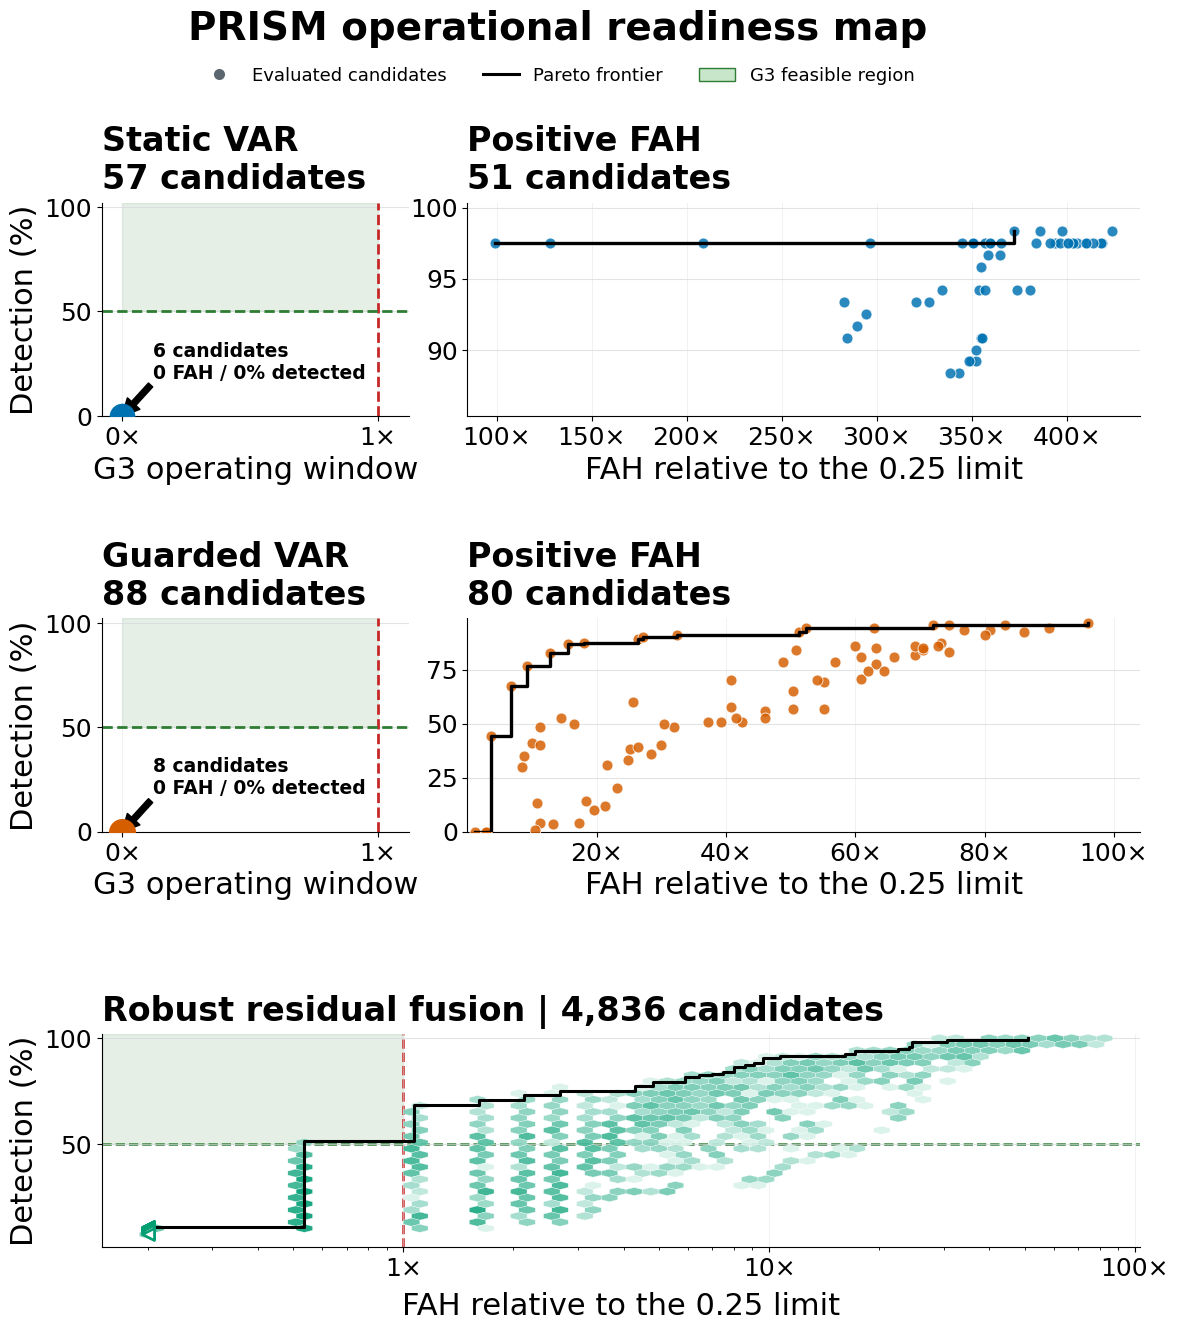

In [60]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

# Paper Figure 2 typography: change these values to resize only
# the titles, axis labels, and axis numbers (not legends or annotations).
OPERATING_POINT_FONTS = {
    "figure_title": 28,
    "panel_title": 24,
    "axis_label": 22,
    "tick_number": 18,
}

G3_FALSE_ALERT_BUDGET = 0.25
G3_DETECTION_REQUIREMENT = 50.0

colors = {
    "Static VAR": "#0072B2",
    "Guarded adaptive VAR": "#D55E00",
    "Robust residual fusion": "#009E73",
    "Shared quantile fusion": "#7B2CBF",
}

light_colors = {
    "Static VAR": "#DCEEF8",
    "Guarded adaptive VAR": "#FBE5D2",
    "Robust residual fusion": "#D9F2EA",
    "Shared quantile fusion": "#EADDF6",
}

method_count = len(PAPER_CANDIDATES)

figure = plt.figure(
    figsize=(12.0, 4.2 * method_count + 1.0),
    facecolor="white",
)

grid = GridSpec(
    method_count,
    12,
    figure=figure,
    hspace=0.95,
    wspace=1.80,
)

for row_index, (label, candidates) in enumerate(PAPER_CANDIDATES.items()):
    if {"fah", "detection"}.issubset(candidates.columns):
        false_alert_rate = pd.to_numeric(
            candidates["fah"],
            errors="coerce",
        ).to_numpy(dtype=float)

        detection_rate = 100.0 * pd.to_numeric(
            candidates["detection"],
            errors="coerce",
        ).to_numpy(dtype=float)
    else:
        false_alert_rate = pd.to_numeric(
            candidates["false_alerts_per_hour"],
            errors="coerce",
        ).to_numpy(dtype=float)

        detection_rate = 100.0 * pd.to_numeric(
            candidates["anomaly_run_detection_rate"],
            errors="coerce",
        ).to_numpy(dtype=float)

    finite = np.isfinite(false_alert_rate) & np.isfinite(detection_rate)
    false_alert_rate = false_alert_rate[finite]
    detection_rate = detection_rate[finite]

    budget_multiple = false_alert_rate / G3_FALSE_ALERT_BUDGET
    positive_multiple = budget_multiple[budget_multiple > 0]

    if len(positive_multiple):
        plot_floor = min(
            0.20,
            max(0.02, positive_multiple.min() * 0.60),
        )
    else:
        plot_floor = 0.20

    plotted_multiple = np.where(
        budget_multiple > 0,
        budget_multiple,
        plot_floor,
    )

    zero_alert = budget_multiple <= 0

    # Split Static VAR and Guarded VAR into a G3 overview and
    # a focused positive false-alert panel.
    if (
        label in {"Static VAR", "Guarded adaptive VAR"}
        and zero_alert.any()
        and len(positive_multiple)
    ):
        overview_axis = figure.add_subplot(grid[row_index, :4])
        focus_axis = figure.add_subplot(grid[row_index, 4:])

        overview_axis.set_facecolor("white")
        focus_axis.set_facecolor("white")

        method_color = colors[label]

        # Left panel: G3 operating window and zero-alert candidates.
        overview_x_min, overview_x_max = -0.08, 1.12
        overview_y_min, overview_y_max = 0.0, 102.0

        overview_axis.axvspan(
            0.0,
            1.0,
            ymin=G3_DETECTION_REQUIREMENT / overview_y_max,
            ymax=1.0,
            color="#2E7D32",
            alpha=0.12,
            zorder=0,
        )

        overview_axis.scatter(
            [0.0],
            [float(np.median(detection_rate[zero_alert]))],
            marker="o",
            s=155 + 18 * zero_alert.sum(),
            facecolor=method_color,
            edgecolor=method_color,
            linewidth=2.2,
            zorder=5,
        )

        overview_axis.axvline(
            1.0,
            color="#C62828",
            linestyle="--",
            linewidth=2.0,
        )

        overview_axis.axhline(
            G3_DETECTION_REQUIREMENT,
            color="#2E7D32",
            linestyle="--",
            linewidth=2.0,
        )

        overview_axis.annotate(
            f"{zero_alert.sum()} candidates\n0 FAH / 0% detected",
            xy=(
                0.0,
                float(np.median(detection_rate[zero_alert])),
            ),
            xytext=(0.12, 18.0),
            fontsize=13.5,
            fontweight="bold",
            color="#000000",
            arrowprops={
                "color": "#000000",
                "linewidth": 1.2,
            },
        )

        overview_axis.set_xlim(
            overview_x_min,
            overview_x_max,
        )
        overview_axis.set_ylim(
            overview_y_min,
            overview_y_max,
        )

        overview_axis.set_xticks([0.0, 1.0])
        overview_axis.set_xticklabels(
            ["0×", "1×"]
        )

        display_label = (
            "Guarded VAR"
            if label == "Guarded adaptive VAR"
            else label
        )

        overview_axis.set_title(
            f"{display_label}\n{len(candidates)} candidates",
            loc="left",
            fontsize=OPERATING_POINT_FONTS["panel_title"],
            fontweight="bold",
            color="#000000",
            pad=10,
        )

        overview_axis.set_xlabel(
            "G3 operating window",
            fontsize=OPERATING_POINT_FONTS["axis_label"],
            color="#000000",
        )
        overview_axis.set_ylabel(
            "Detection (%)",
            fontsize=OPERATING_POINT_FONTS["axis_label"],
            color="#000000",
        )

        # Right panel: focused view of candidates with positive FAH.
        positive = budget_multiple > 0
        focus_x = budget_multiple[positive]
        focus_y = detection_rate[positive]

        focus_axis.scatter(
            focus_x,
            focus_y,
            s=62,
            alpha=0.84,
            color=method_color,
            edgecolor="white",
            linewidth=0.65,
            zorder=3,
        )

        # Pareto frontier: best detection reached as alert load grows.
        frontier_order = np.argsort(
            focus_x,
            kind="mergesort",
        )
        frontier_x = focus_x[frontier_order]
        frontier_y = focus_y[frontier_order]

        running_best = np.maximum.accumulate(frontier_y)

        frontier_change = np.r_[
            True,
            running_best[1:] > running_best[:-1] + 1e-9,
        ]

        focus_axis.step(
            frontier_x[frontier_change],
            running_best[frontier_change],
            where="post",
            color="#000000",
            linewidth=2.4,
            zorder=4,
        )

        focus_padding = max(
            8.0,
            0.045 * (focus_x.max() - focus_x.min()),
        )

        focus_axis.set_xlim(
            max(0.0, focus_x.min() - focus_padding),
            focus_x.max() + focus_padding,
        )

        focus_axis.set_ylim(
            max(0.0, focus_y.min() - 3.0),
            min(102.0, focus_y.max() + 2.0),
        )

        focus_axis.xaxis.set_major_formatter(
            FuncFormatter(
                lambda value, _: f"{value:g}×"
            )
        )

        # Prevent a crowded zero tick in the Guarded VAR panel.
        if label == "Guarded adaptive VAR":
            focus_axis.set_xticks(
                [20.0, 40.0, 60.0, 80.0, 100.0]
            )

        focus_axis.set_title(
            f"Positive FAH\n{positive.sum()} candidates",
            loc="left",
            fontsize=OPERATING_POINT_FONTS["panel_title"],
            fontweight="bold",
            color="#000000",
            pad=10,
        )

        focus_axis.set_xlabel(
            "FAH relative to the 0.25 limit",
            fontsize=OPERATING_POINT_FONTS["axis_label"],
            color="#000000",
        )
        focus_axis.set_ylabel("")

        for split_axis in (overview_axis, focus_axis):
            split_axis.tick_params(
                axis="both",
                labelsize=OPERATING_POINT_FONTS["tick_number"],
                colors="#000000",
            )
            split_axis.grid(
                axis="y",
                color="#D5D9DE",
                linewidth=0.8,
                alpha=0.70,
            )
            split_axis.grid(
                axis="x",
                color="#E3E6E9",
                linewidth=0.7,
                alpha=0.55,
            )
            split_axis.spines["top"].set_visible(False)
            split_axis.spines["right"].set_visible(False)

        continue

    # Full-width density panel for large candidate sets.
    axis = figure.add_subplot(grid[row_index, :])
    axis.set_facecolor("white")

    x_min = max(0.01, plot_floor * 0.75)
    x_max = max(
        2.0,
        np.nanmax(plotted_multiple) * 1.25,
    )
    y_min = max(
        0.0,
        np.nanmin(detection_rate) - 6.0,
    )
    y_max = min(
        102.0,
        max(58.0, np.nanmax(detection_rate) + 5.0),
    )

    feasible_fraction_start = np.clip(
        (G3_DETECTION_REQUIREMENT - y_min)
        / (y_max - y_min),
        0.0,
        1.0,
    )

    axis.axvspan(
        x_min,
        1.0,
        ymin=feasible_fraction_start,
        ymax=1.0,
        color="#2E7D32",
        alpha=0.12,
        zorder=0,
    )

    method_color = colors.get(label, "#0072B2")

    if len(candidates) >= 300:
        density_map = LinearSegmentedColormap.from_list(
            f"{label}-density",
            [
                light_colors.get(label, "#DCEEF8"),
                method_color,
            ],
        )

        axis.hexbin(
            plotted_multiple,
            detection_rate,
            xscale="log",
            gridsize=(58, 16),
            mincnt=1,
            bins="log",
            cmap=density_map,
            linewidths=0.25,
            edgecolors="white",
            alpha=0.92,
            zorder=2,
        )
    else:
        axis.scatter(
            plotted_multiple,
            detection_rate,
            s=48,
            alpha=0.80,
            color=method_color,
            edgecolor="white",
            linewidth=0.55,
            zorder=3,
        )

    if zero_alert.any():
        axis.scatter(
            np.full(zero_alert.sum(), plot_floor),
            detection_rate[zero_alert],
            marker="<",
            s=72,
            facecolor="white",
            edgecolor=method_color,
            linewidth=1.8,
            zorder=5,
        )

    frontier_order = np.argsort(
        plotted_multiple,
        kind="mergesort",
    )
    frontier_x = plotted_multiple[frontier_order]
    frontier_y = detection_rate[frontier_order]

    running_best = np.maximum.accumulate(frontier_y)

    frontier_change = np.r_[
        True,
        running_best[1:] > running_best[:-1] + 1e-9,
    ]

    axis.step(
        frontier_x[frontier_change],
        running_best[frontier_change],
        where="post",
        color="#000000",
        linewidth=2.2,
        zorder=4,
    )

    axis.axvline(
        1.0,
        color="#C62828",
        linestyle="--",
        linewidth=1.8,
        zorder=1,
    )

    axis.axhline(
        G3_DETECTION_REQUIREMENT,
        color="#2E7D32",
        linestyle="--",
        linewidth=1.8,
        zorder=1,
    )

    axis.set_xscale("log")
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_min, y_max)

    axis.xaxis.set_major_formatter(
        FuncFormatter(
            lambda value, _: f"{value:g}×"
        )
    )

    axis.set_title(
        f"{label} | {len(candidates):,} candidates",
        loc="left",
        fontsize=OPERATING_POINT_FONTS["panel_title"],
        fontweight="bold",
        color="#000000",
        pad=10,
    )

    axis.set_xlabel(
        "FAH relative to the 0.25 limit",
        fontsize=OPERATING_POINT_FONTS["axis_label"],
        color="#000000",
        labelpad=8,
    )

    axis.set_ylabel(
        "Detection (%)",
        fontsize=OPERATING_POINT_FONTS["axis_label"],
        color="#000000",
    )

    axis.tick_params(
        axis="both",
        labelsize=OPERATING_POINT_FONTS["tick_number"],
        colors="#000000",
    )

    axis.grid(
        axis="y",
        color="#D5D9DE",
        linewidth=0.8,
        alpha=0.70,
    )

    axis.grid(
        axis="x",
        color="#E3E6E9",
        linewidth=0.7,
        alpha=0.55,
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#5B6770",
        markeredgecolor="white",
        markersize=9,
        label="Evaluated candidates",
    ),
    Line2D(
        [0],
        [0],
        color="#000000",
        linewidth=2.2,
        label="Pareto frontier",
    ),
    Patch(
        facecolor="#C8E6C9",
        edgecolor="#2E7D32",
        linewidth=1.0,
        label="G3 feasible region",
    ),
]

figure.suptitle(
    "PRISM operational readiness map",
    fontsize=OPERATING_POINT_FONTS["figure_title"],
    fontweight="bold",
    color="#000000",
    y=0.995,
)

figure.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=3,
    frameon=False,
    fontsize=13,
)

# Explicit GridSpec spacing keeps enlarged titles below the legend.
# Do not also call tight_layout: it conflicts with this split-panel grid.
grid.update(
    left=0.12,
    right=0.985,
    bottom=0.085,
    top=1.0 - 2.0 / figure.get_figheight(),
)

save_paper_figure(
    figure,
    "figure-2-development-operating-points.png",
)

plt.show()


### Figure 3 — Headline static-versus-adaptive performance

This two-panel figure makes the central development tradeoff explicit: guarded
adaptation sharply reduces false alerts, but the current operating point remains
below the minimum detection target.


/var/folders/2z/b1lzf17n4z90pz80khfc42fw0000gp/T/ipykernel_55697/2199269845.py:284: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout(


Saved PNG and vector PDF: /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/figures/development/figure-3-headline-method-performance.png


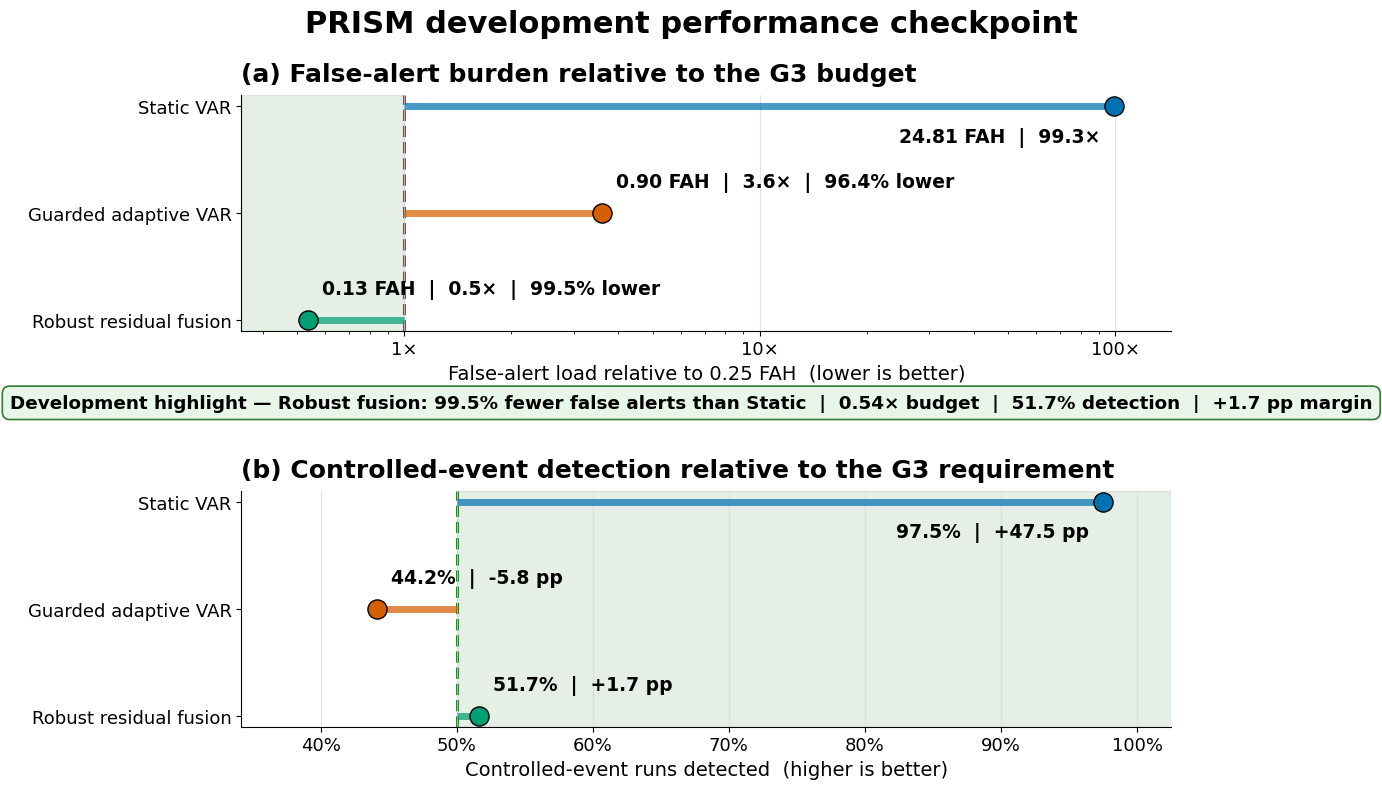

In [61]:
from matplotlib.ticker import FuncFormatter

G3_FALSE_ALERT_BUDGET = 0.25
G3_DETECTION_REQUIREMENT = 50.0

method_labels = HEADLINE_METHOD_TABLE["Method"].tolist()
method_palette = {
    "Static VAR": "#0072B2",
    "Guarded adaptive VAR": "#D55E00",
    "Robust residual fusion": "#009E73",
    "Shared quantile fusion": "#7B2CBF",
}
method_colors = [method_palette[label] for label in method_labels]
method_positions = np.arange(len(method_labels), dtype=float)

false_alert_values = pd.to_numeric(
    HEADLINE_METHOD_TABLE["False alerts/hour"], errors="coerce"
).to_numpy(dtype=float)
detection_values = pd.to_numeric(
    HEADLINE_METHOD_TABLE["Detection (%)"], errors="coerce"
).to_numpy(dtype=float)

false_alert_load = false_alert_values / G3_FALSE_ALERT_BUDGET
static_index = method_labels.index("Static VAR")
robust_index = (
    method_labels.index("Robust residual fusion")
    if "Robust residual fusion" in method_labels
    else None
)

static_false_alert_rate = false_alert_values[static_index]

if robust_index is not None:
    robust_false_alert_reduction = 100.0 * (
        1.0 - false_alert_values[robust_index] / static_false_alert_rate
    )
    robust_detection_margin = (
        detection_values[robust_index] - G3_DETECTION_REQUIREMENT
    )

figure, axes = plt.subplots(
    2,
    1,
    figsize=(12.0, 8.2),
    facecolor="white",
    gridspec_kw={"hspace": 0.68},
)
false_alert_axis, detection_axis = axes

# Panel A: distance from the operational false alert budget.
positive_load = false_alert_load[
    np.isfinite(false_alert_load) & (false_alert_load > 0)
]
false_alert_x_min = max(0.10, positive_load.min() * 0.65)
false_alert_x_max = max(1.50, positive_load.max() * 1.45)

false_alert_axis.axvspan(
    false_alert_x_min,
    1.0,
    color="#2E7D32",
    alpha=0.12,
    zorder=0,
)
false_alert_axis.axvline(
    1.0,
    color="#C62828",
    linestyle="--",
    linewidth=2.2,
    zorder=1,
)

for position, label, value, load, color in zip(
    method_positions,
    method_labels,
    false_alert_values,
    false_alert_load,
    method_colors,
):
    false_alert_axis.hlines(
        position,
        min(1.0, load),
        max(1.0, load),
        color=color,
        linewidth=5.0,
        alpha=0.72,
        zorder=2,
    )
    false_alert_axis.scatter(
        load,
        position,
        s=190,
        color=color,
        edgecolor="#000000",
        linewidth=1.0,
        zorder=3,
    )

    place_left = load > 40.0

    # Keep numerical text away from the colored line.
    label_offset_y = -15 if position == method_positions[0] else 15
    label_vertical_alignment = (
        "top" if label_offset_y < 0 else "bottom"
    )

    reduction_text = ""
    if label != "Static VAR":
        reduction = 100.0 * (1.0 - value / static_false_alert_rate)
        reduction_text = f"  |  {reduction:.1f}% lower"

    false_alert_axis.annotate(
        f"{value:.2f} FAH  |  {load:.1f}×{reduction_text}",
        xy=(load, position),
        xytext=(-10 if place_left else 10, label_offset_y),
        textcoords="offset points",
        ha="right" if place_left else "left",
        va=label_vertical_alignment,
        fontsize=13.5,
        fontweight="bold",
        color="#000000",
    )

false_alert_axis.set_xscale("log")
false_alert_axis.set_xlim(false_alert_x_min, false_alert_x_max)
false_alert_axis.set_yticks(method_positions)
false_alert_axis.set_yticklabels(method_labels)
false_alert_axis.invert_yaxis()
false_alert_axis.xaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value:g}×")
)
false_alert_axis.set_title(
    "(a) False-alert burden relative to the G3 budget",
    loc="left",
    fontsize=18,
    fontweight="bold",
    color="#000000",
    pad=10,
)
false_alert_axis.set_xlabel(
    "False-alert load relative to 0.25 FAH  (lower is better)",
    fontsize=14,
    color="#000000",
)

# Panel B: distance from the controlled event detection requirement.
detection_x_min = max(0.0, np.nanmin(detection_values) - 10.0)
detection_x_max = min(
    105.0,
    max(100.0, np.nanmax(detection_values) + 5.0),
)

detection_axis.axvspan(
    G3_DETECTION_REQUIREMENT,
    detection_x_max,
    color="#2E7D32",
    alpha=0.12,
    zorder=0,
)
detection_axis.axvline(
    G3_DETECTION_REQUIREMENT,
    color="#2E7D32",
    linestyle="--",
    linewidth=2.2,
    zorder=1,
)

for position, label, value, color in zip(
    method_positions,
    method_labels,
    detection_values,
    method_colors,
):
    detection_axis.hlines(
        position,
        min(G3_DETECTION_REQUIREMENT, value),
        max(G3_DETECTION_REQUIREMENT, value),
        color=color,
        linewidth=5.0,
        alpha=0.72,
        zorder=2,
    )
    detection_axis.scatter(
        value,
        position,
        s=190,
        color=color,
        edgecolor="#000000",
        linewidth=1.0,
        zorder=3,
    )

    place_left = value > 90.0

    # Keep numerical text away from the colored line.
    label_offset_y = -15 if position == method_positions[0] else 15
    label_vertical_alignment = (
        "top" if label_offset_y < 0 else "bottom"
    )

    detection_margin = value - G3_DETECTION_REQUIREMENT

    detection_axis.annotate(
        f"{value:.1f}%  |  {detection_margin:+.1f} pp",
        xy=(value, position),
        xytext=(-10 if place_left else 10, label_offset_y),
        textcoords="offset points",
        ha="right" if place_left else "left",
        va=label_vertical_alignment,
        fontsize=13.5,
        fontweight="bold",
        color="#000000",
    )

detection_axis.set_xlim(detection_x_min, detection_x_max)
detection_axis.set_yticks(method_positions)
detection_axis.set_yticklabels(method_labels)
detection_axis.invert_yaxis()
detection_axis.xaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value:g}%")
)
detection_axis.set_title(
    "(b) Controlled-event detection relative to the G3 requirement",
    loc="left",
    fontsize=18,
    fontweight="bold",
    color="#000000",
    pad=10,
)
detection_axis.set_xlabel(
    "Controlled-event runs detected  (higher is better)",
    fontsize=14,
    color="#000000",
)

for axis in axes:
    axis.set_facecolor("white")
    axis.tick_params(
        axis="both",
        labelsize=13,
        colors="#000000",
    )
    axis.grid(
        axis="x",
        color="#D5D9DE",
        linewidth=0.8,
        alpha=0.72,
    )
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

if robust_index is not None:
    figure.text(
        0.5,
        0.505,
        (
            "Development highlight — Robust fusion: "
            f"{robust_false_alert_reduction:.1f}% fewer false alerts "
            "than Static  |  "
            f"{false_alert_load[robust_index]:.2f}× budget  |  "
            f"{detection_values[robust_index]:.1f}% detection  |  "
            f"{robust_detection_margin:+.1f} pp margin"
        ),
        ha="center",
        va="center",
        fontsize=13.2,
        fontweight="bold",
        color="#000000",
        bbox={
            "boxstyle": "round,pad=0.42",
            "facecolor": "#E8F5E9",
            "edgecolor": "#2E7D32",
            "linewidth": 1.2,
        },
    )

figure.suptitle(
    "PRISM development performance checkpoint",
    fontsize=22,
    fontweight="bold",
    color="#000000",
    y=0.985,
)

figure.tight_layout(
    rect=(0.0, 0.0, 1.0, 0.94),
    h_pad=2.5,
)

save_paper_figure(
    figure,
    "figure-3-headline-method-performance.png",
)
plt.show()

### Table 5 — Earlier guarded VAR update audit

Counts describe accepted/rejected update decisions, fault freezes, promotions,
and rollbacks. They are controller actions, not independent runs, and do not
prove that every accepted update represented benign drift. v3 instead applies
guarded adaptation to residual feature offsets.


In [62]:
guarded_audit = PAPER_REPORTS["Guarded adaptive VAR"]["guarded_update_audit_totals"]
GUARDED_AUDIT_TABLE = pd.DataFrame(
    [
        {"Audit event": key.replace("_", " "), "Count": value}
        for key, value in guarded_audit.items()
    ]
).sort_values("Count", ascending=False)
GUARDED_AUDIT_TABLE = GUARDED_AUDIT_TABLE.reset_index(drop=True)
save_paper_table(
    GUARDED_AUDIT_TABLE, "table-5-guarded-update-audit.csv"
)
display(GUARDED_AUDIT_TABLE)


Saved table: /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/results/development/table-5-guarded-update-audit.csv


,Audit event,Count
0,accepted updates,17767
1,rejected updates,6929
2,promotions,1402
3,fault freezes,192
4,rollbacks,9


### Figure 4 — Guarded VAR audit (paper Fig. 6)

This figure shows which control paths the earlier guarded VAR comparison
exercised. It is not an independent confirmation or an adaptation benefit
estimate for the selected v3 monitor.


Saved PNG and vector PDF: /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/figures/development/figure-4-guarded-update-audit.png


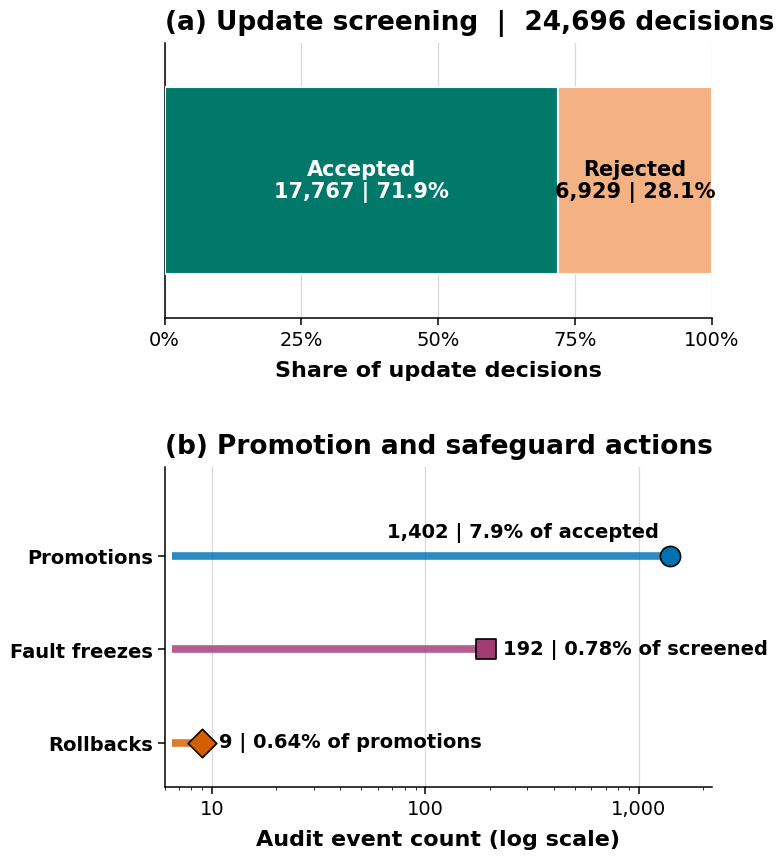

In [63]:
from matplotlib.ticker import FuncFormatter, LogLocator
import numpy as np
import matplotlib.pyplot as plt

audit_counts = (
    GUARDED_AUDIT_TABLE
    .set_index("Audit event")["Count"]
    .astype(int)
)

accepted_updates = int(
    audit_counts["accepted updates"]
)
rejected_updates = int(
    audit_counts["rejected updates"]
)
promotions = int(
    audit_counts["promotions"]
)
fault_freezes = int(
    audit_counts["fault freezes"]
)
rollbacks = int(
    audit_counts["rollbacks"]
)

screened_updates = (
    accepted_updates + rejected_updates
)


def audit_percent(
    numerator: int,
    denominator: int,
) -> float:
    return (
        100.0 * numerator / denominator
        if denominator
        else np.nan
    )


accepted_share = audit_percent(
    accepted_updates,
    screened_updates,
)
rejected_share = audit_percent(
    rejected_updates,
    screened_updates,
)
promotion_share = audit_percent(
    promotions,
    accepted_updates,
)
freeze_share = audit_percent(
    fault_freezes,
    screened_updates,
)
rollback_share = audit_percent(
    rollbacks,
    promotions,
)

audit_palette = {
    "accepted updates": "#00796B",
    "rejected updates": "#F4B183",
    "promotions": "#0072B2",
    "fault freezes": "#A23B72",
    "rollbacks": "#D55E00",
}

BLACK = "#000000"
GRID = "#D5D9DE"


# ============================================================
# Narrow one-column layout: one panel per row
# ============================================================

figure = plt.figure(
    figsize=(7.6, 8.6),
    facecolor="white",
)

grid = figure.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[0.86, 1.00],
    hspace=0.50,
)

decision_axis = figure.add_subplot(
    grid[0, 0]
)

safeguard_axis = figure.add_subplot(
    grid[1, 0]
)


# ============================================================
# Panel (a): update screening decisions
# ============================================================

bar_height = 0.34

decision_axis.barh(
    [0],
    [accepted_share],
    height=bar_height,
    color=audit_palette["accepted updates"],
    edgecolor="white",
    linewidth=1.5,
    zorder=3,
)

decision_axis.barh(
    [0],
    [rejected_share],
    left=[accepted_share],
    height=bar_height,
    color=audit_palette["rejected updates"],
    edgecolor="white",
    linewidth=1.5,
    zorder=3,
)

decision_axis.text(
    accepted_share / 2.0,
    0,
    (
        "Accepted\n"
        f"{accepted_updates:,} | "
        f"{accepted_share:.1f}%"
    ),
    ha="center",
    va="center",
    multialignment="center",
    fontsize=15,
    fontweight="bold",
    color="white",
    linespacing=1.08,
    zorder=4,
)

decision_axis.text(
    accepted_share
    + rejected_share / 2.0,
    0,
    (
        "Rejected\n"
        f"{rejected_updates:,} | "
        f"{rejected_share:.1f}%"
    ),
    ha="center",
    va="center",
    multialignment="center",
    fontsize=15,
    fontweight="bold",
    color=BLACK,
    linespacing=1.08,
    zorder=4,
)

decision_axis.set_xlim(
    0.0,
    100.0,
)

decision_axis.set_ylim(
    -0.25,
    0.25,
)

decision_axis.set_yticks([])

decision_axis.set_xticks(
    [0, 25, 50, 75, 100]
)

decision_axis.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: f"{value:g}%"
    )
)

decision_axis.set_xlabel(
    "Share of update decisions",
    fontsize=16,
    fontweight="bold",
    color=BLACK,
    labelpad=8,
)

decision_axis.set_title(
    (
        "(a) Update screening"
        f"  |  {screened_updates:,} decisions"
    ),
    loc="left",
    fontsize=19,
    fontweight="bold",
    color=BLACK,
    pad=10,
)

decision_axis.grid(
    axis="x",
    color=GRID,
    linewidth=0.9,
)

decision_axis.set_axisbelow(True)


# ============================================================
# Panel (b): promotion and safeguard actions
# ============================================================

safeguard_labels = [
    "Promotions",
    "Fault freezes",
    "Rollbacks",
]

safeguard_keys = [
    "promotions",
    "fault freezes",
    "rollbacks",
]

safeguard_counts = np.array(
    [
        promotions,
        fault_freezes,
        rollbacks,
    ],
    dtype=float,
)

safeguard_context = [
    f"{promotion_share:.1f}% of accepted",
    f"{freeze_share:.2f}% of screened",
    f"{rollback_share:.2f}% of promotions",
]

safeguard_markers = [
    "o",
    "s",
    "D",
]

# Tightly grouped vertical positions.
safeguard_positions = np.array(
    [0.42, 0.21, 0.00]
)

line_start = 6.5

for (
    position,
    key,
    count,
    context,
    marker,
) in zip(
    safeguard_positions,
    safeguard_keys,
    safeguard_counts,
    safeguard_context,
    safeguard_markers,
):
    color = audit_palette[key]

    safeguard_axis.hlines(
        y=position,
        xmin=line_start,
        xmax=count,
        color=color,
        linewidth=5.5,
        alpha=0.82,
        zorder=2,
    )

    safeguard_axis.scatter(
        count,
        position,
        s=210,
        marker=marker,
        color=color,
        edgecolor=BLACK,
        linewidth=1.2,
        zorder=3,
    )

    if key == "promotions":
        # Keep the longest annotation inside the right boundary.
        safeguard_axis.annotate(
            f"{int(count):,} | {context}",
            xy=(count, position),
            xytext=(-8, 10),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=14,
            fontweight="bold",
            color=BLACK,
            annotation_clip=False,
        )
    else:
        # Label smaller counts after their markers.
        safeguard_axis.annotate(
            f"{int(count):,} | {context}",
            xy=(count, position),
            xytext=(12, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=14,
            fontweight="bold",
            color=BLACK,
            annotation_clip=False,
        )

safeguard_axis.set_xscale(
    "log"
)

safeguard_axis.set_xlim(
    6.0,
    2200.0,
)

# Compact limits reduce space between and around the rows.
safeguard_axis.set_ylim(
    -0.10,
    0.62,
)

safeguard_axis.set_yticks(
    safeguard_positions
)

safeguard_axis.set_yticklabels(
    safeguard_labels,
    fontsize=15,
    fontweight="bold",
    color=BLACK,
)

safeguard_axis.xaxis.set_major_locator(
    LogLocator(
        base=10.0,
        numticks=4,
    )
)

safeguard_axis.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: (
            f"{int(value):,}"
            if value >= 1
            else ""
        )
    )
)

safeguard_axis.set_xlabel(
    "Audit event count (log scale)",
    fontsize=16,
    fontweight="bold",
    color=BLACK,
    labelpad=8,
)

safeguard_axis.set_title(
    "(b) Promotion and safeguard actions",
    loc="left",
    fontsize=19,
    fontweight="bold",
    color=BLACK,
    pad=10,
)

safeguard_axis.grid(
    axis="x",
    color=GRID,
    linewidth=0.9,
    which="major",
)

safeguard_axis.grid(
    axis="x",
    which="minor",
    visible=False,
)

safeguard_axis.set_axisbelow(True)


# ============================================================
# Shared publication styling
# ============================================================

for axis in (
    decision_axis,
    safeguard_axis,
):
    axis.set_facecolor("white")

    axis.tick_params(
        axis="both",
        labelsize=14,
        colors=BLACK,
        width=1.1,
        length=5,
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    axis.spines["left"].set_color(BLACK)
    axis.spines["bottom"].set_color(BLACK)

    axis.spines["left"].set_linewidth(1.1)
    axis.spines["bottom"].set_linewidth(1.1)

figure.subplots_adjust(
    left=0.24,
    right=0.96,
    bottom=0.085,
    top=0.95,
    hspace=0.50,
)

save_paper_figure(
    figure,
    "figure-4-guarded-update-audit.png",
)

plt.show()

### Table 6 — Pre-lock reliability checkpoint

This compact table preserves the independent v3 confirmation and the two
nearest v4 development operating points. The v3 benign rate comes from a new
16-run confirmation set; its event-detection value remains the frozen
development result because the confirmation set is intentionally benign.
Neither row accesses the locked test.


In [64]:
V3_CHECKPOINT_PATH = (
    DATA_ROOT / "processed" / "prism-analysis-v3"
    / "independent-confirmation-result.json"
)
V4_CHECKPOINT_PATH = (
    DATA_ROOT / "processed" / "prism-analysis-v4"
    / "development-persistent-corroboration-selection.json"
)
TRACKED_PRELOCK_CHECKPOINT_TABLE = (
    PAPER_TABLE_ROOT / "table-6-prelock-reliability-checkpoint.csv"
)


def build_prelock_checkpoint_table() -> tuple[pd.DataFrame, bool]:
    missing = [
        checkpoint_path
        for checkpoint_path in (V3_CHECKPOINT_PATH, V4_CHECKPOINT_PATH)
        if not checkpoint_path.exists()
    ]
    if missing:
        if not TRACKED_PRELOCK_CHECKPOINT_TABLE.exists():
            raise FileNotFoundError(
                "Missing checkpoint source artifacts and tracked Table 6: "
                + ", ".join(str(item) for item in missing)
            )
        print(
            "Raw checkpoint artifacts are unavailable; displaying the tracked "
            "checksum-backed pre-lock Table 6."
        )
        return pd.read_csv(TRACKED_PRELOCK_CHECKPOINT_TABLE), False

    v3_checkpoint = json.loads(V3_CHECKPOINT_PATH.read_text(encoding="utf-8"))
    v4_checkpoint = json.loads(V4_CHECKPOINT_PATH.read_text(encoding="utf-8"))
    v3_pooled = v3_checkpoint["pooled_metrics"]
    v3_detection = v3_checkpoint["development_detection"]
    v4_fah_point = v4_checkpoint["best_detection_at_or_below_g3_fah"]
    v4_detection_point = v4_checkpoint["lowest_fah_at_or_above_g3_detection"]


    def checkpoint_row(
        evidence: str,
        evidence_source: str,
        benign_hours: float,
        false_alerts: int,
        fah: float,
        detected: int,
        event_runs: int,
        interpretation: str,
    ) -> dict[str, object]:
        return {
            "Evidence": evidence,
            "Source": evidence_source,
            "Benign h": benign_hours,
            "False alerts": false_alerts,
            "FAH": fah,
            "Detected events": f"{detected}/{event_runs}",
            "Detection (%)": 100.0 * detected / event_runs,
            "Interpretation": interpretation,
        }


    PRELOCK_CHECKPOINT_TABLE = pd.DataFrame(
        [
            checkpoint_row(
                "v3 frozen method",
                "independent benign confirmation",
                v3_pooled["benign_hours"],
                v3_pooled["false_alerts"],
                v3_pooled["fah"],
                v3_detection["detected_runs"],
                v3_detection["event_runs"],
                "Independent FAH check failed",
            ),
            checkpoint_row(
                "v4 point A",
                "expanded development",
                v4_fah_point["benign_hours"],
                v4_fah_point["false_alerts"],
                v4_fah_point["fah"],
                v4_fah_point["detected"],
                v4_fah_point["runs"],
                "FAH met; detection missed by one run",
            ),
            checkpoint_row(
                "v4 point B",
                "expanded development",
                v4_detection_point["benign_hours"],
                v4_detection_point["false_alerts"],
                v4_detection_point["fah"],
                v4_detection_point["detected"],
                v4_detection_point["runs"],
                "Detection met; FAH above budget",
            ),
        ]
    )
    save_paper_table(
        PRELOCK_CHECKPOINT_TABLE, "table-6-prelock-reliability-checkpoint.csv"
    )
    locked_accessed = bool(
        v3_checkpoint["locked_test_accessed"]
        or v4_checkpoint["locked_test_accessed"]
    )
    return PRELOCK_CHECKPOINT_TABLE, locked_accessed


PRELOCK_CHECKPOINT_TABLE, checkpoint_locked_accessed = (
    build_prelock_checkpoint_table()
)
display(PRELOCK_CHECKPOINT_TABLE.round(3))
print("G3 requires FAH <= 0.25 and event detection >= 50% together.")
print("Locked-test accessed:", checkpoint_locked_accessed)


Raw checkpoint artifacts are unavailable; displaying the tracked checksum-backed pre-lock Table 6.


,Evidence,Source,Benign h,False alerts,FAH,Detected events,Detection (%),Interpretation
0,v3 frozen method,independent benign confirmation,16.800,6,0.357,71/120,59.167,Independent FAH check failed
1,v4 point A,expanded development,53.333,13,0.244,59/120,49.167,FAH met; detection missed by one run
2,v4 point B,expanded development,53.333,15,0.281,61/120,50.833,Detection met; FAH above budget


G3 requires FAH <= 0.25 and event detection >= 50% together.
Locked-test accessed: False


### Figure 6 — Behavioral micro-twin illustration (paper Fig. 4)

A fixed representative M2 development run illustrates observed and predicted
semantic states, localized residuals, and aggregate residual evidence. The
99th percentile line is a descriptive benign reference, not the v3 alert
threshold. Panel (b) uses a centered three-block median for display only;
panel (c) is an RMS residual summary, not the sequential statistic.

The selected v3 controller adds classifier fusion, sequential accumulation,
and residual corroboration. This illustration is not its performance test.


Saved PNG and vector PDF: /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/figures/development/figure-6-digital-micro-twin-evidence.png


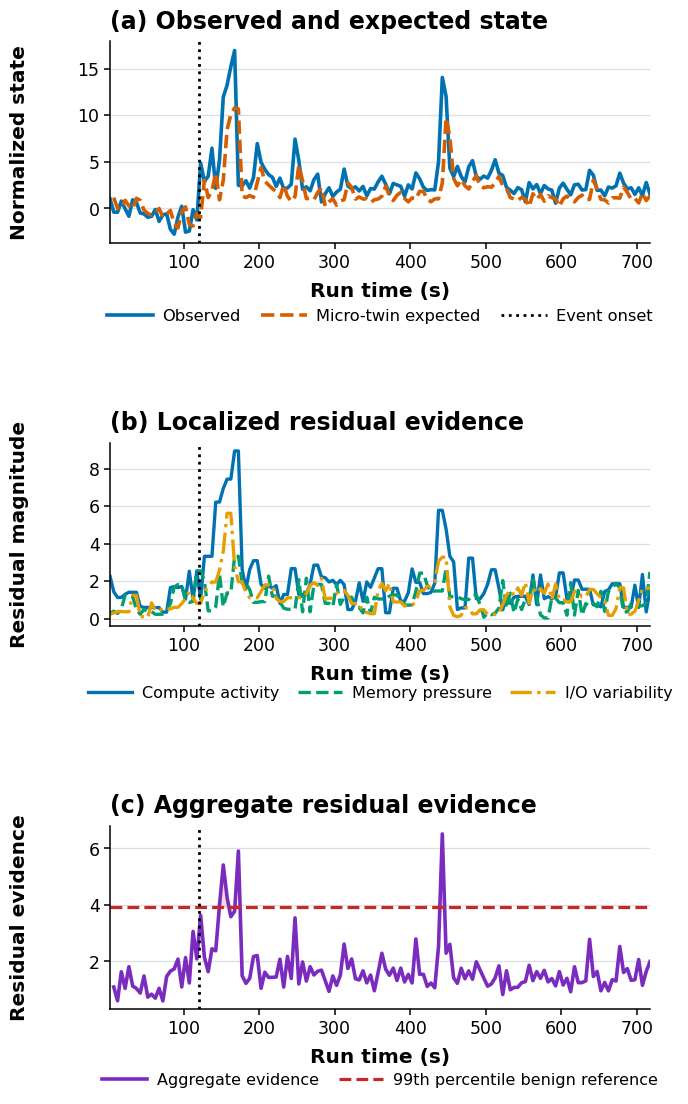

In [65]:
TRACKED_TWIN_FIGURE = (
    PAPER_FIGURE_ROOT
    / "figure-6-digital-micro-twin-evidence.png"
)


def generate_digital_micro_twin_figure() -> None:
    global SEMANTIC_CACHE

    # Deterministic development-only illustration.
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache()

    TWIN_FIGURE_CONFIG = {
        "platform_id": "M2_MACOS",
        "workload": "PY_STATS",
        "scenario": "MEMBW",
        "run_id": "m2_macos__py_stats__membw__r01",
        "state": "compute_activity",
        "lags": 1,
        "penalty": 100.0,
    }

    demo_run = SEMANTIC_CACHE["runs"].get(
        TWIN_FIGURE_CONFIG["run_id"]
    )

    if demo_run is None:
        matching_runs = sorted(
            (
                run
                for run in SEMANTIC_CACHE["runs"].values()
                if run["platform_id"]
                == TWIN_FIGURE_CONFIG["platform_id"]
                and run["workload"]
                == TWIN_FIGURE_CONFIG["workload"]
                and run["scenario"]
                == TWIN_FIGURE_CONFIG["scenario"]
                and run["planned_split"] == "development"
            ),
            key=lambda run: run["run_id"],
        )

        if not matching_runs:
            raise RuntimeError(
                "No matching development run for the twin figure."
            )

        demo_run = matching_runs[0]

    # Fit only on benign nominal runs.
    # The illustrated controlled run is excluded from fitting.
    fit_sequences = [
        compact_benign_segment(run)
        for run in SEMANTIC_CACHE["runs"].values()
        if run["platform_id"] == demo_run["platform_id"]
        and run["workload"] == demo_run["workload"]
        and run["scenario"] == "NOMINAL"
        and run["planned_split"] in {
            "calibration",
            "development",
        }
    ]

    micro_twin = fit_compact_var(
        fit_sequences,
        TWIN_FIGURE_CONFIG["lags"],
        TWIN_FIGURE_CONFIG["penalty"],
    )

    observed_state = compact_semantic_sequence(
        demo_run["x"]
    )

    observed_normalized = normalize_sequence(
        observed_state,
        micro_twin["location"],
        micro_twin["feature_scale"],
    )

    residual = residual_matrix(
        micro_twin,
        observed_state,
    )

    expected_normalized = (
        observed_normalized - residual
    )

    standardized_residual = (
        residual / micro_twin["residual_scale"]
    )

    def finite_row_rms(
        matrix: np.ndarray,
    ) -> np.ndarray:
        finite = np.isfinite(matrix)
        count = np.sum(finite, axis=1)

        result = np.full(
            len(matrix),
            np.nan,
            dtype=float,
        )

        valid = count > 0

        result[valid] = np.sqrt(
            np.nansum(
                np.square(matrix[valid]),
                axis=1,
            )
            / count[valid]
        )

        return result

    aggregate_evidence = finite_row_rms(
        standardized_residual
    )

    benign_reference = []

    for sequence in fit_sequences:
        reference_residual = residual_matrix(
            micro_twin,
            sequence,
        )

        standardized_reference = (
            reference_residual
            / micro_twin["residual_scale"]
        )

        reference_score = finite_row_rms(
            standardized_reference
        )

        benign_reference.extend(
            reference_score[
                np.isfinite(reference_score)
            ]
        )

    diagnostic_threshold = float(
        np.quantile(
            benign_reference,
            0.99,
        )
    )

    state_lookup = {
        name: index
        for index, name in enumerate(
            COMPACT_STATE_NAMES
        )
    }

    state_index = state_lookup[
        TWIN_FIGURE_CONFIG["state"]
    ]

    contributor_specs = (
        (
            "compute_activity",
            "Compute activity",
            "#0072B2",
            "-",
        ),
        (
            "memory_pressure",
            "Memory pressure",
            "#009E73",
            "--",
        ),
        (
            "io_variability",
            "I/O variability",
            "#E69F00",
            "-.",
        ),
    )

    time_seconds = np.asarray(
        demo_run["t"],
        dtype=float,
    )

    onset = float(
        demo_run["onset_seconds"]
    )

    BLACK = "#000000"
    GRID = "#D5D9DE"

    # Narrow and tall source format for one IEEE column.
    figure, axes = plt.subplots(
        3,
        1,
        figsize=(7.2, 11.0),
        sharex=True,
        gridspec_kw={
            "height_ratios": [
                1.10,
                1.00,
                1.00,
            ]
        },
    )

    figure.patch.set_facecolor("white")

    # The overall internal title is intentionally omitted.
    # The manuscript caption supplies the figure title.


    # ========================================================
    # Panel (a): observed versus predicted state
    # ========================================================

    axes[0].plot(
        time_seconds,
        observed_normalized[:, state_index],
        color="#0072B2",
        linewidth=2.6,
        label="Observed",
    )

    axes[0].plot(
        time_seconds,
        expected_normalized[:, state_index],
        color="#D55E00",
        linewidth=2.6,
        linestyle="--",
        label="Micro-twin expected",
    )

    axes[0].axvline(
        onset,
        color=BLACK,
        linestyle=":",
        linewidth=2.0,
        label="Event onset",
    )

    axes[0].set_ylabel(
        "Normalized state",
        fontsize=14.5,
        fontweight="bold",
        color=BLACK,
    )

    axes[0].set_title(
        "(a) Observed and expected state",
        loc="left",
        fontsize=17,
        fontweight="bold",
        color=BLACK,
        pad=9,
    )

    axes[0].legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.29),
        ncol=3,
        frameon=False,
        fontsize=11.7,
        borderaxespad=0.0,
        handlelength=2.8,
        columnspacing=1.25,
        handletextpad=0.6,
    )


    # ========================================================
    # Panel (b): localized residual evidence
    # ========================================================

    for (
        state_name,
        display_name,
        color,
        linestyle,
    ) in contributor_specs:
        values = np.abs(
            standardized_residual[
                :,
                state_lookup[state_name],
            ]
        )

        smoothed = (
            pd.Series(values)
            .rolling(
                3,
                center=True,
                min_periods=1,
            )
            .median()
            .to_numpy()
        )

        axes[1].plot(
            time_seconds,
            smoothed,
            color=color,
            linewidth=2.4,
            linestyle=linestyle,
            label=display_name,
        )

    axes[1].set_ylabel(
        "Residual magnitude",
        fontsize=14.5,
        fontweight="bold",
        color=BLACK,
    )

    axes[1].set_title(
        "(b) Localized residual evidence",
        loc="left",
        fontsize=17,
        fontweight="bold",
        color=BLACK,
        pad=9,
    )

    axes[1].legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.29),
        ncol=3,
        frameon=False,
        fontsize=11.5,
        borderaxespad=0.0,
        handlelength=2.8,
        columnspacing=1.15,
        handletextpad=0.6,
    )


    # ========================================================
    # Panel (c): sequential evidence
    # ========================================================

    axes[2].plot(
        time_seconds,
        aggregate_evidence,
        color="#7B2CBF",
        linewidth=2.6,
        label="Aggregate evidence",
    )

    axes[2].axhline(
        diagnostic_threshold,
        color="#C62828",
        linestyle="--",
        linewidth=2.3,
        label="99th percentile benign reference",
    )

    axes[2].fill_between(
        time_seconds,
        diagnostic_threshold,
        aggregate_evidence,
        where=(
            aggregate_evidence
            >= diagnostic_threshold
        ),
        color="#C62828",
        alpha=0.16,
    )

    axes[2].set_ylabel(
        "Residual evidence",
        fontsize=14.5,
        fontweight="bold",
        color=BLACK,
    )

    axes[2].set_title(
        "(c) Aggregate residual evidence",
        loc="left",
        fontsize=17,
        fontweight="bold",
        color=BLACK,
        pad=9,
    )

    axes[2].legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.31),
        ncol=2,
        frameon=False,
        fontsize=11.5,
        borderaxespad=0.0,
        handlelength=2.8,
        columnspacing=1.25,
        handletextpad=0.6,
    )


    # ========================================================
    # Shared event-onset marker
    # ========================================================

    for axis in axes[1:]:
        axis.axvline(
            onset,
            color=BLACK,
            linestyle=":",
            linewidth=2.0,
            label="_nolegend_",
        )


    # ========================================================
    # Shared publication styling
    # ========================================================

    for axis in axes:
        axis.set_facecolor("white")

        axis.grid(
            axis="y",
            color=GRID,
            linewidth=0.9,
            alpha=0.85,
        )

        axis.set_xlabel(
            "Run time (s)",
            fontsize=14.5,
            fontweight="bold",
            color=BLACK,
            labelpad=7,
        )

        # Keep all y-axis titles aligned.
        axis.yaxis.set_label_coords(
            -0.15,
            0.5,
        )

        axis.tick_params(
            axis="both",
            labelsize=12.5,
            colors=BLACK,
            width=1.1,
            length=4,
            labelbottom=True,
        )

        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)

        axis.spines["left"].set_color(BLACK)
        axis.spines["bottom"].set_color(BLACK)

        axis.spines["left"].set_linewidth(1.1)
        axis.spines["bottom"].set_linewidth(1.1)

    axes[2].set_xlim(
        float(time_seconds.min()),
        float(time_seconds.max()),
    )

    figure.subplots_adjust(
        left=0.22,
        right=0.97,
        bottom=0.09,
        top=0.97,
        hspace=1.05,
    )

    save_paper_figure(
        figure,
        "figure-6-digital-micro-twin-evidence.png",
    )

    plt.show()


if CACHE_PATH.exists():
    generate_digital_micro_twin_figure()

elif TRACKED_TWIN_FIGURE.exists():
    from IPython.display import (
        Image as NotebookImage,
    )

    print(
        "Private semantic blocks are unavailable; "
        "displaying the tracked data-grounded Figure 6."
    )

    display(
        NotebookImage(
            filename=str(TRACKED_TWIN_FIGURE)
        )
    )

else:
    raise FileNotFoundError(
        "Neither the semantic cache nor tracked "
        "Figure 6 is available."
    )

### Table 9 — v3 operational evidence

Development detection and delay are separate from independent benign
confirmation. Delay is conditional on detected events. The 0.31% rich tier
duty cycle refers to confirmation replay, not live acquisition or energy
savings. Section 17E checks these values against the pinned reports.


In [66]:
OPERATIONAL_TABLE_PATH = (
    REPO_ROOT / "paper" / "results" / "development"
    / "table-9-operational-evidence-scorecard.csv"
)
OPERATIONAL_TEX_PATH = OPERATIONAL_TABLE_PATH.with_suffix(".tex")

if V3_SELECTION_JSON.exists() and V3_CONFIRMATION_RESULTS_JSON.exists():
    development_report = json.loads(V3_SELECTION_JSON.read_text(encoding="utf-8"))
    confirmation_report = json.loads(
        V3_CONFIRMATION_RESULTS_JSON.read_text(encoding="utf-8")
    )
    if development_report.get("locked_test_accessed") is not False:
        raise RuntimeError("Locked evidence entered the operational scorecard.")
    if confirmation_report.get("locked_test_accessed") is not False:
        raise RuntimeError("Locked evidence entered the confirmation scorecard.")
    selected = development_report["selected"]
    conventional = pd.read_csv(DICE_PAPER_TABLE).set_index("Scope")
    labels = {
        "Apple M2": "M2_MACOS",
        "AMD EPYC": "EPYC_LINUX",
        "Pooled": None,
    }

    def dev_value(label, field):
        platform_id = labels[label]
        if platform_id is None:
            return float(selected[field])
        return float(selected["platform_metrics"][platform_id][field])

    def confirm_value(label, field):
        platform_id = labels[label]
        if platform_id is None:
            return float(confirmation_report["pooled_metrics"][field])
        return float(confirmation_report["platform_metrics"][platform_id][field])

    def conventional_value(label, field):
        scope = labels[label] or "Pooled"
        return float(conventional.loc[scope, field])

    rows = []
    values = {
        "Event coverage (development)": (
            "%", lambda label: 100.0 * dev_value(label, "detection")
        ),
        "FAH (development)": (
            "episodes/h", lambda label: dev_value(label, "fah")
        ),
        "Median TTD": (
            "s", lambda label: conventional_value(label, "Median TTD s")
        ),
        "Telemetry fault ID": (
            "%",
            lambda label: 100.0 * dev_value(
                label, "telemetry_fault_identification_rate"
            ),
        ),
        "Benign monitoring (development)": (
            "h", lambda label: dev_value(label, "benign_hours")
        ),
        "Independent benign monitoring": (
            "h", lambda label: confirm_value(label, "benign_hours")
        ),
        "FAH (confirmation)": (
            "episodes/h", lambda label: confirm_value(label, "fah")
        ),
        "Valid confirmation time": (
            "%",
            lambda label: 100.0 * confirm_value(
                label, "valid_monitoring_fraction"
            ),
        ),
        "Rich telemetry avoided (replay)": (
            "% (replay)",
            lambda label: 100.0 * (
                1.0 - confirm_value(label, "full_tier_duty_cycle")
            ),
        ),
    }
    for metric, (unit, value_fn) in values.items():
        row = {"Metric": metric, "Unit": unit}
        for label in labels:
            row[label] = value_fn(label)
        rows.append(row)
    OPERATIONAL_SCORECARD = pd.DataFrame(rows)
    OPERATIONAL_TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)
    OPERATIONAL_SCORECARD.to_csv(OPERATIONAL_TABLE_PATH, index=False)
    OPERATIONAL_SCORECARD.to_latex(
        OPERATIONAL_TEX_PATH,
        index=False,
        float_format="%.3f",
        caption="Operational evidence scorecard for PRISM.",
        label="tab:prism_operational_scorecard",
        escape=True,
    )
elif OPERATIONAL_TABLE_PATH.exists():
    OPERATIONAL_SCORECARD = pd.read_csv(OPERATIONAL_TABLE_PATH)
else:
    raise FileNotFoundError(
        "Run the v3 development and confirmation sections to generate Table 9."
    )

display(OPERATIONAL_SCORECARD.round(3))


,Metric,Unit,Apple M2,AMD EPYC,Pooled
0,Event coverage (development),%,61.667,56.667,59.167
1,FAH (development),episodes/h,0.109,0.219,0.164
2,Median TTD,s,302.484,347.497,337.487
3,Telemetry fault ID,%,100.000,100.000,100.000
4,Benign monitoring (development),h,18.267,18.267,36.533
5,Independent benign monitoring,h,8.400,8.400,16.800
6,FAH (confirmation),episodes/h,0.357,0.357,0.357
7,Valid confirmation time,%,100.000,100.000,100.000
8,Rich telemetry avoided (replay),% (replay),99.785,99.603,99.694


### Table 10 — Controlled event coverage by scenario

This table reports complete run detection counts for every controlled event type,
preventing a pooled result from concealing a weak scenario. The final column marks
whether development coverage reaches the predeclared 50 percent reference.


In [67]:
SCENARIO_TABLE_PATH = (
    REPO_ROOT / "paper" / "results" / "development"
    / "table-10-scenario-detection-coverage.csv"
)
SCENARIO_TEX_PATH = SCENARIO_TABLE_PATH.with_suffix(".tex")

if V3_SELECTION_JSON.exists():
    development_report = json.loads(V3_SELECTION_JSON.read_text(encoding="utf-8"))
    if development_report.get("locked_test_accessed") is not False:
        raise RuntimeError("Locked evidence entered the scenario table.")
    scenario_metrics = development_report["selected"]["scenario_metrics"]
    SCENARIO_COVERAGE = pd.DataFrame(
        [
            {
                "Scenario": scenario,
                "Detected": int(metrics["detected"]),
                "Runs": int(metrics["runs"]),
                "Coverage %": 100.0 * float(metrics["detection"]),
                "At least 50%": int(float(metrics["detection"]) >= 0.50),
            }
            for scenario, metrics in sorted(scenario_metrics.items())
        ]
    )
    SCENARIO_TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)
    SCENARIO_COVERAGE.to_csv(SCENARIO_TABLE_PATH, index=False)
    SCENARIO_COVERAGE.to_latex(
        SCENARIO_TEX_PATH,
        index=False,
        float_format="%.1f",
        caption="Controlled event coverage by scenario.",
        label="tab:prism_scenario_coverage",
        escape=True,
    )
elif SCENARIO_TABLE_PATH.exists():
    SCENARIO_COVERAGE = pd.read_csv(SCENARIO_TABLE_PATH)
else:
    raise FileNotFoundError("Run the v3 development section to generate Table 10.")

display(SCENARIO_COVERAGE.round(1))


,Scenario,Detected,Runs,Coverage %,At least 50%
0,ATOMIC,11,16,68.8,1
1,BRANCH,10,16,62.5,1
2,CACHE,10,16,62.5,1
3,CONTROLLED_CRASH,4,16,25.0,0
4,DEGRADATION_PROXY,3,8,37.5,0
5,MEMBW,10,16,62.5,1
6,POWER_SHIFT,5,8,62.5,1
7,THERMAL_SHIFT,6,8,75.0,1
8,TLB,12,16,75.0,1


### Figure 8 — Operational reliability (paper Fig. 7)

The four panels cover scenario detection, development versus independent
confirmation FAH, delay among detected events, and integrity/replay. The rich
tier fractions use eligible confirmation time. They do not measure actual
energy, storage, acquisition, or runtime savings.


Saved PNG and vector PDF: /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/figures/development/figure-8-operational-reliability-profile.png


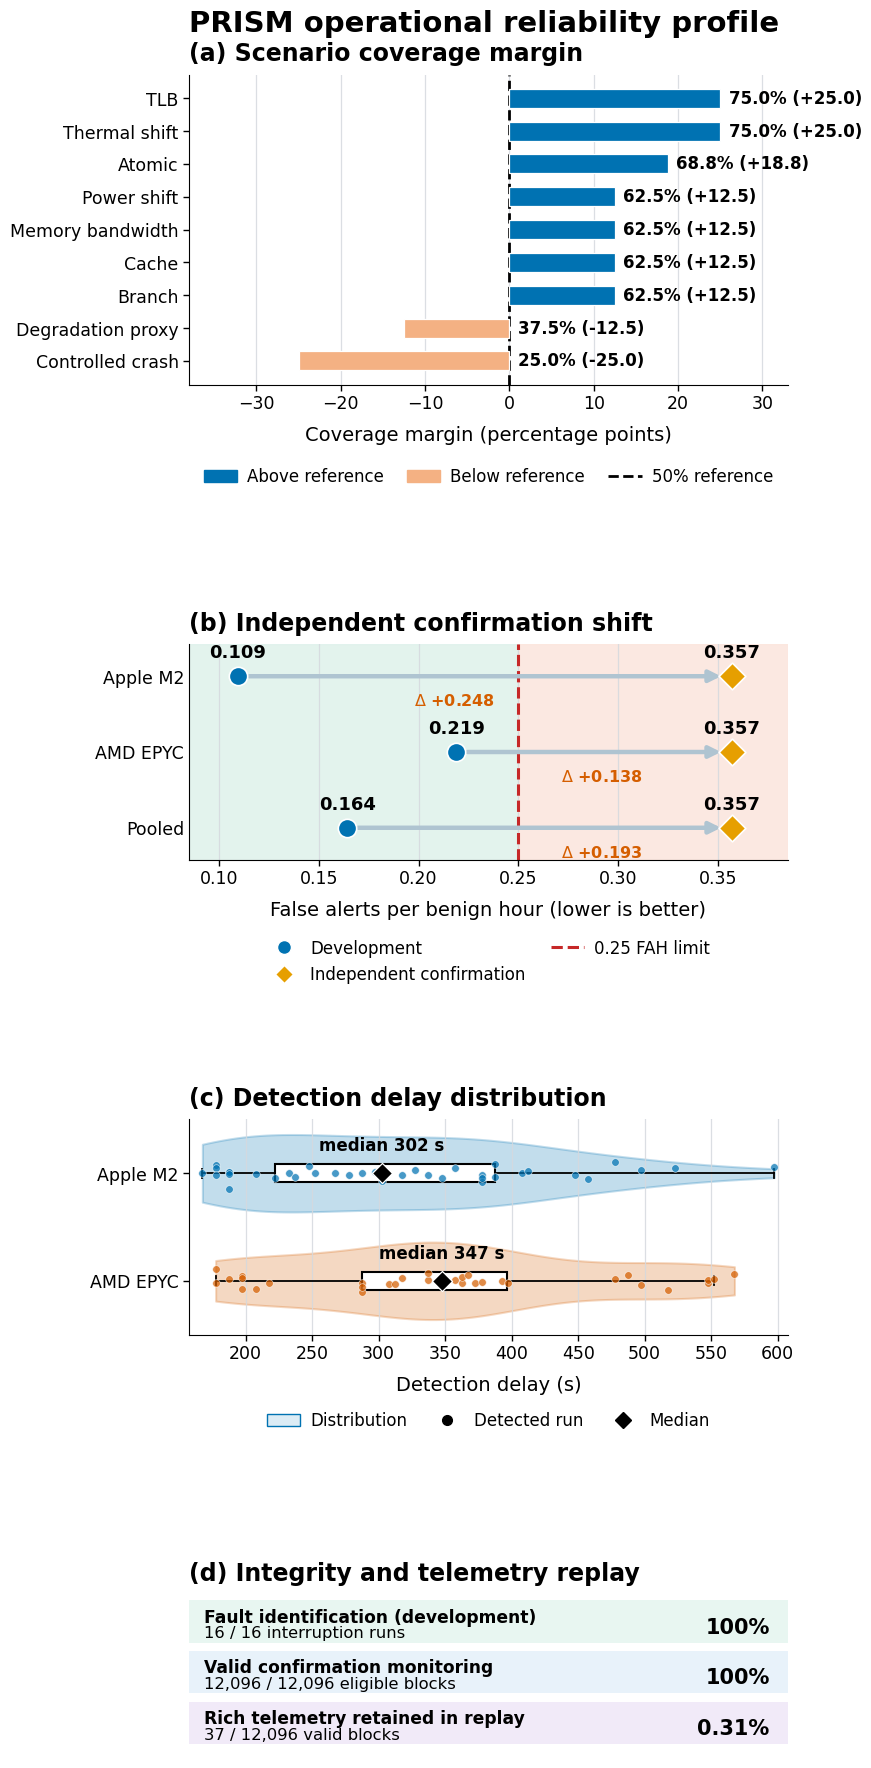

In [68]:
OPERATIONAL_FIGURE_PATH = (
    REPO_ROOT
    / "paper"
    / "figures"
    / "development"
    / "figure-8-operational-reliability-profile.png"
)

if (
    not OPERATIONAL_TABLE_PATH.exists()
    or not SCENARIO_TABLE_PATH.exists()
):
    raise FileNotFoundError(
        "Generate Tables 9 and 10 before Figure 8."
    )

if not DICE_PAPER_RUNS_CSV.exists():
    raise FileNotFoundError(
        "Run Section 17B.13 once to create run-level delays."
    )

operational = pd.read_csv(
    OPERATIONAL_TABLE_PATH
).set_index("Metric")

scenario = pd.read_csv(
    SCENARIO_TABLE_PATH
)

run_scores = pd.read_csv(
    DICE_PAPER_RUNS_CSV
)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

BLUE = "#0072B2"
GREEN = "#009E73"
ORANGE = "#E69F00"
LIGHT_ORANGE = "#F4B183"
VERMILLION = "#D55E00"
PURPLE = "#7B2CBF"
RED = "#C62828"
BLACK = "#000000"
GRID = "#D5D9DE"
TRACK = "#AFC4D1"

figure, axes = plt.subplots(
    4,
    1,
    figsize=(8.2, 18.6),
    gridspec_kw={
        "height_ratios": [1.80, 1.25, 1.25, 0.95]
    },
)

figure.patch.set_facecolor("white")


# ============================================================
# (a) Scenario coverage margin
# ============================================================

scenario_plot = scenario.sort_values(
    "Coverage %",
    ascending=True,
).copy()

scenario_name_map = {
    "ATOMIC": "Atomic",
    "BRANCH": "Branch",
    "CACHE": "Cache",
    "CONTROLLED_CRASH": "Controlled crash",
    "DEGRADATION_PROXY": "Degradation proxy",
    "MEMBW": "Memory bandwidth",
    "POWER_SHIFT": "Power shift",
    "THERMAL_SHIFT": "Thermal shift",
    "TLB": "TLB",
}

scenario_y = np.arange(len(scenario_plot))

scenario_values = scenario_plot[
    "Coverage %"
].to_numpy(dtype=float)

scenario_margins = scenario_values - 50.0

scenario_colors = [
    BLUE if value >= 50.0 else LIGHT_ORANGE
    for value in scenario_values
]

axes[0].barh(
    scenario_y,
    scenario_margins,
    color=scenario_colors,
    height=0.58,
    edgecolor="white",
    linewidth=0.9,
    zorder=3,
)

axes[0].axvline(
    0.0,
    color=BLACK,
    linestyle="--",
    linewidth=2.0,
    zorder=2,
)

for y_value, coverage, margin in zip(
    scenario_y,
    scenario_values,
    scenario_margins,
):
    # The right edge is the positive end for blue bars
    # and the zero reference for negative orange bars.
    bar_right_edge = max(margin, 0.0)

    axes[0].text(
        bar_right_edge + 1.0,
        y_value,
        f"{coverage:.1f}% ({margin:+.1f})",
        va="center",
        ha="left",
        fontsize=12.0,
        fontweight="bold",
        color=BLACK,
        zorder=4,
        clip_on=False,
    )

axes[0].set_xlim(-28, 40)

axes[0].set_yticks(
    scenario_y,
    [
        scenario_name_map[value]
        for value in scenario_plot["Scenario"]
    ],
)

# Additional left space accommodates labels outside orange bars.
axes[0].set_xlim(-38, 33)

axes[0].set_xlabel(
    "Coverage margin (percentage points)",
    fontsize=14,
    labelpad=9,
)

axes[0].set_title(
    "(a) Scenario coverage margin",
    loc="left",
    fontsize=17,
    fontweight="bold",
    color=BLACK,
    pad=10,
)

axes[0].legend(
    handles=[
        Patch(
            facecolor=BLUE,
            edgecolor=BLUE,
            label="Above reference",
        ),
        Patch(
            facecolor=LIGHT_ORANGE,
            edgecolor=LIGHT_ORANGE,
            label="Below reference",
        ),
        Line2D(
            [0],
            [0],
            color=BLACK,
            linestyle="--",
            linewidth=2.0,
            label="50% reference",
        ),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False,
    fontsize=12.0,
    columnspacing=1.4,
    handletextpad=0.6,
)


# ============================================================
# (b) Development to confirmation reliability shift
# ============================================================

scopes = [
    "Apple M2",
    "AMD EPYC",
    "Pooled",
]

development_fah = operational.loc[
    "FAH (development)",
    scopes,
].to_numpy(dtype=float)

confirmation_fah = operational.loc[
    "FAH (confirmation)",
    scopes,
].to_numpy(dtype=float)

reliability_y = np.array([2.0, 1.0, 0.0])

reliability_xmin = 0.085
reliability_xmax = 0.385
reliability_limit = 0.25

axes[1].axvspan(
    reliability_xmin,
    reliability_limit,
    color="#E0F2EC",
    alpha=0.90,
    zorder=0,
)

axes[1].axvspan(
    reliability_limit,
    reliability_xmax,
    color="#FBE6DE",
    alpha=0.90,
    zorder=0,
)

axes[1].axvline(
    reliability_limit,
    color=RED,
    linestyle="--",
    linewidth=2.2,
    zorder=2,
)

delta_label_layout = {
    "Apple M2": {
        "x": 0.238,
        "y_offset": -0.22,
        "ha": "right",
        "va": "top",
    },
    "AMD EPYC": {
        "x": 0.292,
        "y_offset": -0.22,
        "ha": "center",
        "va": "top",
    },
    "Pooled": {
        "x": 0.292,
        "y_offset": -0.22,
        "ha": "center",
        "va": "top",
    },
}

for (
    scope_label,
    y_value,
    development_value,
    confirmation_value,
) in zip(
    scopes,
    reliability_y,
    development_fah,
    confirmation_fah,
):
    axes[1].annotate(
        "",
        xy=(confirmation_value, y_value),
        xytext=(development_value, y_value),
        arrowprops={
            "arrowstyle": "-|>",
            "color": TRACK,
            "linewidth": 3.2,
            "mutation_scale": 17,
            "shrinkA": 8,
            "shrinkB": 8,
        },
        zorder=2,
    )

    axes[1].scatter(
        development_value,
        y_value,
        s=175,
        marker="o",
        color=BLUE,
        edgecolor="white",
        linewidth=1.2,
        zorder=4,
    )

    axes[1].scatter(
        confirmation_value,
        y_value,
        s=185,
        marker="D",
        color=ORANGE,
        edgecolor="white",
        linewidth=1.2,
        zorder=4,
    )

    axes[1].text(
        development_value,
        y_value + 0.19,
        f"{development_value:.3f}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color=BLACK,
        zorder=5,
    )

    axes[1].text(
        confirmation_value,
        y_value + 0.19,
        f"{confirmation_value:.3f}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color=BLACK,
        zorder=5,
    )

    change = confirmation_value - development_value
    label_layout = delta_label_layout[scope_label]

    axes[1].text(
        label_layout["x"],
        y_value + label_layout["y_offset"],
        rf"$\Delta$ {change:+.3f}",
        ha=label_layout["ha"],
        va=label_layout["va"],
        fontsize=11.5,
        fontweight="bold",
        color=VERMILLION,
        zorder=5,
    )

axes[1].set_xlim(
    reliability_xmin,
    reliability_xmax,
)

axes[1].set_ylim(-0.42, 2.42)

axes[1].set_yticks(
    reliability_y,
    scopes,
)

axes[1].set_xticks(
    [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
)

axes[1].set_xlabel(
    "False alerts per benign hour (lower is better)",
    fontsize=14,
    labelpad=9,
)

axes[1].set_title(
    "(b) Independent confirmation shift",
    loc="left",
    fontsize=17,
    fontweight="bold",
    color=BLACK,
    pad=10,
)

axes[1].legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=BLUE,
            markeredgecolor="white",
            markersize=10,
            label="Development",
        ),
        Line2D(
            [0],
            [0],
            marker="D",
            linestyle="none",
            markerfacecolor=ORANGE,
            markeredgecolor="white",
            markersize=9,
            label="Independent confirmation",
        ),
        Line2D(
            [0],
            [0],
            color=RED,
            linestyle="--",
            linewidth=2.2,
            label="0.25 FAH limit",
        ),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=2,
    frameon=False,
    fontsize=12.0,
    columnspacing=1.5,
    handletextpad=0.6,
)


# ============================================================
# (c) Detection delay distribution
# ============================================================

platform_specs = [
    ("M2_MACOS", "Apple M2", BLUE),
    ("EPYC_LINUX", "AMD EPYC", VERMILLION),
]

delay_groups = []

for platform_id, _, _ in platform_specs:
    delays = run_scores.loc[
        (
            run_scores["platform_id"]
            == platform_id
        )
        & run_scores[
            "detection_delay_seconds"
        ].notna(),
        "detection_delay_seconds",
    ].sort_values().to_numpy(dtype=float)

    delay_groups.append(delays)

delay_positions = np.asarray([1.0, 0.0])

violin = axes[2].violinplot(
    delay_groups,
    positions=delay_positions,
    vert=False,
    widths=0.72,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)

for body, (_, _, color) in zip(
    violin["bodies"],
    platform_specs,
):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_linewidth(1.5)
    body.set_alpha(0.24)

axes[2].boxplot(
    delay_groups,
    positions=delay_positions,
    vert=False,
    widths=0.17,
    patch_artist=True,
    showfliers=False,
    boxprops={
        "facecolor": "white",
        "edgecolor": BLACK,
        "linewidth": 1.5,
    },
    whiskerprops={
        "color": BLACK,
        "linewidth": 1.3,
    },
    capprops={
        "color": BLACK,
        "linewidth": 1.3,
    },
    medianprops={
        "color": BLACK,
        "linewidth": 2.0,
    },
)

rng = np.random.default_rng(20260825)

for (
    position,
    delays,
    (_, _, color),
) in zip(
    delay_positions,
    delay_groups,
    platform_specs,
):
    jitter = rng.normal(
        position,
        0.045,
        size=len(delays),
    )

    axes[2].scatter(
        delays,
        jitter,
        s=30,
        color=color,
        alpha=0.72,
        edgecolor="white",
        linewidth=0.5,
        zorder=3,
    )

    median_delay = float(np.median(delays))

    axes[2].scatter(
        [median_delay],
        [position],
        marker="D",
        s=105,
        color=BLACK,
        edgecolor="white",
        linewidth=0.9,
        zorder=5,
    )

    axes[2].annotate(
        f"median {median_delay:.0f} s",
        (median_delay, position),
        xytext=(0, 16),
        textcoords="offset points",
        ha="center",
        fontsize=12,
        fontweight="bold",
        color=BLACK,
    )

all_delays = np.concatenate(delay_groups)

axes[2].set_xlim(
    float(all_delays.min()) - 10,
    float(all_delays.max()) + 10,
)

axes[2].set_yticks(
    delay_positions,
    [item[1] for item in platform_specs],
)

axes[2].set_xlabel(
    "Detection delay (s)",
    fontsize=14,
    labelpad=9,
)

axes[2].set_title(
    "(c) Detection delay distribution",
    loc="left",
    fontsize=17,
    fontweight="bold",
    color=BLACK,
    pad=10,
)

axes[2].legend(
    handles=[
        Patch(
            facecolor="#DCECF5",
            edgecolor=BLUE,
            label="Distribution",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            color=BLACK,
            markersize=7,
            label="Detected run",
        ),
        Line2D(
            [0],
            [0],
            marker="D",
            linestyle="none",
            color=BLACK,
            markersize=8,
            label="Median",
        ),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.29),
    ncol=3,
    frameon=False,
    fontsize=12.0,
    columnspacing=1.4,
    handletextpad=0.6,
)


# ============================================================
# (d) Direct integrity and replay accounting; unlike metrics use no shared axis.
# ============================================================

replay_counts = pd.read_csv(
    REPO_ROOT / "paper" / "results" / "manuscript" / "sources" / "v3-confirmation-runs.csv"
)
rich_blocks = int(replay_counts["full_tier_blocks"].sum())
valid_blocks = int(replay_counts["valid_blocks"].sum())
eligible_blocks = int(replay_counts["eligible_blocks"].sum())
coverage_counts = pd.read_csv(PAPER_TABLE_ROOT / "table-2-scenario-coverage.csv").set_index("scenario")
fault_runs = int(coverage_counts.loc["TELEMETRY_INTERRUPTION", "Total"])
identified = int(round(fault_runs * float(operational.loc["Telemetry fault ID", "Pooled"]) / 100))

accounting = [
    ("Fault identification (development)", f"{identified} / {fault_runs} interruption runs",
     f"{100 * identified / fault_runs:.0f}%", "#E8F6F1"),
    ("Valid confirmation monitoring", f"{valid_blocks:,} / {eligible_blocks:,} eligible blocks",
     f"{100 * valid_blocks / eligible_blocks:.0f}%", "#E8F2FA"),
    ("Rich telemetry retained in replay", f"{rich_blocks} / {valid_blocks:,} valid blocks",
     f"{100 * rich_blocks / valid_blocks:.2f}%", "#F1EAF8"),
]
axes[3].set_axis_off()
for row_index, (label, detail, rate, background) in enumerate(accounting):
    top = 0.97 - 0.31 * row_index
    axes[3].add_patch(plt.Rectangle((0, top - 0.265), 1, 0.26,
                                  transform=axes[3].transAxes,
                                  facecolor=background, edgecolor="none", zorder=0))
    axes[3].text(0.025, top - 0.055, label, transform=axes[3].transAxes,
                 ha="left", va="top", fontsize=12.3, fontweight="bold", color=BLACK)
    axes[3].text(0.025, top - 0.163, detail, transform=axes[3].transAxes,
                 ha="left", va="top", fontsize=11.8, color=BLACK)
    axes[3].text(0.97, top - 0.17, rate, transform=axes[3].transAxes,
                 ha="right", va="center", fontsize=15, fontweight="bold", color=BLACK)
axes[3].set_title("(d) Integrity and telemetry replay", loc="left", fontsize=17,
                  fontweight="bold", color=BLACK, pad=10)

# ============================================================
# Shared publication formatting
# ============================================================

for axis in axes:
    axis.set_facecolor("white")

    axis.tick_params(
        axis="both",
        labelsize=12.5,
        colors=BLACK,
        width=1.0,
        length=4,
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    axis.spines["left"].set_color(BLACK)
    axis.spines["bottom"].set_color(BLACK)

    axis.xaxis.label.set_color(BLACK)
    axis.yaxis.label.set_color(BLACK)

axes[0].grid(
    axis="x",
    color=GRID,
    linewidth=0.9,
    alpha=0.85,
    zorder=0,
)

axes[1].grid(
    axis="x",
    color=GRID,
    linewidth=0.9,
    alpha=0.85,
    zorder=0,
)

axes[1].tick_params(
    axis="x",
    length=4,
)

axes[1].tick_params(
    axis="y",
    length=0,
)

axes[2].grid(
    axis="x",
    color=GRID,
    linewidth=0.9,
    alpha=0.85,
    zorder=0,
)

axes[3].grid(
    axis="x",
    color=GRID,
    linewidth=0.9,
    alpha=0.85,
    zorder=0,
)

figure.suptitle(
    "PRISM operational reliability profile",
    x=0.24,
    y=0.985,
    ha="left",
    fontsize=21,
    fontweight="bold",
    color=BLACK,
)

figure.subplots_adjust(
    left=0.24,
    right=0.97,
    bottom=0.045,
    top=0.95,
    hspace=1.15,
)

save_paper_figure(
    figure,
    OPERATIONAL_FIGURE_PATH.name,
)

plt.show()

### Table 11 — Supporting diagnostic design space

This optional post hoc result compares five model families on complete run
folds. It is not a primary result in the current draft. Worst platform is the
lower host F1; inference time depends on the execution host. Use the generated
table below, not a manually copied timing table. These metrics do not replace
the sequential monitor's independent confirmation or FAH requirement.


In [69]:
if not DIAGNOSTIC_PAPER_TABLE.exists():
    raise FileNotFoundError(
        "Run Section 17B.14 once to generate the diagnostic ranking table."
    )
diagnostic_table = pd.read_csv(DIAGNOSTIC_PAPER_TABLE)
diagnostic_table = diagnostic_table.rename(columns={
    "model": "Model", "auc_pr": "AUC PR", "roc_auc": "ROC AUC",
    "mcc": "MCC", "balanced_accuracy": "Balanced accuracy",
    "f1": "F1", "brier": "Brier",
    "worst_platform_f1": "Worst platform F1",
    "inference_time_ms_per_run": "Inference ms/run",
})
display(diagnostic_table.style.format({
    "AUC PR": "{:.3f}", "ROC AUC": "{:.3f}", "MCC": "{:.3f}",
    "Balanced accuracy": "{:.3f}", "F1": "{:.3f}",
    "Brier": "{:.3f}", "Worst platform F1": "{:.3f}",
    "Inference ms/run": "{:.3f}",
}))


,Model,AUC PR,ROC AUC,MCC,Balanced accuracy,F1,Brier,Worst platform F1,Inference ms/run
0,Benign only One Class SVM,0.934,0.881,0.425,0.609,0.906,nan,0.896,0.005
1,Logistic regression,0.996,0.982,0.622,0.875,0.857,0.180,0.824,0.008
2,Random Forest,0.994,0.979,0.762,0.881,0.950,0.064,0.940,0.158
3,ExtraTrees,0.997,0.986,0.858,0.914,0.971,0.054,0.967,0.188
4,Gradient boosting,0.989,0.963,0.776,0.874,0.955,0.054,0.941,0.015


### Figure 9 — Post hoc diagnostic discrimination and stress tests

Panels (a) and (b) show complete run ROC and precision recall curves. Panel (c)
checks Apple, EPYC, and workload subgroups. Panel (d) excludes a workload, a
platform, or an event type during fitting to expose transfer limits.

![Post hoc complete run diagnostic ranking](../paper/figures/development/figure-9-development-diagnostic-ranker.png)


In [70]:
from IPython.display import Image as NotebookImage

if not DIAGNOSTIC_PAPER_FIGURE.exists():
    raise FileNotFoundError(
        "Run Section 17B.14 once to generate Figure 9."
    )
display(NotebookImage(filename=str(DIAGNOSTIC_PAPER_FIGURE)))


### Supplementary Table S1 — DICE comparable complete run performance

This table places familiar AUC PR, ROC AUC, precision, recall, and F1 beside
PRISM's operational FAH, delay, and telemetry fault metrics. Scores are
development only, complete run grouped, and cross fitted. The frozen alert
decision is not retuned for these metrics.


In [71]:
if not DICE_PAPER_TABLE.exists():
    raise FileNotFoundError(
        "Run Section 17B.13 with RUN_DICE_COMPARABLE_METRICS=True."
    )
DICE_COMPLETE_RUN_TABLE = pd.read_csv(DICE_PAPER_TABLE)
display(DICE_COMPLETE_RUN_TABLE.round(3))


,Scope,Benign runs,Event runs,Detected events,AUC PR,ROC AUC,Precision,Recall,F1 event,F1 macro,FAH,Median TTD s,Fault ID
0,Pooled,48,120,71/120,0.755,0.527,0.922,0.592,0.721,0.663,0.164,337.487,1.0
1,EPYC_LINUX,24,60,34/60,0.717,0.469,0.895,0.567,0.694,0.633,0.219,347.497,1.0
2,M2_MACOS,24,60,37/60,0.797,0.579,0.949,0.617,0.747,0.693,0.109,302.484,1.0


### Supplementary Table S2 — DICE comparable workload robustness

This table keeps each functional workload visible so that a favorable pooled
metric cannot conceal a weak workload. It uses the same complete run score and
unchanged sequential decision as Supplementary Table S1.


In [72]:
if not DICE_PAPER_WORKLOAD_TABLE.exists():
    raise FileNotFoundError(
        "Run Section 17B.13 with RUN_DICE_COMPARABLE_METRICS=True."
    )
DICE_WORKLOAD_TABLE = pd.read_csv(DICE_PAPER_WORKLOAD_TABLE)
display(DICE_WORKLOAD_TABLE.round(3))


,Workload,Benign runs,Event runs,AUC PR,ROC AUC,Precision,Recall,F1 event,F1 macro,FAH
0,BROWSER,12,24,0.754,0.587,1.000,0.500,0.667,0.667,0.000
1,PY_AI,12,36,0.838,0.639,0.871,0.750,0.806,0.679,0.438
2,PY_STATS,12,36,0.677,0.319,0.941,0.444,0.604,0.558,0.109
3,VIDEO_SW,12,24,0.731,0.569,0.941,0.667,0.780,0.745,0.109


### Supplementary Figure S1 — Complete run ROC and precision recall curves

The pooled and platform curves show how well the cross fitted behavioral score
ranks controlled event runs above benign runs. They complement, but do not
replace, the independent benign confirmation and FAH result.


Saved PNG and vector PDF: /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/figures/development/figure-s1-dice-comparable-discrimination.png


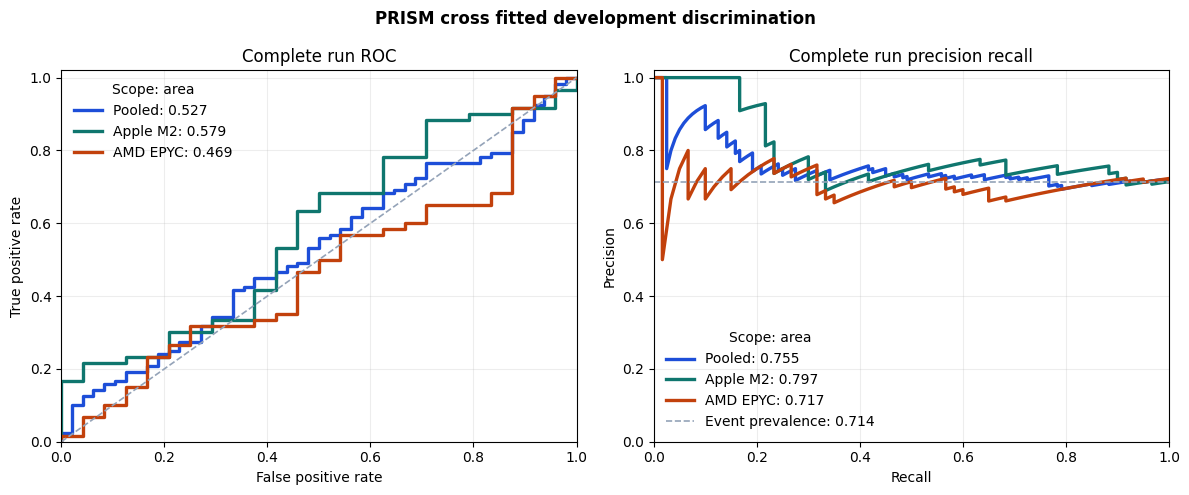

In [73]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

if not DICE_PAPER_RUNS_CSV.exists():
    raise FileNotFoundError(
        "Run Section 17B.13 with RUN_DICE_COMPARABLE_METRICS=True."
    )
curve_runs = pd.read_csv(DICE_PAPER_RUNS_CSV)
curve_runs = curve_runs.loc[
    curve_runs["behavioral_classification_included"].astype(bool)
].copy()
curve_scopes = [
    ("Pooled", curve_runs, "#1d4ed8"),
    (
        "Apple M2",
        curve_runs.loc[curve_runs["platform_id"] == "M2_MACOS"],
        "#0f766e",
    ),
    (
        "AMD EPYC",
        curve_runs.loc[curve_runs["platform_id"] == "EPYC_LINUX"],
        "#c2410c",
    ),
]

figure, axes = plt.subplots(1, 2, figsize=(12.0, 5.0))
for label, part, color in curve_scopes:
    y_true = part["true_label"].to_numpy(dtype=int)
    score = part["run_score_peak"].to_numpy(dtype=float)
    false_positive_rate, true_positive_rate, _ = roc_curve(y_true, score)
    precision, recall, _ = precision_recall_curve(y_true, score)
    roc_value = roc_auc_score(y_true, score)
    pr_value = average_precision_score(y_true, score)
    axes[0].plot(
        false_positive_rate,
        true_positive_rate,
        color=color,
        linewidth=2.4,
        label=f"{label}: {roc_value:.3f}",
    )
    axes[1].plot(
        recall,
        precision,
        color=color,
        linewidth=2.4,
        label=f"{label}: {pr_value:.3f}",
    )

axes[0].plot(
    [0, 1], [0, 1], color="#94a3b8", linestyle="--", linewidth=1.2
)
axes[0].set_title("Complete run ROC")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
event_prevalence = float(np.mean(curve_runs["true_label"]))
axes[1].axhline(
    event_prevalence,
    color="#94a3b8",
    linestyle="--",
    linewidth=1.2,
    label=f"Event prevalence: {event_prevalence:.3f}",
)
axes[1].set_title("Complete run precision recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
for axis in axes:
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1.02)
    axis.grid(alpha=0.22)
    axis.legend(frameon=False, title="Scope: area")
figure.suptitle(
    "PRISM cross fitted development discrimination",
    fontweight="bold",
)
figure.tight_layout()
save_paper_figure(
    figure, "figure-s1-dice-comparable-discrimination.png"
)
plt.show()


### Supplement — Complete candidate tables

These full tables provide every evaluated development operating point for
reproducibility and supplementary-material review.


In [74]:
for label, candidates in PAPER_CANDIDATES.items():
    sort_columns = (
        ["fah", "detection"]
        if {"fah", "detection"}.issubset(candidates.columns)
        else ["false_alerts_per_hour", "anomaly_run_detection_rate"]
    )
    ordered = candidates.sort_values(
        sort_columns,
        ascending=[True, False],
    ).reset_index(drop=True)
    display(Markdown(f"#### {label}: all {len(ordered)} candidates"))
    display(ordered)

print("Development artifacts:")
for label, paths in PAPER_RESULT_FILES.items():
    print(f"{label}:")
    for path in paths:
        print(f"  {path}")
print()
print("These are initial development candidates; Section 17E distinguishes v3 development and confirmation.")
print("The reserved partition remains sealed.")


#### Static VAR: all 57 candidates

,method,family,detector,parameters,false_alerts,benign_hours,false_alerts_per_hour,anomaly_runs,detected_runs,anomaly_run_detection_rate,median_time_to_detect_seconds,interruption_runs,telemetry_fault_identification_rate
0,DICE_RIDGE_PERSISTENCE,ridge,persistence,"{""alpha"": 0.01, ""consecutive"": 2, ""cooldown_bl...",0,12.533333,0.000000,120,0,0.000000,NaN,16,1.0
1,DICE_RIDGE_PERSISTENCE,ridge,persistence,"{""alpha"": 0.01, ""consecutive"": 3, ""cooldown_bl...",0,12.533333,0.000000,120,0,0.000000,NaN,16,1.0
2,DICE_RIDGE_PERSISTENCE,ridge,persistence,"{""alpha"": 0.01, ""consecutive"": 5, ""cooldown_bl...",0,12.533333,0.000000,120,0,0.000000,NaN,16,1.0
3,STATIC_VAR_PERSISTENCE,var,persistence,"{""alpha"": 0.01, ""consecutive"": 2, ""cooldown_bl...",0,12.533333,0.000000,120,0,0.000000,NaN,16,1.0
4,STATIC_VAR_PERSISTENCE,var,persistence,"{""alpha"": 0.01, ""consecutive"": 3, ""cooldown_bl...",0,12.533333,0.000000,120,0,0.000000,NaN,16,1.0
5,STATIC_VAR_PERSISTENCE,var,persistence,"{""alpha"": 0.01, ""consecutive"": 5, ""cooldown_bl...",0,12.533333,0.000000,120,0,0.000000,NaN,16,1.0
6,STATIC_VAR_SEQUENTIAL_CONFORMAL,var,eprocess,"{""cooldown_blocks"": 6, ""eta"": 0.9, ""log_thresh...",311,12.533333,24.813830,120,117,0.975000,92.496878,16,1.0
7,STATIC_VAR_SEQUENTIAL_CONFORMAL,var,eprocess,"{""cooldown_blocks"": 6, ""eta"": 0.9, ""log_thresh...",402,12.533333,32.074468,120,117,0.975000,42.497977,16,1.0
8,STATIC_VAR_SEQUENTIAL_CONFORMAL,var,eprocess,"{""cooldown_blocks"": 6, ""eta"": 0.9, ""log_thresh...",653,12.533333,52.101064,120,117,0.975000,42.496284,16,1.0
9,STATIC_VAR_PERSISTENCE,var,persistence,"{""alpha"": 0.02, ""consecutive"": 5, ""cooldown_bl...",886,12.533333,70.691489,120,112,0.933333,7.498068,16,1.0


#### Guarded adaptive VAR: all 88 candidates

,method,family,detector,parameters,false_alerts,benign_hours,false_alerts_per_hour,anomaly_runs,detected_runs,anomaly_run_detection_rate,median_time_to_detect_seconds,interruption_runs,telemetry_fault_identification_rate
0,GUARDED_VAR_PERSISTENCE,guarded_var,persistence,"{""alpha"": 0.005, ""consecutive"": 3, ""cooldown_b...",0,10.0,0.0,120,0,0.000000,NaN,16,1.0
1,GUARDED_VAR_PERSISTENCE,guarded_var,persistence,"{""alpha"": 0.005, ""consecutive"": 5, ""cooldown_b...",0,10.0,0.0,120,0,0.000000,NaN,16,1.0
2,GUARDED_VAR_PERSISTENCE,guarded_var,persistence,"{""alpha"": 0.005, ""consecutive"": 8, ""cooldown_b...",0,10.0,0.0,120,0,0.000000,NaN,16,1.0
3,GUARDED_VAR_PERSISTENCE,guarded_var,persistence,"{""alpha"": 0.005, ""consecutive"": 12, ""cooldown_...",0,10.0,0.0,120,0,0.000000,NaN,16,1.0
4,GUARDED_VAR_PERSISTENCE,guarded_var,persistence,"{""alpha"": 0.001, ""consecutive"": 3, ""cooldown_b...",0,10.0,0.0,120,0,0.000000,NaN,16,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,GUARDED_VAR_CUSUM,guarded_var,cusum,"{""cooldown_blocks"": 12, ""reference"": 0.5, ""thr...",202,10.0,20.2,120,112,0.933333,12.493468,16,1.0
84,GUARDED_VAR_SEQUENTIAL_CONFORMAL,guarded_var,eprocess,"{""cooldown_blocks"": 12, ""eta"": 0.5, ""log_thres...",208,10.0,20.8,120,115,0.958333,27.498505,16,1.0
85,GUARDED_VAR_CUSUM,guarded_var,cusum,"{""cooldown_blocks"": 12, ""reference"": 1.0, ""thr...",215,10.0,21.5,120,111,0.925000,7.496950,16,1.0
86,GUARDED_VAR_CUSUM,guarded_var,cusum,"{""cooldown_blocks"": 12, ""reference"": 0.5, ""thr...",225,10.0,22.5,120,113,0.941667,7.498097,16,1.0


#### Robust residual fusion: all 4836 candidates

,C,threshold,consecutive,false_alerts,benign_hours,fah,detected,runs,detection,ttd,telemetry_fault_identification_rate
0,0.003,0.99300,52,0,7.466667,0.000000,13,120,0.108333,327.498045,1.0
1,0.003,0.99300,56,0,7.466667,0.000000,13,120,0.108333,347.498045,1.0
2,0.003,0.99325,52,0,7.466667,0.000000,13,120,0.108333,327.498045,1.0
3,0.003,0.99325,56,0,7.466667,0.000000,13,120,0.108333,347.498045,1.0
4,0.003,0.99350,52,0,7.466667,0.000000,13,120,0.108333,327.498045,1.0
...,...,...,...,...,...,...,...,...,...,...,...
4831,0.300,0.90000,1,145,7.466667,19.419643,119,120,0.991667,2.498032,1.0
4832,0.300,0.93000,1,145,7.466667,19.419643,118,120,0.983333,2.498125,1.0
4833,1.000,0.93000,1,148,7.466667,19.821429,119,120,0.991667,2.497399,1.0
4834,1.000,0.97000,1,148,7.466667,19.821429,119,120,0.991667,2.498072,1.0


Development artifacts:
Static VAR:
  /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/results/development/development-method-selection.json
  /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/results/development/development-method-selection.csv
Guarded adaptive VAR:
  /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/results/development/development-guarded-method-selection.json
  /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/results/development/development-guarded-method-selection.csv
Robust residual fusion:
  /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/results/development/development-robust-normalization-selection.json
  /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/results/development/development-robust-normalization-candidates.csv

These are initial development candidates; Section 17E distinguishes v3 development and confirmation.
The reserved partition remains sealed.


## 17E. Current manuscript tables and consistency check

This saved-evidence cell reproduces the current paper's Tables III–VI and
conditional confidence intervals. It verifies pinned report hashes, protocol
hashes, evidence roles, and reported v3 values. It does not refit a model,
recollect confirmation, or validate raw data again.

Outputs go to `paper/results/manuscript/` as CSV and Overleaf table snippets.
Keep the paper's definitions and caveats in the accompanying paragraphs:
revision sets are not paired, development exposures differ, delays condition
on detected events, and transfer is an earlier development checkpoint.
See [the paper map](../docs/paper-artifacts.md) for exact placement.


In [75]:
# Paper reproduction from pinned summaries; no raw data or model fitting.
from pathlib import Path
from statistics import NormalDist
import hashlib
import json
import numpy as np
import pandas as pd
from scipy.stats import chi2
from IPython.display import Markdown, display

MANUSCRIPT_ROOT = REPO_ROOT / "paper" / "results" / "manuscript"
MANUSCRIPT_SOURCES = MANUSCRIPT_ROOT / "sources"
manifest = json.loads((MANUSCRIPT_SOURCES / "input-manifest.json").read_text())

def require_paper(condition, message):
    if not condition:
        raise RuntimeError(f"Paper evidence mismatch: {message}")

for relative, expected in manifest["bundled_sha256"].items():
    actual = hashlib.sha256((REPO_ROOT / relative).read_bytes()).hexdigest()
    require_paper(actual == expected, relative)

def read_paper_report(name):
    report = json.loads((MANUSCRIPT_SOURCES / name).read_text())
    require_paper(report.get("locked_test_accessed") is False, name)
    return report

v2_paper = read_paper_report("v2-independent-confirmation.json")
v3_paper = read_paper_report("v3-independent-confirmation.json")
v3_development = read_paper_report("v3-development-selection.json")
v3_selected = v3_development["selected"]
require_paper(
    v3_paper["development_dataset_fingerprint"] == v3_development["dataset_fingerprint"],
    "v3 development fingerprint",
)
for revision, report in (("v2", v2_paper), ("v3", v3_paper)):
    protocol = REPO_ROOT / "configs" / f"{revision}-independent-confirmation.toml"
    plan = REPO_ROOT / "data" / f"{revision}-independent-confirmation-plan.csv"
    require_paper(hashlib.sha256(protocol.read_bytes()).hexdigest() == report["protocol_sha256"],
                  f"{revision} protocol fingerprint")
    require_paper(hashlib.sha256(plan.read_bytes()).hexdigest() == report["plan_sha256"],
                  f"{revision} plan fingerprint")
    require_paper(report["fit_or_tune_on_confirmation"] is False, f"{revision} evidence role")
    require_paper(report["candidate_count"] == 1, f"{revision} confirmation candidate count")

require_paper(v3_development["development_g3_passed"] is True, "v3 development gate")
require_paper(v3_selected["strict_platform_fold_g3"] is True, "v3 subgroup gates")
require_paper(v2_paper["pooled_metrics"]["false_alerts"] == 17, "v2 episode count")
require_paper(v3_paper["confirmation_passed"] is False, "v3 preserved confirmation")
require_paper(v3_paper["eligible_for_locked_test"] is False, "reserved boundary")
require_paper((v3_selected["detected"], v3_selected["runs"]) == (71, 120), "event counts")
require_paper(v3_selected["false_alerts"] == 6, "development episode count")
require_paper(np.isclose(v3_selected["benign_hours"], 36.53333333333333), "development exposure")
require_paper(np.isclose(v3_selected["ttd"], 337.48666995798703), "conditional delay")
require_paper(v3_selected["telemetry_fault_identification_rate"] == 1.0, "fault identification")

original = pd.read_csv(MANUSCRIPT_SOURCES / "original-inventory.csv")
quality = pd.read_csv(MANUSCRIPT_SOURCES / "original-quality.csv").set_index("Platform")
original_count = int(original["Admitted runs"].sum())
reserved_count = int(original["Locked rows still planned"].sum())
supplement_count = len(pd.read_csv(REPO_ROOT / "data" / "development-benign-supplement-plan.csv"))
v2_count = int(v2_paper["pooled_metrics"]["runs"])
v3_count = int(v3_paper["pooled_metrics"]["runs"])
development_count = original_count + supplement_count + v2_count
total_count = development_count + v3_count
require_paper((original_count, development_count, total_count, reserved_count) == (160, 192, 208, 92),
              "inventory totals")
# The supplement plan supplies its declared count; the preserved v3 dataset
# report attests its admission. This is not another raw validation pass.

def export_manuscript_table(table, stem, caption, label, decimals=3):
    table.to_csv(MANUSCRIPT_ROOT / f"{stem}.csv", index=False)
    # Compact print headers; CSV headings remain descriptive for reuse.
    print_table = table.rename(columns={
        "Warnings": "Warn.", "Min. availability": "Min. avail.",
        "Revision": "Rev.", "Added runs": "Added", "Cumulative": "Total",
        "Confirmation runs": "Confirm.", "Development checkpoint": "Monitor",
        "Selection": "Dev. status",
    }).copy()
    if "Dev. status" in print_table:
        print_table["Dev. status"] = print_table["Dev. status"].replace(
            {"Advanced to confirmation": "Pass"}
        )
    if stem == "table-vi-transfer-calibration":
        print_table.columns = pd.MultiIndex.from_tuples([
            ("Destination (min)", ""), ("M2 to EPYC", "FAH"),
            ("M2 to EPYC", "DR"), ("EPYC to M2", "FAH"), ("EPYC to M2", "DR"),
        ])
    tabular = print_table.to_latex(index=False, escape=True, na_rep="---",
                                  multicolumn_format="c",
                                  float_format=lambda x: f"{x:.{decimals}f}")
    latex = ("\\begin{table}[!t]\n\\centering\n"
             + f"\\caption{{{caption}}}\n\\label{{{label}}}\n"
             + "{\\scriptsize\n\\setlength{\\tabcolsep}{3pt}\n"
             + "\\renewcommand{\\arraystretch}{1.05}\n"
             + "\\resizebox{\\columnwidth}{!}{%\n" + tabular
             + "}\n}\n\\end{table}\n")
    (MANUSCRIPT_ROOT / f"{stem}.tex").write_text(latex, encoding="utf-8")
    display(Markdown(f"### {caption}"))
    display(table.round(decimals))

quality_rows = []
for row in original.to_dict("records"):
    platform = row["Platform"]
    q = quality.loc[platform]
    quality_rows.append({
        "Platform": "Apple M2 Pro" if platform == "M2_MACOS" else "AMD EPYC 9354",
        "C/D": f"{row['Calibration runs']}/{row['Development runs']}",
        "V/I": f"{int(q['Valid runs'])}/{int(q['Invalid runs'])}",
        "Benign h": float(q["Valid benign hours"]),
        "Warnings": int(q["Warning events"]),
        "Min. availability": float(q["Minimum critical availability"]),
        "Reserved": int(row["Locked rows still planned"]),
    })
quality_rows.append({
    "Platform": "Combined", "C/D": "8/152", "V/I": "160/0",
    "Benign h": sum(r["Benign h"] for r in quality_rows),
    "Warnings": sum(r["Warnings"] for r in quality_rows),
    "Min. availability": min(r["Min. availability"] for r in quality_rows),
    "Reserved": reserved_count,
})
export_manuscript_table(pd.DataFrame(quality_rows), "table-iii-data-quality",
                        "Original matched evidence and admission integrity audit.",
                        "tab:development_data_quality")

revision_rows = [{"Revision": "v1", "Added runs": "160 + 16", "Cumulative": original_count + supplement_count,
                  "Confirmation runs": np.nan, "Benign h": np.nan, "Episodes": np.nan, "FAH": np.nan}]
for revision, report, cumulative in (("v2", v2_paper, development_count), ("v3", v3_paper, total_count)):
    p = report["pooled_metrics"]
    require_paper(np.isclose(p["fah"], p["false_alerts"] / p["benign_hours"]), f"{revision} FAH")
    require_paper(np.isclose(p["benign_hours"], 16.8), f"{revision} exposure")
    revision_rows.append({"Revision": revision, "Added runs": str(p["runs"]), "Cumulative": cumulative,
                          "Confirmation runs": p["runs"], "Benign h": p["benign_hours"],
                          "Episodes": p["false_alerts"], "FAH": p["fah"]})
revision_table = pd.DataFrame(revision_rows)
for column in ["Confirmation runs", "Episodes"]:
    revision_table[column] = revision_table[column].astype("Int64")
export_manuscript_table(revision_table, "table-iv-revision-history",
                        "Evidence inventory and independent confirmation by revision.", "tab:prism_revision_history")

initial = pd.read_csv(MANUSCRIPT_SOURCES / "initial-checkpoints.csv").set_index("Method")
progression = []
for name in ["Static VAR", "Guarded adaptive VAR", "Robust residual fusion"]:
    row = initial.loc[name]
    progression.append({"Development checkpoint": name, "FAH": f"{row['False alerts/hour']:.2f}",
                        "DR": f"{row['Detection (%)']:.1f}%",
                        "Selection": "Pooled only" if name == "Robust residual fusion" else "Outside"})
progression.append({"Development checkpoint": "PRISM sequential (v3)", "FAH": f"{v3_selected['fah']:.3f}",
                    "DR": f"{100*v3_selected['detection']:.1f}%", "Selection": "Advanced to confirmation"})
export_manuscript_table(pd.DataFrame(progression), "table-v-development-progression",
                        "Development trajectory toward the selected G3 setting.", "tab:development_g3")

transfer = pd.read_csv(MANUSCRIPT_SOURCES / "development-transfer-calibration.csv")
require_paper(set(transfer["family"]) == {"robust_normalized_fusion"}, "transfer checkpoint")
transfer_rows = []
for minutes in [0, 1, 2, 4, 8, 12]:
    row = {"Destination min": minutes}
    for source, name in [("M2_MACOS", "M2 to EPYC"), ("EPYC_LINUX", "EPYC to M2")]:
        match = transfer[(transfer["source_platform"] == source) &
                         (transfer["destination_calibration_minutes"] == minutes)]
        require_paper(len(match) == 1, f"transfer {source}, {minutes} min")
        item = match.iloc[0]
        row[f"{name} FAH"] = float(item["false_alerts_per_hour"])
        row[f"{name} DR"] = f"{100 * item['anomaly_run_detection_rate']:.1f}%"
    transfer_rows.append(row)
require_paper(not ((transfer["false_alerts_per_hour"] <= .25) &
                  (transfer["anomaly_run_detection_rate"] >= .5)).any(), "transfer gate result")
export_manuscript_table(pd.DataFrame(transfer_rows), "table-vi-transfer-calibration",
                        "Development transfer calibration in both platform directions.", "tab:transfer_calibration")

def poisson_interval(count, hours):
    lower = 0.0 if count == 0 else .5 * chi2.ppf(.025, 2 * count) / hours
    return lower, .5 * chi2.ppf(.975, 2 * (count + 1)) / hours

interval_rows = []
for name, p in [("Development FAH", v3_selected), ("Confirmation FAH", v3_paper["pooled_metrics"])]:
    low, high = poisson_interval(p["false_alerts"], p["benign_hours"])
    interval_rows.append({"Quantity": name, "Unit": "episodes/h", "Lower 95%": low, "Upper 95%": high})
for platform, p in v3_paper["platform_metrics"].items():
    low, high = poisson_interval(p["false_alerts"], p["benign_hours"])
    interval_rows.append({"Quantity": f"{platform} confirmation FAH", "Unit": "episodes/h",
                          "Lower 95%": low, "Upper 95%": high})
n, detected = v3_selected["runs"], v3_selected["detected"]
p, z = detected/n, NormalDist().inv_cdf(.975)
denominator = 1 + z*z/n
center = (p + z*z/(2*n))/denominator
half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/denominator
interval_rows.append({"Quantity": "Development detection", "Unit": "%",
                      "Lower 95%": 100*(center-half), "Upper 95%": 100*(center+half)})
interval_table = pd.DataFrame(interval_rows)
interval_table.to_csv(MANUSCRIPT_ROOT / "table-uncertainty.csv", index=False)
display(Markdown("### Conditional statistical uncertainty"))
display(interval_table.round(3))

# Exact replay accounting from the preserved per-run confirmation report.
replay_runs = pd.read_csv(MANUSCRIPT_SOURCES / "v3-confirmation-runs.csv")
confirmation_plan = pd.read_csv(REPO_ROOT / "data" / "v3-independent-confirmation-plan.csv")
require_paper(replay_runs["run_id"].is_unique, "unique confirmation runs")
require_paper(set(replay_runs["run_id"]) == set(confirmation_plan["run_id"]), "confirmation inventory")
replay_rows = []
for label, platform in [("Apple M2", "M2_MACOS"), ("AMD EPYC", "EPYC_LINUX"), ("Pooled", None)]:
    rows = replay_runs if platform is None else replay_runs.loc[replay_runs["platform_id"] == platform]
    summary = v3_paper["pooled_metrics"] if platform is None else v3_paper["platform_metrics"][platform]
    rich = int(rows["full_tier_blocks"].sum())
    valid = int(rows["valid_blocks"].sum())
    eligible = int(rows["eligible_blocks"].sum())
    require_paper(np.isclose(rich / valid, summary["full_tier_duty_cycle"]), f"{label}: replay ratio")
    require_paper(np.isclose(valid * 5 / 3600, summary["benign_hours"]), f"{label}: replay exposure")
    require_paper(int(rows["false_alerts"].sum()) == summary["false_alerts"], f"{label}: confirmation episodes")
    require_paper(np.isclose(valid / eligible, summary["valid_monitoring_fraction"]), f"{label}: valid fraction")
    replay_rows.append({"Scope": label, "Rich blocks": rich, "Valid blocks": valid,
                        "Rich seconds": 5 * rich, "Valid seconds": 5 * valid,
                        "Rich tier (%)": 100 * rich / valid})
for fold in (0, 1):
    rows = replay_runs.loc[replay_runs["fold"] == fold]
    counts = rows.groupby(["platform_id", "workload"]).size()
    require_paper(len(rows) == 8 and len(counts) == 8 and (counts == 1).all(),
                  f"confirmation group {fold} design")
    require_paper(np.isclose(rows["false_alerts"].sum() / rows["benign_hours"].sum(),
                             v3_paper["fold_metrics"][str(fold)]["fah"]), f"confirmation group {fold} FAH")
replay_table = pd.DataFrame(replay_rows)
replay_table.to_csv(MANUSCRIPT_ROOT / "table-replay-accounting.csv", index=False)
require_paper((replay_rows[-1]["Rich blocks"], replay_rows[-1]["Valid blocks"]) == (37, 12096),
              "pooled replay numerator and denominator")
display(Markdown("### Confirmation replay accounting: retention, not acquisition savings"))
display(replay_table.round(3))

# Cross-check the operational table generated/displayed earlier in Section 17D.
scorecard = OPERATIONAL_SCORECARD.set_index("Metric")
for label, platform in [("Apple M2", "M2_MACOS"), ("AMD EPYC", "EPYC_LINUX"), ("Pooled", None)]:
    d = v3_selected if platform is None else v3_selected["platform_metrics"][platform]
    c = v3_paper["pooled_metrics"] if platform is None else v3_paper["platform_metrics"][platform]
    expected = {
        "Event coverage (development)": 100*d["detection"],
        "FAH (development)": d["fah"],
        "Benign monitoring (development)": d["benign_hours"],
        "Independent benign monitoring": c["benign_hours"],
        "FAH (confirmation)": c["fah"],
        "Telemetry fault ID": 100*d["telemetry_fault_identification_rate"],
        "Valid confirmation time": 100*c["valid_monitoring_fraction"],
        "Rich telemetry avoided (replay)": 100*(1-c["full_tier_duty_cycle"]),
    }
    for metric, value in expected.items():
        require_paper(np.isclose(float(scorecard.loc[metric, label]), value), f"{label}: {metric}")
require_paper(np.isclose(scorecard.loc["Median TTD", "Pooled"], v3_selected["ttd"]), "scorecard delay")
scenario_table = SCENARIO_COVERAGE.set_index("Scenario")
for name, values in v3_selected["scenario_metrics"].items():
    require_paper(int(scenario_table.loc[name, "Detected"]) == values["detected"], f"{name}: detected")
    require_paper(int(scenario_table.loc[name, "Runs"]) == values["runs"], f"{name}: eligible")
confirmation = v3_paper["pooled_metrics"]
require_paper((confirmation["runs"], confirmation["false_alerts"]) == (16, 6), "v3 confirmation counts")
require_paper(round(100*confirmation["full_tier_duty_cycle"], 2) == .31, "confirmation replay")
check = {
    "verification": "pinned_summaries_and_protocols_not_raw_reanalysis",
    "manuscript_date": "2026-08-28", "validated_runs": total_count,
    "development_runs_including_calibration": development_count, "confirmation_runs": v3_count,
    "reserved_runs_planned": reserved_count, "reserved_runs_accessed_by_this_cell": 0,
    "development_g3_passed": True, "independent_confirmation_passed": False,
    "detected_controlled_event_runs": detected, "eligible_controlled_event_runs": n,
    "development_fah": v3_selected["fah"], "confirmation_fah": confirmation["fah"],
    "median_delay_seconds_among_detected_events": v3_selected["ttd"],
    "rich_tier_confirmation_replay_percent": 100*confirmation["full_tier_duty_cycle"],
    "confirmation_replay_rich_blocks": replay_rows[-1]["Rich blocks"],
    "confirmation_replay_valid_blocks": replay_rows[-1]["Valid blocks"],
    "source_sha256": manifest["bundled_sha256"],
}
(MANUSCRIPT_ROOT / "paper-consistency-check.json").write_text(json.dumps(check, indent=2) + "\n")
print("PASS: reported inventory, v3 outcomes, protocols, and source hashes agree.")
print("Intervals assume Poisson counts or independent binary runs; no selection/dependence adjustment.")
print("v3 passed G3 during development; independent confirmation did not pass. Reserved partition sealed.")
print(f"Manuscript CSV and Overleaf exports: {MANUSCRIPT_ROOT}")


### Original matched evidence and admission integrity audit.

,Platform,C/D,V/I,Benign h,Warnings,Min. availability,Reserved
0,Apple M2 Pro,4/76,80/0,4.799,86,0.815,46
1,AMD EPYC 9354,4/76,80/0,4.799,0,1.000,46
2,Combined,8/152,160/0,9.599,86,0.815,92


### Evidence inventory and independent confirmation by revision.

,Revision,Added runs,Cumulative,Confirmation runs,Benign h,Episodes,FAH
0,v1,160 + 16,176,<NA>,NaN,<NA>,NaN
1,v2,16,192,16,16.8,17,1.012
2,v3,16,208,16,16.8,6,0.357


### Development trajectory toward the selected G3 setting.

,Development checkpoint,FAH,DR,Selection
0,Static VAR,24.81,97.5%,Outside
1,Guarded adaptive VAR,0.90,44.2%,Outside
2,Robust residual fusion,0.13,51.7%,Pooled only
3,PRISM sequential (v3),0.164,59.2%,Advanced to confirmation


### Development transfer calibration in both platform directions.

,Destination min,M2 to EPYC FAH,M2 to EPYC DR,EPYC to M2 FAH,EPYC to M2 DR
0,0,0.268,58.3%,1.071,6.7%
1,1,0.000,45.0%,0.268,6.7%
2,2,0.000,38.3%,0.268,10.0%
3,4,0.536,43.3%,0.268,6.7%
4,8,0.000,38.3%,0.268,5.0%
5,12,0.000,35.0%,1.339,5.0%


### Conditional statistical uncertainty

,Quantity,Unit,Lower 95%,Upper 95%
0,Development FAH,episodes/h,0.060,0.357
1,Confirmation FAH,episodes/h,0.131,0.777
2,EPYC_LINUX confirmation FAH,episodes/h,0.074,1.044
3,M2_MACOS confirmation FAH,episodes/h,0.074,1.044
4,Development detection,%,50.221,67.544


### Confirmation replay accounting: retention, not acquisition savings

,Scope,Rich blocks,Valid blocks,Rich seconds,Valid seconds,Rich tier (%)
0,Apple M2,13,6048,65,30240,0.215
1,AMD EPYC,24,6048,120,30240,0.397
2,Pooled,37,12096,185,60480,0.306


PASS: reported inventory, v3 outcomes, protocols, and source hashes agree.
Intervals assume Poisson counts or independent binary runs; no selection/dependence adjustment.
v3 passed G3 during development; independent confirmation did not pass. Reserved partition sealed.
Manuscript CSV and Overleaf exports: /private/tmp/prism-paper-alignment.ONKLYU/repo/paper/results/manuscript


## 18. Leakage-proof zero-shot transfer and benign destination calibration

Transfer is evaluated without matching native channel names. At zero
destination minutes, every model, percentile, threshold, and persistence
setting is selected using the source platform only. That frozen source policy
is then evaluated on the destination exactly once, without destination-based
selection or refitting. At positive minutes, a chronological prefix of the
destination
nominal calibration run is divided into fitting and score-calibration
portions. Development runs remain the evaluation unit.

The default curve is 0, 1, 2, 4, 8, and 12 benign minutes. Zero-shot is a
tested research question, not a prerequisite that PRISM silently assumes.
If it fails, the minimum benign calibration needed in each direction is the
operational transfer result. The calibrated curve transfers the source
classifier and persistence rule, then maps the
same predeclared benign-score percentile to each destination workload. No
destination anomaly label is used for fitting or threshold calibration. A
zero-shot direction passes only if the source-selected policy also
satisfies G3 on the destination. These are development results, not
reserved claims.

The current paper preserves an earlier transfer report in Section 17E. A newly executed curve is a separate analysis and must not silently replace that checkpoint.


In [76]:
RUN_TRANSFER_ANALYSIS = False
CALIBRATION_MINUTES = (0, 1, 2, 4, 8, 12)
TRANSFER_RESULTS_CSV = ANALYSIS_ROOT / "development-transfer-calibration.csv"
TRANSFER_REGULARIZATION_C = 0.003
TRANSFER_PERCENTILES = (0.75, 0.80, 0.85, 0.90, 0.925, 0.95, 0.975, 0.99)
TRANSFER_CONSECUTIVE_BLOCKS = (4, 6, 8, 10, 12, 16, 20, 24, 28, 32)
MIN_TRANSFER_REFERENCE_BLOCKS = 8


def find_calibration_run(
    cache: dict[str, Any],
    platform_id: str,
    workload: str,
) -> dict[str, Any]:
    matches = [
        run
        for run in cache["runs"].values()
        if run["platform_id"] == platform_id
        and run["workload"] == workload
        and run["planned_split"] == "calibration"
        and run["scenario"] == "NOMINAL"
    ]
    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one calibration run for {platform_id}/{workload}; "
            f"found {len(matches)}"
        )
    return matches[0]


def fit_robust_transfer_classifier(
    cache: dict[str, Any],
    source_platform: str,
    workload: str,
    selected: dict[str, Any],
    source_micro_twin: dict[str, Any],
) -> LogisticRegression:
    """Fit the frozen source-side fusion rule without destination event labels."""
    negative_blocks: list[np.ndarray] = []
    positive_blocks: list[np.ndarray] = []
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        if run["platform_id"] != source_platform or run["workload"] != workload:
            continue
        features = robust_local_features(run, source_micro_twin)
        indices = np.arange(len(features))
        valid = ~np.asarray(run["fault"], dtype=bool)
        after_startup = indices >= SELF_REFERENCE_STARTUP_BLOCKS
        onset = run["onset_seconds"]
        if onset is None:
            negative = deterministic_run_sample(
                np.flatnonzero(valid & after_startup),
                run["run_id"],
                NEGATIVE_BLOCKS_PER_RUN,
                "transfer-negative",
            )
            negative_blocks.append(features[negative])
        elif run["scenario"] != "TELEMETRY_INTERRUPTION":
            positive = deterministic_run_sample(
                np.flatnonzero(
                    valid
                    & (run["t"] >= onset)
                    & (
                        run["t"]
                        < onset + POSITIVE_BLOCKS_PER_RUN * BLOCK_SECONDS
                    )
                ),
                run["run_id"],
                POSITIVE_BLOCKS_PER_RUN,
                "transfer-positive",
            )
            positive_blocks.append(features[positive])
    if not negative_blocks or not positive_blocks:
        raise RuntimeError(
            f"Incomplete source transfer evidence for {source_platform}/{workload}"
        )
    negative = np.concatenate(negative_blocks)
    positive = np.concatenate(positive_blocks)
    X = np.concatenate([negative, positive])
    y = np.concatenate([
        np.zeros(len(negative), dtype=int),
        np.ones(len(positive), dtype=int),
    ])
    finite = np.all(np.isfinite(X), axis=1)
    model = LogisticRegression(
        C=float(selected["model_configuration"]["regularization_C"]),
        class_weight="balanced",
        max_iter=2000,
        solver="liblinear",
        random_state=123,
    )
    model.fit(X[finite], y[finite])
    return model


def fit_robust_transfer_bundle(
    cache: dict[str, Any],
    source_platform: str,
    destination_platform: str,
    workload: str,
    selected: dict[str, Any],
    destination_minutes: int,
) -> dict[str, Any]:
    """Keep the source classifier fixed; adapt only on benign calibration."""
    source_run = find_calibration_run(cache, source_platform, workload)
    source_states = compact_semantic_sequence(source_run["x"])
    source_micro_twin = fit_compact_var(
        [source_states],
        ROBUST_MICRO_TWIN_CONFIG["lags"],
        ROBUST_MICRO_TWIN_CONFIG["penalty"],
    )
    classifier = fit_robust_transfer_classifier(
        cache, source_platform, workload, selected, source_micro_twin
    )
    if destination_minutes == 0:
        destination_micro_twin = source_micro_twin
    else:
        destination_run = find_calibration_run(
            cache, destination_platform, workload
        )
        usable_blocks = int(destination_minutes * 60.0 / BLOCK_SECONDS)
        if usable_blocks <= ROBUST_MICRO_TWIN_CONFIG["lags"]:
            raise ValueError("Destination calibration is too short for the VAR lag")
        destination_states = compact_semantic_sequence(
            destination_run["x"]
        )[:usable_blocks]
        destination_micro_twin = fit_compact_var(
            [destination_states],
            ROBUST_MICRO_TWIN_CONFIG["lags"],
            ROBUST_MICRO_TWIN_CONFIG["penalty"],
        )
    return {
        "model": classifier,
        "micro_twin": destination_micro_twin,
        "source_platform": source_platform,
        "destination_platform": destination_platform,
        "destination_calibration_minutes": destination_minutes,
    }


def fit_selected_transfer_bundle(
    run: dict[str, Any],
    selected: dict[str, Any],
    usable_blocks: int | None,
) -> dict[str, Any]:
    family = selected["family"]
    if family == "robust_normalized_fusion":
        raise ValueError(
            "Use fit_robust_transfer_bundle for robust normalized fusion"
        )
    if family == "compact_guarded_var":
        return fit_compact_bundle_from_run(
            run,
            selected["model_configuration"],
            usable_blocks=usable_blocks,
        )
    base_family = "var" if family == "guarded_var" else family
    if base_family not in {"ridge", "var"}:
        raise ValueError(f"Unsupported transfer family: {family}")
    return fit_bundle_from_run(
        run,
        base_family,
        usable_blocks=usable_blocks,
    )


def selected_alert_trace(
    selected: dict[str, Any],
    bundle: dict[str, Any],
    run: dict[str, Any],
) -> tuple[np.ndarray, np.ndarray]:
    family = selected["family"]
    if family == "robust_normalized_fusion":
        features = robust_local_features(run, bundle["micro_twin"])
        score = np.full(len(features), np.nan)
        finite = np.all(np.isfinite(features), axis=1)
        score[finite] = bundle["model"].predict_proba(features[finite])[:, 1]
        indices = np.arange(len(score))
        detector_fault = (
            np.asarray(run["fault"], dtype=bool)
            | (indices < SELF_REFERENCE_STARTUP_BLOCKS)
        )
        alerts, _ = episode_alerts(
            "z_persistence",
            score,
            np.ones(len(score)),
            detector_fault,
            {
                "z_threshold": selected["parameters"]["probability_threshold"],
                "threshold": selected["parameters"]["consecutive_blocks"],
                "reset_ratio": selected["parameters"]["reset_ratio"],
                "reset_blocks": selected["parameters"]["reset_blocks"],
            },
        )
        return alerts, detector_fault
    if family == "compact_guarded_var":
        compact_run = {
            **run,
            "x": compact_semantic_sequence(run["x"]),
        }
        trace = guarded_var_trace(bundle, compact_run)
        alerts, _ = episode_alerts(
            selected["detector"],
            trace["robust_z"],
            trace["pvalues"],
            trace["detector_fault"],
            selected["parameters"],
        )
        return alerts, trace["detector_fault"]
    if family == "guarded_var":
        trace = guarded_var_trace(bundle, run)
        alerts = guarded_sequential_alerts(
            selected["detector"],
            trace["robust_z"],
            trace["pvalues"],
            trace["detector_fault"],
            selected["parameters"],
        )
        return alerts, trace["detector_fault"]
    scores = score_sequence(bundle["model"], run["x"])
    pvalues = conformal_tail_pvalues(
        scores, bundle["calibration_scores"]
    )
    alerts = sequential_alerts(
        selected["detector"],
        scores,
        pvalues,
        run["fault"],
        selected["parameters"],
        bundle["score_center"],
        bundle["score_scale"],
    )
    return alerts, np.asarray(run["fault"], dtype=bool)


def evaluate_selected_transfer(
    cache: dict[str, Any],
    selected: dict[str, Any],
    destination_platform: str,
    bundles: dict[str, dict[str, Any]],
) -> dict[str, Any]:
    false_alerts = 0
    benign_seconds = 0.0
    detected = 0
    anomaly_runs = 0
    delays: list[float] = []
    interruption_runs = 0
    interruption_identified = 0
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        if run["platform_id"] != destination_platform:
            continue
        alerts, detector_fault = selected_alert_trace(
            selected, bundles[run["workload"]], run
        )
        onset = run["onset_seconds"]
        if onset is None:
            benign = ~detector_fault
        else:
            benign = (run["t"] < onset) & (~detector_fault)
        false_alerts += int(np.sum(alerts & benign))
        benign_seconds += float(np.sum(benign) * BLOCK_SECONDS)
        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            interruption_runs += 1
            if onset is not None and np.any(
                run["fault"] & (run["t"] >= onset)
            ):
                interruption_identified += 1
            continue
        if onset is None:
            continue
        anomaly_runs += 1
        post = np.flatnonzero(alerts & (run["t"] >= onset))
        if post.size:
            detected += 1
            delays.append(float(run["t"][post[0]] - onset))
    benign_hours = benign_seconds / 3600.0
    return {
        "method": selected.get("method", selected["family"]),
        "family": selected["family"],
        "detector": selected["detector"],
        "parameters": selected["parameters"],
        "false_alerts": false_alerts,
        "benign_hours": benign_hours,
        "false_alerts_per_hour": (
            false_alerts / benign_hours if benign_hours else math.inf
        ),
        "anomaly_runs": anomaly_runs,
        "detected_runs": detected,
        "anomaly_run_detection_rate": (
            detected / anomaly_runs if anomaly_runs else float("nan")
        ),
        "median_time_to_detect_seconds": (
            float(np.median(delays)) if delays else float("nan")
        ),
        "interruption_runs": interruption_runs,
        "telemetry_fault_identification_rate": (
            interruption_identified / interruption_runs
            if interruption_runs
            else float("nan")
        ),
    }


def slice_calibration_run(run, minutes):
    if minutes is None:
        return run
    stop = min(
        len(run["x"]),
        int(float(minutes) * 60.0 / BLOCK_SECONDS),
    )
    return {
        **run,
        "x": np.asarray(run["x"])[:stop],
        "t": np.asarray(run["t"])[:stop],
        "fault": np.asarray(run["fault"])[:stop],
    }


def fit_transfer_quantile_bundle(cache, platform_id, workload, minutes):
    run = slice_calibration_run(
        find_calibration_run(cache, platform_id, workload), minutes
    )
    if len(run["x"]) <= ROBUST_MICRO_TWIN_CONFIG["lags"]:
        raise ValueError("Destination calibration is too short for the VAR lag.")
    twin = fit_compact_var(
        [compact_semantic_sequence(run["x"])],
        ROBUST_MICRO_TWIN_CONFIG["lags"],
        ROBUST_MICRO_TWIN_CONFIG["penalty"],
    )
    raw = robust_local_features(run, twin)
    valid = (
        np.all(np.isfinite(raw), axis=1)
        & (~np.asarray(run["fault"], dtype=bool))
    )
    reference = tuple(
        np.sort(raw[valid, column]) for column in range(raw.shape[1])
    )
    if any(
        len(values) < MIN_TRANSFER_REFERENCE_BLOCKS
        for values in reference
    ):
        raise RuntimeError(
            f"Insufficient transfer calibration for {platform_id}/{workload}."
        )
    return {"micro_twin": twin, "reference": reference, "run": run}


def transfer_quantile_features(run, bundle):
    raw = robust_local_features(run, bundle["micro_twin"])
    return benign_normal_scores(raw, bundle["reference"])


def fit_source_quantile_transfer(cache, source_platform, C):
    bundles = {
        workload: fit_transfer_quantile_bundle(
            cache, source_platform, workload, None
        )
        for workload in ("PY_STATS", "PY_AI", "BROWSER", "VIDEO_SW")
    }
    negatives = []
    positives = []
    for run in cache["runs"].values():
        if (
            run["planned_split"] != "development"
            or run["platform_id"] != source_platform
            or run.get("run_kind") == "development_benign_supplement"
        ):
            continue
        features = transfer_quantile_features(run, bundles[run["workload"]])
        indices = np.arange(len(features))
        valid = (
            np.all(np.isfinite(features), axis=1)
            & (~np.asarray(run["fault"], dtype=bool))
        )
        onset = run["onset_seconds"]
        if onset is None:
            chosen = deterministic_run_sample(
                np.flatnonzero(
                    valid & (indices >= SELF_REFERENCE_STARTUP_BLOCKS)
                ),
                run["run_id"],
                NEGATIVE_BLOCKS_PER_RUN,
                "transfer-quantile-negative",
            )
            negatives.append(features[chosen])
        elif run["scenario"] != "TELEMETRY_INTERRUPTION":
            chosen = deterministic_run_sample(
                np.flatnonzero(
                    valid
                    & (run["t"] >= onset)
                    & (
                        run["t"]
                        < onset + POSITIVE_BLOCKS_PER_RUN * BLOCK_SECONDS
                    )
                ),
                run["run_id"],
                POSITIVE_BLOCKS_PER_RUN,
                "transfer-quantile-positive",
            )
            positives.append(features[chosen])
    negative = np.concatenate(negatives)
    positive = np.concatenate(positives)
    X = np.concatenate([negative, positive])
    y = np.concatenate([
        np.zeros(len(negative), dtype=int),
        np.ones(len(positive), dtype=int),
    ])
    model = LogisticRegression(
        C=C, class_weight="balanced", max_iter=2000,
        solver="liblinear", random_state=123,
    )
    model.fit(X, y)
    return model, bundles


def transfer_score_traces(cache, platform_id, model, bundles):
    traces = []
    for run in cache["runs"].values():
        if (
            run["planned_split"] != "development"
            or run["platform_id"] != platform_id
            or run.get("run_kind") == "development_benign_supplement"
        ):
            continue
        features = transfer_quantile_features(run, bundles[run["workload"]])
        score = np.full(len(features), np.nan)
        finite = np.all(np.isfinite(features), axis=1)
        score[finite] = model.predict_proba(features[finite])[:, 1]
        detector_fault = (
            np.asarray(run["fault"], dtype=bool)
            | (np.arange(len(score)) < SELF_REFERENCE_STARTUP_BLOCKS)
        )
        traces.append((run, score, detector_fault))
    return traces


def transfer_workload_thresholds(model, bundles, percentile):
    thresholds = {}
    for workload, bundle in bundles.items():
        features = transfer_quantile_features(bundle["run"], bundle)
        finite = np.all(np.isfinite(features), axis=1)
        scores = model.predict_proba(features[finite])[:, 1]
        thresholds[workload] = float(np.quantile(scores, percentile))
    return thresholds


def evaluate_quantile_transfer(traces, thresholds, consecutive):
    false_alerts = 0
    benign_seconds = 0.0
    detected = 0
    anomaly_runs = 0
    delays = []
    fault_runs = 0
    fault_identified = 0
    for run, score, detector_fault in traces:
        alerts, _ = episode_alerts(
            "z_persistence", score, np.ones(len(score)), detector_fault,
            {
                "z_threshold": thresholds[run["workload"]],
                "threshold": consecutive,
                "reset_ratio": 0.8,
                "reset_blocks": 6,
            },
        )
        onset = run["onset_seconds"]
        benign = (
            ~detector_fault
            if onset is None
            else (run["t"] < onset) & (~detector_fault)
        )
        false_alerts += int(np.sum(alerts & benign))
        benign_seconds += float(np.sum(benign) * BLOCK_SECONDS)
        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            fault_runs += 1
            fault_identified += int(
                onset is not None
                and np.any(run["fault"] & (run["t"] >= onset))
            )
            continue
        if onset is None:
            continue
        anomaly_runs += 1
        post = np.flatnonzero(alerts & (run["t"] >= onset))
        if post.size:
            detected += 1
            delays.append(float(run["t"][post[0]] - onset))
    benign_hours = benign_seconds / 3600.0
    return {
        "false_alerts": false_alerts,
        "benign_hours": benign_hours,
        "false_alerts_per_hour": false_alerts / benign_hours,
        "anomaly_runs": anomaly_runs,
        "detected_runs": detected,
        "anomaly_run_detection_rate": detected / anomaly_runs,
        "median_time_to_detect_seconds": (
            float(np.median(delays)) if delays else float("nan")
        ),
        "telemetry_fault_identification_rate": (
            fault_identified / fault_runs if fault_runs else float("nan")
        ),
    }


def transfer_calibration_curve_selected(
    cache: dict[str, Any],
    selected: dict[str, Any],
) -> list[dict[str, Any]]:
    if selected is None:
        raise RuntimeError(
            "Transfer analysis is blocked because Gate G3 has no selected "
            "development configuration."
        )
    records: list[dict[str, Any]] = []
    for source_platform, destination_platform in (
        ("M2_MACOS", "EPYC_LINUX"),
        ("EPYC_LINUX", "M2_MACOS"),
    ):
        source_candidates = []
        source_cache = {}
        for C in (0.001, TRANSFER_REGULARIZATION_C, 0.01, 0.03, 0.1):
            source_model, source_bundles = fit_source_quantile_transfer(
                cache, source_platform, C
            )
            source_traces = transfer_score_traces(
                cache, source_platform, source_model, source_bundles
            )
            source_cache[C] = (
                source_model, source_bundles, source_traces
            )
            for percentile in TRANSFER_PERCENTILES:
                source_thresholds = transfer_workload_thresholds(
                    source_model, source_bundles, percentile
                )
                for consecutive in TRANSFER_CONSECUTIVE_BLOCKS:
                    source_result = evaluate_quantile_transfer(
                        source_traces, source_thresholds, consecutive
                    )
                    source_qualified = bool(
                        source_result["false_alerts_per_hour"]
                        <= FALSE_ALERT_BUDGET_PER_HOUR
                        and source_result["anomaly_run_detection_rate"]
                        >= MINIMUM_DEVELOPMENT_DETECTION_RATE
                    )
                    if source_qualified:
                        source_candidates.append({
                            "regularization_C": C,
                            "calibration_percentile": percentile,
                            "consecutive_blocks": consecutive,
                            "thresholds": source_thresholds,
                            "result": source_result,
                        })
        if not source_candidates:
            raise RuntimeError(
                f"No source-qualified transfer policy for {source_platform}."
            )
        source_selected = sorted(
            source_candidates,
            key=lambda row: (
                -row["result"]["anomaly_run_detection_rate"],
                row["result"]["false_alerts_per_hour"],
                row["result"]["median_time_to_detect_seconds"],
                row["regularization_C"],
                row["calibration_percentile"],
                row["consecutive_blocks"],
            ),
        )[0]
        C = source_selected["regularization_C"]
        source_model, source_bundles, source_traces = source_cache[C]
        for minutes in CALIBRATION_MINUTES:
            if minutes == 0:
                zero_shot = evaluate_quantile_transfer(
                    transfer_score_traces(
                        cache, destination_platform, source_model, source_bundles
                    ),
                    source_selected["thresholds"],
                    source_selected["consecutive_blocks"],
                )
                zero_shot_pass = bool(
                    zero_shot["false_alerts_per_hour"]
                    <= FALSE_ALERT_BUDGET_PER_HOUR
                    and zero_shot["anomaly_run_detection_rate"]
                    >= MINIMUM_DEVELOPMENT_DETECTION_RATE
                )
                records.append({
                    "source_platform": source_platform,
                    "destination_platform": destination_platform,
                    "destination_calibration_minutes": 0,
                    "regularization_C": C,
                    "calibration_percentile": (
                        source_selected["calibration_percentile"]
                    ),
                    "consecutive_blocks": (
                        source_selected["consecutive_blocks"]
                    ),
                    "source_qualified": True,
                    "source_false_alerts_per_hour": (
                        source_selected["result"][
                            "false_alerts_per_hour"
                        ]
                    ),
                    "source_detection_rate": (
                        source_selected["result"][
                            "anomaly_run_detection_rate"
                        ]
                    ),
                    "g3_feasible": zero_shot_pass,
                    "selection_scope": "source_platform_only",
                    "destination_used_for_selection": False,
                    "method": "leakage_proof_zero_shot",
                    "family": "source_quantile_classifier",
                    **zero_shot,
                })
                continue
            C = TRANSFER_REGULARIZATION_C
            source_model, source_bundles = fit_source_quantile_transfer(
                cache, source_platform, C
            )
            source_traces = transfer_score_traces(
                cache, source_platform, source_model, source_bundles
            )
            destination_bundles = (
                {
                    workload: fit_transfer_quantile_bundle(
                        cache, destination_platform, workload, minutes
                    )
                    for workload in (
                        "PY_STATS", "PY_AI", "BROWSER", "VIDEO_SW"
                    )
                }
            )
            destination_traces = transfer_score_traces(
                cache, destination_platform, source_model, destination_bundles
            )
            for percentile in TRANSFER_PERCENTILES:
                source_thresholds = transfer_workload_thresholds(
                    source_model, source_bundles, percentile
                )
                destination_thresholds = transfer_workload_thresholds(
                    source_model, destination_bundles, percentile
                )
                for consecutive in TRANSFER_CONSECUTIVE_BLOCKS:
                    source_result = evaluate_quantile_transfer(
                        source_traces, source_thresholds, consecutive
                    )
                    source_qualified = bool(
                        source_result["false_alerts_per_hour"]
                        <= FALSE_ALERT_BUDGET_PER_HOUR
                        and source_result["anomaly_run_detection_rate"]
                        >= MINIMUM_DEVELOPMENT_DETECTION_RATE
                    )
                    destination_result = evaluate_quantile_transfer(
                        destination_traces, destination_thresholds, consecutive
                    )
                    destination_pass = bool(
                        destination_result["false_alerts_per_hour"]
                        <= FALSE_ALERT_BUDGET_PER_HOUR
                        and destination_result["anomaly_run_detection_rate"]
                        >= MINIMUM_DEVELOPMENT_DETECTION_RATE
                    )
                    records.append({
                        "source_platform": source_platform,
                        "destination_platform": destination_platform,
                        "destination_calibration_minutes": minutes,
                        "regularization_C": C,
                        "calibration_percentile": percentile,
                        "consecutive_blocks": consecutive,
                        "source_qualified": source_qualified,
                        "source_false_alerts_per_hour": (
                            source_result["false_alerts_per_hour"]
                        ),
                        "source_detection_rate": (
                            source_result["anomaly_run_detection_rate"]
                        ),
                        "g3_feasible": bool(
                            source_qualified and destination_pass
                        ),
                        "method": "benign_percentile_transfer",
                        "family": "source_quantile_classifier",
                        **destination_result,
                    })
    return records


TRANSFER_RESULTS = None
if RUN_TRANSFER_ANALYSIS:
    if PREFREEZE_AUDIT is None:
        PREFREEZE_AUDIT = audit_prefreeze_dataset(
            VERIFY_ALL_RAW_CHECKSUMS
        )
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache(
            expected_fingerprint=PREFREEZE_AUDIT["dataset_fingerprint"]
        )
    if not DEVELOPMENT_SELECTION_JSON.exists():
        raise FileNotFoundError(
            "Run Section 17B to write the authoritative development "
            "selection before transfer analysis."
        )
    development_selection = json.loads(
        DEVELOPMENT_SELECTION_JSON.read_text(encoding="utf-8")
    )
    if not development_selection.get("gate_passed"):
        raise RuntimeError(
            "Gate G3 has not passed; transfer analysis remains blocked."
        )
    if (
        development_selection["dataset_fingerprint"]
        != PREFREEZE_AUDIT["dataset_fingerprint"]
    ):
        raise RuntimeError(
            "Authoritative selection does not match the audited dataset."
        )
    transfer_selected = development_selection["selected"]
    if SHARED_QUANTILE_RESULTS_JSON.exists():
        shared_report = json.loads(
            SHARED_QUANTILE_RESULTS_JSON.read_text(encoding="utf-8")
        )
        shared_selected = shared_report.get("selected")
        if (
            shared_selected is not None
            and shared_report.get("dataset_fingerprint")
            == PREFREEZE_AUDIT["dataset_fingerprint"]
        ):
            transfer_selected = shared_selected
    TRANSFER_RESULTS = transfer_calibration_curve_selected(
        SEMANTIC_CACHE, transfer_selected
    )
    write_csv_records(TRANSFER_RESULTS_CSV, TRANSFER_RESULTS)
    if (
        globals().get("RUN_OPERATIONAL_ROBUSTNESS_AUDIT", False)
        and DEVELOPMENT_SELECTION_JSON.exists()
    ):
        selection_report = json.loads(
            DEVELOPMENT_SELECTION_JSON.read_text(encoding="utf-8")
        )
        selected = selection_report["selected"]
        robustness = (
            selection_report.get("operational_robustness")
            or operational_robustness_audit(selected)
        )
        fault_rate = selected.get(
            "telemetry_fault_identification_rate", float("nan")
        )
        transfer = calibration_curve_readiness(TRANSFER_RESULTS_CSV)
        capability = {
            "analysis_revision": ANALYSIS_REVISION,
            "dataset_fingerprint": selection_report["dataset_fingerprint"],
            "locked_test_accessed": False,
            "pooled_g3_passed": bool(selection_report["gate_passed"]),
            "operational_robustness": robustness,
            "fault_state": {
                "reported": math.isfinite(float(fault_rate)),
                "telemetry_fault_identification_rate": fault_rate,
                "passed": bool(
                    math.isfinite(float(fault_rate)) and fault_rate >= 1.0
                ),
            },
            "calibration_curve": transfer,
        }
        capability["ready_for_method_freeze"] = bool(
            capability["pooled_g3_passed"]
            and robustness["ready_for_method_freeze"]
            and capability["fault_state"]["passed"]
            and transfer["both_directions_feasible"]
        )
        OPERATIONAL_ROBUSTNESS_JSON.write_text(
            json.dumps(capability, indent=2, sort_keys=True) + "\n",
            encoding="utf-8",
        )
        print("FINAL OPERATIONAL READINESS")
        print(json.dumps(capability, indent=2))
    for result in TRANSFER_RESULTS:
        print(
            result["source_platform"],
            "->",
            result["destination_platform"],
            f"{result['destination_calibration_minutes']:>2} min",
            f"FAH={result['false_alerts_per_hour']:.3f}",
            f"detection={result['anomaly_run_detection_rate']:.3f}",
            f"fault-ID={result['telemetry_fault_identification_rate']:.3f}",
            "PASS" if result["g3_feasible"] else "FAIL",
        )
else:
    print(
        "Set RUN_TRANSFER_ANALYSIS=True only after the authoritative "
        "development selection passes Gate G3."
    )


Set RUN_TRANSFER_ANALYSIS=True only after the authoritative development selection passes Gate G3.


## 19. Explicit method freeze before reserved collection

This gate writes the sole tracked method-freeze artifact. It records the
raw-manifest fingerprint, feature dictionary, block duration, selected
detector, parameter tuple, and development metrics. It refuses to freeze if
any reserved row is already valid or if notebook source differs from the
current Git revision. Notebook outputs and execution counts do not affect
the source comparison.

Krish should review the generated artifact before either platform's locked
rows are explicitly enabled. After freeze, no feature, model, threshold,
reset, abstention, or exclusion rule may be tuned from reserved outcomes.


In [77]:
FREEZE_METHOD = False
METHOD_FREEZE_PATH = REPO_ROOT / "paper" / "method-freeze.json"


def notebook_source_digest(notebook_bytes: bytes) -> str:
    notebook = json.loads(notebook_bytes)
    canonical = [
        {
            "cell_type": cell.get("cell_type"),
            "metadata": cell.get("metadata", {}),
            "source": cell.get("source", []),
        }
        for cell in notebook.get("cells", [])
    ]
    return hashlib.sha256(
        json.dumps(canonical, sort_keys=True).encode("utf-8")
    ).hexdigest()


def assert_notebook_source_committed() -> str:
    revision = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=REPO_ROOT, text=True
    ).strip()
    committed = subprocess.check_output(
        [
            "git",
            "show",
            f"{revision}:notebooks/PRISM_Complete_Experiment.ipynb",
        ],
        cwd=REPO_ROOT,
    )
    current = (
        REPO_ROOT / "notebooks" / "PRISM_Complete_Experiment.ipynb"
    ).read_bytes()
    if notebook_source_digest(committed) != notebook_source_digest(current):
        raise RuntimeError(
            "Notebook source is not committed. Commit and push the analysis "
            "revision before freezing the method."
        )
    return revision


def freeze_method() -> Path:
    audit = audit_prefreeze_dataset(verify_checksums=True)
    if not DEVELOPMENT_SELECTION_JSON.exists():
        raise FileNotFoundError(
            "Run Section 17B before freezing the method."
        )
    selection = json.loads(
        DEVELOPMENT_SELECTION_JSON.read_text(encoding="utf-8")
    )
    if not selection.get("gate_passed") or selection.get("selected") is None:
        raise RuntimeError(
            "Gate G3 has not passed. Do not freeze or unlock the test set."
        )
    if selection["dataset_fingerprint"] != audit["dataset_fingerprint"]:
        raise RuntimeError(
            "Authoritative selection does not match the audited dataset"
        )
    if not TRANSFER_RESULTS_CSV.exists():
        raise FileNotFoundError(
            "Run and review development transfer analysis before freezing."
        )
    operational_path = (
        ANALYSIS_ROOT / "development-operational-robustness.json"
    )
    if not operational_path.exists():
        raise FileNotFoundError(
            "Run Section 17B.3 before freezing the method."
        )
    operational = json.loads(
        operational_path.read_text(encoding="utf-8")
    )
    if not operational.get("ready_for_method_freeze", False):
        raise RuntimeError(
            "The pooled G3 result has not passed the secondary "
            "platform/fold/fault/transfer robustness gate. Keep the "
            "locked test closed."
        )
    revision = assert_notebook_source_committed()
    artifact = {
        "status": "method_frozen_before_locked_test",
        "git_commit": revision,
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": audit["dataset_fingerprint"],
        "block_seconds": BLOCK_SECONDS,
        "base_features": BASE_FEATURES,
        "block_features": BLOCK_FEATURES,
        "false_alert_budget_per_hour": FALSE_ALERT_BUDGET_PER_HOUR,
        "minimum_development_detection_rate": (
            MINIMUM_DEVELOPMENT_DETECTION_RATE
        ),
        "selected_development_configuration": selection["selected"],
        "development_selection_artifact": str(
            DEVELOPMENT_SELECTION_JSON
        ),
        "development_transfer_artifact": str(TRANSFER_RESULTS_CSV),
        "operational_robustness_artifact": str(operational_path),
        "locked_test_policy": {
            "used_for_selection": False,
            "single_evaluation_after_freeze": True,
        },
        "l40s_role": "optional_secondary_case_not_part_of_core_freeze",
        "apple_validation_amendment": (
            "db40553 changes only controlled-crash temperature validation; "
            "13 earlier clean Apple acquisitions remain retained"
        ),
    }
    METHOD_FREEZE_PATH.write_text(
        json.dumps(artifact, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return METHOD_FREEZE_PATH


if FREEZE_METHOD:
    print("method freeze:", freeze_method())
else:
    print(
        "Keep FREEZE_METHOD=False until Gate G3, transfer analysis, "
        "diagnosis, advisor review, and a committed notebook revision are "
        "complete. Locked-test collection remains closed."
    )


Keep FREEZE_METHOD=False until Gate G3, transfer analysis, diagnosis, advisor review, and a committed notebook revision are complete. Locked-test collection remains closed.


## 20. Optional accelerator probe (outside the reported study)

The paper evaluates Apple M2 Pro and AMD EPYC 9354 hosts. It does not claim
NVIDIA L40S measurements, GPU lifecycle validation, or measured live telemetry
switching. The disabled probe below is retained for future feasibility work.
Any new accelerator collection requires an approved protocol; it is not part
of reproducing the current figures or tables.


In [78]:
RUN_L40S_PROBE = False
ENABLE_L40S_COLLECTION = False


def probe_l40s() -> list[dict[str, str]]:
    executable = shutil.which("nvidia-smi")
    if executable is None:
        raise RuntimeError("nvidia-smi is not available on this host")
    query = (
        "index,name,driver_version,memory.total,power.limit,"
        "temperature.gpu,pstate"
    )
    completed = subprocess.run(
        [
            executable,
            f"--query-gpu={query}",
            "--format=csv,noheader,nounits",
        ],
        check=True,
        capture_output=True,
        text=True,
    )
    fields = query.split(",")
    devices = [
        dict(zip(fields, [part.strip() for part in line.split(",")]))
        for line in completed.stdout.splitlines()
        if line.strip()
    ]
    l40s = [device for device in devices if "L40S" in device["name"].upper()]
    if not l40s:
        raise RuntimeError(
            "No NVIDIA L40S was detected. Do not substitute a different GPU "
            "without a documented protocol amendment."
        )
    return l40s


if ENABLE_L40S_COLLECTION:
    raise RuntimeError(
        "L40S collection is intentionally closed. First pass Gate G3, "
        "confirm the exact host and permissions, and commit a reviewed "
        "optional-plan amendment."
    )
if RUN_L40S_PROBE:
    print(json.dumps(probe_l40s(), indent=2))
else:
    print(
        "Optional only: run this read-only probe on the candidate GPU host "
        "after the core method passes Gate G3."
    )


Optional only: run this read-only probe on the candidate GPU host after the core method passes Gate G3.


## 21. Analysis self-checks

These synthetic checks exercise scaling, behavioral references, empirical
ranks, and sequential state machines without reading reserved outcomes.
They do not establish independent reliability or authorize new collection.

For this paper, v3 passed the development requirements but failed independent
confirmation. The reserved partition remains sealed. Finish reproduction with
the Section 17E evidence check and preserve the executed notebook separately.


In [79]:
RUN_ANALYSIS_SELF_CHECKS = True


def run_analysis_self_checks() -> None:
    generator = np.random.default_rng(123)
    sequence = np.zeros((80, 6), dtype=float)
    noise = generator.normal(0.0, 0.05, size=sequence.shape)
    for index in range(1, len(sequence)):
        sequence[index] = 0.75 * sequence[index - 1] + noise[index]
    shifted = sequence.copy()
    shifted[45:, 0] += 4.0
    for family in ("ridge", "var"):
        model = fit_micro_twin([sequence[:40]], family)
        scores = score_sequence(model, shifted)
        assert np.isfinite(scores[int(model["lags"]):]).all()
        calibration = scores[int(model["lags"]):40]
        pvalues = conformal_tail_pvalues(scores, calibration)
        faults = np.zeros(len(scores), dtype=bool)
        for candidate in method_candidates():
            if candidate["family"] != family:
                continue
            alerts = sequential_alerts(
                candidate["detector"],
                scores,
                pvalues,
                faults,
                candidate["parameters"],
                float(np.median(calibration)),
                float(
                    1.4826
                    * np.median(
                        np.abs(calibration - np.median(calibration))
                    )
                    or 1.0
                ),
            )
            assert alerts.dtype == np.bool_
            assert len(alerts) == len(scores)
    guarded_model = fit_micro_twin([sequence[:40]], "var")
    guarded_calibration = score_sequence(guarded_model, sequence[:40])
    guarded_bundle = {
        "model": guarded_model,
        "calibration_scores": guarded_calibration[
            np.isfinite(guarded_calibration)
        ],
    }
    guarded_faults = np.zeros(len(shifted), dtype=bool)
    guarded_faults[20] = True
    guarded_trace = guarded_var_trace(
        guarded_bundle,
        {
            "x": shifted,
            "t": np.arange(len(shifted), dtype=float) * BLOCK_SECONDS,
            "fault": guarded_faults,
        },
    )
    assert len(guarded_trace["robust_z"]) == len(shifted)
    assert guarded_trace["audit"]["fault_freezes"] >= 1
    assert np.isfinite(guarded_trace["robust_z"][15:]).any()
    guarded_alerts = guarded_sequential_alerts(
        "z_persistence",
        guarded_trace["robust_z"],
        guarded_trace["pvalues"],
        guarded_trace["detector_fault"],
        {"threshold": 6.0, "consecutive": 3},
    )
    assert guarded_alerts.dtype == np.bool_
    assert len(guarded_alerts) == len(shifted)
    compact_source = np.zeros((24, len(BLOCK_FEATURES)), dtype=float)
    compact = compact_semantic_sequence(compact_source)
    assert compact.shape == (24, len(COMPACT_STATE_NAMES))
    assert stable_development_fold("run-a") == stable_development_fold("run-a")
    episode_scores = np.r_[np.zeros(4), np.ones(8) * 8.0, np.zeros(8)]
    episode_pvalues = np.ones(len(episode_scores), dtype=float)
    episode_faults = np.zeros(len(episode_scores), dtype=bool)
    episode, evidence = episode_alerts(
        "z_persistence",
        episode_scores,
        episode_pvalues,
        episode_faults,
        {
            "z_threshold": 6.0,
            "threshold": 2,
            "reset_ratio": 0.5,
            "reset_blocks": 3,
        },
    )
    assert int(np.sum(episode)) == 1
    assert len(evidence) == len(episode_scores)
    with tempfile.TemporaryDirectory() as directory:
        source_selection = Path(directory) / "source-selection.csv"
        source_selection.write_text(
            "source_platform,destination_platform,destination_calibration_minutes,"
            "regularization_C,calibration_percentile,consecutive_blocks,"
            "source_qualified,source_false_alerts_per_hour,source_detection_rate,"
            "g3_feasible,false_alerts_per_hour,anomaly_run_detection_rate,"
            "median_time_to_detect_seconds,selection_scope\n"
            "M2_MACOS,EPYC_LINUX,0,0.01,0.75,8,true,0.0,0.88,"
            "false,7.5,0.90,37.5,source_platform_only\n",
            encoding="utf-8",
        )
        transfer_check = calibration_curve_readiness(source_selection)
        assert not transfer_check["both_directions_zero_shot"]
        zero_shot = transfer_check["directions"][
            "M2_MACOS->EPYC_LINUX"
        ]["zero_shot"]
        assert zero_shot["source_qualified"]
        assert zero_shot["selection_scope"] == "source_platform_only"
    base_features = np.zeros((6, 2 * V2_CONTEXT_WIDTH), dtype=float)
    shifted_context = base_features.copy()
    shifted_context[:, :V2_CONTEXT_WIDTH] = 20.0
    assert np.array_equal(
        v2_residual_features(base_features),
        v2_residual_features(shifted_context),
    )

    class _V2MockModel:
        def predict_proba(self, values):
            magnitude = np.max(np.abs(values), axis=1)
            probability = np.where(magnitude > 1.0, 0.9, 0.1)
            return np.column_stack([1.0 - probability, probability])

    guard_features = np.zeros((150, 2 * V2_CONTEXT_WIDTH), dtype=float)
    guard_features[130:136, V2_CONTEXT_WIDTH:] = 3.0
    guard_faults = np.zeros(len(guard_features), dtype=bool)
    guard_faults[125] = True
    guard_scores, guard_audit = guarded_residual_probabilities(
        guard_features,
        {
            "joint": _V2MockModel(),
            "residual": _V2MockModel(),
            "score_reference": np.linspace(0.0, 1.0, 101),
        },
        guard_faults,
    )
    assert guard_scores[130] >= 0.85
    assert guard_audit["score_freezes"] >= 1
    assert guard_audit["fault_freezes"] >= 1
    v5_features = np.zeros((10, 2 * V2_CONTEXT_WIDTH), dtype=float)
    v5_features[3, V2_CONTEXT_WIDTH + 0] = 8.0
    v5_features[3, V2_CONTEXT_WIDTH + 2] = 8.0
    v5_group_p = v5_semantic_group_pvalues(v5_features)
    assert v5_group_p.shape == (10, len(V5_GROUP_NAMES))
    assert np.all((v5_group_p >= 0.0) & (v5_group_p <= 1.0))
    assert v5_group_p[3, 0] < 0.01
    assert v5_group_p[3, 1] < 0.01
    v5_grid = v5_candidate_grid({
        "detector": "eprocess",
        "stride": 2,
        "parameters": {
            "eta": 0.9,
            "threshold": 6.0,
            "reset_ratio": 0.5,
            "reset_blocks": 6,
        },
    })
    assert len(v5_grid) == 36
    assert all(row["minimum_semantic_groups"] == 2 for row in v5_grid)

    print("PASS: PRISM analysis functions passed synthetic self-checks.")


if RUN_ANALYSIS_SELF_CHECKS:
    run_analysis_self_checks()
else:
    print("Set RUN_ANALYSIS_SELF_CHECKS=True before method selection.")


PASS: PRISM analysis functions passed synthetic self-checks.
